
Loading RMS maps
tE=   10.0 d   Nfiles=200   success=100.00%
tE=   20.0 d   Nfiles=200   success=100.00%
tE=   30.0 d   Nfiles=200   success=100.00%
tE=   50.0 d   Nfiles=200   success=100.00%
tE=   75.0 d   Nfiles=200   success=100.00%
tE=  100.0 d   Nfiles=200   success=100.00%
tE=  150.0 d   Nfiles=200   success=100.00%
tE=  200.0 d   Nfiles=200   success=100.00%
tE=  300.0 d   Nfiles=200   success=100.00%
tE=  500.0 d   Nfiles=200   success=100.00%
tE=  750.0 d   Nfiles=200   success=100.00%
tE= 1000.0 d   Nfiles=200   success=100.00%

FIGURE 1
/home/anibal-pc/binary_source/results/scan_many_tE_200x200/paper_RMS_heatmap_tE150.png
/home/anibal-pc/binary_source/results/scan_many_tE_200x200/paper_RMS_heatmap_tE150.pdf

FIGURE 2
/home/anibal-pc/binary_source/results/scan_many_tE_200x200/paper_RMS_threshold_many_tE.png
/home/anibal-pc/binary_source/results/scan_many_tE_200x200/paper_RMS_threshold_many_tE.pdf


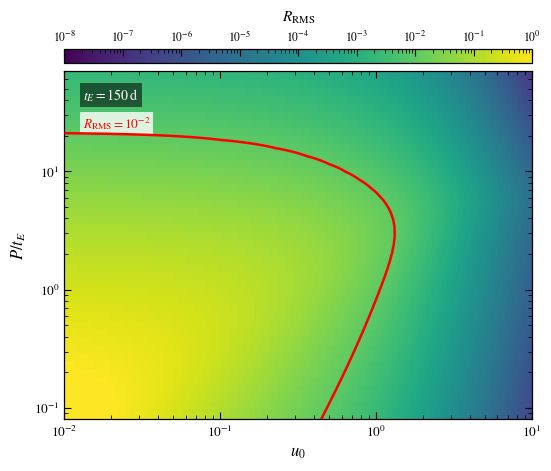

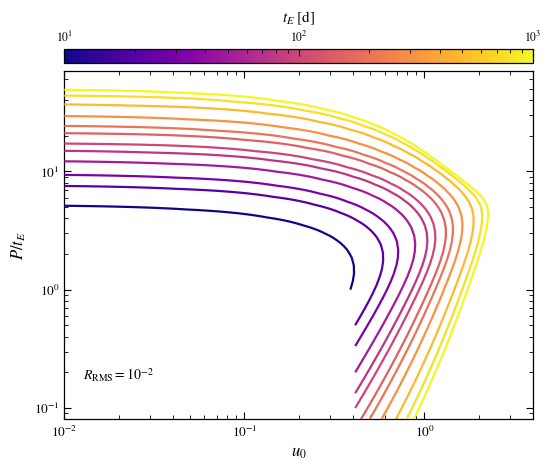

In [1]:
# ============================================================
# PAPER FIGURES
#
# FIGURE 1:
#   Full R_RMS heatmap for one representative tE
#   + R_RMS = 1e-2 contour
#
# FIGURE 2:
#   R_RMS = 1e-2 contours for many tE
#   color = tE
#
# The two figures:
#   - have the same physical size
#   - have the same x/y limits
#   - contain no "(a)" or "(b)" labels
#   - are saved independently
#
# No interpolation across failed fits.
# ============================================================

import glob
import os
import re

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from matplotlib.cm import ScalarMappable


# ============================================================
# PAPER STYLE
# ============================================================

plt.rcParams.update({

    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",

    "font.size": 10,

    "axes.labelsize": 12,

    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,

    "axes.linewidth": 0.9,

    "xtick.direction": "in",
    "ytick.direction": "in",

    "xtick.top": True,
    "ytick.right": True,

    "xtick.major.size": 5,
    "ytick.major.size": 5,

    "xtick.minor.size": 3,
    "ytick.minor.size": 3,

    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,

    "savefig.dpi": 300,
})


# ============================================================
# CONFIGURATION
# ============================================================

home_path = os.path.expanduser("~")


base_directory = os.path.join(
    home_path,
    "binary_source",
    "results",
    "scan_many_tE_200x200",
)


# ============================================================
# tE VALUES
# ============================================================

tE_list = np.array(
    [
        10,
        20,
        30,
        50,
        75,
        100,
        150,
        200,
        300,
        500,
        750,
        1000,
    ],
    dtype=float,
)


# ============================================================
# REPRESENTATIVE tE FOR HEATMAP
# ============================================================

tE_heatmap = 150.0


# ============================================================
# METRIC
# ============================================================

metric_key = "RMS"

threshold = 1e-2


# ============================================================
# COMMON AXIS RANGE
#
# Same limits for both figures.
# This removes the large empty region at high P/tE.
# ============================================================

XMIN = 1e-2
XMAX = 1e1

YMIN = 8e-2
YMAX = 7e1


# ============================================================
# FIGURE SIZE
#
# Same size for both outputs.
#
# This is convenient when placing them with:
#
# \begin{subfigure}{0.49\linewidth}
# ...
# \end{subfigure}
# ============================================================

FIGSIZE = (5.4, 4.6)


# ============================================================
# HEATMAP COLOR SCALE
#
# Fixed scale so the meaning of the colors is explicit.
#
# You can change RMS_VMIN if desired.
# ============================================================

RMS_VMIN = 1e-8
RMS_VMAX = 1.0


# ============================================================
# OUTPUT
# ============================================================

output_heatmap_png = os.path.join(
    base_directory,
    f"paper_RMS_heatmap_tE{int(tE_heatmap)}.png",
)

output_heatmap_pdf = os.path.join(
    base_directory,
    f"paper_RMS_heatmap_tE{int(tE_heatmap)}.pdf",
)


output_contours_png = os.path.join(
    base_directory,
    "paper_RMS_threshold_many_tE.png",
)

output_contours_pdf = os.path.join(
    base_directory,
    "paper_RMS_threshold_many_tE.pdf",
)


# ============================================================
# AUXILIARY FUNCTIONS
# ============================================================

def extract_u0_index(filename):
    """
    Extract index from

        scan_kepler_u0_003.npz
    """

    base = os.path.basename(filename)

    match = re.fullmatch(
        r"scan_kepler_u0_(\d+)\.npz",
        base,
    )

    if match is None:

        raise ValueError(
            f"No pude extraer el índice desde {base}"
        )

    return int(
        match.group(1)
    )


# ============================================================
# tE DIRECTORY LABEL
# ============================================================

def format_tE_label(tE):
    """
    Examples:

        150.0 -> 150
        37.5  -> 37p5
    """

    label = f"{float(tE):g}"

    return label.replace(
        ".",
        "p",
    )


# ============================================================
# LOGARITHMIC BIN EDGES
#
# Used for pcolormesh.
# ============================================================

def log_bin_edges(x):

    x = np.asarray(
        x,
        dtype=float,
    )


    if len(x) < 2:

        raise ValueError(
            "Se necesitan al menos dos puntos."
        )


    if np.any(
        x <= 0
    ):

        raise ValueError(
            "Todos los valores deben ser positivos."
        )


    logx = np.log10(
        x
    )


    edges = np.empty(
        len(x) + 1,
        dtype=float,
    )


    edges[1:-1] = (
        0.5
        * (
            logx[:-1]
            + logx[1:]
        )
    )


    edges[0] = (
        logx[0]
        - 0.5
        * (
            logx[1]
            - logx[0]
        )
    )


    edges[-1] = (
        logx[-1]
        + 0.5
        * (
            logx[-1]
            - logx[-2]
        )
    )


    return 10**edges


# ============================================================
# LOAD ONE tE MAP
# ============================================================

def load_metric_map_for_tE(
    tE_true,
    base_directory,
    metric_key="RMS",
):
    """
    Load metric(u0, P/tE) for one tE.

    Failed fits remain NaN.
    No interpolation is performed.
    """

    label = format_tE_label(
        tE_true
    )


    directory = os.path.join(
        base_directory,
        f"scan_u0_tE{label}",
    )


    pattern = os.path.join(
        directory,
        "scan_kepler_u0_*.npz",
    )


    files = sorted(
        glob.glob(pattern)
    )


    if len(files) == 0:

        raise FileNotFoundError(
            f"No files found:\n{pattern}"
        )


    # ========================================================
    # FIRST PASS
    # ========================================================

    records = []

    P_grid_reference = None

    total_bins = 0
    successful_bins = 0


    for filename in files:


        with np.load(
            filename,
            allow_pickle=False,
        ) as d:


            truth = d[
                "truth"
            ].astype(float)


            u0_true = float(
                truth[1]
            )


            P_grid = d[
                "P_grid"
            ].astype(float)


            SUCCESS = d[
                "SUCCESS"
            ].astype(bool)


        # ----------------------------------------------------
        # Check common P grid
        # ----------------------------------------------------

        if P_grid_reference is None:

            P_grid_reference = (
                P_grid.copy()
            )

        else:

            if (
                len(P_grid)
                != len(P_grid_reference)
                or not np.allclose(
                    P_grid,
                    P_grid_reference,
                )
            ):

                raise ValueError(
                    f"P_grid inconsistent in:\n"
                    f"{filename}"
                )


        total_bins += len(
            SUCCESS
        )


        successful_bins += np.count_nonzero(
            SUCCESS
        )


        records.append(
            {

                "filename":
                    filename,

                "index":
                    extract_u0_index(
                        filename
                    ),

                "u0":
                    u0_true,
            }
        )


    # ========================================================
    # SORT BY PHYSICAL u0
    # ========================================================

    records = sorted(
        records,
        key=lambda x:
            x["u0"],
    )


    u0_grid = np.array(
        [
            rec["u0"]
            for rec in records
        ],
        dtype=float,
    )


    Nu0 = len(
        u0_grid
    )


    NP = len(
        P_grid_reference
    )


    # ========================================================
    # METRIC MAP
    # ========================================================

    metric_map = np.full(
        (Nu0, NP),
        np.nan,
        dtype=float,
    )


    for i, rec in enumerate(
        records
    ):


        with np.load(
            rec["filename"],
            allow_pickle=False,
        ) as d:


            metric = d[
                metric_key
            ].astype(float)


            SUCCESS = d[
                "SUCCESS"
            ].astype(bool)


        valid = (
            SUCCESS
            & np.isfinite(
                metric
            )
            & (
                metric > 0
            )
        )


        metric_map[
            i,
            valid,
        ] = metric[
            valid
        ]


    # ========================================================
    # P/tE
    # ========================================================

    P_over_tE = (
        P_grid_reference
        / float(tE_true)
    )


    return {

        "tE_true":
            float(tE_true),

        "directory":
            directory,

        "u0_grid":
            u0_grid,

        "P_grid":
            P_grid_reference,

        "P_over_tE_grid":
            P_over_tE,

        "metric_map":
            metric_map,

        "success_fraction":
            successful_bins / total_bins,

        "n_files":
            len(files),
    }


# ============================================================
# LOAD ALL RESULTS
# ============================================================

results = []


print()

print("=" * 80)

print(
    "Loading RMS maps"
)

print("=" * 80)


for tE_true in tE_list:


    try:

        result = load_metric_map_for_tE(

            tE_true=tE_true,

            base_directory=base_directory,

            metric_key=metric_key,
        )


    except FileNotFoundError:

        print(
            f"tE={tE_true:g} d missing -> skipped"
        )

        continue


    results.append(
        result
    )


    print(

        f"tE={tE_true:7.1f} d   "

        f"Nfiles={result['n_files']:3d}   "

        f"success="
        f"{100*result['success_fraction']:6.2f}%"
    )


if len(results) == 0:

    raise RuntimeError(
        "No results could be loaded."
    )


# ============================================================
# FIND HEATMAP RESULT
# ============================================================

heatmap_result = None


for result in results:

    if np.isclose(
        result["tE_true"],
        tE_heatmap,
    ):

        heatmap_result = result

        break


if heatmap_result is None:

    raise ValueError(
        f"No result found for tE={tE_heatmap:g} d."
    )


# ============================================================
#
# FIGURE 1
#
# RMS HEATMAP FOR REPRESENTATIVE tE
#
# ============================================================

u0_grid = heatmap_result[
    "u0_grid"
]


P_over_tE = heatmap_result[
    "P_over_tE_grid"
]


RMS_map = heatmap_result[
    "metric_map"
]


# ============================================================
# LOG EDGES
# ============================================================

u0_edges = log_bin_edges(
    u0_grid
)


P_edges = log_bin_edges(
    P_over_tE
)


# ============================================================
# RMS NORMALIZATION
# ============================================================

norm_RMS = mcolors.LogNorm(

    vmin=RMS_VMIN,

    vmax=RMS_VMAX,
)


# ============================================================
# CREATE FIGURE 1
# ============================================================

fig1, ax1 = plt.subplots(

    figsize=FIGSIZE,

    constrained_layout=True,
)


# ============================================================
# HEATMAP
# ============================================================

pcm = ax1.pcolormesh(

    u0_edges,

    P_edges,

    np.ma.masked_invalid(
        RMS_map
    ).T,

    cmap="viridis",

    norm=norm_RMS,

    shading="auto",

    edgecolors="none",

    linewidth=0,

    rasterized=True,
)


# ============================================================
# R_RMS = 1e-2 CONTOUR
# ============================================================

U2D, Y2D = np.meshgrid(

    u0_grid,

    P_over_tE,

    indexing="xy",
)


ax1.contour(

    U2D,

    Y2D,

    np.ma.masked_invalid(
        RMS_map.T
    ),

    levels=[
        threshold
    ],

    colors="red",

    linewidths=1.8,

    linestyles="-",

    zorder=5,
)


# ============================================================
# AXES
# ============================================================

ax1.set_xscale(
    "log"
)


ax1.set_yscale(
    "log"
)


ax1.set_xlim(
    XMIN,
    XMAX,
)


ax1.set_ylim(
    YMIN,
    YMAX,
)


ax1.set_xlabel(
    r"$u_0$"
)


ax1.set_ylabel(
    r"$P/t_E$"
)


ax1.tick_params(

    axis="both",

    which="both",

    direction="in",

    top=True,

    right=True,
)


ax1.grid(
    False
)


# ============================================================
# SMALL ANNOTATION
# ============================================================

ax1.text(

    0.04,
    0.955,

    rf"$t_E={tE_heatmap:.0f}\,\mathrm{{d}}$",

    transform=ax1.transAxes,

    ha="left",

    va="top",

    fontsize=10,

    color="white",

    bbox=dict(

        facecolor="black",

        edgecolor="none",

        alpha=0.55,

        pad=2.5,
    ),
)


ax1.text(

    0.04,
    0.875,

    r"$R_{\rm RMS}=10^{-2}$",

    transform=ax1.transAxes,

    ha="left",

    va="top",

    fontsize=9.5,

    color="red",

    bbox=dict(

        facecolor="white",

        edgecolor="none",

        alpha=0.80,

        pad=2,
    ),
)


# ============================================================
# TOP RMS COLORBAR
# ============================================================

cbar1 = fig1.colorbar(

    pcm,

    ax=ax1,

    orientation="horizontal",

    location="top",

    pad=0.025,

    fraction=0.055,

    aspect=35,
)


cbar1.set_label(

    r"$R_{\rm RMS}$",

    fontsize=11,

    labelpad=5,
)


cbar1.ax.tick_params(

    axis="x",

    which="both",

    direction="in",

    labelsize=8.5,
)


cbar1.ax.xaxis.set_ticks_position(
    "top"
)


cbar1.ax.xaxis.set_label_position(
    "top"
)


# ============================================================
# SAVE FIGURE 1
# ============================================================

fig1.savefig(

    output_heatmap_png,

    dpi=300,

    bbox_inches="tight",
)


fig1.savefig(

    output_heatmap_pdf,

    bbox_inches="tight",
)


# ============================================================
#
# FIGURE 2
#
# R_RMS = 1e-2 CONTOURS FOR MANY tE
#
# ============================================================


# ============================================================
# tE COLOR NORMALIZATION
# ============================================================

tE_loaded = np.array(
    [
        result["tE_true"]
        for result in results
    ],
    dtype=float,
)


norm_tE = mcolors.LogNorm(

    vmin=np.min(
        tE_loaded
    ),

    vmax=np.max(
        tE_loaded
    ),
)


cmap_tE = plt.get_cmap(
    "plasma"
)


# ============================================================
# CREATE FIGURE 2
# ============================================================

fig2, ax2 = plt.subplots(

    figsize=FIGSIZE,

    constrained_layout=True,
)


# ============================================================
# DRAW CONTOURS
# ============================================================

for result in results:


    tE_true = result[
        "tE_true"
    ]


    u0_grid = result[
        "u0_grid"
    ]


    P_over_tE = result[
        "P_over_tE_grid"
    ]


    metric_map = result[
        "metric_map"
    ]


    valid = (
        np.isfinite(
            metric_map
        )
        & (
            metric_map > 0
        )
    )


    if not np.any(
        valid
    ):

        continue


    metric_min = np.nanmin(
        metric_map[
            valid
        ]
    )


    metric_max = np.nanmax(
        metric_map[
            valid
        ]
    )


    if not (
        metric_min
        <= threshold
        <= metric_max
    ):

        print(
            f"tE={tE_true:g}: "
            f"RMS={threshold:.0e} not crossed."
        )

        continue


    U2D, Y2D = np.meshgrid(

        u0_grid,

        P_over_tE,

        indexing="xy",
    )


    contour_color = cmap_tE(
        norm_tE(
            tE_true
        )
    )


    ax2.contour(

        U2D,

        Y2D,

        np.ma.masked_invalid(
            metric_map.T
        ),

        levels=[
            threshold
        ],

        colors=[
            contour_color
        ],

        linewidths=1.6,

        linestyles="-",

        zorder=3,
    )


# ============================================================
# AXES
# ============================================================

ax2.set_xscale(
    "log"
)


ax2.set_yscale(
    "log"
)


ax2.set_xlim(
    XMIN,
    4,
)


ax2.set_ylim(
    YMIN,
    YMAX,
)


ax2.set_xlabel(
    r"$u_0$"
)


ax2.set_ylabel(
    r"$P/t_E$"
)


ax2.tick_params(

    axis="both",

    which="both",

    direction="in",

    top=True,

    right=True,
)


ax2.grid(
    False
)


# ============================================================
# THRESHOLD ANNOTATION
# ============================================================

ax2.text(

    0.04,
    0.155,

    r"$R_{\rm RMS}=10^{-2}$",

    transform=ax2.transAxes,

    ha="left",

    va="top",

    fontsize=10,
)


# ============================================================
# TOP tE COLORBAR
# ============================================================

sm = ScalarMappable(

    norm=norm_tE,

    cmap=cmap_tE,
)


sm.set_array([])


cbar2 = fig2.colorbar(

    sm,

    ax=ax2,

    orientation="horizontal",

    location="top",

    pad=0.025,

    fraction=0.055,

    aspect=35,
)


cbar2.set_label(

    r"$t_E\;[\mathrm{d}]$",

    fontsize=11,

    labelpad=5,
)


cbar2.ax.tick_params(

    axis="x",

    which="both",

    direction="in",

    labelsize=8.5,
)


cbar2.ax.xaxis.set_ticks_position(
    "top"
)


cbar2.ax.xaxis.set_label_position(
    "top"
)


# ============================================================
# SAVE FIGURE 2
# ============================================================

fig2.savefig(

    output_contours_png,

    dpi=300,

    bbox_inches="tight",
)


fig2.savefig(

    output_contours_pdf,

    bbox_inches="tight",
)


# ============================================================
# FINAL OUTPUT
# ============================================================

print()

print("=" * 80)

print("FIGURE 1")

print(
    output_heatmap_png
)

print(
    output_heatmap_pdf
)


print()

print("FIGURE 2")

print(
    output_contours_png
)

print(
    output_contours_pdf
)

print("=" * 80)


plt.show()


Loading RMS maps
tE=   10.0 d   Nfiles=200   success=100.00%
tE=   20.0 d   Nfiles=200   success=100.00%
tE=   30.0 d   Nfiles=200   success=100.00%
tE=   50.0 d   Nfiles=200   success=100.00%
tE=   75.0 d   Nfiles=200   success=100.00%
tE=  100.0 d   Nfiles=200   success=100.00%
tE=  150.0 d   Nfiles=200   success=100.00%
tE=  200.0 d   Nfiles=200   success=100.00%
tE=  300.0 d   Nfiles=200   success=100.00%
tE=  500.0 d   Nfiles=200   success=100.00%
tE=  750.0 d   Nfiles=200   success=100.00%
tE= 1000.0 d   Nfiles=200   success=100.00%

CONTOURS FOR tE=150 d
log10(RMS) range = -6.7164 -- 0.1980

Requested contour levels:
    1e-04
    1e-03
    1e-02
    1e-01
    1e+00

Actually plotted:
    1e-04
    1e-03
    1e-02
    1e-01
    1e+00

FIGURE 1
/home/anibal-pc/binary_source/results/scan_many_tE_200x200/paper_RMS_heatmap_tE150.png
/home/anibal-pc/binary_source/results/scan_many_tE_200x200/paper_RMS_heatmap_tE150.pdf

FIGURE 2
/home/anibal-pc/binary_source/results/scan_many_tE_200

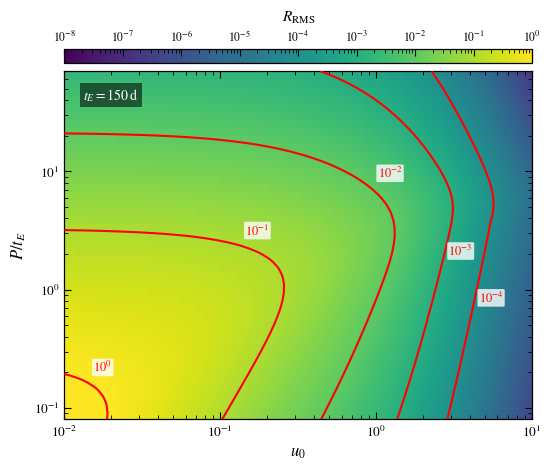

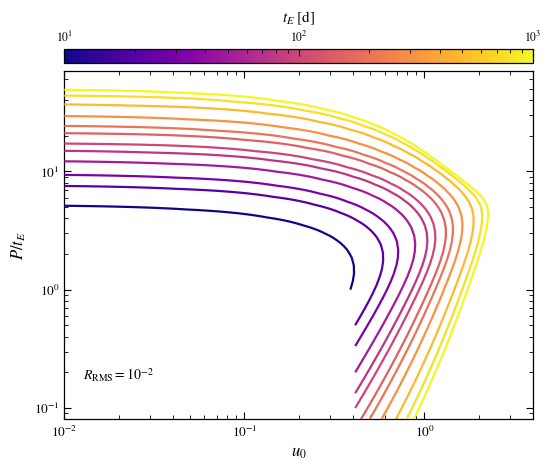

In [5]:
# ============================================================
# PAPER FIGURES
#
# FIGURE 1:
#   Full R_RMS heatmap for one representative tE
#
#   + red contours:
#
#       R_RMS = 1e-4
#               1e-3
#               1e-2
#               1e-1
#               1e0
#
#   The heatmap always uses the ORIGINAL simulation values.
#
#   The contour curves are reconstructed on a fine grid in
#
#       log10(u0), log10(P/tE), log10(RMS)
#
#   so isolated failed-fit holes do not artificially break
#   the contour lines.
#
#   Labels are added with annotate(), NOT clabel(), so the
#   contour itself remains continuous.
#
#
# FIGURE 2:
#   R_RMS = 1e-2 contours for many tE
#   color = tE
#
#   UNCHANGED relative to the previous version.
#
# ============================================================


import glob
import os
import re

import numpy as np

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from matplotlib.cm import ScalarMappable

from scipy.interpolate import griddata


# ============================================================
# PAPER STYLE
# ============================================================

plt.rcParams.update({

    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",

    "font.size": 10,

    "axes.labelsize": 12,

    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,

    "axes.linewidth": 0.9,

    "xtick.direction": "in",
    "ytick.direction": "in",

    "xtick.top": True,
    "ytick.right": True,

    "xtick.major.size": 5,
    "ytick.major.size": 5,

    "xtick.minor.size": 3,
    "ytick.minor.size": 3,

    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,

    "savefig.dpi": 300,
})


# ============================================================
# CONFIGURATION
# ============================================================

home_path = os.path.expanduser("~")


base_directory = os.path.join(
    home_path,
    "binary_source",
    "results",
    "scan_many_tE_200x200",
)


# ============================================================
# tE VALUES
# ============================================================

tE_list = np.array(
    [
        10,
        20,
        30,
        50,
        75,
        100,
        150,
        200,
        300,
        500,
        750,
        1000,
    ],
    dtype=float,
)


# ============================================================
# REPRESENTATIVE tE FOR HEATMAP
# ============================================================

tE_heatmap = 150.0


# ============================================================
# METRIC
# ============================================================

metric_key = "RMS"


# ============================================================
# THRESHOLD FOR FIGURE 2
# ============================================================

threshold = 1e-2


# ============================================================
# RMS CONTOUR LEVELS FOR FIGURE 1
# ============================================================

RMS_CONTOUR_LEVELS = np.array(
    [
        1e-4,
        1e-3,
        1e-2,
        1e-1,
        1e0,
    ],
    dtype=float,
)


# ============================================================
# CONTOUR INTERPOLATION RESOLUTION
# ============================================================

N_CONTOUR = 700


# ============================================================
# COMMON AXIS RANGE
# ============================================================

XMIN = 1e-2
XMAX = 1e1

YMIN = 8e-2
YMAX = 7e1


# ============================================================
# FIGURE SIZE
# ============================================================

FIGSIZE = (5.4, 4.6)


# ============================================================
# HEATMAP COLOR SCALE
# ============================================================

RMS_VMIN = 1e-8
RMS_VMAX = 1.0


# ============================================================
# OUTPUT
# ============================================================

output_heatmap_png = os.path.join(
    base_directory,
    f"paper_RMS_heatmap_tE{int(tE_heatmap)}.png",
)

output_heatmap_pdf = os.path.join(
    base_directory,
    f"paper_RMS_heatmap_tE{int(tE_heatmap)}.pdf",
)


output_contours_png = os.path.join(
    base_directory,
    "paper_RMS_threshold_many_tE.png",
)

output_contours_pdf = os.path.join(
    base_directory,
    "paper_RMS_threshold_many_tE.pdf",
)


# ============================================================
# AUXILIARY FUNCTIONS
# ============================================================

def extract_u0_index(filename):
    """
    Extract index from:

        scan_kepler_u0_003.npz
    """

    base = os.path.basename(
        filename
    )

    match = re.fullmatch(
        r"scan_kepler_u0_(\d+)\.npz",
        base,
    )

    if match is None:

        raise ValueError(
            f"No pude extraer el índice desde {base}"
        )

    return int(
        match.group(1)
    )


# ============================================================
# tE DIRECTORY LABEL
# ============================================================

def format_tE_label(tE):
    """
    Examples:

        150.0 -> 150
        37.5  -> 37p5
    """

    label = f"{float(tE):g}"

    return label.replace(
        ".",
        "p",
    )


# ============================================================
# LOGARITHMIC BIN EDGES
#
# Used only for the original pcolormesh.
# ============================================================

def log_bin_edges(x):

    x = np.asarray(
        x,
        dtype=float,
    )


    if len(x) < 2:

        raise ValueError(
            "Se necesitan al menos dos puntos."
        )


    if np.any(
        x <= 0
    ):

        raise ValueError(
            "Todos los valores deben ser positivos."
        )


    logx = np.log10(
        x
    )


    edges = np.empty(
        len(x) + 1,
        dtype=float,
    )


    edges[1:-1] = (

        0.5
        *
        (
            logx[:-1]
            +
            logx[1:]
        )
    )


    edges[0] = (

        logx[0]
        -
        0.5
        *
        (
            logx[1]
            -
            logx[0]
        )
    )


    edges[-1] = (

        logx[-1]
        +
        0.5
        *
        (
            logx[-1]
            -
            logx[-2]
        )
    )


    return 10**edges


# ============================================================
# LOAD ONE tE MAP
# ============================================================

def load_metric_map_for_tE(
    tE_true,
    base_directory,
    metric_key="RMS",
):
    """
    Load metric(u0, P/tE) for one tE.

    Failed fits remain NaN in the returned ORIGINAL map.
    """

    label = format_tE_label(
        tE_true
    )


    directory = os.path.join(
        base_directory,
        f"scan_u0_tE{label}",
    )


    pattern = os.path.join(
        directory,
        "scan_kepler_u0_*.npz",
    )


    files = sorted(
        glob.glob(
            pattern
        )
    )


    if len(files) == 0:

        raise FileNotFoundError(
            f"No files found:\n{pattern}"
        )


    # ========================================================
    # FIRST PASS
    # ========================================================

    records = []

    P_grid_reference = None

    total_bins = 0

    successful_bins = 0


    for filename in files:


        with np.load(
            filename,
            allow_pickle=False,
        ) as d:


            truth = d[
                "truth"
            ].astype(float)


            u0_true = float(
                truth[1]
            )


            P_grid = d[
                "P_grid"
            ].astype(float)


            SUCCESS = d[
                "SUCCESS"
            ].astype(bool)


        # ----------------------------------------------------
        # Check common P grid
        # ----------------------------------------------------

        if P_grid_reference is None:

            P_grid_reference = (
                P_grid.copy()
            )

        else:

            if (
                len(P_grid)
                !=
                len(P_grid_reference)
                or
                not np.allclose(
                    P_grid,
                    P_grid_reference,
                )
            ):

                raise ValueError(
                    f"P_grid inconsistent in:\n"
                    f"{filename}"
                )


        total_bins += len(
            SUCCESS
        )


        successful_bins += np.count_nonzero(
            SUCCESS
        )


        records.append(
            {

                "filename":
                    filename,

                "index":
                    extract_u0_index(
                        filename
                    ),

                "u0":
                    u0_true,
            }
        )


    # ========================================================
    # SORT BY PHYSICAL u0
    # ========================================================

    records = sorted(
        records,
        key=lambda x:
            x["u0"],
    )


    u0_grid = np.array(
        [
            rec["u0"]
            for rec in records
        ],
        dtype=float,
    )


    Nu0 = len(
        u0_grid
    )


    NP = len(
        P_grid_reference
    )


    # ========================================================
    # METRIC MAP
    # ========================================================

    metric_map = np.full(
        (
            Nu0,
            NP,
        ),
        np.nan,
        dtype=float,
    )


    for i, rec in enumerate(
        records
    ):


        with np.load(
            rec["filename"],
            allow_pickle=False,
        ) as d:


            metric = d[
                metric_key
            ].astype(float)


            SUCCESS = d[
                "SUCCESS"
            ].astype(bool)


        valid = (

            SUCCESS
            &
            np.isfinite(
                metric
            )
            &
            (
                metric > 0
            )
        )


        metric_map[
            i,
            valid,
        ] = metric[
            valid
        ]


    # ========================================================
    # P/tE
    # ========================================================

    P_over_tE = (

        P_grid_reference
        /
        float(
            tE_true
        )
    )


    return {

        "tE_true":
            float(
                tE_true
            ),

        "directory":
            directory,

        "u0_grid":
            u0_grid,

        "P_grid":
            P_grid_reference,

        "P_over_tE_grid":
            P_over_tE,

        "metric_map":
            metric_map,

        "success_fraction":
            successful_bins
            /
            total_bins,

        "n_files":
            len(
                files
            ),
    }


# ============================================================
# LOAD ALL RESULTS
# ============================================================

results = []


print()

print(
    "=" * 80
)

print(
    "Loading RMS maps"
)

print(
    "=" * 80
)


for tE_true in tE_list:


    try:

        result = load_metric_map_for_tE(

            tE_true=tE_true,

            base_directory=base_directory,

            metric_key=metric_key,
        )


    except FileNotFoundError:

        print(
            f"tE={tE_true:g} d missing -> skipped"
        )

        continue


    results.append(
        result
    )


    print(

        f"tE={tE_true:7.1f} d   "

        f"Nfiles={result['n_files']:3d}   "

        f"success="
        f"{100 * result['success_fraction']:6.2f}%"
    )


if len(results) == 0:

    raise RuntimeError(
        "No results could be loaded."
    )


# ============================================================
# FIND HEATMAP RESULT
# ============================================================

heatmap_result = None


for result in results:


    if np.isclose(
        result[
            "tE_true"
        ],
        tE_heatmap,
    ):

        heatmap_result = result

        break


if heatmap_result is None:

    raise ValueError(
        f"No result found for tE={tE_heatmap:g} d."
    )


# ============================================================
# ============================================================
#
# FIGURE 1
#
# RMS HEATMAP FOR REPRESENTATIVE tE
#
# ============================================================
# ============================================================

u0_grid = heatmap_result[
    "u0_grid"
]


P_over_tE = heatmap_result[
    "P_over_tE_grid"
]


RMS_map = heatmap_result[
    "metric_map"
]


# ============================================================
# ORIGINAL LOG EDGES FOR PCOLORMESH
# ============================================================

u0_edges = log_bin_edges(
    u0_grid
)


P_edges = log_bin_edges(
    P_over_tE
)


# ============================================================
# RMS NORMALIZATION
# ============================================================

norm_RMS = mcolors.LogNorm(

    vmin=RMS_VMIN,

    vmax=RMS_VMAX,
)


# ============================================================
# CREATE FIGURE 1
# ============================================================

fig1, ax1 = plt.subplots(

    figsize=FIGSIZE,

    constrained_layout=True,
)


# ============================================================
# ORIGINAL HEATMAP
#
# IMPORTANT:
#
# No interpolation is used here.
# ============================================================

pcm = ax1.pcolormesh(

    u0_edges,

    P_edges,

    np.ma.masked_invalid(
        RMS_map
    ).T,

    cmap="viridis",

    norm=norm_RMS,

    shading="auto",

    edgecolors="none",

    linewidth=0,

    rasterized=True,
)


# ============================================================
# ============================================================
#
# RECONSTRUCT A SMOOTH FIELD ONLY FOR CONTOURS
#
# ============================================================
# ============================================================


# ============================================================
# ORIGINAL GRID IN LOG SPACE
# ============================================================

log_u0 = np.log10(
    u0_grid
)


log_PtE = np.log10(
    P_over_tE
)


Xlog, Ylog = np.meshgrid(

    log_u0,

    log_PtE,

    indexing="xy",
)


# RMS_map has shape:
#
#     (Nu0, NP)
#
# therefore transpose to:
#
#     (NP, Nu0)
#
# to match meshgrid.
# ============================================================

Z = RMS_map.T


valid = (

    np.isfinite(
        Z
    )
    &
    (
        Z > 0
    )
)


if not np.any(
    valid
):

    raise RuntimeError(
        "No finite positive RMS values available."
    )


# ============================================================
# INTERPOLATE log10(RMS), NOT RMS
#
# This is more appropriate because RMS spans many orders
# of magnitude.
# ============================================================

logZ = np.full_like(
    Z,
    np.nan,
    dtype=float,
)


logZ[
    valid
] = np.log10(
    Z[
        valid
    ]
)


# ============================================================
# VALID SIMULATION POINTS
# ============================================================

points = np.column_stack(
    (
        Xlog[
            valid
        ],

        Ylog[
            valid
        ],
    )
)


values = logZ[
    valid
]


# ============================================================
# FINE GRID
# ============================================================

log_u0_fine = np.linspace(

    np.log10(
        XMIN
    ),

    np.log10(
        XMAX
    ),

    N_CONTOUR,
)


log_PtE_fine = np.linspace(

    np.log10(
        YMIN
    ),

    np.log10(
        YMAX
    ),

    N_CONTOUR,
)


Xfine_log, Yfine_log = np.meshgrid(

    log_u0_fine,

    log_PtE_fine,

    indexing="xy",
)


# ============================================================
# FIRST: LINEAR INTERPOLATION
#
# This uses neighboring successful simulations.
# ============================================================

logRMS_fine = griddata(

    points,

    values,

    (
        Xfine_log,
        Yfine_log,
    ),

    method="linear",
)


# ============================================================
# SECOND: FILL REMAINING HOLES WITH NEAREST
#
# This avoids isolated NaN regions breaking a contour.
# ============================================================

missing = ~np.isfinite(
    logRMS_fine
)


if np.any(
    missing
):


    logRMS_nearest = griddata(

        points,

        values,

        (
            Xfine_log,
            Yfine_log,
        ),

        method="nearest",
    )


    logRMS_fine[
        missing
    ] = logRMS_nearest[
        missing
    ]


# ============================================================
# FINE GRID IN PHYSICAL COORDINATES
# ============================================================

Ufine = 10**Xfine_log

Yfine = 10**Yfine_log


# ============================================================
# DETERMINE WHICH REQUESTED LEVELS ARE ACTUALLY CROSSED
# ============================================================

logRMS_min = np.nanmin(
    logRMS_fine
)


logRMS_max = np.nanmax(
    logRMS_fine
)


levels_to_plot = []


for level in RMS_CONTOUR_LEVELS:


    loglevel = np.log10(
        level
    )


    if (
        logRMS_min
        <=
        loglevel
        <=
        logRMS_max
    ):

        levels_to_plot.append(
            level
        )

    else:

        print(
            f"RMS={level:.0e} is outside "
            f"the interpolated RMS range -> skipped"
        )


levels_to_plot = np.asarray(
    levels_to_plot,
    dtype=float,
)


print()

print(
    "=" * 80
)

print(
    f"CONTOURS FOR tE={tE_heatmap:g} d"
)

print(
    "=" * 80
)

print(
    f"log10(RMS) range = "
    f"{logRMS_min:.4f} -- {logRMS_max:.4f}"
)

print()

print(
    "Requested contour levels:"
)

for level in RMS_CONTOUR_LEVELS:

    print(
        f"    {level:.0e}"
    )


print()

print(
    "Actually plotted:"
)

for level in levels_to_plot:

    print(
        f"    {level:.0e}"
    )


print(
    "=" * 80
)


# ============================================================
# DRAW ALL CONTOURS IN RED
#
# Work in log10(RMS).
# ============================================================

if len(
    levels_to_plot
) > 0:


    contour_levels_log = np.log10(
        levels_to_plot
    )


    cs = ax1.contour(

        Ufine,

        Yfine,

        logRMS_fine,

        levels=contour_levels_log,

        colors="red",

        linewidths=1.5,

        linestyles="-",

        zorder=6,
    )


# ============================================================
# ============================================================
#
# LABEL CONTOURS WITHOUT CUTTING THE CURVE
#
# ============================================================
# ============================================================


def visible_log_segment(
    segment,
):
    """
    Return only the part of a contour segment lying inside
    the displayed axes.
    """

    segment = np.asarray(
        segment,
        dtype=float,
    )


    if len(
        segment
    ) < 2:

        return None


    x = segment[
        :,
        0
    ]


    y = segment[
        :,
        1
    ]


    good = (

        np.isfinite(
            x
        )
        &
        np.isfinite(
            y
        )
        &
        (
            x > 0
        )
        &
        (
            y > 0
        )
        &
        (
            x >= XMIN
        )
        &
        (
            x <= XMAX
        )
        &
        (
            y >= YMIN
        )
        &
        (
            y <= YMAX
        )
    )


    if np.count_nonzero(
        good
    ) < 2:

        return None


    return np.column_stack(
        (
            x[
                good
            ],

            y[
                good
            ],
        )
    )


# ============================================================
# LENGTH OF CONTOUR SEGMENT IN LOG-LOG SPACE
# ============================================================

def segment_length_log(
    segment,
):


    segment = visible_log_segment(
        segment
    )


    if segment is None:

        return 0.0


    lx = np.log10(
        segment[
            :,
            0
        ]
    )


    ly = np.log10(
        segment[
            :,
            1
        ]
    )


    return np.sum(

        np.sqrt(

            np.diff(
                lx
            )**2

            +

            np.diff(
                ly
            )**2
        )
    )


# ============================================================
# GET POSITION AT A FRACTION OF THE CONTOUR ARC LENGTH
# ============================================================

def point_along_segment(
    segment,
    fraction=0.5,
):


    segment = visible_log_segment(
        segment
    )


    if segment is None:

        return None


    x = segment[
        :,
        0
    ]


    y = segment[
        :,
        1
    ]


    lx = np.log10(
        x
    )


    ly = np.log10(
        y
    )


    ds = np.sqrt(

        np.diff(
            lx
        )**2

        +

        np.diff(
            ly
        )**2
    )


    cumulative = np.concatenate(
        (
            [
                0.0
            ],

            np.cumsum(
                ds
            ),
        )
    )


    if (
        cumulative[
            -1
        ]
        <= 0
    ):

        index = len(
            x
        ) // 2


        return (
            x[
                index
            ],

            y[
                index
            ],
        )


    target = (

        fraction
        *
        cumulative[
            -1
        ]
    )


    index = np.searchsorted(

        cumulative,

        target,
    )


    index = np.clip(

        index,

        0,

        len(
            x
        ) - 1,
    )


    return (

        x[
            index
        ],

        y[
            index
        ],
    )


# ============================================================
# LABEL POSITION FOR EACH CONTOUR
#
# Change these fractions if you want to manually move a label
# farther along its contour.
# ============================================================

label_fraction = {

    -4:
        0.30,

    -3:
        0.40,

    -2:
        0.50,

    -1:
        0.60,

    0:
        0.70,
}


# ============================================================
# ANNOTATE EACH CONTOUR
#
# We choose the longest connected component of every contour
# to avoid putting a label on a tiny numerical branch.
# ============================================================

if len(
    levels_to_plot
) > 0:


    for level_index, level_log in enumerate(
        cs.levels
    ):


        exponent = int(
            np.round(
                level_log
            )
        )


        segments = cs.allsegs[
            level_index
        ]


        if len(
            segments
        ) == 0:

            continue


        # ----------------------------------------------------
        # Remove unusable segments
        # ----------------------------------------------------

        usable_segments = [

            segment

            for segment in segments

            if segment_length_log(
                segment
            ) > 0
        ]


        if len(
            usable_segments
        ) == 0:

            continue


        # ----------------------------------------------------
        # Choose longest connected contour branch
        # ----------------------------------------------------

        longest_segment = max(

            usable_segments,

            key=segment_length_log,
        )


        fraction = label_fraction.get(

            exponent,

            0.5,
        )


        position = point_along_segment(

            longest_segment,

            fraction=fraction,
        )


        if position is None:

            continue


        x_label, y_label = position


        # ----------------------------------------------------
        # ANNOTATE
        #
        # No line is erased.
        # ----------------------------------------------------

        ax1.annotate(

            rf"$10^{{{exponent}}}$",

            xy=(
                x_label,
                y_label,
            ),

            xytext=(
                5,
                5,
            ),

            textcoords="offset points",

            color="red",

            fontsize=9,

            ha="left",

            va="bottom",

            zorder=10,

            bbox=dict(

                boxstyle="round,pad=0.10",

                facecolor="white",

                edgecolor="none",

                alpha=0.80,
            ),
        )


# ============================================================
# AXES
# ============================================================

ax1.set_xscale(
    "log"
)


ax1.set_yscale(
    "log"
)


ax1.set_xlim(
    XMIN,
    XMAX,
)


ax1.set_ylim(
    YMIN,
    YMAX,
)


ax1.set_xlabel(
    r"$u_0$"
)


ax1.set_ylabel(
    r"$P/t_E$"
)


ax1.tick_params(

    axis="both",

    which="both",

    direction="in",

    top=True,

    right=True,
)


ax1.grid(
    False
)


# ============================================================
# tE ANNOTATION
# ============================================================

ax1.text(

    0.04,
    0.955,

    rf"$t_E={tE_heatmap:.0f}\,\mathrm{{d}}$",

    transform=ax1.transAxes,

    ha="left",

    va="top",

    fontsize=10,

    color="white",

    bbox=dict(

        facecolor="black",

        edgecolor="none",

        alpha=0.55,

        pad=2.5,
    ),
)


# ============================================================
# TOP RMS COLORBAR
# ============================================================

cbar1 = fig1.colorbar(

    pcm,

    ax=ax1,

    orientation="horizontal",

    location="top",

    pad=0.025,

    fraction=0.055,

    aspect=35,
)


cbar1.set_label(

    r"$R_{\rm RMS}$",

    fontsize=11,

    labelpad=5,
)


cbar1.ax.tick_params(

    axis="x",

    which="both",

    direction="in",

    labelsize=8.5,
)


cbar1.ax.xaxis.set_ticks_position(
    "top"
)


cbar1.ax.xaxis.set_label_position(
    "top"
)


# ============================================================
# SAVE FIGURE 1
# ============================================================

fig1.savefig(

    output_heatmap_png,

    dpi=300,

    bbox_inches="tight",
)


fig1.savefig(

    output_heatmap_pdf,

    bbox_inches="tight",
)


# ============================================================
# ============================================================
#
# FIGURE 2
#
# R_RMS = 1e-2 CONTOURS FOR MANY tE
#
# THIS SECTION IS UNCHANGED
#
# ============================================================
# ============================================================


# ============================================================
# tE COLOR NORMALIZATION
# ============================================================

tE_loaded = np.array(
    [
        result[
            "tE_true"
        ]

        for result in results
    ],
    dtype=float,
)


norm_tE = mcolors.LogNorm(

    vmin=np.min(
        tE_loaded
    ),

    vmax=np.max(
        tE_loaded
    ),
)


cmap_tE = plt.get_cmap(
    "plasma"
)


# ============================================================
# CREATE FIGURE 2
# ============================================================

fig2, ax2 = plt.subplots(

    figsize=FIGSIZE,

    constrained_layout=True,
)


# ============================================================
# DRAW CONTOURS
# ============================================================

for result in results:


    tE_true = result[
        "tE_true"
    ]


    u0_grid = result[
        "u0_grid"
    ]


    P_over_tE = result[
        "P_over_tE_grid"
    ]


    metric_map = result[
        "metric_map"
    ]


    valid = (

        np.isfinite(
            metric_map
        )
        &
        (
            metric_map > 0
        )
    )


    if not np.any(
        valid
    ):

        continue


    metric_min = np.nanmin(
        metric_map[
            valid
        ]
    )


    metric_max = np.nanmax(
        metric_map[
            valid
        ]
    )


    if not (
        metric_min
        <=
        threshold
        <=
        metric_max
    ):

        print(

            f"tE={tE_true:g}: "
            f"RMS={threshold:.0e} not crossed."
        )

        continue


    U2D, Y2D = np.meshgrid(

        u0_grid,

        P_over_tE,

        indexing="xy",
    )


    contour_color = cmap_tE(
        norm_tE(
            tE_true
        )
    )


    ax2.contour(

        U2D,

        Y2D,

        np.ma.masked_invalid(
            metric_map.T
        ),

        levels=[
            threshold
        ],

        colors=[
            contour_color
        ],

        linewidths=1.6,

        linestyles="-",

        zorder=3,
    )


# ============================================================
# AXES
# ============================================================

ax2.set_xscale(
    "log"
)


ax2.set_yscale(
    "log"
)


ax2.set_xlim(
    XMIN,
    4,
)


ax2.set_ylim(
    YMIN,
    YMAX,
)


ax2.set_xlabel(
    r"$u_0$"
)


ax2.set_ylabel(
    r"$P/t_E$"
)


ax2.tick_params(

    axis="both",

    which="both",

    direction="in",

    top=True,

    right=True,
)


ax2.grid(
    False
)


# ============================================================
# THRESHOLD ANNOTATION
# ============================================================

ax2.text(

    0.04,
    0.155,

    r"$R_{\rm RMS}=10^{-2}$",

    transform=ax2.transAxes,

    ha="left",

    va="top",

    fontsize=10,
)


# ============================================================
# TOP tE COLORBAR
# ============================================================

sm = ScalarMappable(

    norm=norm_tE,

    cmap=cmap_tE,
)


sm.set_array([])


cbar2 = fig2.colorbar(

    sm,

    ax=ax2,

    orientation="horizontal",

    location="top",

    pad=0.025,

    fraction=0.055,

    aspect=35,
)


cbar2.set_label(

    r"$t_E\;[\mathrm{d}]$",

    fontsize=11,

    labelpad=5,
)


cbar2.ax.tick_params(

    axis="x",

    which="both",

    direction="in",

    labelsize=8.5,
)


cbar2.ax.xaxis.set_ticks_position(
    "top"
)


cbar2.ax.xaxis.set_label_position(
    "top"
)


# ============================================================
# SAVE FIGURE 2
# ============================================================

fig2.savefig(

    output_contours_png,

    dpi=300,

    bbox_inches="tight",
)


fig2.savefig(

    output_contours_pdf,

    bbox_inches="tight",
)


# ============================================================
# FINAL OUTPUT
# ============================================================

print()

print(
    "=" * 80
)

print(
    "FIGURE 1"
)

print(
    output_heatmap_png
)

print(
    output_heatmap_pdf
)


print()

print(
    "FIGURE 2"
)

print(
    output_contours_png
)

print(
    output_contours_pdf
)

print(
    "=" * 80
)


plt.show()


Loading RMS maps
tE=   10.0 d   Nfiles=200   success=100.00%
tE=   20.0 d   Nfiles=200   success=100.00%
tE=   30.0 d   Nfiles=200   success=100.00%
tE=   50.0 d   Nfiles=200   success=100.00%
tE=   75.0 d   Nfiles=200   success=100.00%
tE=  100.0 d   Nfiles=200   success=100.00%
tE=  150.0 d   Nfiles=200   success=100.00%
tE=  200.0 d   Nfiles=200   success=100.00%
tE=  300.0 d   Nfiles=200   success=100.00%
tE=  500.0 d   Nfiles=200   success=100.00%
tE=  750.0 d   Nfiles=200   success=100.00%
tE= 1000.0 d   Nfiles=200   success=100.00%

PERIOD RANGE
P min = 10 d
P max = 100000 d

FIGURE SAVED
/home/anibal-pc/binary_source/results/scan_many_tE_200x200/paper_RMS_threshold_many_tE_P_vs_u0.png
/home/anibal-pc/binary_source/results/scan_many_tE_200x200/paper_RMS_threshold_many_tE_P_vs_u0.pdf


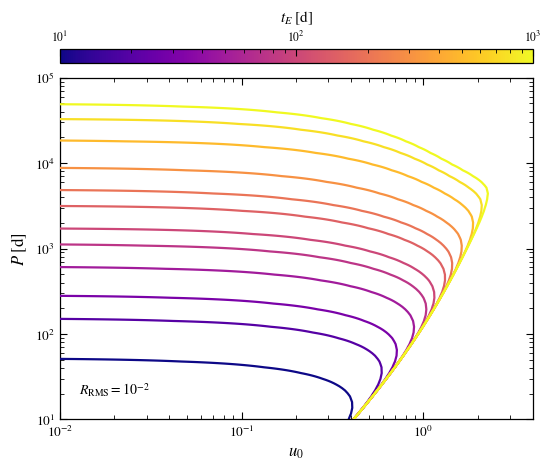

In [7]:
# ============================================================
# PAPER FIGURE
#
# R_RMS = 1e-2 contours for many tE
#
# Axes:
#
#       x = u0
#       y = P [days]
#
# Color:
#
#       tE [days]
#
# No P/tE normalization is used in this figure.
# ============================================================


import glob
import os
import re

import numpy as np

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from matplotlib.cm import ScalarMappable


# ============================================================
# PAPER STYLE
# ============================================================

plt.rcParams.update({

    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",

    "font.size": 10,

    "axes.labelsize": 12,

    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,

    "axes.linewidth": 0.9,

    "xtick.direction": "in",
    "ytick.direction": "in",

    "xtick.top": True,
    "ytick.right": True,

    "xtick.major.size": 5,
    "ytick.major.size": 5,

    "xtick.minor.size": 3,
    "ytick.minor.size": 3,

    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,

    "savefig.dpi": 300,
})


# ============================================================
# CONFIGURATION
# ============================================================

home_path = os.path.expanduser("~")


base_directory = os.path.join(
    home_path,
    "binary_source",
    "results",
    "scan_many_tE_200x200",
)


# ============================================================
# tE VALUES
# ============================================================

tE_list = np.array(
    [
        10,
        20,
        30,
        50,
        75,
        100,
        150,
        200,
        300,
        500,
        750,
        1000,
    ],
    dtype=float,
)


# ============================================================
# METRIC
# ============================================================

metric_key = "RMS"


# ============================================================
# CONTOUR LEVEL
# ============================================================

threshold = 1e-2


# ============================================================
# AXIS RANGE
#
# u0 range
# ============================================================

XMIN = 1e-2
XMAX = 4.0


# ============================================================
# P RANGE [days]
#
# Set to None to use the complete simulated P range.
#
# Otherwise, for example:
#
#       PMIN = 10
#       PMAX = 1e5
#
# ============================================================

PMIN = None
PMAX = None


# ============================================================
# FIGURE SIZE
# ============================================================

FIGSIZE = (
    5.4,
    4.6,
)


# ============================================================
# OUTPUT
# ============================================================

output_png = os.path.join(
    base_directory,
    "paper_RMS_threshold_many_tE_P_vs_u0.png",
)


output_pdf = os.path.join(
    base_directory,
    "paper_RMS_threshold_many_tE_P_vs_u0.pdf",
)


# ============================================================
# AUXILIARY FUNCTIONS
# ============================================================

def extract_u0_index(filename):
    """
    Extract index from:

        scan_kepler_u0_003.npz
    """

    base = os.path.basename(
        filename
    )


    match = re.fullmatch(
        r"scan_kepler_u0_(\d+)\.npz",
        base,
    )


    if match is None:

        raise ValueError(
            f"No pude extraer el índice desde {base}"
        )


    return int(
        match.group(1)
    )


# ============================================================
# tE DIRECTORY LABEL
# ============================================================

def format_tE_label(tE):
    """
    Examples:

        150.0 -> 150
        37.5  -> 37p5
    """

    label = f"{float(tE):g}"


    return label.replace(
        ".",
        "p",
    )


# ============================================================
# LOAD ONE tE MAP
# ============================================================

def load_metric_map_for_tE(
    tE_true,
    base_directory,
    metric_key="RMS",
):
    """
    Load metric(u0, P) for one tE.

    Failed fits remain NaN.

    No interpolation is performed.
    """

    label = format_tE_label(
        tE_true
    )


    directory = os.path.join(
        base_directory,
        f"scan_u0_tE{label}",
    )


    pattern = os.path.join(
        directory,
        "scan_kepler_u0_*.npz",
    )


    files = sorted(
        glob.glob(
            pattern
        )
    )


    if len(files) == 0:

        raise FileNotFoundError(
            f"No files found:\n{pattern}"
        )


    # ========================================================
    # FIRST PASS
    # ========================================================

    records = []

    P_grid_reference = None

    total_bins = 0

    successful_bins = 0


    for filename in files:


        with np.load(
            filename,
            allow_pickle=False,
        ) as d:


            truth = d[
                "truth"
            ].astype(float)


            u0_true = float(
                truth[1]
            )


            P_grid = d[
                "P_grid"
            ].astype(float)


            SUCCESS = d[
                "SUCCESS"
            ].astype(bool)


        # ----------------------------------------------------
        # Check common P grid
        # ----------------------------------------------------

        if P_grid_reference is None:

            P_grid_reference = (
                P_grid.copy()
            )

        else:

            if (
                len(P_grid)
                !=
                len(P_grid_reference)
                or
                not np.allclose(
                    P_grid,
                    P_grid_reference,
                )
            ):

                raise ValueError(
                    f"P_grid inconsistent in:\n"
                    f"{filename}"
                )


        total_bins += len(
            SUCCESS
        )


        successful_bins += np.count_nonzero(
            SUCCESS
        )


        records.append(
            {

                "filename":
                    filename,

                "index":
                    extract_u0_index(
                        filename
                    ),

                "u0":
                    u0_true,
            }
        )


    # ========================================================
    # SORT BY PHYSICAL u0
    # ========================================================

    records = sorted(
        records,
        key=lambda x:
            x["u0"],
    )


    u0_grid = np.array(
        [
            rec["u0"]

            for rec in records
        ],
        dtype=float,
    )


    Nu0 = len(
        u0_grid
    )


    NP = len(
        P_grid_reference
    )


    # ========================================================
    # METRIC MAP
    # ========================================================

    metric_map = np.full(
        (
            Nu0,
            NP,
        ),
        np.nan,
        dtype=float,
    )


    for i, rec in enumerate(
        records
    ):


        with np.load(
            rec["filename"],
            allow_pickle=False,
        ) as d:


            metric = d[
                metric_key
            ].astype(float)


            SUCCESS = d[
                "SUCCESS"
            ].astype(bool)


        valid = (
            SUCCESS
            &
            np.isfinite(
                metric
            )
            &
            (
                metric > 0
            )
        )


        metric_map[
            i,
            valid,
        ] = metric[
            valid
        ]


    return {

        "tE_true":
            float(
                tE_true
            ),

        "directory":
            directory,

        "u0_grid":
            u0_grid,

        "P_grid":
            P_grid_reference,

        "metric_map":
            metric_map,

        "success_fraction":
            successful_bins
            /
            total_bins,

        "n_files":
            len(
                files
            ),
    }


# ============================================================
# LOAD ALL tE RESULTS
# ============================================================

results = []


print()

print(
    "=" * 80
)

print(
    "Loading RMS maps"
)

print(
    "=" * 80
)


for tE_true in tE_list:


    try:

        result = load_metric_map_for_tE(

            tE_true=tE_true,

            base_directory=base_directory,

            metric_key=metric_key,
        )


    except FileNotFoundError:

        print(
            f"tE={tE_true:g} d missing -> skipped"
        )

        continue


    results.append(
        result
    )


    print(

        f"tE={tE_true:7.1f} d   "

        f"Nfiles={result['n_files']:3d}   "

        f"success="
        f"{100 * result['success_fraction']:6.2f}%"
    )


if len(
    results
) == 0:

    raise RuntimeError(
        "No results could be loaded."
    )


# ============================================================
# FIND GLOBAL P RANGE
# ============================================================

P_all_min = min(

    np.min(
        result[
            "P_grid"
        ]
    )

    for result in results
)


P_all_max = max(

    np.max(
        result[
            "P_grid"
        ]
    )

    for result in results
)


if PMIN is None:

    PMIN_plot = P_all_min

else:

    PMIN_plot = PMIN


if PMAX is None:

    PMAX_plot = P_all_max

else:

    PMAX_plot = PMAX


print()

print(
    "=" * 80
)

print(
    "PERIOD RANGE"
)

print(
    "=" * 80
)

print(
    f"P min = {P_all_min:.6g} d"
)

print(
    f"P max = {P_all_max:.6g} d"
)

print(
    "=" * 80
)


# ============================================================
# tE COLOR NORMALIZATION
# ============================================================

tE_loaded = np.array(
    [
        result[
            "tE_true"
        ]

        for result in results
    ],
    dtype=float,
)


norm_tE = mcolors.LogNorm(

    vmin=np.min(
        tE_loaded
    ),

    vmax=np.max(
        tE_loaded
    ),
)


cmap_tE = plt.get_cmap(
    "plasma"
)


# ============================================================
# CREATE FIGURE
# ============================================================

fig, ax = plt.subplots(

    figsize=FIGSIZE,

    constrained_layout=True,
)


# ============================================================
# DRAW R_RMS = 1e-2 CONTOURS
#
# IMPORTANT:
#
# y-coordinate is now directly P [days].
#
# No division by tE.
# ============================================================

for result in results:


    tE_true = result[
        "tE_true"
    ]


    u0_grid = result[
        "u0_grid"
    ]


    P_grid = result[
        "P_grid"
    ]


    metric_map = result[
        "metric_map"
    ]


    # ========================================================
    # VALID VALUES
    # ========================================================

    valid = (
        np.isfinite(
            metric_map
        )
        &
        (
            metric_map > 0
        )
    )


    if not np.any(
        valid
    ):

        continue


    metric_min = np.nanmin(
        metric_map[
            valid
        ]
    )


    metric_max = np.nanmax(
        metric_map[
            valid
        ]
    )


    # ========================================================
    # CHECK IF THRESHOLD IS CROSSED
    # ========================================================

    if not (
        metric_min
        <=
        threshold
        <=
        metric_max
    ):

        print(

            f"tE={tE_true:g} d: "
            f"RMS={threshold:.0e} not crossed."
        )

        continue


    # ========================================================
    # COORDINATE GRID
    #
    # x = u0
    # y = P
    # ========================================================

    U2D, P2D = np.meshgrid(

        u0_grid,

        P_grid,

        indexing="xy",
    )


    # ========================================================
    # COLOR FROM tE
    # ========================================================

    contour_color = cmap_tE(
        norm_tE(
            tE_true
        )
    )


    # ========================================================
    # CONTOUR
    # ========================================================

    ax.contour(

        U2D,

        P2D,

        np.ma.masked_invalid(
            metric_map.T
        ),

        levels=[
            threshold
        ],

        colors=[
            contour_color
        ],

        linewidths=1.6,

        linestyles="-",

        zorder=3,
    )


# ============================================================
# AXES
# ============================================================

ax.set_xscale(
    "log"
)


ax.set_yscale(
    "log"
)


ax.set_xlim(
    XMIN,
    XMAX,
)


ax.set_ylim(
    PMIN_plot,
    PMAX_plot,
)


ax.set_xlabel(
    r"$u_0$"
)


ax.set_ylabel(
    r"$P\;[\mathrm{d}]$"
)


ax.tick_params(

    axis="both",

    which="both",

    direction="in",

    top=True,

    right=True,
)


ax.grid(
    False
)


# ============================================================
# THRESHOLD ANNOTATION
# ============================================================

ax.text(

    0.04,
    0.06,

    r"$R_{\rm RMS}=10^{-2}$",

    transform=ax.transAxes,

    ha="left",

    va="bottom",

    fontsize=10,
)


# ============================================================
# TOP tE COLORBAR
# ============================================================

sm = ScalarMappable(

    norm=norm_tE,

    cmap=cmap_tE,
)


sm.set_array(
    []
)


cbar = fig.colorbar(

    sm,

    ax=ax,

    orientation="horizontal",

    location="top",

    pad=0.025,

    fraction=0.055,

    aspect=35,
)


cbar.set_label(

    r"$t_E\;[\mathrm{d}]$",

    fontsize=11,

    labelpad=5,
)


cbar.ax.tick_params(

    axis="x",

    which="both",

    direction="in",

    labelsize=8.5,
)


cbar.ax.xaxis.set_ticks_position(
    "top"
)


cbar.ax.xaxis.set_label_position(
    "top"
)


# ============================================================
# SAVE
# ============================================================

fig.savefig(

    output_png,

    dpi=300,

    bbox_inches="tight",
)


fig.savefig(

    output_pdf,

    bbox_inches="tight",
)


# ============================================================
# FINAL OUTPUT
# ============================================================

print()

print(
    "=" * 80
)

print(
    "FIGURE SAVED"
)

print(
    "=" * 80
)

print(
    output_png
)

print(
    output_pdf
)

print(
    "=" * 80
)


plt.show()

In [8]:
print()
print("=" * 90)
print("RMS = 1e-2 CROSSING AT P = Pmin")
print("=" * 90)

for result in results:

    tE_true = result["tE_true"]
    u0_grid = result["u0_grid"]
    P_grid = result["P_grid"]
    RMS_map = result["metric_map"]

    jmin = np.argmin(P_grid)

    Pmin = P_grid[jmin]

    rms_row = RMS_map[:, jmin]

    valid = (
        np.isfinite(rms_row)
        &
        (rms_row > 0)
    )

    u = u0_grid[valid]
    r = rms_row[valid]

    if len(u) < 2:
        continue

    # --------------------------------------------------------
    # Look for crossings of RMS = threshold
    # in log RMS versus log u0.
    # --------------------------------------------------------

    f = np.log10(r) - np.log10(threshold)

    crossings = []

    for i in range(len(u) - 1):

        if f[i] == 0:

            crossings.append(
                u[i]
            )

        elif f[i] * f[i + 1] < 0:

            x1 = np.log10(u[i])
            x2 = np.log10(u[i + 1])

            y1 = f[i]
            y2 = f[i + 1]

            xcross = (
                x1
                -
                y1
                *
                (x2 - x1)
                /
                (y2 - y1)
            )

            crossings.append(
                10**xcross
            )

    print(
        f"tE = {tE_true:6.1f} d   "
        f"Pmin = {Pmin:6.2f} d   "
        f"P/tE = {Pmin/tE_true:8.4f}   "
        f"u0 crossings = {crossings}"
    )


RMS = 1e-2 CROSSING AT P = Pmin
tE =   10.0 d   Pmin =  10.00 d   P/tE =   1.0000   u0 crossings = [np.float64(0.3877725127486898)]
tE =   20.0 d   Pmin =  10.00 d   P/tE =   0.5000   u0 crossings = [np.float64(0.41194476929009927)]
tE =   30.0 d   Pmin =  10.00 d   P/tE =   0.3333   u0 crossings = [np.float64(0.4123423720657107)]
tE =   50.0 d   Pmin =  10.00 d   P/tE =   0.2000   u0 crossings = [np.float64(0.4123487007914931)]
tE =   75.0 d   Pmin =  10.00 d   P/tE =   0.1333   u0 crossings = [np.float64(0.4123487307702118)]
tE =  100.0 d   Pmin =  10.00 d   P/tE =   0.1000   u0 crossings = [np.float64(0.41234872578160375)]
tE =  150.0 d   Pmin =  10.00 d   P/tE =   0.0667   u0 crossings = [np.float64(0.4123487266559935)]
tE =  200.0 d   Pmin =  10.00 d   P/tE =   0.0500   u0 crossings = [np.float64(0.4123487270786664)]
tE =  300.0 d   Pmin =  10.00 d   P/tE =   0.0333   u0 crossings = [np.float64(0.4123487274917323)]
tE =  500.0 d   Pmin =  10.00 d   P/tE =   0.0200   u0 crossings 


FAST-ORBIT CONVERGENCE TEST
Requested P      = 10 d
Reference tE     = 1000 d
Actual P used    = 10 d

Comparison with tE = 1000 d

  tE [d]       P/tE     u0 cross     median |R-1|      max |R-1|   RMS log diff
-------------------------------------------------------------------------------
    10.0          1     0.387773        6.574e-01      9.897e-01      8.706e-01
    20.0        0.5     0.411945        3.387e-01      9.716e-01      5.993e-01
    30.0     0.3333     0.412342        1.587e-01      9.499e-01      4.650e-01
    50.0        0.2     0.412349        2.970e-02      9.014e-01      3.212e-01
   100.0        0.1     0.412349        4.751e-04      7.729e-01      1.722e-01
   150.0    0.06667     0.412349        2.551e-05      6.504e-01      1.095e-01
   300.0    0.03333     0.412349        6.319e-08      3.700e-01      4.115e-02
   500.0       0.02     0.412349        4.915e-09      1.411e-01      8.962e-03
  1000.0       0.01     0.412349        0.000e+00      0.000e+00   

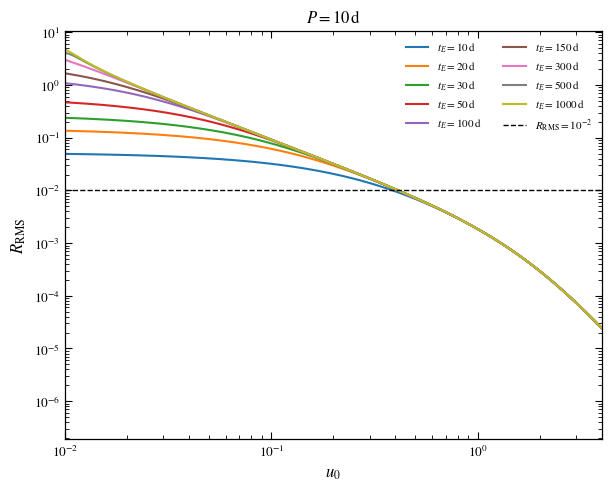

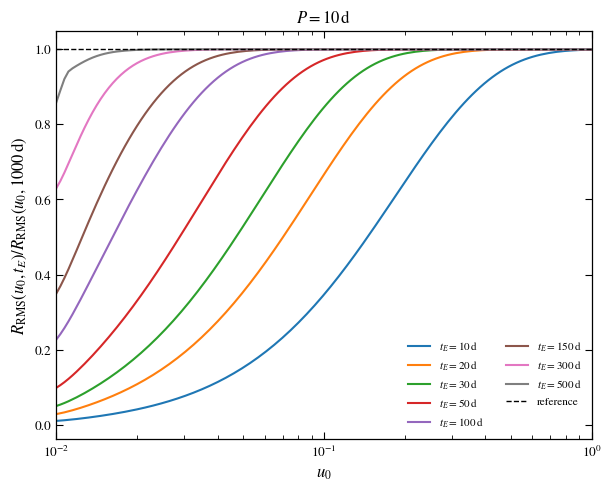

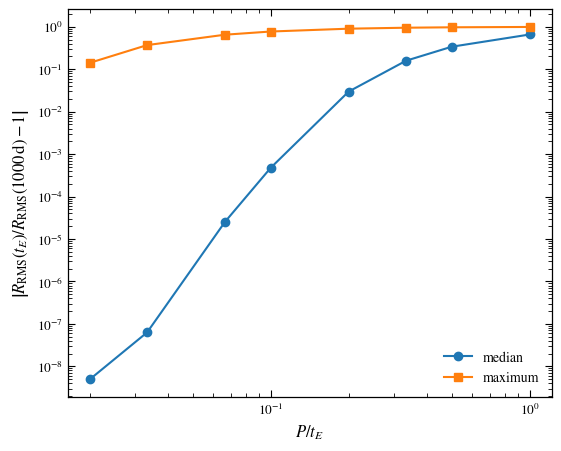

In [9]:
# ============================================================
# VERIFY FAST-ORBIT ASYMPTOTIC REGIME
#
# At fixed:
#
#       P = 10 days
#
# compare:
#
#       R_RMS(u0, tE)
#
# for several Einstein timescales.
#
# Reference:
#
#       tE_ref = 1000 days
#
# We study:
#
#       R_RMS(u0,tE) / R_RMS(u0,tE_ref)
#
# If the fast-orbit regime is reached, this ratio should
# approach unity as P/tE -> 0.
#
# This block assumes that `results` has already been created
# by the previous script.
# ============================================================


import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# CONFIGURATION
# ============================================================

P_TARGET = 10.0

tE_compare = [
    10,
    20,
    30,
    50,
    100,
    150,
    300,
    500,
    1000,
]

tE_reference = 1000.0

threshold = 1e-2


# ------------------------------------------------------------
# u0 interval used for quantitative convergence statistics.
#
# The threshold crossing occurs near u0 ~ 0.41, so this
# interval includes the physically interesting region.
# ------------------------------------------------------------

U0_STATS_MIN = 1e-2
U0_STATS_MAX = 1.0


# ============================================================
# FIND RESULT FOR A GIVEN tE
# ============================================================

def get_result_for_tE(results, tE):

    for result in results:

        if np.isclose(
            result["tE_true"],
            tE,
        ):

            return result

    raise ValueError(
        f"No result found for tE={tE:g} d"
    )


# ============================================================
# EXTRACT RMS(u0) AT FIXED P
# ============================================================

def get_RMS_slice_at_P(
    result,
    P_target,
):

    u0 = np.asarray(
        result["u0_grid"],
        dtype=float,
    )

    P_grid = np.asarray(
        result["P_grid"],
        dtype=float,
    )

    RMS_map = np.asarray(
        result["metric_map"],
        dtype=float,
    )


    # --------------------------------------------------------
    # Find closest simulated period
    # --------------------------------------------------------

    jP = np.argmin(
        np.abs(
            P_grid - P_target
        )
    )


    P_actual = P_grid[
        jP
    ]


    RMS_slice = RMS_map[
        :,
        jP
    ].copy()


    return (
        u0,
        RMS_slice,
        P_actual,
    )


# ============================================================
# FIND RMS = threshold CROSSING
#
# Interpolate in log RMS -- log u0.
# ============================================================

def find_threshold_crossings(
    u0,
    RMS,
    threshold=1e-2,
):

    valid = (
        np.isfinite(u0)
        &
        np.isfinite(RMS)
        &
        (u0 > 0)
        &
        (RMS > 0)
    )


    u = u0[
        valid
    ]


    r = RMS[
        valid
    ]


    order = np.argsort(
        u
    )

    u = u[
        order
    ]

    r = r[
        order
    ]


    f = (
        np.log10(r)
        -
        np.log10(threshold)
    )


    crossings = []


    for i in range(
        len(u) - 1
    ):


        if np.isclose(
            f[i],
            0.0,
        ):

            crossings.append(
                u[i]
            )

            continue


        if (
            f[i]
            *
            f[i + 1]
            <
            0
        ):

            x1 = np.log10(
                u[i]
            )

            x2 = np.log10(
                u[i + 1]
            )


            y1 = f[i]
            y2 = f[i + 1]


            xcross = (
                x1
                -
                y1
                *
                (x2 - x1)
                /
                (y2 - y1)
            )


            crossings.append(
                10**xcross
            )


    return crossings


# ============================================================
# REFERENCE CURVE
# ============================================================

result_ref = get_result_for_tE(
    results,
    tE_reference,
)


u0_ref, RMS_ref, P_ref = get_RMS_slice_at_P(
    result_ref,
    P_TARGET,
)


print()

print("=" * 90)

print("FAST-ORBIT CONVERGENCE TEST")

print("=" * 90)

print(
    f"Requested P      = {P_TARGET:g} d"
)

print(
    f"Reference tE     = {tE_reference:g} d"
)

print(
    f"Actual P used    = {P_ref:g} d"
)

print("=" * 90)


# ============================================================
# STORAGE
# ============================================================

curves = {}


# ============================================================
# EXTRACT ALL CURVES
# ============================================================

for tE in tE_compare:


    result = get_result_for_tE(
        results,
        tE,
    )


    u0, RMS, P_actual = get_RMS_slice_at_P(
        result,
        P_TARGET,
    )


    # --------------------------------------------------------
    # Interpolate each curve onto reference u0 grid if needed.
    #
    # We interpolate log RMS versus log u0.
    # --------------------------------------------------------

    valid = (
        np.isfinite(u0)
        &
        np.isfinite(RMS)
        &
        (u0 > 0)
        &
        (RMS > 0)
    )


    if np.count_nonzero(
        valid
    ) < 2:

        continue


    logu = np.log10(
        u0[
            valid
        ]
    )


    logR = np.log10(
        RMS[
            valid
        ]
    )


    order = np.argsort(
        logu
    )


    logu = logu[
        order
    ]

    logR = logR[
        order
    ]


    RMS_on_ref = np.full_like(
        u0_ref,
        np.nan,
        dtype=float,
    )


    inside = (
        (u0_ref >= 10**logu.min())
        &
        (u0_ref <= 10**logu.max())
    )


    RMS_on_ref[
        inside
    ] = 10**np.interp(

        np.log10(
            u0_ref[
                inside
            ]
        ),

        logu,

        logR,
    )


    curves[
        float(tE)
    ] = {

        "u0":
            u0_ref.copy(),

        "RMS":
            RMS_on_ref,

        "P":
            P_actual,
    }


# ============================================================
# REFERENCE RMS ON THE COMMON GRID
# ============================================================

RMS_reference = curves[
    float(
        tE_reference
    )
][
    "RMS"
]


# ============================================================
# PRINT QUANTITATIVE CONVERGENCE
# ============================================================

print()

print(
    "Comparison with tE = "
    f"{tE_reference:g} d"
)

print()


header = (
    f"{'tE [d]':>8} "
    f"{'P/tE':>10} "
    f"{'u0 cross':>12} "
    f"{'median |R-1|':>16} "
    f"{'max |R-1|':>14} "
    f"{'RMS log diff':>14}"
)

print(
    header
)

print(
    "-" * len(header)
)


for tE in tE_compare:


    if float(tE) not in curves:

        continue


    RMS_current = curves[
        float(tE)
    ][
        "RMS"
    ]


    P_actual = curves[
        float(tE)
    ][
        "P"
    ]


    # --------------------------------------------------------
    # Common valid points
    # --------------------------------------------------------

    valid = (
        np.isfinite(
            RMS_current
        )
        &
        np.isfinite(
            RMS_reference
        )
        &
        (
            RMS_current > 0
        )
        &
        (
            RMS_reference > 0
        )
        &
        (
            u0_ref >= U0_STATS_MIN
        )
        &
        (
            u0_ref <= U0_STATS_MAX
        )
    )


    ratio = (
        RMS_current[
            valid
        ]
        /
        RMS_reference[
            valid
        ]
    )


    fractional_difference = np.abs(
        ratio - 1.0
    )


    median_difference = np.nanmedian(
        fractional_difference
    )


    max_difference = np.nanmax(
        fractional_difference
    )


    # --------------------------------------------------------
    # RMS difference in log space
    #
    # Zero means identical curves.
    # --------------------------------------------------------

    rms_log_difference = np.sqrt(

        np.nanmean(

            (
                np.log10(
                    RMS_current[
                        valid
                    ]
                )
                -
                np.log10(
                    RMS_reference[
                        valid
                    ]
                )
            )**2
        )
    )


    crossings = find_threshold_crossings(

        u0_ref,

        RMS_current,

        threshold=threshold,
    )


    if len(
        crossings
    ) > 0:

        crossing_string = (
            f"{crossings[0]:.6f}"
        )

    else:

        crossing_string = (
            "none"
        )


    print(

        f"{tE:8.1f} "

        f"{P_actual/tE:10.4g} "

        f"{crossing_string:>12} "

        f"{median_difference:16.3e} "

        f"{max_difference:14.3e} "

        f"{rms_log_difference:14.3e}"
    )


# ============================================================
# FIGURE 1
#
# RMS(u0) AT FIXED P
# ============================================================

fig1, ax1 = plt.subplots(

    figsize=(
        6.0,
        4.8,
    ),

    constrained_layout=True,
)


for tE in tE_compare:


    if float(tE) not in curves:

        continue


    ax1.plot(

        curves[
            float(tE)
        ][
            "u0"
        ],

        curves[
            float(tE)
        ][
            "RMS"
        ],

        lw=1.5,

        label=(
            rf"$t_E={tE:g}\,\mathrm{{d}}$"
        ),
    )


# ============================================================
# RMS THRESHOLD
# ============================================================

ax1.axhline(

    threshold,

    ls="--",

    lw=1.0,

    color="black",

    label=(
        r"$R_{\rm RMS}=10^{-2}$"
    ),
)


ax1.set_xscale(
    "log"
)

ax1.set_yscale(
    "log"
)


ax1.set_xlim(
    U0_STATS_MIN,
    4.0,
)


ax1.set_xlabel(
    r"$u_0$"
)


ax1.set_ylabel(
    r"$R_{\rm RMS}$"
)


ax1.set_title(

    rf"$P={P_TARGET:g}\,\mathrm{{d}}$"
)


ax1.legend(

    frameon=False,

    fontsize=8,

    ncol=2,
)


ax1.grid(
    False
)


# ============================================================
# FIGURE 2
#
# RATIO RELATIVE TO tE = 1000 d
# ============================================================

fig2, ax2 = plt.subplots(

    figsize=(
        6.0,
        4.8,
    ),

    constrained_layout=True,
)


for tE in tE_compare:


    if (
        float(tE)
        not in curves
    ):

        continue


    if np.isclose(
        tE,
        tE_reference,
    ):

        continue


    RMS_current = curves[
        float(tE)
    ][
        "RMS"
    ]


    ratio = (
        RMS_current
        /
        RMS_reference
    )


    ax2.plot(

        u0_ref,

        ratio,

        lw=1.5,

        label=(
            rf"$t_E={tE:g}\,\mathrm{{d}}$"
        ),
    )


# ============================================================
# UNITY
# ============================================================

ax2.axhline(

    1.0,

    ls="--",

    lw=1.0,

    color="black",

    label="reference",
)


ax2.set_xscale(
    "log"
)


ax2.set_xlim(
    U0_STATS_MIN,
    1.0,
)


ax2.set_xlabel(
    r"$u_0$"
)


ax2.set_ylabel(
    r"$R_{\rm RMS}(u_0,t_E)"
    r"/R_{\rm RMS}(u_0,1000\,{\rm d})$"
)


ax2.set_title(

    rf"$P={P_TARGET:g}\,\mathrm{{d}}$"
)


ax2.legend(

    frameon=False,

    fontsize=8,

    ncol=2,
)


ax2.grid(
    False
)


# ============================================================
# FIGURE 3
#
# MAXIMUM AND MEDIAN DIFFERENCE FROM ASYMPTOTIC CURVE
# AS A FUNCTION OF P/tE
# ============================================================

x_values = []

median_values = []

max_values = []


for tE in tE_compare:


    if (
        float(tE)
        not in curves
    ):

        continue


    if np.isclose(
        tE,
        tE_reference,
    ):

        continue


    RMS_current = curves[
        float(tE)
    ][
        "RMS"
    ]


    valid = (
        np.isfinite(
            RMS_current
        )
        &
        np.isfinite(
            RMS_reference
        )
        &
        (
            RMS_current > 0
        )
        &
        (
            RMS_reference > 0
        )
        &
        (
            u0_ref >= U0_STATS_MIN
        )
        &
        (
            u0_ref <= U0_STATS_MAX
        )
    )


    fractional_difference = np.abs(

        RMS_current[
            valid
        ]
        /
        RMS_reference[
            valid
        ]

        -
        1.0
    )


    x_values.append(
        P_TARGET
        /
        tE
    )


    median_values.append(
        np.nanmedian(
            fractional_difference
        )
    )


    max_values.append(
        np.nanmax(
            fractional_difference
        )
    )


x_values = np.asarray(
    x_values
)


median_values = np.asarray(
    median_values
)


max_values = np.asarray(
    max_values
)


order = np.argsort(
    x_values
)


fig3, ax3 = plt.subplots(

    figsize=(
        5.5,
        4.4,
    ),

    constrained_layout=True,
)


ax3.plot(

    x_values[
        order
    ],

    median_values[
        order
    ],

    marker="o",

    lw=1.5,

    label="median",
)


ax3.plot(

    x_values[
        order
    ],

    max_values[
        order
    ],

    marker="s",

    lw=1.5,

    label="maximum",
)


ax3.set_xscale(
    "log"
)


ax3.set_yscale(
    "log"
)


ax3.set_xlabel(
    r"$P/t_E$"
)


ax3.set_ylabel(

    r"$\left|"
    r"R_{\rm RMS}(t_E)"
    r"/R_{\rm RMS}(1000\,{\rm d})"
    r"-1"
    r"\right|$"
)


ax3.legend(
    frameon=False
)


ax3.grid(
    False
)


plt.show()


LOCAL FAST-ORBIT TIMESCALE TEST
Requested P  = 10 d
Actual P     = 10 d
Reference tE = 1000 d
u0 interval  = 0.01 -- 0.5

CORRELATION WITH CONVERGENCE ERROR
P/tE:
    Spearman rho = 0.712433
    p-value      = 4.046e-193

P/(u0 tE):
    Spearman rho = 0.990095
    p-value      = 0.000e+00

TYPICAL BINNED SCATTER
P/tE       : 6.7274 dex
P/(u0 tE)  : 0.7806 dex

P/(u0 tE) gives the tighter collapse.

ONSET OF THE FAST-ORBIT REGIME

Tolerance = 10.0%
median critical P/(u0 tE) = 2.095
16--84 percentile = 1.662 -- 2.469

Tolerance = 3.0%
median critical P/(u0 tE) = 1.501
16--84 percentile = 1.222 -- 1.8

Tolerance = 1.0%
median critical P/(u0 tE) = 1.218
16--84 percentile = 1.024 -- 1.43


First rows of point-by-point dataset:


,tE,u0,P,P_over_tE,P_over_u0tE,RMS,RMS_ref,delta_R,delta_plot
0,10.0,0.010000,10.0,1.0,100.000000,0.049346,4.772043,0.989659,0.989659
1,10.0,0.010353,10.0,1.0,96.588322,0.049258,4.422518,0.988862,0.988862
2,10.0,0.010719,10.0,1.0,93.293040,0.049168,4.081608,0.987954,0.987954
3,10.0,0.011098,10.0,1.0,90.110183,0.049074,3.759783,0.986948,0.986948
4,10.0,0.011490,10.0,1.0,87.035914,0.048978,3.462504,0.985855,0.985855
5,10.0,0.011895,10.0,1.0,84.066529,0.048878,3.191542,0.984685,0.984685
6,10.0,0.012316,10.0,1.0,81.198450,0.048775,2.946358,0.983446,0.983446
7,10.0,0.012751,10.0,1.0,78.428221,0.048669,2.725180,0.982141,0.982141
8,10.0,0.013201,10.0,1.0,75.752503,0.048559,2.525707,0.980774,0.980774
9,10.0,0.013667,10.0,1.0,73.168071,0.048445,2.345537,0.979346,0.979346



Critical convergence table:


,u0,tolerance,xcrit_local,xcrit_global,tE
0,0.010000,0.10,1.333333,0.013333,750.0
1,0.010353,0.10,1.287844,0.013333,750.0
2,0.010353,0.03,1.287844,0.013333,750.0
3,0.010353,0.01,1.287844,0.013333,750.0
4,0.010719,0.10,1.865861,0.020000,500.0
...,...,...,...,...,...
322,0.471375,0.03,1.060726,0.500000,20.0
323,0.471375,0.01,1.060726,0.500000,20.0
324,0.488025,0.10,2.049075,1.000000,10.0
325,0.488025,0.03,1.024537,0.500000,20.0


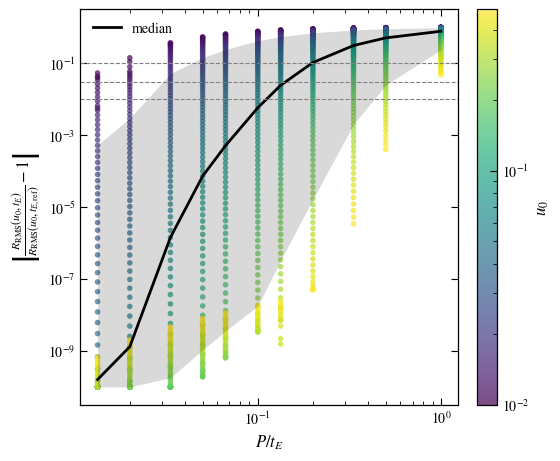

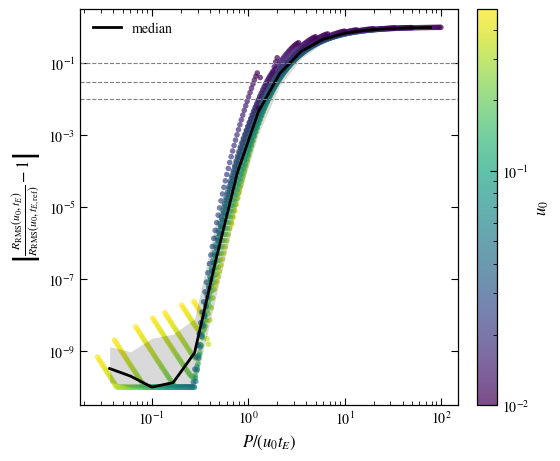

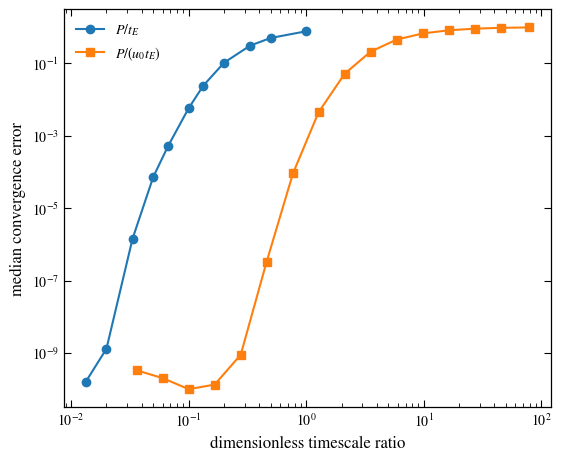

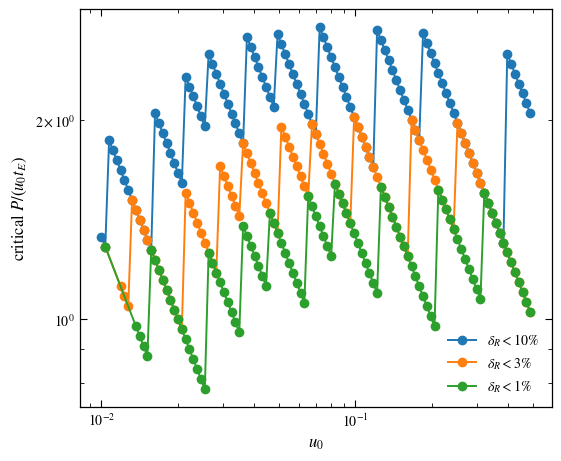

In [10]:
# ============================================================
# TEST OF THE LOCAL FAST-ORBIT TIMESCALE
#
# Hypothesis:
#
#   For high-magnification microlensing events, the relevant
#   timescale near the peak is approximately
#
#       t_peak ~ u0 * tE
#
#   Therefore the transition to the fast-orbit regime may be
#   better organized by
#
#       x_local = P / (u0 * tE)
#
#   rather than only by
#
#       x_global = P / tE.
#
#
# We do NOT try to collapse RMS itself, because changing u0
# also changes the spatial scale xi_E/u0.
#
# Instead, at fixed P and fixed u0, we compare each RMS with
# the long-tE reference:
#
#       delta_R =
#       | RMS(u0,tE) / RMS(u0,tE_ref) - 1 |
#
# If x_local is the relevant temporal variable, points with
# different u0 and tE should approximately organize onto a
# common relation delta_R(x_local).
#
# ============================================================


import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from scipy.stats import spearmanr


# ============================================================
# CONFIGURATION
# ============================================================

P_TARGET = 10.0                 # days

tE_reference = 1000.0           # days


tE_compare = np.array(
    [
        10,
        20,
        30,
        50,
        75,
        100,
        150,
        200,
        300,
        500,
        750,
        1000,
    ],
    dtype=float,
)


# ------------------------------------------------------------
# Restrict to region where t_peak ~ u0 tE is meaningful.
#
# u0 << 1 is the cleanest regime.
# Initially use u0 <= 0.5.
# ------------------------------------------------------------

U0_MIN = 1e-2
U0_MAX = 5e-1


# ------------------------------------------------------------
# Very small delta values can reach numerical precision.
#
# Floor used only for logarithmic plots/correlations.
# ------------------------------------------------------------

DELTA_FLOOR = 1e-10


# ------------------------------------------------------------
# Convergence levels to test.
# ------------------------------------------------------------

CONVERGENCE_LEVELS = [
    0.10,     # 10%
    0.03,     # 3%
    0.01,     # 1%
]


# ------------------------------------------------------------
# Number of logarithmic bins for collapse curves.
# ------------------------------------------------------------

N_BINS = 16


# ============================================================
# PAPER STYLE
# ============================================================

plt.rcParams.update({

    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",

    "font.size": 10,

    "axes.labelsize": 12,

    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    "axes.linewidth": 0.9,

    "xtick.direction": "in",
    "ytick.direction": "in",

    "xtick.top": True,
    "ytick.right": True,

    "xtick.major.size": 5,
    "ytick.major.size": 5,

    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
})


# ============================================================
# HELPERS
# ============================================================

def get_result_for_tE(
    results,
    tE,
):

    for result in results:

        if np.isclose(
            result["tE_true"],
            tE,
        ):

            return result


    raise ValueError(
        f"No result found for tE={tE:g} d"
    )


# ============================================================
# EXTRACT RMS(u0) AT FIXED P
# ============================================================

def get_RMS_slice_at_P(
    result,
    P_target,
):

    u0 = np.asarray(
        result["u0_grid"],
        dtype=float,
    )


    P_grid = np.asarray(
        result["P_grid"],
        dtype=float,
    )


    RMS_map = np.asarray(
        result["metric_map"],
        dtype=float,
    )


    jP = np.argmin(
        np.abs(
            P_grid
            -
            P_target
        )
    )


    P_actual = P_grid[
        jP
    ]


    RMS_slice = RMS_map[
        :,
        jP
    ].copy()


    return (
        u0,
        RMS_slice,
        P_actual,
    )


# ============================================================
# REFERENCE CURVE
# ============================================================

result_ref = get_result_for_tE(
    results,
    tE_reference,
)


u0_ref, RMS_ref_raw, P_actual_ref = get_RMS_slice_at_P(
    result_ref,
    P_TARGET,
)


print()

print("=" * 90)

print("LOCAL FAST-ORBIT TIMESCALE TEST")

print("=" * 90)

print(
    f"Requested P  = {P_TARGET:g} d"
)

print(
    f"Actual P     = {P_actual_ref:g} d"
)

print(
    f"Reference tE = {tE_reference:g} d"
)

print(
    f"u0 interval  = {U0_MIN:g} -- {U0_MAX:g}"
)

print("=" * 90)


# ============================================================
# INTERPOLATION FUNCTION
#
# Interpolate log RMS versus log u0.
# ============================================================

def interpolate_RMS_to_reference(
    u0,
    RMS,
    u0_reference,
):

    valid = (
        np.isfinite(u0)
        &
        np.isfinite(RMS)
        &
        (u0 > 0)
        &
        (RMS > 0)
    )


    if np.count_nonzero(
        valid
    ) < 2:

        return np.full_like(
            u0_reference,
            np.nan,
            dtype=float,
        )


    logu = np.log10(
        u0[
            valid
        ]
    )


    logR = np.log10(
        RMS[
            valid
        ]
    )


    order = np.argsort(
        logu
    )


    logu = logu[
        order
    ]


    logR = logR[
        order
    ]


    out = np.full_like(
        u0_reference,
        np.nan,
        dtype=float,
    )


    inside = (
        (u0_reference >= 10**logu.min())
        &
        (u0_reference <= 10**logu.max())
    )


    out[
        inside
    ] = 10**np.interp(

        np.log10(
            u0_reference[
                inside
            ]
        ),

        logu,

        logR,
    )


    return out


# ============================================================
# PUT REFERENCE ON ITSELF
# ============================================================

RMS_reference = interpolate_RMS_to_reference(

    u0_ref,

    RMS_ref_raw,

    u0_ref,
)


# ============================================================
# BUILD POINT-BY-POINT DATASET
#
# Every row contains one (u0,tE) point.
# ============================================================

rows = []


for tE in tE_compare:


    # --------------------------------------------------------
    # Do not include reference itself:
    #
    # delta_R = 0 by definition there.
    # --------------------------------------------------------

    if np.isclose(
        tE,
        tE_reference,
    ):

        continue


    result = get_result_for_tE(
        results,
        tE,
    )


    u0_current, RMS_current_raw, P_actual = (
        get_RMS_slice_at_P(
            result,
            P_TARGET,
        )
    )


    RMS_current = interpolate_RMS_to_reference(

        u0_current,

        RMS_current_raw,

        u0_ref,
    )


    # --------------------------------------------------------
    # Common valid points
    # --------------------------------------------------------

    valid = (
        np.isfinite(
            RMS_current
        )
        &
        np.isfinite(
            RMS_reference
        )
        &
        (RMS_current > 0)
        &
        (RMS_reference > 0)
        &
        (u0_ref >= U0_MIN)
        &
        (u0_ref <= U0_MAX)
    )


    for u0, rms, rms_ref in zip(

        u0_ref[
            valid
        ],

        RMS_current[
            valid
        ],

        RMS_reference[
            valid
        ],
    ):


        delta_R = np.abs(
            rms
            /
            rms_ref
            -
            1.0
        )


        x_global = (
            P_actual
            /
            tE
        )


        x_local = (
            P_actual
            /
            (
                u0
                *
                tE
            )
        )


        rows.append(
            {

                "tE":
                    float(
                        tE
                    ),

                "u0":
                    float(
                        u0
                    ),

                "P":
                    float(
                        P_actual
                    ),

                "P_over_tE":
                    float(
                        x_global
                    ),

                "P_over_u0tE":
                    float(
                        x_local
                    ),

                "RMS":
                    float(
                        rms
                    ),

                "RMS_ref":
                    float(
                        rms_ref
                    ),

                "delta_R":
                    float(
                        delta_R
                    ),
            }
        )


df_local = pd.DataFrame(
    rows
)


if len(
    df_local
) == 0:

    raise RuntimeError(
        "No valid comparison points."
    )


# ============================================================
# FLOOR ONLY FOR LOG DIAGNOSTICS
# ============================================================

df_local[
    "delta_plot"
] = np.maximum(

    df_local[
        "delta_R"
    ],

    DELTA_FLOOR,
)


# ============================================================
# CORRELATIONS
#
# Compare how strongly the convergence is organized by
#
#       P/tE
#
# versus
#
#       P/(u0 tE).
# ============================================================

log_delta = np.log10(
    df_local[
        "delta_plot"
    ]
)


log_global = np.log10(
    df_local[
        "P_over_tE"
    ]
)


log_local = np.log10(
    df_local[
        "P_over_u0tE"
    ]
)


rho_global, p_global = spearmanr(
    log_global,
    log_delta,
)


rho_local, p_local = spearmanr(
    log_local,
    log_delta,
)


print()

print("=" * 90)

print("CORRELATION WITH CONVERGENCE ERROR")

print("=" * 90)


print(
    f"P/tE:"
)

print(
    f"    Spearman rho = {rho_global:.6f}"
)

print(
    f"    p-value      = {p_global:.3e}"
)


print()


print(
    f"P/(u0 tE):"
)

print(
    f"    Spearman rho = {rho_local:.6f}"
)

print(
    f"    p-value      = {p_local:.3e}"
)


print("=" * 90)


# ============================================================
# LOGARITHMIC BINNING
#
# For each candidate scaling variable calculate:
#
# median(delta_R)
# 16th percentile
# 84th percentile
#
# ============================================================

def binned_statistics(
    x,
    y,
    n_bins=16,
):


    valid = (
        np.isfinite(x)
        &
        np.isfinite(y)
        &
        (x > 0)
        &
        (y > 0)
    )


    x = np.asarray(
        x[
            valid
        ]
    )


    y = np.asarray(
        y[
            valid
        ]
    )


    logx = np.log10(
        x
    )


    edges = np.linspace(

        np.min(
            logx
        ),

        np.max(
            logx
        ),

        n_bins + 1,
    )


    centers = []

    medians = []

    q16s = []

    q84s = []

    counts = []


    for i in range(
        n_bins
    ):


        select = (
            (logx >= edges[i])
            &
            (logx < edges[i + 1])
        )


        # Include right edge in final bin
        if i == n_bins - 1:

            select = (
                (logx >= edges[i])
                &
                (logx <= edges[i + 1])
            )


        if np.count_nonzero(
            select
        ) < 3:

            continue


        xb = x[
            select
        ]


        yb = y[
            select
        ]


        centers.append(

            10**
            np.mean(
                np.log10(
                    xb
                )
            )
        )


        medians.append(
            np.median(
                yb
            )
        )


        q16s.append(
            np.percentile(
                yb,
                16,
            )
        )


        q84s.append(
            np.percentile(
                yb,
                84,
            )
        )


        counts.append(
            len(
                yb
            )
        )


    return {

        "x":
            np.asarray(
                centers
            ),

        "median":
            np.asarray(
                medians
            ),

        "q16":
            np.asarray(
                q16s
            ),

        "q84":
            np.asarray(
                q84s
            ),

        "N":
            np.asarray(
                counts
            ),
    }


stats_global = binned_statistics(

    df_local[
        "P_over_tE"
    ].to_numpy(),

    df_local[
        "delta_plot"
    ].to_numpy(),

    n_bins=N_BINS,
)


stats_local = binned_statistics(

    df_local[
        "P_over_u0tE"
    ].to_numpy(),

    df_local[
        "delta_plot"
    ].to_numpy(),

    n_bins=N_BINS,
)


# ============================================================
# QUANTIFY BIN SCATTER
#
# Width of 16--84 percentile interval in log10(delta_R).
#
# Smaller width means a better collapse.
# ============================================================

def typical_log_scatter(
    stats,
):


    valid = (
        np.isfinite(
            stats[
                "q16"
            ]
        )
        &
        np.isfinite(
            stats[
                "q84"
            ]
        )
        &
        (
            stats[
                "q16"
            ] > 0
        )
        &
        (
            stats[
                "q84"
            ] > 0
        )
    )


    widths = (

        np.log10(
            stats[
                "q84"
            ][
                valid
            ]
        )

        -

        np.log10(
            stats[
                "q16"
            ][
                valid
            ]
        )
    )


    return np.median(
        widths
    )


scatter_global = typical_log_scatter(
    stats_global
)


scatter_local = typical_log_scatter(
    stats_local
)


print()

print("=" * 90)

print("TYPICAL BINNED SCATTER")

print("=" * 90)


print(
    f"P/tE       : {scatter_global:.4f} dex"
)


print(
    f"P/(u0 tE)  : {scatter_local:.4f} dex"
)


print()

if (
    scatter_local
    <
    scatter_global
):

    print(
        "P/(u0 tE) gives the tighter collapse."
    )

else:

    print(
        "P/(u0 tE) does NOT improve the collapse."
    )


print("=" * 90)


# ============================================================
# FIGURE 1
#
# CONVERGENCE ERROR VS P/tE
#
# This is the control experiment.
# ============================================================

fig1, ax1 = plt.subplots(

    figsize=(
        5.5,
        4.5,
    ),

    constrained_layout=True,
)


norm_u0 = mcolors.LogNorm(

    vmin=df_local[
        "u0"
    ].min(),

    vmax=df_local[
        "u0"
    ].max(),
)


sc1 = ax1.scatter(

    df_local[
        "P_over_tE"
    ],

    df_local[
        "delta_plot"
    ],

    c=df_local[
        "u0"
    ],

    cmap="viridis",

    norm=norm_u0,

    s=16,

    alpha=0.70,

    edgecolors="none",

    rasterized=True,
)


# ------------------------------------------------------------
# Median trend
# ------------------------------------------------------------

ax1.plot(

    stats_global[
        "x"
    ],

    stats_global[
        "median"
    ],

    lw=2.0,

    color="black",

    label="median",
)


ax1.fill_between(

    stats_global[
        "x"
    ],

    stats_global[
        "q16"
    ],

    stats_global[
        "q84"
    ],

    alpha=0.15,

    color="black",

    linewidth=0,
)


# ------------------------------------------------------------
# Reference convergence levels
# ------------------------------------------------------------

for level in CONVERGENCE_LEVELS:

    ax1.axhline(

        level,

        ls="--",

        lw=0.8,

        color="gray",
    )


ax1.set_xscale(
    "log"
)


ax1.set_yscale(
    "log"
)


ax1.set_xlabel(
    r"$P/t_E$"
)


ax1.set_ylabel(

    r"$\left|"
    r"\frac{R_{\rm RMS}(u_0,t_E)}"
    r"{R_{\rm RMS}(u_0,t_{E,\rm ref})}"
    r"-1"
    r"\right|$"
)


ax1.legend(
    frameon=False
)


cbar1 = fig1.colorbar(

    sc1,

    ax=ax1,
)


cbar1.set_label(
    r"$u_0$"
)


ax1.grid(
    False
)


# ============================================================
# FIGURE 2
#
# CONVERGENCE ERROR VS LOCAL TIMESCALE
#
# Main experiment.
# ============================================================

fig2, ax2 = plt.subplots(

    figsize=(
        5.5,
        4.5,
    ),

    constrained_layout=True,
)


sc2 = ax2.scatter(

    df_local[
        "P_over_u0tE"
    ],

    df_local[
        "delta_plot"
    ],

    c=df_local[
        "u0"
    ],

    cmap="viridis",

    norm=norm_u0,

    s=16,

    alpha=0.70,

    edgecolors="none",

    rasterized=True,
)


# ------------------------------------------------------------
# Median trend
# ------------------------------------------------------------

ax2.plot(

    stats_local[
        "x"
    ],

    stats_local[
        "median"
    ],

    lw=2.0,

    color="black",

    label="median",
)


ax2.fill_between(

    stats_local[
        "x"
    ],

    stats_local[
        "q16"
    ],

    stats_local[
        "q84"
    ],

    alpha=0.15,

    color="black",

    linewidth=0,
)


for level in CONVERGENCE_LEVELS:

    ax2.axhline(

        level,

        ls="--",

        lw=0.8,

        color="gray",
    )


ax2.set_xscale(
    "log"
)


ax2.set_yscale(
    "log"
)


ax2.set_xlabel(
    r"$P/(u_0t_E)$"
)


ax2.set_ylabel(

    r"$\left|"
    r"\frac{R_{\rm RMS}(u_0,t_E)}"
    r"{R_{\rm RMS}(u_0,t_{E,\rm ref})}"
    r"-1"
    r"\right|$"
)


ax2.legend(
    frameon=False
)


cbar2 = fig2.colorbar(

    sc2,

    ax=ax2,
)


cbar2.set_label(
    r"$u_0$"
)


ax2.grid(
    False
)


# ============================================================
# FIGURE 3
#
# DIRECT COMPARISON OF BINNED COLLAPSE
#
# We normalize each x-axis only conceptually:
# both are dimensionless and plotted as-is.
# ============================================================

fig3, ax3 = plt.subplots(

    figsize=(
        5.5,
        4.5,
    ),

    constrained_layout=True,
)


ax3.plot(

    stats_global[
        "x"
    ],

    stats_global[
        "median"
    ],

    marker="o",

    lw=1.5,

    label=r"$P/t_E$",
)


ax3.plot(

    stats_local[
        "x"
    ],

    stats_local[
        "median"
    ],

    marker="s",

    lw=1.5,

    label=r"$P/(u_0t_E)$",
)


ax3.set_xscale(
    "log"
)


ax3.set_yscale(
    "log"
)


ax3.set_xlabel(
    "dimensionless timescale ratio"
)


ax3.set_ylabel(
    r"median convergence error"
)


ax3.legend(
    frameon=False
)


ax3.grid(
    False
)


# ============================================================
# ============================================================
#
# SECOND TEST:
#
# AT WHAT VALUE OF P/(u0 tE) IS THE ASYMPTOTIC REGIME
# REACHED?
#
# For each u0, find the largest x_local for which
#
#       delta_R <= tolerance.
#
# If x_local is the correct scaling variable, this critical
# value should be approximately independent of u0.
#
# ============================================================
# ============================================================

critical_rows = []


u0_values = np.sort(
    df_local[
        "u0"
    ].unique()
)


for u0 in u0_values:


    subset = df_local[

        np.isclose(
            df_local[
                "u0"
            ],
            u0,
        )

    ].copy()


    if len(
        subset
    ) == 0:

        continue


    for tolerance in CONVERGENCE_LEVELS:


        converged = subset[

            subset[
                "delta_R"
            ]
            <=
            tolerance

        ]


        if len(
            converged
        ) == 0:

            continue


        # ----------------------------------------------------
        # Largest x_local that already satisfies convergence.
        #
        # This represents the approximate onset of the
        # asymptotic regime.
        # ----------------------------------------------------

        row = converged.loc[

            converged[
                "P_over_u0tE"
            ].idxmax()

        ]


        critical_rows.append(
            {

                "u0":
                    float(
                        u0
                    ),

                "tolerance":
                    float(
                        tolerance
                    ),

                "xcrit_local":
                    float(
                        row[
                            "P_over_u0tE"
                        ]
                    ),

                "xcrit_global":
                    float(
                        row[
                            "P_over_tE"
                        ]
                    ),

                "tE":
                    float(
                        row[
                            "tE"
                        ]
                    ),
            }
        )


df_critical = pd.DataFrame(
    critical_rows
)


# ============================================================
# PRINT CRITICAL VALUES
# ============================================================

print()

print("=" * 90)

print("ONSET OF THE FAST-ORBIT REGIME")

print("=" * 90)


for tolerance in CONVERGENCE_LEVELS:


    sub = df_critical[

        np.isclose(
            df_critical[
                "tolerance"
            ],
            tolerance,
        )

    ]


    if len(
        sub
    ) == 0:

        continue


    print()

    print(
        f"Tolerance = {100*tolerance:.1f}%"
    )


    print(
        f"median critical P/(u0 tE) = "
        f"{np.median(sub['xcrit_local']):.4g}"
    )


    print(
        f"16--84 percentile = "
        f"{np.percentile(sub['xcrit_local'],16):.4g}"
        f" -- "
        f"{np.percentile(sub['xcrit_local'],84):.4g}"
    )


print()

print("=" * 90)


# ============================================================
# FIGURE 4
#
# CRITICAL LOCAL RATIO VS u0
#
# If curves are approximately horizontal, this strongly
# supports P/(u0 tE) as the relevant convergence variable.
# ============================================================

fig4, ax4 = plt.subplots(

    figsize=(
        5.5,
        4.5,
    ),

    constrained_layout=True,
)


for tolerance in CONVERGENCE_LEVELS:


    sub = df_critical[

        np.isclose(
            df_critical[
                "tolerance"
            ],
            tolerance,
        )

    ].sort_values(
        "u0"
    )


    if len(
        sub
    ) == 0:

        continue


    ax4.plot(

        sub[
            "u0"
        ],

        sub[
            "xcrit_local"
        ],

        marker="o",

        lw=1.4,

        label=(
            rf"$\delta_R<{100*tolerance:.0f}\%$"
        ),
    )


ax4.set_xscale(
    "log"
)


ax4.set_yscale(
    "log"
)


ax4.set_xlabel(
    r"$u_0$"
)


ax4.set_ylabel(
    r"critical $P/(u_0t_E)$"
)


ax4.legend(
    frameon=False
)


ax4.grid(
    False
)


# ============================================================
# DISPLAY DATA TABLE
# ============================================================

print()

print(
    "First rows of point-by-point dataset:"
)

display(
    df_local.head(
        20
    )
)


print()

print(
    "Critical convergence table:"
)

display(
    df_critical
)


plt.show()


LOADING SCANS
tE=   10.0 d   Nfiles=200   success=100.00%   q=0.500
tE=   20.0 d   Nfiles=200   success=100.00%   q=0.500
tE=   30.0 d   Nfiles=200   success=100.00%   q=0.500
tE=   50.0 d   Nfiles=200   success=100.00%   q=0.500
tE=   75.0 d   Nfiles=200   success=100.00%   q=0.500
tE=  100.0 d   Nfiles=200   success=100.00%   q=0.500
tE=  150.0 d   Nfiles=200   success=100.00%   q=0.500
tE=  200.0 d   Nfiles=200   success=100.00%   q=0.500
tE=  300.0 d   Nfiles=200   success=100.00%   q=0.500
tE=  500.0 d   Nfiles=200   success=100.00%   q=0.500
tE=  750.0 d   Nfiles=200   success=100.00%   q=0.500
tE= 1000.0 d   Nfiles=200   success=100.00%   q=0.500

DIMENSIONLESS PLANE
N points = 144000
xi_E/u0 range = 8.734e-04 -- 4.054e+02
P/(u0 tE) range = 1.000e-03 -- 1.000e+06
RMS range = 3.286e-11 -- 5.681e+01

FIGURE 1
/home/anibal-pc/binary_source/results/scan_many_tE_200x200/paper_RMS_threshold_many_tE_POveru0tE.png
/home/anibal-pc/binary_source/results/scan_many_tE_200x200/paper_RMS_thr

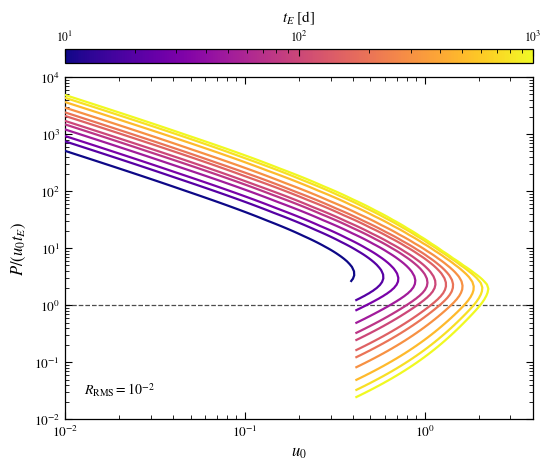

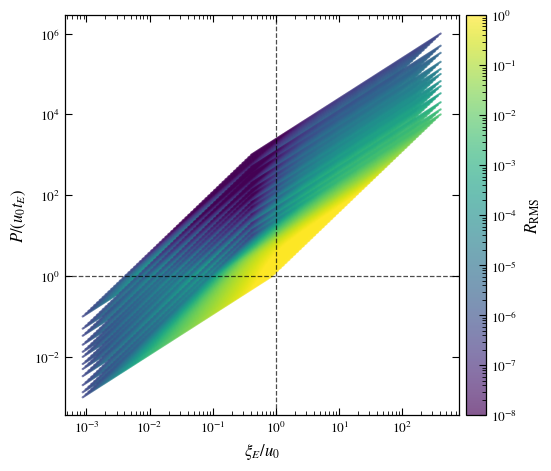

In [13]:
# ============================================================
# LOCAL DIMENSIONLESS COORDINATES
#
# FIGURE 1
# ----------
# R_RMS = 1e-2 contours for many tE in:
#
#       x = u0
#       y = P / (u0 tE)
#
#
# FIGURE 2
# ----------
# All valid simulated points in:
#
#       x = xi_E / u0
#       y = P / (u0 tE)
#
# color = R_RMS
#
#
# IMPORTANT
# ---------
# In the current scan files, the key
#
#       xiE_of_P
#
# stores xi_rel = a_rel / rEhat.
#
# For the luminous primary:
#
#       xi_E = q_M/(1+q_M) * xi_rel
#
# ============================================================


import os
import glob
import re

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from matplotlib.cm import ScalarMappable


# ============================================================
# PAPER STYLE
# ============================================================

plt.rcParams.update({

    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",

    "font.size": 10,

    "axes.labelsize": 12,

    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,

    "axes.linewidth": 0.9,

    "xtick.direction": "in",
    "ytick.direction": "in",

    "xtick.top": True,
    "ytick.right": True,

    "xtick.major.size": 5,
    "ytick.major.size": 5,

    "xtick.minor.size": 3,
    "ytick.minor.size": 3,

    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,
})


# ============================================================
# CONFIGURATION
# ============================================================

home_path = os.path.expanduser("~")


base_directory = os.path.join(
    home_path,
    "binary_source",
    "results",
    "scan_many_tE_200x200",
)


# ============================================================
# tE VALUES
# ============================================================

tE_list = np.array(
    [
        10,
        20,
        30,
        50,
        75,
        100,
        150,
        200,
        300,
        500,
        750,
        1000,
    ],
    dtype=float,
)


# ============================================================
# METRIC
# ============================================================

metric_key = "RMS"

threshold = 1e-2


# ============================================================
# FIGURE 1 AXIS LIMITS
# ============================================================

U0_MIN = 1e-2
U0_MAX = 4.0


# P/(u0 tE)
#
# Start broad. Adjust after seeing the result if desired.
# ============================================================

LOCAL_TIME_MIN = 1e-2
LOCAL_TIME_MAX = 1e4


# ============================================================
# FIGURE 2 AXIS LIMITS
#
# None -> determine automatically from valid data.
# ============================================================

XI_OVER_U0_MIN = None
XI_OVER_U0_MAX = None

LOCAL_TIME_PLANE_MIN = None
LOCAL_TIME_PLANE_MAX = None


# ============================================================
# RMS COLOR SCALE FOR FIGURE 2
# ============================================================

RMS_VMIN = 1e-8
RMS_VMAX = 1e0


# ============================================================
# FIGURE SIZE
# ============================================================

FIGSIZE = (5.4, 4.6)


# ============================================================
# OPTIONAL REFERENCE LINES
# ============================================================

SHOW_UNITY_LINES = True


# ============================================================
# OUTPUT FILES
# ============================================================

output_contours_png = os.path.join(
    base_directory,
    "paper_RMS_threshold_many_tE_POveru0tE.png",
)

output_contours_pdf = os.path.join(
    base_directory,
    "paper_RMS_threshold_many_tE_POveru0tE.pdf",
)


output_plane_png = os.path.join(
    base_directory,
    "paper_RMS_xiOveru0_vs_POveru0tE.png",
)

output_plane_pdf = os.path.join(
    base_directory,
    "paper_RMS_xiOveru0_vs_POveru0tE.pdf",
)


# ============================================================
# HELPERS
# ============================================================

def extract_u0_index(filename):

    base = os.path.basename(
        filename
    )

    match = re.fullmatch(
        r"scan_kepler_u0_(\d+)\.npz",
        base,
    )

    if match is None:

        raise ValueError(
            f"No pude extraer el índice desde {base}"
        )

    return int(
        match.group(1)
    )


def format_tE_label(tE):

    label = f"{float(tE):g}"

    return label.replace(
        ".",
        "p",
    )


# ============================================================
# LOAD ONE tE SCAN
# ============================================================

def load_scan_for_tE(
    tE_true,
    base_directory,
    metric_key="RMS",
):

    label = format_tE_label(
        tE_true
    )


    directory = os.path.join(
        base_directory,
        f"scan_u0_tE{label}",
    )


    pattern = os.path.join(
        directory,
        "scan_kepler_u0_*.npz",
    )


    files = sorted(
        glob.glob(
            pattern
        )
    )


    if len(files) == 0:

        raise FileNotFoundError(
            f"No files found:\n{pattern}"
        )


    # ========================================================
    # FIRST PASS
    # ========================================================

    records = []

    P_grid_reference = None
    xi_rel_reference = None

    q_mass_reference = None

    total_bins = 0
    successful_bins = 0


    for filename in files:


        with np.load(
            filename,
            allow_pickle=False,
        ) as d:


            truth = d[
                "truth"
            ].astype(float)


            P_grid = d[
                "P_grid"
            ].astype(float)


            SUCCESS = d[
                "SUCCESS"
            ].astype(bool)


            if "xiE_of_P" not in d.files:

                raise KeyError(
                    f"{filename}\n"
                    "does not contain xiE_of_P."
                )


            # ------------------------------------------------
            # IMPORTANT:
            #
            # This quantity is xi_rel in the current scan.
            # ------------------------------------------------

            xi_rel = d[
                "xiE_of_P"
            ].astype(float)


        # ----------------------------------------------------
        # Truth parameters
        # ----------------------------------------------------

        u0_true = float(
            truth[1]
        )


        M1_true = float(
            truth[5]
        )


        M2_true = float(
            truth[6]
        )


        q_mass = (
            M2_true
            /
            M1_true
        )


        # ----------------------------------------------------
        # Check common grids
        # ----------------------------------------------------

        if P_grid_reference is None:

            P_grid_reference = (
                P_grid.copy()
            )

            xi_rel_reference = (
                xi_rel.copy()
            )

            q_mass_reference = (
                q_mass
            )

        else:

            if not np.allclose(
                P_grid,
                P_grid_reference,
            ):

                raise ValueError(
                    f"Inconsistent P_grid in:\n{filename}"
                )


            if not np.allclose(
                xi_rel,
                xi_rel_reference,
            ):

                raise ValueError(
                    f"Inconsistent xiE_of_P in:\n{filename}"
                )


            if not np.isclose(
                q_mass,
                q_mass_reference,
            ):

                raise ValueError(
                    "q_mass changes within a tE scan."
                )


        total_bins += len(
            SUCCESS
        )


        successful_bins += np.count_nonzero(
            SUCCESS
        )


        records.append(
            {

                "filename":
                    filename,

                "index":
                    extract_u0_index(
                        filename
                    ),

                "u0":
                    u0_true,
            }
        )


    # ========================================================
    # SORT BY u0
    # ========================================================

    records = sorted(
        records,
        key=lambda row:
            row["u0"],
    )


    u0_grid = np.array(
        [
            row["u0"]
            for row in records
        ],
        dtype=float,
    )


    Nu0 = len(
        u0_grid
    )


    NP = len(
        P_grid_reference
    )


    # ========================================================
    # METRIC MAP
    # ========================================================

    metric_map = np.full(
        (
            Nu0,
            NP,
        ),
        np.nan,
        dtype=float,
    )


    success_map = np.zeros(
        (
            Nu0,
            NP,
        ),
        dtype=bool,
    )


    for i, record in enumerate(
        records
    ):


        with np.load(
            record["filename"],
            allow_pickle=False,
        ) as d:


            metric = d[
                metric_key
            ].astype(float)


            SUCCESS = d[
                "SUCCESS"
            ].astype(bool)


        valid = (
            SUCCESS
            &
            np.isfinite(
                metric
            )
            &
            (
                metric > 0
            )
        )


        metric_map[
            i,
            valid,
        ] = metric[
            valid
        ]


        success_map[
            i,
            :
        ] = valid


    # ========================================================
    # PRIMARY ORBITAL AMPLITUDE
    #
    # xi_rel = relative orbital separation / rEhat
    #
    # luminous primary:
    #
    # xi_E,1 = q/(1+q) xi_rel
    # ========================================================

    xi_E_primary = (

        q_mass_reference
        /
        (
            1.0
            +
            q_mass_reference
        )

        *
        xi_rel_reference
    )


    return {

        "tE_true":
            float(
                tE_true
            ),

        "directory":
            directory,

        "u0_grid":
            u0_grid,

        "P_grid":
            P_grid_reference,

        "xi_rel_grid":
            xi_rel_reference,

        "xi_E_grid":
            xi_E_primary,

        "q_mass":
            q_mass_reference,

        "metric_map":
            metric_map,

        "success_map":
            success_map,

        "success_fraction":
            successful_bins
            /
            total_bins,

        "n_files":
            len(
                files
            ),
    }


# ============================================================
# LOAD ALL RESULTS
# ============================================================

results = []


print()
print("=" * 90)
print("LOADING SCANS")
print("=" * 90)


for tE_true in tE_list:


    try:

        result = load_scan_for_tE(

            tE_true=tE_true,

            base_directory=base_directory,

            metric_key=metric_key,
        )


    except FileNotFoundError:

        print(
            f"tE={tE_true:g} d missing -> skipped"
        )

        continue


    results.append(
        result
    )


    print(

        f"tE={tE_true:7.1f} d   "
        f"Nfiles={result['n_files']:3d}   "
        f"success="
        f"{100*result['success_fraction']:6.2f}%   "
        f"q={result['q_mass']:.3f}"
    )


if len(
    results
) == 0:

    raise RuntimeError(
        "No scans were loaded."
    )


# ============================================================
# ============================================================
#
# FIGURE 1
#
# R_RMS = 1e-2 CONTOURS
#
# x = u0
#
# y = P / (u0 tE)
#
# ============================================================
# ============================================================


# ============================================================
# tE COLOR SCALE
# ============================================================

tE_loaded = np.array(
    [
        result["tE_true"]
        for result in results
    ],
    dtype=float,
)


norm_tE = mcolors.LogNorm(

    vmin=np.min(
        tE_loaded
    ),

    vmax=np.max(
        tE_loaded
    ),
)


cmap_tE = plt.get_cmap(
    "plasma"
)


# ============================================================
# CREATE FIGURE
# ============================================================

fig1, ax1 = plt.subplots(

    figsize=FIGSIZE,

    constrained_layout=True,
)


# ============================================================
# DRAW CONTOURS
# ============================================================

for result in results:


    tE_true = result[
        "tE_true"
    ]


    u0_grid = result[
        "u0_grid"
    ]


    P_grid = result[
        "P_grid"
    ]


    RMS_map = result[
        "metric_map"
    ]


    # --------------------------------------------------------
    # Check threshold crossing
    # --------------------------------------------------------

    valid = (
        np.isfinite(
            RMS_map
        )
        &
        (
            RMS_map > 0
        )
    )


    if not np.any(
        valid
    ):

        continue


    metric_min = np.nanmin(
        RMS_map[
            valid
        ]
    )


    metric_max = np.nanmax(
        RMS_map[
            valid
        ]
    )


    if not (
        metric_min
        <=
        threshold
        <=
        metric_max
    ):

        print(

            f"tE={tE_true:g}: "
            f"RMS={threshold:.0e} not crossed."
        )

        continue


    # ========================================================
    # ORIGINAL GRID
    # ========================================================

    P_over_tE = (
        P_grid
        /
        tE_true
    )


    U2D, PtE2D = np.meshgrid(

        u0_grid,

        P_over_tE,

        indexing="xy",
    )


    # ========================================================
    # LOCAL TEMPORAL COORDINATE
    #
    # P/(u0 tE)
    # ========================================================

    local_time_ratio = (

        PtE2D
        /
        U2D
    )


    contour_color = cmap_tE(
        norm_tE(
            tE_true
        )
    )


    ax1.contour(

        U2D,

        local_time_ratio,

        np.ma.masked_invalid(
            RMS_map.T
        ),

        levels=[
            threshold
        ],

        colors=[
            contour_color
        ],

        linewidths=1.6,

        linestyles="-",

        zorder=3,
    )


# ============================================================
# UNITY LINE
# ============================================================

if SHOW_UNITY_LINES:

    ax1.axhline(

        1.0,

        ls="--",

        lw=0.9,

        color="black",

        alpha=0.7,

        zorder=1,
    )


# ============================================================
# AXES
# ============================================================

ax1.set_xscale(
    "log"
)


ax1.set_yscale(
    "log"
)


ax1.set_xlim(
    U0_MIN,
    U0_MAX,
)


ax1.set_ylim(
    LOCAL_TIME_MIN,
    LOCAL_TIME_MAX,
)


ax1.set_xlabel(
    r"$u_0$"
)


ax1.set_ylabel(
    r"$P/(u_0 t_E)$"
)


ax1.grid(
    False
)


# ============================================================
# THRESHOLD ANNOTATION
# ============================================================

ax1.text(

    0.04,
    0.06,

    r"$R_{\rm RMS}=10^{-2}$",

    transform=ax1.transAxes,

    ha="left",

    va="bottom",

    fontsize=10,
)


# ============================================================
# TOP tE COLORBAR
# ============================================================

sm = ScalarMappable(

    norm=norm_tE,

    cmap=cmap_tE,
)


sm.set_array(
    []
)


cbar1 = fig1.colorbar(

    sm,

    ax=ax1,

    orientation="horizontal",

    location="top",

    pad=0.025,

    fraction=0.055,

    aspect=35,
)


cbar1.set_label(

    r"$t_E\;[\mathrm{d}]$",

    fontsize=11,

    labelpad=5,
)


cbar1.ax.xaxis.set_ticks_position(
    "top"
)


cbar1.ax.xaxis.set_label_position(
    "top"
)


cbar1.ax.tick_params(

    axis="x",

    which="both",

    direction="in",

    labelsize=8.5,
)


# ============================================================
# SAVE FIGURE 1
# ============================================================

fig1.savefig(

    output_contours_png,

    dpi=600,

    bbox_inches="tight",
)


fig1.savefig(

    output_contours_pdf,

    bbox_inches="tight",
)


# ============================================================
# ============================================================
#
# FIGURE 2
#
# ALL VALID POINTS IN:
#
#       x = xi_E / u0
#
#       y = P / (u0 tE)
#
# color = RMS
#
# ============================================================
# ============================================================


# ============================================================
# BUILD FLAT ARRAYS
# ============================================================

all_xi_over_u0 = []

all_P_over_u0tE = []

all_RMS = []

all_tE = []


for result in results:


    tE_true = result[
        "tE_true"
    ]


    u0_grid = result[
        "u0_grid"
    ]


    P_grid = result[
        "P_grid"
    ]


    xi_E_grid = result[
        "xi_E_grid"
    ]


    RMS_map = result[
        "metric_map"
    ]


    # ========================================================
    # 2D PHYSICAL GRIDS
    # ========================================================

    U2D, P2D = np.meshgrid(

        u0_grid,

        P_grid,

        indexing="xy",
    )


    XI2D = np.broadcast_to(

        xi_E_grid[
            :,
            None
        ],

        (
            len(
                xi_E_grid
            ),

            len(
                u0_grid
            ),
        ),
    )


    # XI2D currently shape:
    #
    #       NP x Nu0
    #
    # same as RMS_map.T
    # ========================================================


    # ========================================================
    # DIMENSIONLESS VARIABLES
    # ========================================================

    xi_over_u0 = (
        XI2D
        /
        U2D
    )


    P_over_u0tE = (

        P2D
        /
        (
            U2D
            *
            tE_true
        )
    )


    RMS2D = RMS_map.T


    valid = (

        np.isfinite(
            xi_over_u0
        )
        &
        np.isfinite(
            P_over_u0tE
        )
        &
        np.isfinite(
            RMS2D
        )
        &
        (
            xi_over_u0 > 0
        )
        &
        (
            P_over_u0tE > 0
        )
        &
        (
            RMS2D > 0
        )
    )


    all_xi_over_u0.append(

        xi_over_u0[
            valid
        ]
    )


    all_P_over_u0tE.append(

        P_over_u0tE[
            valid
        ]
    )


    all_RMS.append(

        RMS2D[
            valid
        ]
    )


    all_tE.append(

        np.full(
            np.count_nonzero(
                valid
            ),

            tE_true,

            dtype=float,
        )
    )


# ============================================================
# CONCATENATE
# ============================================================

all_xi_over_u0 = np.concatenate(
    all_xi_over_u0
)


all_P_over_u0tE = np.concatenate(
    all_P_over_u0tE
)


all_RMS = np.concatenate(
    all_RMS
)


all_tE = np.concatenate(
    all_tE
)


print()
print("=" * 90)
print("DIMENSIONLESS PLANE")
print("=" * 90)

print(
    f"N points = {len(all_RMS)}"
)

print(
    "xi_E/u0 range = "
    f"{all_xi_over_u0.min():.3e}"
    " -- "
    f"{all_xi_over_u0.max():.3e}"
)

print(
    "P/(u0 tE) range = "
    f"{all_P_over_u0tE.min():.3e}"
    " -- "
    f"{all_P_over_u0tE.max():.3e}"
)

print(
    "RMS range = "
    f"{all_RMS.min():.3e}"
    " -- "
    f"{all_RMS.max():.3e}"
)

print("=" * 90)


# ============================================================
# COLOR NORMALIZATION
# ============================================================

norm_RMS = mcolors.LogNorm(

    vmin=RMS_VMIN,

    vmax=RMS_VMAX,
)


# ============================================================
# CREATE FIGURE 2
# ============================================================

fig2, ax2 = plt.subplots(

    figsize=FIGSIZE,

    constrained_layout=True,
)


sc = ax2.scatter(

    all_xi_over_u0,

    all_P_over_u0tE,

    c=all_RMS,

    cmap="viridis",

    norm=norm_RMS,

    s=2.5,

    alpha=0.65,

    edgecolors="none",

    rasterized=True,
)


# ============================================================
# UNITY LINES
# ============================================================

if SHOW_UNITY_LINES:


    ax2.axvline(

        1.0,

        ls="--",

        lw=0.9,

        color="black",

        alpha=0.7,

        zorder=1,
    )


    ax2.axhline(

        1.0,

        ls="--",

        lw=0.9,

        color="black",

        alpha=0.7,

        zorder=1,
    )


# ============================================================
# AXES
# ============================================================

ax2.set_xscale(
    "log"
)


ax2.set_yscale(
    "log"
)


# ------------------------------------------------------------
# Optional manual limits
# ------------------------------------------------------------

if (
    XI_OVER_U0_MIN is not None
    and
    XI_OVER_U0_MAX is not None
):

    ax2.set_xlim(
        XI_OVER_U0_MIN,
        XI_OVER_U0_MAX,
    )


if (
    LOCAL_TIME_PLANE_MIN is not None
    and
    LOCAL_TIME_PLANE_MAX is not None
):

    ax2.set_ylim(
        LOCAL_TIME_PLANE_MIN,
        LOCAL_TIME_PLANE_MAX,
    )


ax2.set_xlabel(
    r"$\xi_E/u_0$"
)


ax2.set_ylabel(
    r"$P/(u_0 t_E)$"
)


ax2.grid(
    False
)


# ============================================================
# COLORBAR
# ============================================================

cbar2 = fig2.colorbar(

    sc,

    ax=ax2,

    pad=0.02,
)


cbar2.set_label(
    r"$R_{\rm RMS}$"
)


cbar2.ax.tick_params(

    which="both",

    direction="in",
)


# ============================================================
# SAVE FIGURE 2
# ============================================================

fig2.savefig(

    output_plane_png,

    dpi=600,

    bbox_inches="tight",
)


fig2.savefig(

    output_plane_pdf,

    bbox_inches="tight",
)


# ============================================================
# FINAL OUTPUT
# ============================================================

print()

print("=" * 90)

print("FIGURE 1")

print(
    output_contours_png
)

print(
    output_contours_pdf
)


print()

print("FIGURE 2")

print(
    output_plane_png
)

print(
    output_plane_pdf
)

print("=" * 90)


plt.show()


LOADING D MAPS
tE=   10.0 d   Nfiles=200   success=100.00%   q=0.500
tE=   20.0 d   Nfiles=200   success=100.00%   q=0.500
tE=   30.0 d   Nfiles=200   success=100.00%   q=0.500
tE=   50.0 d   Nfiles=200   success=100.00%   q=0.500
tE=   75.0 d   Nfiles=200   success=100.00%   q=0.500
tE=  100.0 d   Nfiles=200   success=100.00%   q=0.500
tE=  150.0 d   Nfiles=200   success=100.00%   q=0.500
tE=  200.0 d   Nfiles=200   success=100.00%   q=0.500
tE=  300.0 d   Nfiles=200   success=100.00%   q=0.500
tE=  500.0 d   Nfiles=200   success=100.00%   q=0.500
tE=  750.0 d   Nfiles=200   success=100.00%   q=0.500
tE= 1000.0 d   Nfiles=200   success=100.00%   q=0.500

D DIMENSIONLESS PLANE
N points = 144000
xi_E/u0 = 8.734e-04 -- 4.054e+02
P/(u0 tE) = 1.000e-03 -- 1.000e+06
D = 6.983e-08 -- 9.951e-01

P target = 10 d
P actual = 10 d

P target = 20 d
P actual = 18.671811 d

P target = 50 d
P actual = 47.63938 d

P target = 100 d
P actual = 103.97984 d

P target = 200 d
P actual = 194.14919 d

D FAS

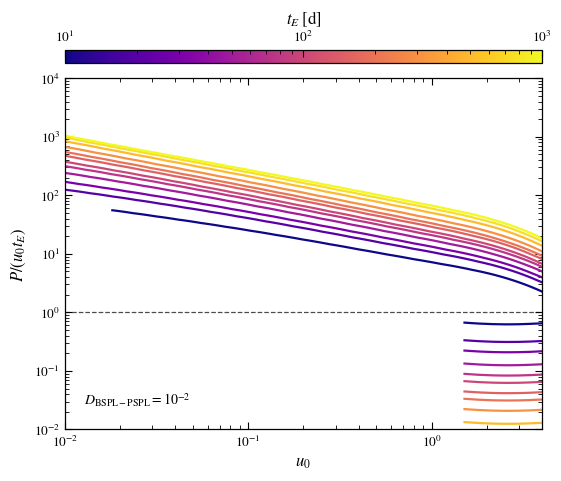

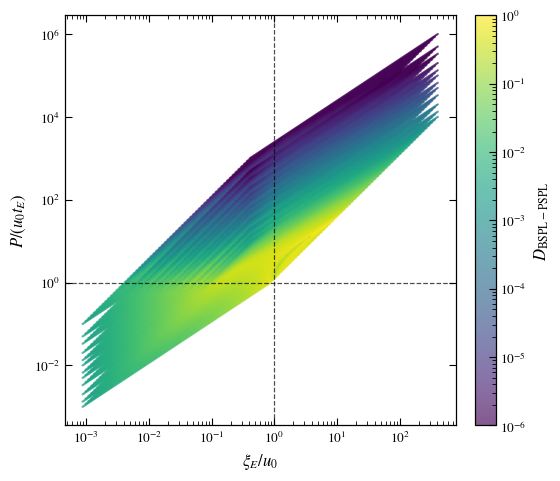

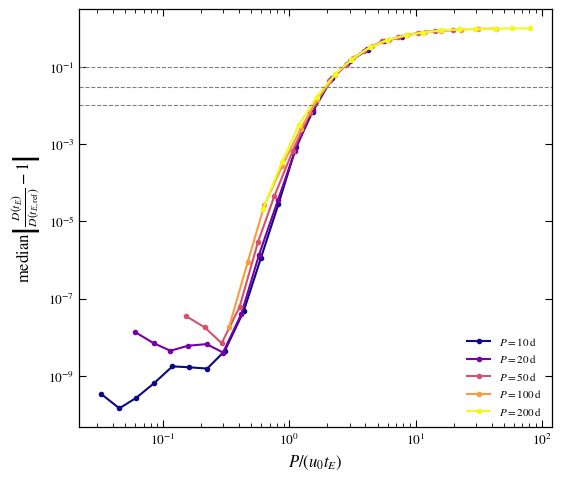

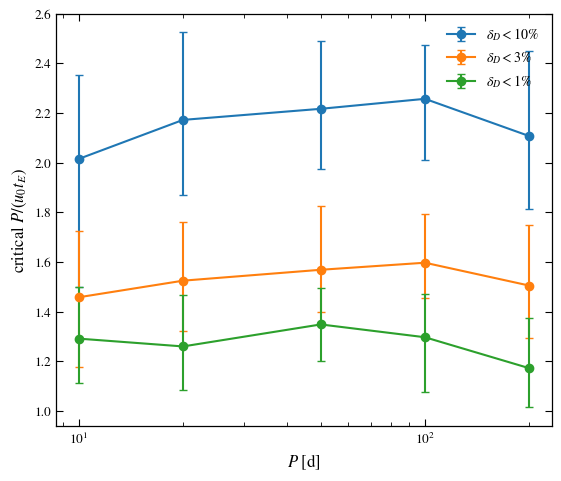

In [14]:
# ============================================================
# LOCAL DIMENSIONLESS SCALING USING D_BSPL-PSPL
#
# FIGURE 1
# ----------
# D = 1e-2 contours for many tE in:
#
#       x = u0
#       y = P / (u0 tE)
#
#
# FIGURE 2
# ----------
# All valid simulated points in:
#
#       x = xi_E / u0
#       y = P / (u0 tE)
#
# color = D
#
#
# FIGURE 3
# ----------
# Multi-P convergence toward the long-tE reference:
#
#       delta_D =
#       | D(u0,tE;P) / D(u0,tE_ref;P) - 1 |
#
# plotted against P/(u0 tE).
#
#
# FIGURE 4
# ----------
# Critical P/(u0 tE) versus P for:
#
#       delta_D < 10%
#       delta_D < 3%
#       delta_D < 1%
#
#
# IMPORTANT
# ----------
# Current scan files store:
#
#       xiE_of_P = xi_rel = a_rel / rEhat
#
# For the luminous primary:
#
#       xi_E = q_M/(1+q_M) * xi_rel
#
# ============================================================


import os
import glob
import re

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from matplotlib.cm import ScalarMappable

from scipy.stats import spearmanr


# ============================================================
# PAPER STYLE
# ============================================================

plt.rcParams.update({

    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",

    "font.size": 10,

    "axes.labelsize": 12,

    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,

    "axes.linewidth": 0.9,

    "xtick.direction": "in",
    "ytick.direction": "in",

    "xtick.top": True,
    "ytick.right": True,

    "xtick.major.size": 5,
    "ytick.major.size": 5,

    "xtick.minor.size": 3,
    "ytick.minor.size": 3,

    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,

    "savefig.dpi": 300,
})


# ============================================================
# CONFIGURATION
# ============================================================

home_path = os.path.expanduser("~")


base_directory = os.path.join(
    home_path,
    "binary_source",
    "results",
    "scan_many_tE_200x200",
)


# ============================================================
# tE VALUES
# ============================================================

tE_list = np.array(
    [
        10,
        20,
        30,
        50,
        75,
        100,
        150,
        200,
        300,
        500,
        750,
        1000,
    ],
    dtype=float,
)


# ============================================================
# METRIC
# ============================================================

metric_key = "D"


# ============================================================
# REFERENCE D CONTOUR
#
# D = 1e-2 means:
#
# RMS residual = 1% of RMS event signal.
# ============================================================

D_THRESHOLD = 1e-2


# ============================================================
# PERIODS USED IN MULTI-P TEST
# ============================================================

P_TARGETS = np.array(
    [
        10.0,
        20.0,
        50.0,
        100.0,
        200.0,
    ],
    dtype=float,
)


# ============================================================
# LONG-tE REFERENCE
# ============================================================

tE_REFERENCE = 1000.0


# ============================================================
# COMMON u0 RANGE FOR SANITY CHECK
# ============================================================

COMMON_U0_MIN = 0.20
COMMON_U0_MAX = 0.50


# ============================================================
# REQUIRE REFERENCE TO BE IN APPROXIMATE FAST-ORBIT REGIME
#
# x_ref =
#
#       P / (u0 tE_reference)
#
# ============================================================

X_REFERENCE_MAX = 1.0


# ============================================================
# CONVERGENCE LEVELS
# ============================================================

CONVERGENCE_LEVELS = [
    0.10,
    0.03,
    0.01,
]


# ============================================================
# NUMERICAL FLOORS
#
# D values smaller than MIN_D are ignored in ratios.
# This avoids ratios dominated by machine precision.
# ============================================================

MIN_D = 1e-12

DELTA_FLOOR = 1e-10


# ============================================================
# FIGURE 1 AXIS LIMITS
# ============================================================

U0_MIN = 1e-2
U0_MAX = 4.0

LOCAL_TIME_MIN = 1e-2
LOCAL_TIME_MAX = 1e4


# ============================================================
# FIGURE 2 D COLOR SCALE
#
# Adjust if necessary after checking the printed D range.
# ============================================================

D_VMIN = 1e-6
D_VMAX = 1e0


# ============================================================
# FIGURE SIZE
# ============================================================

FIGSIZE = (5.5, 4.7)


# ============================================================
# OUTPUT DIRECTORY
# ============================================================

output_directory = os.path.join(
    base_directory,
    "D_local_scaling",
)

os.makedirs(
    output_directory,
    exist_ok=True,
)


# ============================================================
# OUTPUT FILES
# ============================================================

output_contours_png = os.path.join(
    output_directory,
    "D_threshold_many_tE_POveru0tE.png",
)

output_contours_pdf = os.path.join(
    output_directory,
    "D_threshold_many_tE_POveru0tE.pdf",
)


output_plane_png = os.path.join(
    output_directory,
    "D_xiOveru0_vs_POveru0tE.png",
)

output_plane_pdf = os.path.join(
    output_directory,
    "D_xiOveru0_vs_POveru0tE.pdf",
)


output_collapse_png = os.path.join(
    output_directory,
    "D_fast_orbit_collapse_manyP.png",
)

output_collapse_pdf = os.path.join(
    output_directory,
    "D_fast_orbit_collapse_manyP.pdf",
)


output_critical_png = os.path.join(
    output_directory,
    "D_critical_local_ratio_vs_P.png",
)

output_critical_pdf = os.path.join(
    output_directory,
    "D_critical_local_ratio_vs_P.pdf",
)


# ============================================================
# HELPERS
# ============================================================

def extract_u0_index(filename):

    base = os.path.basename(
        filename
    )

    match = re.fullmatch(
        r"scan_kepler_u0_(\d+)\.npz",
        base,
    )

    if match is None:

        raise ValueError(
            f"No pude extraer el índice desde {base}"
        )

    return int(
        match.group(1)
    )


def format_tE_label(tE):

    label = f"{float(tE):g}"

    return label.replace(
        ".",
        "p",
    )


# ============================================================
# LOAD ONE tE SCAN
# ============================================================

def load_scan_for_tE(
    tE_true,
    base_directory,
):

    label = format_tE_label(
        tE_true
    )


    directory = os.path.join(
        base_directory,
        f"scan_u0_tE{label}",
    )


    pattern = os.path.join(
        directory,
        "scan_kepler_u0_*.npz",
    )


    files = sorted(
        glob.glob(
            pattern
        )
    )


    if len(files) == 0:

        raise FileNotFoundError(
            f"No files found:\n{pattern}"
        )


    records = []

    P_grid_reference = None
    xi_rel_reference = None
    q_mass_reference = None

    total_bins = 0
    successful_bins = 0


    # ========================================================
    # FIRST PASS
    # ========================================================

    for filename in files:


        with np.load(
            filename,
            allow_pickle=False,
        ) as d:


            required = [
                "truth",
                "P_grid",
                "SUCCESS",
                "D",
                "xiE_of_P",
            ]


            for key in required:

                if key not in d.files:

                    raise KeyError(
                        f"\n{filename}\n"
                        f"does not contain '{key}'."
                    )


            truth = d[
                "truth"
            ].astype(float)


            P_grid = d[
                "P_grid"
            ].astype(float)


            SUCCESS = d[
                "SUCCESS"
            ].astype(bool)


            xi_rel = d[
                "xiE_of_P"
            ].astype(float)


        # ----------------------------------------------------
        # Truth parameters
        # ----------------------------------------------------

        u0_true = float(
            truth[1]
        )


        M1_true = float(
            truth[5]
        )


        M2_true = float(
            truth[6]
        )


        q_mass = (
            M2_true
            /
            M1_true
        )


        # ----------------------------------------------------
        # Check grids
        # ----------------------------------------------------

        if P_grid_reference is None:

            P_grid_reference = (
                P_grid.copy()
            )

            xi_rel_reference = (
                xi_rel.copy()
            )

            q_mass_reference = (
                q_mass
            )

        else:

            if not np.allclose(
                P_grid,
                P_grid_reference,
            ):

                raise ValueError(
                    f"Inconsistent P_grid in:\n{filename}"
                )


            if not np.allclose(
                xi_rel,
                xi_rel_reference,
            ):

                raise ValueError(
                    f"Inconsistent xiE_of_P in:\n{filename}"
                )


            if not np.isclose(
                q_mass,
                q_mass_reference,
            ):

                raise ValueError(
                    "q_mass changes within scan."
                )


        total_bins += len(
            SUCCESS
        )


        successful_bins += np.count_nonzero(
            SUCCESS
        )


        records.append(
            {

                "filename":
                    filename,

                "index":
                    extract_u0_index(
                        filename
                    ),

                "u0":
                    u0_true,
            }
        )


    # ========================================================
    # SORT BY u0
    # ========================================================

    records = sorted(
        records,
        key=lambda row:
            row["u0"],
    )


    u0_grid = np.array(
        [
            row["u0"]
            for row in records
        ],
        dtype=float,
    )


    Nu0 = len(
        u0_grid
    )


    NP = len(
        P_grid_reference
    )


    # ========================================================
    # D MAP
    # ========================================================

    D_map = np.full(
        (
            Nu0,
            NP,
        ),
        np.nan,
        dtype=float,
    )


    for i, record in enumerate(
        records
    ):


        with np.load(
            record["filename"],
            allow_pickle=False,
        ) as d:


            D = d[
                "D"
            ].astype(float)


            SUCCESS = d[
                "SUCCESS"
            ].astype(bool)


        valid = (
            SUCCESS
            &
            np.isfinite(
                D
            )
            &
            (
                D > 0
            )
        )


        D_map[
            i,
            valid,
        ] = D[
            valid
        ]


    # ========================================================
    # PRIMARY ORBITAL AMPLITUDE
    #
    # xiE_of_P currently stores xi_rel.
    #
    # xi_E,1 = q/(1+q) * xi_rel
    # ========================================================

    xi_E_primary = (

        q_mass_reference
        /
        (
            1.0
            +
            q_mass_reference
        )

        *
        xi_rel_reference
    )


    return {

        "tE_true":
            float(
                tE_true
            ),

        "u0_grid":
            u0_grid,

        "P_grid":
            P_grid_reference,

        "xi_rel_grid":
            xi_rel_reference,

        "xi_E_grid":
            xi_E_primary,

        "q_mass":
            q_mass_reference,

        "D_map":
            D_map,

        "success_fraction":
            successful_bins
            /
            total_bins,

        "n_files":
            len(
                files
            ),
    }


# ============================================================
# LOAD ALL tE SCANS
# ============================================================

results = []


print()
print("=" * 90)
print("LOADING D MAPS")
print("=" * 90)


for tE_true in tE_list:


    try:

        result = load_scan_for_tE(

            tE_true=tE_true,

            base_directory=base_directory,
        )


    except FileNotFoundError:

        print(
            f"tE={tE_true:g} d missing -> skipped"
        )

        continue


    results.append(
        result
    )


    print(

        f"tE={tE_true:7.1f} d   "
        f"Nfiles={result['n_files']:3d}   "
        f"success="
        f"{100*result['success_fraction']:6.2f}%   "
        f"q={result['q_mass']:.3f}"
    )


if len(results) == 0:

    raise RuntimeError(
        "No scans were loaded."
    )


# ============================================================
# RESULT LOOKUP
# ============================================================

def get_result_for_tE(
    tE,
):

    for result in results:

        if np.isclose(
            result["tE_true"],
            tE,
        ):

            return result


    raise ValueError(
        f"No result found for tE={tE:g} d."
    )


# ============================================================
# ============================================================
#
# FIGURE 1
#
# D = 1e-2 CONTOURS IN:
#
#       (u0, P/(u0 tE))
#
# ============================================================
# ============================================================

tE_loaded = np.array(
    [
        result["tE_true"]
        for result in results
    ]
)


norm_tE = mcolors.LogNorm(

    vmin=np.min(
        tE_loaded
    ),

    vmax=np.max(
        tE_loaded
    ),
)


cmap_tE = plt.get_cmap(
    "plasma"
)


fig1, ax1 = plt.subplots(

    figsize=FIGSIZE,

    constrained_layout=True,
)


for result in results:


    tE_true = result[
        "tE_true"
    ]


    u0_grid = result[
        "u0_grid"
    ]


    P_grid = result[
        "P_grid"
    ]


    D_map = result[
        "D_map"
    ]


    valid = (
        np.isfinite(
            D_map
        )
        &
        (
            D_map > 0
        )
    )


    if not np.any(
        valid
    ):

        continue


    D_min = np.nanmin(
        D_map[
            valid
        ]
    )


    D_max = np.nanmax(
        D_map[
            valid
        ]
    )


    if not (
        D_min
        <=
        D_THRESHOLD
        <=
        D_max
    ):

        print(
            f"tE={tE_true:g}: "
            f"D={D_THRESHOLD:.0e} not crossed."
        )

        continue


    # ========================================================
    # COORDINATES
    # ========================================================

    U2D, P2D = np.meshgrid(

        u0_grid,

        P_grid,

        indexing="xy",
    )


    LOCAL2D = (

        P2D
        /
        (
            U2D
            *
            tE_true
        )
    )


    color = cmap_tE(
        norm_tE(
            tE_true
        )
    )


    ax1.contour(

        U2D,

        LOCAL2D,

        np.ma.masked_invalid(
            D_map.T
        ),

        levels=[
            D_THRESHOLD
        ],

        colors=[
            color
        ],

        linewidths=1.6,

        linestyles="-",
    )


# ============================================================
# LOCAL TIMESCALE UNITY
# ============================================================

ax1.axhline(

    1.0,

    ls="--",

    lw=0.9,

    color="black",

    alpha=0.7,
)


ax1.set_xscale(
    "log"
)


ax1.set_yscale(
    "log"
)


ax1.set_xlim(
    U0_MIN,
    U0_MAX,
)


ax1.set_ylim(
    LOCAL_TIME_MIN,
    LOCAL_TIME_MAX,
)


ax1.set_xlabel(
    r"$u_0$"
)


ax1.set_ylabel(
    r"$P/(u_0t_E)$"
)


ax1.text(

    0.04,
    0.06,

    r"$D_{\rm BSPL-PSPL}=10^{-2}$",

    transform=ax1.transAxes,

    ha="left",

    va="bottom",
)


sm = ScalarMappable(

    norm=norm_tE,

    cmap=cmap_tE,
)


sm.set_array(
    []
)


cbar1 = fig1.colorbar(

    sm,

    ax=ax1,

    orientation="horizontal",

    location="top",

    pad=0.025,

    fraction=0.055,

    aspect=35,
)


cbar1.set_label(
    r"$t_E\;[\mathrm{d}]$"
)


cbar1.ax.xaxis.set_ticks_position(
    "top"
)


cbar1.ax.xaxis.set_label_position(
    "top"
)


fig1.savefig(

    output_contours_png,

    dpi=600,

    bbox_inches="tight",
)


fig1.savefig(

    output_contours_pdf,

    bbox_inches="tight",
)


# ============================================================
# ============================================================
#
# FIGURE 2
#
# D IN:
#
#       (xi_E/u0, P/(u0 tE))
#
# ============================================================
# ============================================================

all_x = []
all_y = []
all_D = []


for result in results:


    tE_true = result[
        "tE_true"
    ]


    u0_grid = result[
        "u0_grid"
    ]


    P_grid = result[
        "P_grid"
    ]


    xi_E_grid = result[
        "xi_E_grid"
    ]


    D_map = result[
        "D_map"
    ]


    U2D, P2D = np.meshgrid(

        u0_grid,

        P_grid,

        indexing="xy",
    )


    XI2D = np.broadcast_to(

        xi_E_grid[
            :,
            None
        ],

        (
            len(
                xi_E_grid
            ),

            len(
                u0_grid
            ),
        ),
    )


    XI_OVER_U0 = (
        XI2D
        /
        U2D
    )


    P_OVER_U0TE = (

        P2D
        /
        (
            U2D
            *
            tE_true
        )
    )


    D2D = D_map.T


    valid = (
        np.isfinite(
            XI_OVER_U0
        )
        &
        np.isfinite(
            P_OVER_U0TE
        )
        &
        np.isfinite(
            D2D
        )
        &
        (
            XI_OVER_U0 > 0
        )
        &
        (
            P_OVER_U0TE > 0
        )
        &
        (
            D2D > 0
        )
    )


    all_x.append(
        XI_OVER_U0[
            valid
        ]
    )


    all_y.append(
        P_OVER_U0TE[
            valid
        ]
    )


    all_D.append(
        D2D[
            valid
        ]
    )


all_x = np.concatenate(
    all_x
)


all_y = np.concatenate(
    all_y
)


all_D = np.concatenate(
    all_D
)


print()
print("=" * 90)
print("D DIMENSIONLESS PLANE")
print("=" * 90)

print(
    f"N points = {len(all_D)}"
)

print(
    f"xi_E/u0 = "
    f"{all_x.min():.3e} -- {all_x.max():.3e}"
)

print(
    f"P/(u0 tE) = "
    f"{all_y.min():.3e} -- {all_y.max():.3e}"
)

print(
    f"D = "
    f"{all_D.min():.3e} -- {all_D.max():.3e}"
)

print("=" * 90)


norm_D = mcolors.LogNorm(

    vmin=D_VMIN,

    vmax=D_VMAX,
)


fig2, ax2 = plt.subplots(

    figsize=FIGSIZE,

    constrained_layout=True,
)


sc2 = ax2.scatter(

    all_x,

    all_y,

    c=all_D,

    cmap="viridis",

    norm=norm_D,

    s=2.5,

    alpha=0.65,

    edgecolors="none",

    rasterized=True,
)


ax2.axvline(

    1.0,

    ls="--",

    lw=0.9,

    color="black",

    alpha=0.7,
)


ax2.axhline(

    1.0,

    ls="--",

    lw=0.9,

    color="black",

    alpha=0.7,
)


ax2.set_xscale(
    "log"
)


ax2.set_yscale(
    "log"
)


ax2.set_xlabel(
    r"$\xi_E/u_0$"
)


ax2.set_ylabel(
    r"$P/(u_0t_E)$"
)


cbar2 = fig2.colorbar(

    sc2,

    ax=ax2,
)


cbar2.set_label(
    r"$D_{\rm BSPL-PSPL}$"
)


fig2.savefig(

    output_plane_png,

    dpi=600,

    bbox_inches="tight",
)


fig2.savefig(

    output_plane_pdf,

    bbox_inches="tight",
)


# ============================================================
# ============================================================
#
# MULTI-P FAST-ORBIT TEST USING D
#
# ============================================================
# ============================================================


# ============================================================
# EXTRACT D(u0) AT FIXED P
# ============================================================

def get_D_slice_at_P(
    result,
    P_target,
):


    u0 = np.asarray(
        result[
            "u0_grid"
        ],
        dtype=float,
    )


    P_grid = np.asarray(
        result[
            "P_grid"
        ],
        dtype=float,
    )


    D_map = np.asarray(
        result[
            "D_map"
        ],
        dtype=float,
    )


    jP = np.argmin(

        np.abs(

            np.log10(
                P_grid
            )

            -

            np.log10(
                P_target
            )
        )
    )


    return (

        u0,

        D_map[
            :,
            jP
        ].copy(),

        P_grid[
            jP
        ],
    )


# ============================================================
# INTERPOLATE D IN LOG-LOG SPACE
# ============================================================

def interpolate_D(
    u0,
    D,
    u0_reference,
):


    valid = (
        np.isfinite(
            u0
        )
        &
        np.isfinite(
            D
        )
        &
        (
            u0 > 0
        )
        &
        (
            D > MIN_D
        )
    )


    if np.count_nonzero(
        valid
    ) < 2:

        return np.full_like(
            u0_reference,
            np.nan,
            dtype=float,
        )


    logu = np.log10(
        u0[
            valid
        ]
    )


    logD = np.log10(
        D[
            valid
        ]
    )


    order = np.argsort(
        logu
    )


    logu = logu[
        order
    ]


    logD = logD[
        order
    ]


    out = np.full_like(
        u0_reference,
        np.nan,
        dtype=float,
    )


    inside = (
        (
            u0_reference
            >=
            10**logu.min()
        )
        &
        (
            u0_reference
            <=
            10**logu.max()
        )
    )


    out[
        inside
    ] = 10**np.interp(

        np.log10(
            u0_reference[
                inside
            ]
        ),

        logu,

        logD,
    )


    return out


# ============================================================
# BUILD COMPLETE MULTI-P DATASET
# ============================================================

reference_result = get_result_for_tE(
    tE_REFERENCE
)


rows = []


for P_target in P_TARGETS:


    (
        u0_reference,
        D_reference_raw,
        P_reference_actual,
    ) = get_D_slice_at_P(

        reference_result,

        P_target,
    )


    D_reference = interpolate_D(

        u0_reference,

        D_reference_raw,

        u0_reference,
    )


    print()
    print("=" * 90)

    print(
        f"P target = {P_target:g} d"
    )

    print(
        f"P actual = {P_reference_actual:.8g} d"
    )

    print("=" * 90)


    for tE in tE_list:


        if np.isclose(
            tE,
            tE_REFERENCE,
        ):

            continue


        result = get_result_for_tE(
            tE
        )


        (
            u0_current,
            D_current_raw,
            P_actual,
        ) = get_D_slice_at_P(

            result,

            P_target,
        )


        D_current = interpolate_D(

            u0_current,

            D_current_raw,

            u0_reference,
        )


        valid = (
            np.isfinite(
                D_current
            )
            &
            np.isfinite(
                D_reference
            )
            &
            (
                D_current > MIN_D
            )
            &
            (
                D_reference > MIN_D
            )
            &
            (
                u0_reference
                >=
                COMMON_U0_MIN
            )
            &
            (
                u0_reference
                <=
                COMMON_U0_MAX
            )
        )


        for (
            u0,
            D_now,
            D_ref
        ) in zip(

            u0_reference[
                valid
            ],

            D_current[
                valid
            ],

            D_reference[
                valid
            ],
        ):


            x_global = (
                P_actual
                /
                tE
            )


            x_local = (

                P_actual

                /

                (
                    u0
                    *
                    tE
                )
            )


            x_reference = (

                P_reference_actual

                /

                (
                    u0
                    *
                    tE_REFERENCE
                )
            )


            delta_D = np.abs(

                D_now
                /
                D_ref

                -
                1.0
            )


            rows.append(
                {

                    "P_target":
                        P_target,

                    "P":
                        P_actual,

                    "tE":
                        tE,

                    "u0":
                        u0,

                    "P_over_tE":
                        x_global,

                    "P_over_u0tE":
                        x_local,

                    "x_reference":
                        x_reference,

                    "D":
                        D_now,

                    "D_ref":
                        D_ref,

                    "delta_D":
                        delta_D,
                }
            )


df_D = pd.DataFrame(
    rows
)


# ============================================================
# REQUIRE FAST REFERENCE
# ============================================================

df_D = df_D[

    df_D[
        "x_reference"
    ]
    <=
    X_REFERENCE_MAX

].copy()


df_D.reset_index(
    drop=True,
    inplace=True,
)


df_D[
    "delta_plot"
] = np.maximum(

    df_D[
        "delta_D"
    ],

    DELTA_FLOOR,
)


print()

print("=" * 90)
print("D FAST-ORBIT DATASET")
print("=" * 90)

print(
    f"N points = {len(df_D)}"
)

print(
    f"Common u0 = "
    f"{COMMON_U0_MIN:g} -- {COMMON_U0_MAX:g}"
)

print("=" * 90)


# ============================================================
# CORRELATIONS
# ============================================================

rho_global, p_global = spearmanr(

    np.log10(
        df_D[
            "P_over_tE"
        ]
    ),

    np.log10(
        df_D[
            "delta_plot"
        ]
    ),
)


rho_local, p_local = spearmanr(

    np.log10(
        df_D[
            "P_over_u0tE"
        ]
    ),

    np.log10(
        df_D[
            "delta_plot"
        ]
    ),
)


print()

print("=" * 90)

print("ALL PERIODS COMBINED")

print("=" * 90)


print(
    f"P/tE:"
)

print(
    f"    Spearman rho = {rho_global:.6f}"
)

print(
    f"    p-value      = {p_global:.3e}"
)


print()


print(
    f"P/(u0 tE):"
)

print(
    f"    Spearman rho = {rho_local:.6f}"
)

print(
    f"    p-value      = {p_local:.3e}"
)


print("=" * 90)


# ============================================================
# BINNED MEDIAN
# ============================================================

def binned_statistics(
    x,
    y,
    n_bins=18,
):


    x = np.asarray(
        x,
        dtype=float,
    )


    y = np.asarray(
        y,
        dtype=float,
    )


    valid = (
        np.isfinite(
            x
        )
        &
        np.isfinite(
            y
        )
        &
        (
            x > 0
        )
        &
        (
            y > 0
        )
    )


    x = x[
        valid
    ]


    y = y[
        valid
    ]


    logx = np.log10(
        x
    )


    edges = np.linspace(

        logx.min(),

        logx.max(),

        n_bins + 1,
    )


    centers = []
    medians = []
    q16 = []
    q84 = []


    for i in range(
        n_bins
    ):


        select = (
            (
                logx
                >=
                edges[i]
            )
            &
            (
                logx
                <
                edges[i + 1]
            )
        )


        if i == n_bins - 1:

            select = (
                (
                    logx
                    >=
                    edges[i]
                )
                &
                (
                    logx
                    <=
                    edges[i + 1]
                )
            )


        if np.count_nonzero(
            select
        ) < 3:

            continue


        centers.append(

            10**
            np.mean(
                np.log10(
                    x[
                        select
                    ]
                )
            )
        )


        medians.append(

            np.median(
                y[
                    select
                ]
            )
        )


        q16.append(

            np.percentile(
                y[
                    select
                ],
                16,
            )
        )


        q84.append(

            np.percentile(
                y[
                    select
                ],
                84,
            )
        )


    return {

        "x":
            np.asarray(
                centers
            ),

        "median":
            np.asarray(
                medians
            ),

        "q16":
            np.asarray(
                q16
            ),

        "q84":
            np.asarray(
                q84
            ),
    }


# ============================================================
# FIGURE 3:
# MEDIAN delta_D COLLAPSE FOR EACH PERIOD
# ============================================================

fig3, ax3 = plt.subplots(

    figsize=FIGSIZE,

    constrained_layout=True,
)


norm_P = mcolors.LogNorm(

    vmin=np.min(
        P_TARGETS
    ),

    vmax=np.max(
        P_TARGETS
    ),
)


cmap_P = plt.get_cmap(
    "plasma"
)


for P_target in P_TARGETS:


    sub = df_D[

        np.isclose(
            df_D[
                "P_target"
            ],
            P_target,
        )

    ]


    if len(
        sub
    ) < 5:

        continue


    stats = binned_statistics(

        sub[
            "P_over_u0tE"
        ],

        sub[
            "delta_plot"
        ],

        n_bins=16,
    )


    color = cmap_P(
        norm_P(
            P_target
        )
    )


    ax3.plot(

        stats[
            "x"
        ],

        stats[
            "median"
        ],

        marker="o",

        ms=3,

        lw=1.5,

        color=color,

        label=(
            rf"$P={P_target:g}\,\mathrm{{d}}$"
        ),
    )


for tolerance in CONVERGENCE_LEVELS:


    ax3.axhline(

        tolerance,

        ls="--",

        lw=0.8,

        color="gray",
    )


ax3.set_xscale(
    "log"
)


ax3.set_yscale(
    "log"
)


ax3.set_xlabel(
    r"$P/(u_0t_E)$"
)


ax3.set_ylabel(

    r"$\mathrm{median}\left|"
    r"\frac{D(t_E)}{D(t_{E,\rm ref})}"
    r"-1"
    r"\right|$"
)


ax3.legend(

    frameon=False,

    fontsize=8,
)


fig3.savefig(

    output_collapse_png,

    dpi=600,

    bbox_inches="tight",
)


fig3.savefig(

    output_collapse_pdf,

    bbox_inches="tight",
)


# ============================================================
# CRITICAL LOCAL RATIO
# ============================================================

critical_rows = []


for P_target in P_TARGETS:


    df_P = df_D[

        np.isclose(
            df_D[
                "P_target"
            ],
            P_target,
        )

    ]


    for u0 in np.sort(
        df_P[
            "u0"
        ].unique()
    ):


        subset = df_P[

            np.isclose(
                df_P[
                    "u0"
                ],
                u0,
            )

        ]


        for tolerance in CONVERGENCE_LEVELS:


            converged = subset[

                subset[
                    "delta_D"
                ]
                <=
                tolerance

            ]


            if len(
                converged
            ) == 0:

                continue


            idx = converged[

                "P_over_u0tE"

            ].idxmax()


            row = converged.loc[
                idx
            ]


            critical_rows.append(
                {

                    "P":
                        P_target,

                    "u0":
                        u0,

                    "tolerance":
                        tolerance,

                    "xcrit":
                        row[
                            "P_over_u0tE"
                        ],

                    "tE":
                        row[
                            "tE"
                        ],

                    "delta_D":
                        row[
                            "delta_D"
                        ],
                }
            )


df_critical = pd.DataFrame(
    critical_rows
)


# ============================================================
# SUMMARY PER PERIOD
# ============================================================

summary_rows = []


for P_target in P_TARGETS:


    for tolerance in CONVERGENCE_LEVELS:


        sub = df_critical[

            np.isclose(
                df_critical[
                    "P"
                ],
                P_target,
            )

            &

            np.isclose(
                df_critical[
                    "tolerance"
                ],
                tolerance,
            )

        ]


        if len(
            sub
        ) == 0:

            continue


        values = sub[
            "xcrit"
        ].to_numpy()


        summary_rows.append(
            {

                "P":
                    P_target,

                "tolerance":
                    tolerance,

                "N":
                    len(
                        values
                    ),

                "median_xcrit":
                    np.median(
                        values
                    ),

                "q16":
                    np.percentile(
                        values,
                        16,
                    ),

                "q84":
                    np.percentile(
                        values,
                        84,
                    ),
            }
        )


critical_summary = pd.DataFrame(
    summary_rows
)


print()

print("=" * 100)

print(
    "CRITICAL P/(u0 tE) USING D"
)

print("=" * 100)

print(
    critical_summary.to_string(
        index=False
    )
)


# ============================================================
# INDEPENDENCE FROM P
# ============================================================

print()

print("=" * 100)

print(
    "DEPENDENCE OF D CRITICAL SCALE ON P"
)

print("=" * 100)


for tolerance in CONVERGENCE_LEVELS:


    sub = critical_summary[

        np.isclose(
            critical_summary[
                "tolerance"
            ],
            tolerance,
        )

    ].sort_values(
        "P"
    )


    if len(
        sub
    ) < 3:

        continue


    P_values = sub[
        "P"
    ].to_numpy()


    xcrit_values = sub[
        "median_xcrit"
    ].to_numpy()


    slope, intercept = np.polyfit(

        np.log10(
            P_values
        ),

        np.log10(
            xcrit_values
        ),

        1,
    )


    characteristic = np.median(
        xcrit_values
    )


    fractional_std = (

        np.std(
            xcrit_values
        )

        /

        np.mean(
            xcrit_values
        )
    )


    print()

    print(
        f"delta_D < {100*tolerance:.0f}%"
    )

    print(
        f"    characteristic xcrit = "
        f"{characteristic:.4f}"
    )

    print(
        f"    fractional std       = "
        f"{100*fractional_std:.2f}%"
    )

    print(
        f"    xcrit ~ P^alpha      = "
        f"alpha={slope:.4f}"
    )


print()

print("=" * 100)


# ============================================================
# FIGURE 4:
# CRITICAL P/(u0 tE) VS P
# ============================================================

fig4, ax4 = plt.subplots(

    figsize=FIGSIZE,

    constrained_layout=True,
)


for tolerance in CONVERGENCE_LEVELS:


    sub = critical_summary[

        np.isclose(
            critical_summary[
                "tolerance"
            ],
            tolerance,
        )

    ].sort_values(
        "P"
    )


    if len(
        sub
    ) == 0:

        continue


    median = sub[
        "median_xcrit"
    ].to_numpy()


    q16 = sub[
        "q16"
    ].to_numpy()


    q84 = sub[
        "q84"
    ].to_numpy()


    ax4.errorbar(

        sub[
            "P"
        ],

        median,

        yerr=np.vstack(
            (
                median - q16,
                q84 - median,
            )
        ),

        marker="o",

        capsize=3,

        lw=1.5,

        label=(
            rf"$\delta_D<{100*tolerance:.0f}\%$"
        ),
    )


ax4.set_xscale(
    "log"
)


ax4.set_xlabel(
    r"$P\;[\mathrm{d}]$"
)


ax4.set_ylabel(
    r"critical $P/(u_0t_E)$"
)


ax4.legend(
    frameon=False
)


fig4.savefig(

    output_critical_png,

    dpi=600,

    bbox_inches="tight",
)


fig4.savefig(

    output_critical_pdf,

    bbox_inches="tight",
)


# ============================================================
# SAVE TABLES
# ============================================================

df_D.to_csv(

    os.path.join(
        output_directory,
        "D_fast_orbit_dataset.csv",
    ),

    index=False,
)


critical_summary.to_csv(

    os.path.join(
        output_directory,
        "D_critical_local_ratio_summary.csv",
    ),

    index=False,
)


# ============================================================
# FINAL OUTPUT
# ============================================================

print()

print("=" * 100)

print("OUTPUT FILES")

print("=" * 100)

print(
    output_contours_png
)

print(
    output_contours_pdf
)

print()

print(
    output_plane_png
)

print(
    output_plane_pdf
)

print()

print(
    output_collapse_png
)

print(
    output_collapse_pdf
)

print()

print(
    output_critical_png
)

print(
    output_critical_pdf
)

print("=" * 100)


plt.show()


LOADING tE = 50 d
N u0          = 200
N P           = 60
N valid       = 12000
q_mass        = 0.5000

xi_E/u0 range:
    8.7342e-04 -- 4.0540e+02

P/t_eff range:
    2.0000e-02 -- 2.0000e+05

D range:
    1.7454e-06 -- 8.5725e-02

FIGURE SAVED
/home/anibal-pc/binary_source/results/scan_many_tE_200x200/D_local_scaling/D_xiOveru0_vs_POverTeff_tE50.png
/home/anibal-pc/binary_source/results/scan_many_tE_200x200/D_local_scaling/D_xiOveru0_vs_POverTeff_tE50.pdf


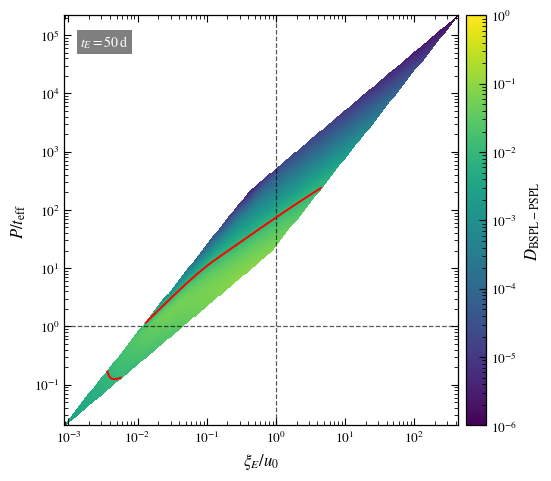

In [16]:
# ============================================================
# PAPER FIGURE
#
# D_BSPL-PSPL for ONE fixed Einstein timescale
#
# Coordinates:
#
#       x = xi_E / u0
#       y = P / t_eff = P / (u0 tE)
#
# Color:
#
#       D_BSPL-PSPL
#
# This version uses only ONE tE, so the multiple "sheets"
# produced by superposing different tE values disappear.
#
# The scan is still Kepler-consistent:
#
#       xi_E = xi_E(P)
#
# so x and y are not independently sampled variables.
# ============================================================


import os
import glob
import re

import numpy as np

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


# ============================================================
# PAPER STYLE
# ============================================================

plt.rcParams.update({

    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",

    "font.size": 10,

    "axes.labelsize": 12,

    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,

    "axes.linewidth": 0.9,

    "xtick.direction": "in",
    "ytick.direction": "in",

    "xtick.top": True,
    "ytick.right": True,

    "xtick.major.size": 5,
    "ytick.major.size": 5,

    "xtick.minor.size": 3,
    "ytick.minor.size": 3,

    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,
})


# ============================================================
# CONFIGURATION
# ============================================================

home_path = os.path.expanduser("~")


base_directory = os.path.join(
    home_path,
    "binary_source",
    "results",
    "scan_many_tE_200x200",
)


# ============================================================
# REPRESENTATIVE EVENT
# ============================================================

tE_true = 50.0


# ============================================================
# D COLOR SCALE
# ============================================================

D_VMIN = 1e-6
D_VMAX = 1.0


# ============================================================
# OPTIONAL REFERENCE CONTOUR
# ============================================================

SHOW_D_CONTOUR = True

D_CONTOUR = 1e-2


# ============================================================
# OPTIONAL UNITY LINES
# ============================================================

SHOW_UNITY_LINES = True


# ============================================================
# FIGURE SIZE
# ============================================================

FIGSIZE = (
    5.4,
    4.7,
)


# ============================================================
# OUTPUT
# ============================================================

output_directory = os.path.join(
    base_directory,
    "D_local_scaling",
)


os.makedirs(
    output_directory,
    exist_ok=True,
)


output_png = os.path.join(
    output_directory,
    f"D_xiOveru0_vs_POverTeff_tE{int(tE_true)}.png",
)


output_pdf = os.path.join(
    output_directory,
    f"D_xiOveru0_vs_POverTeff_tE{int(tE_true)}.pdf",
)


# ============================================================
# HELPERS
# ============================================================

def format_tE_label(tE):

    label = f"{float(tE):g}"

    return label.replace(
        ".",
        "p",
    )


def extract_u0_index(filename):

    base = os.path.basename(
        filename
    )


    match = re.fullmatch(
        r"scan_kepler_u0_(\d+)\.npz",
        base,
    )


    if match is None:

        raise ValueError(
            f"No pude extraer el índice desde {base}"
        )


    return int(
        match.group(1)
    )


# ============================================================
# LOAD FIXED-tE SCAN
# ============================================================

label = format_tE_label(
    tE_true
)


directory = os.path.join(
    base_directory,
    f"scan_u0_tE{label}",
)


pattern = os.path.join(
    directory,
    "scan_kepler_u0_*.npz",
)


files = sorted(
    glob.glob(
        pattern
    )
)


if len(files) == 0:

    raise FileNotFoundError(
        f"No files found:\n{pattern}"
    )


print()

print("=" * 90)

print(
    f"LOADING tE = {tE_true:g} d"
)

print("=" * 90)


# ============================================================
# FIRST PASS
#
# Obtain:
#
#       u0 grid
#       P grid
#       xi_rel(P)
#       q_mass
#
# ============================================================

records = []

P_grid_reference = None
xi_rel_reference = None
q_mass_reference = None


for filename in files:


    with np.load(
        filename,
        allow_pickle=False,
    ) as d:


        required_keys = [
            "truth",
            "P_grid",
            "SUCCESS",
            "D",
            "xiE_of_P",
        ]


        for key in required_keys:

            if key not in d.files:

                raise KeyError(
                    f"{filename}\n"
                    f"does not contain key '{key}'."
                )


        truth = d[
            "truth"
        ].astype(float)


        P_grid = d[
            "P_grid"
        ].astype(float)


        # ----------------------------------------------------
        # IMPORTANT:
        #
        # xiE_of_P in these simulations stores
        #
        #       xi_rel = a_rel / rEhat
        #
        # not the barycentric amplitude of the primary.
        # ----------------------------------------------------

        xi_rel = d[
            "xiE_of_P"
        ].astype(float)


    # --------------------------------------------------------
    # Physical parameters
    # --------------------------------------------------------

    u0_true = float(
        truth[1]
    )


    M1_true = float(
        truth[5]
    )


    M2_true = float(
        truth[6]
    )


    q_mass = (
        M2_true
        /
        M1_true
    )


    # --------------------------------------------------------
    # Reference grids
    # --------------------------------------------------------

    if P_grid_reference is None:

        P_grid_reference = (
            P_grid.copy()
        )


        xi_rel_reference = (
            xi_rel.copy()
        )


        q_mass_reference = (
            q_mass
        )


    else:


        if not np.allclose(
            P_grid,
            P_grid_reference,
        ):

            raise ValueError(
                f"Inconsistent P_grid in:\n{filename}"
            )


        if not np.allclose(
            xi_rel,
            xi_rel_reference,
        ):

            raise ValueError(
                f"Inconsistent xiE_of_P in:\n{filename}"
            )


        if not np.isclose(
            q_mass,
            q_mass_reference,
        ):

            raise ValueError(
                "q_mass changes within the scan."
            )


    records.append(
        {

            "filename":
                filename,

            "index":
                extract_u0_index(
                    filename
                ),

            "u0":
                u0_true,
        }
    )


# ============================================================
# SORT BY PHYSICAL u0
# ============================================================

records = sorted(
    records,
    key=lambda row:
        row["u0"],
)


u0_grid = np.array(
    [
        row[
            "u0"
        ]

        for row in records
    ],
    dtype=float,
)


Nu0 = len(
    u0_grid
)


NP = len(
    P_grid_reference
)


# ============================================================
# LOAD D MAP
#
# shape:
#
#       Nu0 x NP
# ============================================================

D_map = np.full(
    (
        Nu0,
        NP,
    ),
    np.nan,
    dtype=float,
)


for i, record in enumerate(
    records
):


    with np.load(
        record[
            "filename"
        ],
        allow_pickle=False,
    ) as d:


        D = d[
            "D"
        ].astype(float)


        SUCCESS = d[
            "SUCCESS"
        ].astype(bool)


    valid = (
        SUCCESS
        &
        np.isfinite(
            D
        )
        &
        (
            D > 0
        )
    )


    D_map[
        i,
        valid,
    ] = D[
        valid
    ]


# ============================================================
# PRIMARY-SOURCE ORBITAL AMPLITUDE
#
# q = M2/M1
#
# xi_E,1 =
#
#       q/(1+q) * xi_rel
#
# ============================================================

xi_E_grid = (

    q_mass_reference

    /

    (
        1.0
        +
        q_mass_reference
    )

    *

    xi_rel_reference
)


# ============================================================
# CONSTRUCT THE 2D PHYSICAL GRID
#
# meshgrid produces:
#
#       shape = NP x Nu0
#
# which matches D_map.T
# ============================================================

U2D, P2D = np.meshgrid(

    u0_grid,

    P_grid_reference,

    indexing="xy",
)


XI2D = np.broadcast_to(

    xi_E_grid[
        :,
        None
    ],

    (
        NP,
        Nu0,
    ),
)


# ============================================================
# DIMENSIONLESS PHYSICAL COORDINATES
# ============================================================

XI_OVER_U0 = (

    XI2D
    /
    U2D
)


P_OVER_TEFF = (

    P2D

    /

    (
        U2D
        *
        tE_true
    )
)


D2D = D_map.T


# ============================================================
# VALID DATA
# ============================================================

valid = (

    np.isfinite(
        XI_OVER_U0
    )
    &
    np.isfinite(
        P_OVER_TEFF
    )
    &
    np.isfinite(
        D2D
    )
    &
    (
        XI_OVER_U0 > 0
    )
    &
    (
        P_OVER_TEFF > 0
    )
    &
    (
        D2D > 0
    )
)


print(
    f"N u0          = {Nu0}"
)

print(
    f"N P           = {NP}"
)

print(
    f"N valid       = {np.count_nonzero(valid)}"
)

print(
    f"q_mass        = {q_mass_reference:.4f}"
)

print()

print(
    "xi_E/u0 range:"
)

print(
    f"    {np.nanmin(XI_OVER_U0[valid]):.4e}"
    f" -- "
    f"{np.nanmax(XI_OVER_U0[valid]):.4e}"
)

print()

print(
    "P/t_eff range:"
)

print(
    f"    {np.nanmin(P_OVER_TEFF[valid]):.4e}"
    f" -- "
    f"{np.nanmax(P_OVER_TEFF[valid]):.4e}"
)

print()

print(
    "D range:"
)

print(
    f"    {np.nanmin(D2D[valid]):.4e}"
    f" -- "
    f"{np.nanmax(D2D[valid]):.4e}"
)

print("=" * 90)


# ============================================================
# COLOR NORMALIZATION
# ============================================================

norm_D = mcolors.LogNorm(

    vmin=D_VMIN,

    vmax=D_VMAX,
)


# ============================================================
# CREATE FIGURE
#
# pcolormesh is used instead of combining all tE values in a
# single scatter plot.
#
# The coordinates are curvilinear because both transformed
# variables depend on u0 and P.
# ============================================================

fig, ax = plt.subplots(

    figsize=FIGSIZE,

    constrained_layout=True,
)


pcm = ax.pcolormesh(

    XI_OVER_U0,

    P_OVER_TEFF,

    np.ma.masked_invalid(
        D2D
    ),

    cmap="viridis",

    norm=norm_D,

    shading="auto",

    rasterized=True,
)


# ============================================================
# OPTIONAL D = 1e-2 CONTOUR
# ============================================================

if SHOW_D_CONTOUR:


    D_valid = D2D[
        np.isfinite(
            D2D
        )
    ]


    if (
        len(
            D_valid
        ) > 0
        and
        np.nanmin(
            D_valid
        )
        <=
        D_CONTOUR
        <=
        np.nanmax(
            D_valid
        )
    ):


        cs = ax.contour(

            XI_OVER_U0,

            P_OVER_TEFF,

            np.ma.masked_invalid(
                D2D
            ),

            levels=[
                D_CONTOUR
            ],

            colors="red",

            linewidths=1.4,

            zorder=5,
        )


# ============================================================
# UNITY LINES
#
# They indicate where orbital and microlensing scales become
# comparable.
#
# They are reference lines, not physical boundaries.
# ============================================================

if SHOW_UNITY_LINES:


    ax.axvline(

        1.0,

        ls="--",

        lw=0.9,

        color="black",

        alpha=0.65,

        zorder=4,
    )


    ax.axhline(

        1.0,

        ls="--",

        lw=0.9,

        color="black",

        alpha=0.65,

        zorder=4,
    )


# ============================================================
# AXES
# ============================================================

ax.set_xscale(
    "log"
)


ax.set_yscale(
    "log"
)


ax.set_xlabel(
    r"$\xi_E/u_0$"
)


ax.set_ylabel(
    r"$P/t_{\rm eff}$"
)


ax.tick_params(

    axis="both",

    which="both",

    direction="in",

    top=True,

    right=True,
)


ax.grid(
    False
)


# ============================================================
# tE ANNOTATION
# ============================================================

ax.text(

    0.04,
    0.955,

    rf"$t_E={tE_true:.0f}\,\mathrm{{d}}$",

    transform=ax.transAxes,

    ha="left",

    va="top",

    fontsize=10,

    color="white",

    bbox=dict(

        facecolor="black",

        edgecolor="none",

        alpha=0.50,

        pad=2.5,
    ),
)


# ============================================================
# COLORBAR
# ============================================================

cbar = fig.colorbar(

    pcm,

    ax=ax,

    pad=0.02,
)


cbar.set_label(
    r"$D_{\rm BSPL-PSPL}$"
)


cbar.ax.tick_params(

    which="both",

    direction="in",
)


# ============================================================
# SAVE
# ============================================================

fig.savefig(

    output_png,

    dpi=600,

    bbox_inches="tight",
)


fig.savefig(

    output_pdf,

    bbox_inches="tight",
)


# ============================================================
# FINAL OUTPUT
# ============================================================

print()

print("=" * 90)

print("FIGURE SAVED")

print("=" * 90)

print(
    output_png
)

print(
    output_pdf
)

print("=" * 90)


plt.show()


LOADING D SCANS
tE=   10.0 d loaded
tE=   20.0 d loaded
tE=   30.0 d loaded
tE=   50.0 d loaded
tE=   75.0 d loaded
tE=  100.0 d loaded
tE=  150.0 d loaded
tE=  200.0 d loaded
tE=  300.0 d loaded
tE=  500.0 d loaded
tE=  750.0 d loaded
tE= 1000.0 d loaded

FILES GENERATED

Panel A:
/home/anibal-pc/binary_source/results/scan_many_tE_200x200/D_physical_characterization/D_map_with_physical_scales.png
/home/anibal-pc/binary_source/results/scan_many_tE_200x200/D_physical_characterization/D_map_with_physical_scales.pdf

Panel B:
/home/anibal-pc/binary_source/results/scan_many_tE_200x200/D_physical_characterization/D_fast_orbit_convergence.png
/home/anibal-pc/binary_source/results/scan_many_tE_200x200/D_physical_characterization/D_fast_orbit_convergence.pdf

Combined:
/home/anibal-pc/binary_source/results/scan_many_tE_200x200/D_physical_characterization/D_physical_characterization_combined.png
/home/anibal-pc/binary_source/results/scan_many_tE_200x200/D_physical_characterization/D_physical_c

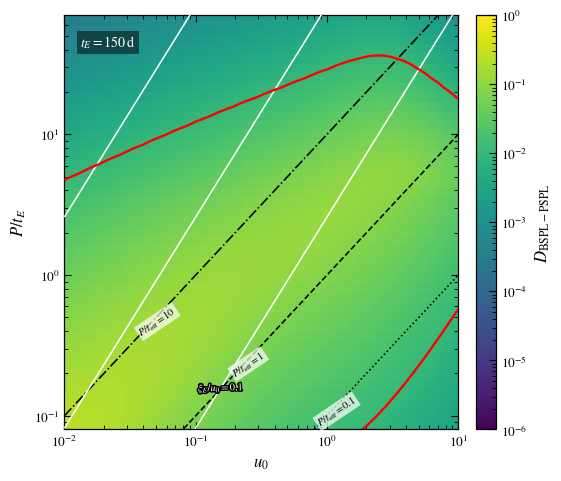

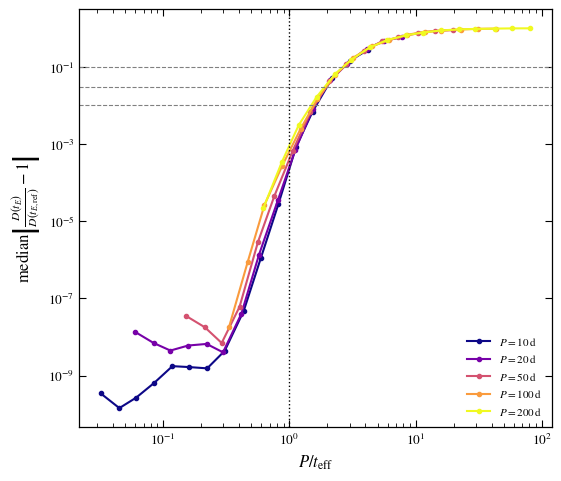

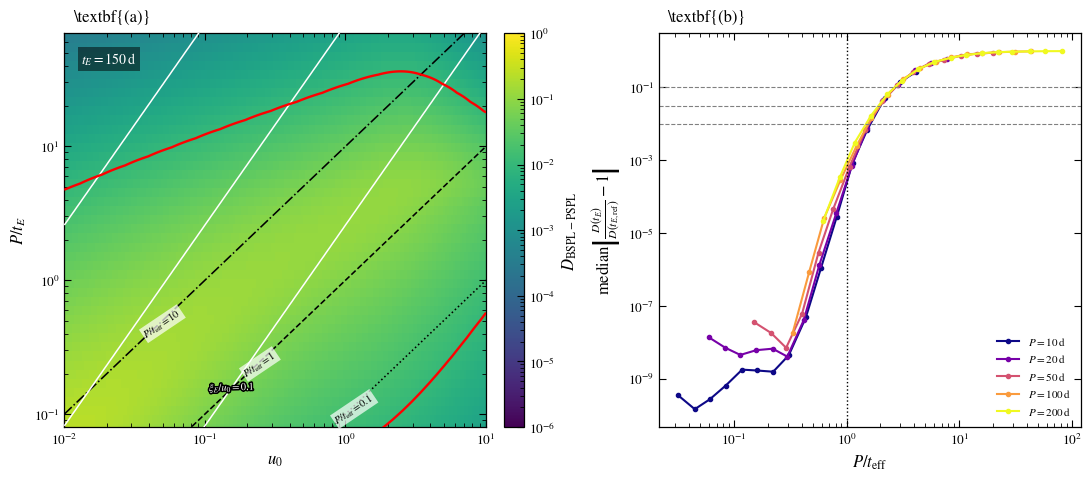

In [17]:
# ============================================================
# PHYSICAL CHARACTERIZATION OF THE BSPL--PSPL DEGENERACY
#
# PANEL (a)
# ---------
#
# D_BSPL-PSPL in the original rectangular plane:
#
#       x = u0
#       y = P/tE
#
# Overlaid physical scale ratios:
#
#       P/t_eff = P/(u0 tE) = 0.1, 1, 10
#
#       xi_E/u0 = 0.1, 1, 10
#
# plus:
#
#       D_BSPL-PSPL = 1e-2
#
#
# PANEL (b)
# ---------
#
# Fast-orbit convergence:
#
#       delta_D =
#       |D(u0,tE;P)/D(u0,tE_ref;P) - 1|
#
# versus
#
#       P/t_eff = P/(u0 tE)
#
# for several fixed orbital periods.
#
#
# IMPORTANT
# ---------
#
# In the current NPZ files:
#
#       xiE_of_P = xi_rel = a_rel / rEhat
#
# For the luminous primary:
#
#       xi_E = q/(1+q) * xi_rel
#
# ============================================================


import os
import glob
import re

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe


# ============================================================
# PAPER STYLE
# ============================================================

plt.rcParams.update({

    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",

    "font.size": 10,

    "axes.labelsize": 12,

    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,

    "axes.linewidth": 0.9,

    "xtick.direction": "in",
    "ytick.direction": "in",

    "xtick.top": True,
    "ytick.right": True,

    "xtick.major.size": 5,
    "ytick.major.size": 5,

    "xtick.minor.size": 3,
    "ytick.minor.size": 3,

    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,
})


# ============================================================
# PATHS
# ============================================================

home_path = os.path.expanduser("~")


base_directory = os.path.join(
    home_path,
    "binary_source",
    "results",
    "scan_many_tE_200x200",
)


output_directory = os.path.join(
    base_directory,
    "D_physical_characterization",
)


os.makedirs(
    output_directory,
    exist_ok=True,
)


# ============================================================
# tE VALUES AVAILABLE
# ============================================================

tE_list = np.array(
    [
        10,
        20,
        30,
        50,
        75,
        100,
        150,
        200,
        300,
        500,
        750,
        1000,
    ],
    dtype=float,
)


# ============================================================
# REPRESENTATIVE tE FOR PANEL (a)
# ============================================================

tE_map = 150.0


# ============================================================
# D COLOR SCALE
# ============================================================

D_VMIN = 1e-6
D_VMAX = 1.0


# ============================================================
# D REFERENCE LEVEL
# ============================================================

D_LEVEL = 1e-2


# ============================================================
# PHYSICAL SCALE LEVELS
# ============================================================

TEFF_LEVELS = np.array(
    [
        0.1,
        1.0,
        10.0,
    ]
)


XI_LEVELS = np.array(
    [
        0.1,
        1.0,
        10.0,
    ]
)


# ============================================================
# MAP LIMITS
# ============================================================

U0_MIN = 1e-2
U0_MAX = 1e1

PTE_MIN = 8e-2
PTE_MAX = 7e1


# ============================================================
# FAST-ORBIT TEST
# ============================================================

P_TARGETS = np.array(
    [
        10.0,
        20.0,
        50.0,
        100.0,
        200.0,
    ]
)


tE_REFERENCE = 1000.0


# Same u0 interval for all periods
COMMON_U0_MIN = 0.20
COMMON_U0_MAX = 0.50


# Require reference to satisfy:
#
#       P/(u0 tE_ref) <= 1
#
X_REFERENCE_MAX = 1.0


MIN_D = 1e-12
DELTA_FLOOR = 1e-10


# ============================================================
# OUTPUT
# ============================================================

output_panel_a_png = os.path.join(
    output_directory,
    "D_map_with_physical_scales.png",
)

output_panel_a_pdf = os.path.join(
    output_directory,
    "D_map_with_physical_scales.pdf",
)


output_panel_b_png = os.path.join(
    output_directory,
    "D_fast_orbit_convergence.png",
)

output_panel_b_pdf = os.path.join(
    output_directory,
    "D_fast_orbit_convergence.pdf",
)


output_combined_png = os.path.join(
    output_directory,
    "D_physical_characterization_combined.png",
)

output_combined_pdf = os.path.join(
    output_directory,
    "D_physical_characterization_combined.pdf",
)


# ============================================================
# HELPERS
# ============================================================

def format_tE_label(tE):

    return f"{float(tE):g}".replace(
        ".",
        "p",
    )


def extract_u0_index(filename):

    base = os.path.basename(
        filename
    )


    match = re.fullmatch(
        r"scan_kepler_u0_(\d+)\.npz",
        base,
    )


    if match is None:

        raise ValueError(
            f"Cannot extract u0 index from {base}"
        )


    return int(
        match.group(1)
    )


def log_bin_edges(x):

    x = np.asarray(
        x,
        dtype=float,
    )


    lx = np.log10(
        x
    )


    edges = np.empty(
        len(x) + 1
    )


    edges[1:-1] = 0.5 * (
        lx[:-1]
        +
        lx[1:]
    )


    edges[0] = (
        lx[0]
        -
        0.5
        *
        (
            lx[1]
            -
            lx[0]
        )
    )


    edges[-1] = (
        lx[-1]
        +
        0.5
        *
        (
            lx[-1]
            -
            lx[-2]
        )
    )


    return 10**edges


# ============================================================
# LOAD ONE tE SCAN
# ============================================================

def load_scan_for_tE(
    tE_true,
):


    label = format_tE_label(
        tE_true
    )


    directory = os.path.join(
        base_directory,
        f"scan_u0_tE{label}",
    )


    pattern = os.path.join(
        directory,
        "scan_kepler_u0_*.npz",
    )


    files = sorted(
        glob.glob(
            pattern
        )
    )


    if len(files) == 0:

        raise FileNotFoundError(
            pattern
        )


    records = []

    P_reference = None
    xi_rel_reference = None
    q_mass_reference = None


    # ========================================================
    # FIRST PASS
    # ========================================================

    for filename in files:


        with np.load(
            filename,
            allow_pickle=False,
        ) as d:


            truth = d[
                "truth"
            ].astype(float)


            P_grid = d[
                "P_grid"
            ].astype(float)


            xi_rel = d[
                "xiE_of_P"
            ].astype(float)


        u0_true = float(
            truth[1]
        )


        M1 = float(
            truth[5]
        )


        M2 = float(
            truth[6]
        )


        q_mass = (
            M2
            /
            M1
        )


        if P_reference is None:

            P_reference = (
                P_grid.copy()
            )


            xi_rel_reference = (
                xi_rel.copy()
            )


            q_mass_reference = (
                q_mass
            )


        else:


            if not np.allclose(
                P_grid,
                P_reference,
            ):

                raise ValueError(
                    "Inconsistent P_grid"
                )


            if not np.allclose(
                xi_rel,
                xi_rel_reference,
            ):

                raise ValueError(
                    "Inconsistent xi_rel"
                )


        records.append(
            {

                "filename":
                    filename,

                "u0":
                    u0_true,

                "index":
                    extract_u0_index(
                        filename
                    ),
            }
        )


    # ========================================================
    # SORT
    # ========================================================

    records = sorted(
        records,
        key=lambda row:
            row["u0"],
    )


    u0_grid = np.array(
        [
            row[
                "u0"
            ]

            for row in records
        ]
    )


    Nu0 = len(
        u0_grid
    )


    NP = len(
        P_reference
    )


    # ========================================================
    # LOAD D
    # ========================================================

    D_map = np.full(
        (
            Nu0,
            NP,
        ),
        np.nan,
    )


    for i, record in enumerate(
        records
    ):


        with np.load(
            record[
                "filename"
            ],
            allow_pickle=False,
        ) as d:


            D = d[
                "D"
            ].astype(float)


            SUCCESS = d[
                "SUCCESS"
            ].astype(bool)


        valid = (
            SUCCESS
            &
            np.isfinite(
                D
            )
            &
            (
                D > 0
            )
        )


        D_map[
            i,
            valid,
        ] = D[
            valid
        ]


    # ========================================================
    # PRIMARY ORBITAL AMPLITUDE
    # ========================================================

    xi_E = (

        q_mass_reference

        /

        (
            1.0
            +
            q_mass_reference
        )

        *

        xi_rel_reference
    )


    return {

        "tE":
            float(
                tE_true
            ),

        "u0":
            u0_grid,

        "P":
            P_reference,

        "xi_E":
            xi_E,

        "D":
            D_map,

        "q_mass":
            q_mass_reference,
    }


# ============================================================
# LOAD ALL RESULTS
# ============================================================

results = {}


print()

print("=" * 90)

print("LOADING D SCANS")

print("=" * 90)


for tE in tE_list:


    try:

        result = load_scan_for_tE(
            tE
        )


    except FileNotFoundError:

        print(
            f"Missing tE={tE:g} d"
        )

        continue


    results[
        float(
            tE
        )
    ] = result


    print(
        f"tE={tE:7.1f} d loaded"
    )


# ============================================================
# GET FIXED-tE MAP
# ============================================================

if tE_map not in results:

    raise RuntimeError(
        f"tE={tE_map:g} not available"
    )


map_result = results[
    tE_map
]


u0_grid = map_result[
    "u0"
]


P_grid = map_result[
    "P"
]


xi_E_grid = map_result[
    "xi_E"
]


D_map = map_result[
    "D"
]


P_over_tE = (
    P_grid
    /
    tE_map
)


# ============================================================
# RECTANGULAR MAP GRID
# ============================================================

U2D, PTE2D = np.meshgrid(

    u0_grid,

    P_over_tE,

    indexing="xy",
)


D2D = D_map.T


# ============================================================
# PHYSICAL RATIOS OVER ORIGINAL RECTANGULAR GRID
# ============================================================

P_OVER_TEFF = (

    PTE2D
    /
    U2D
)


XI2D = np.broadcast_to(

    xi_E_grid[
        :,
        None
    ],

    (
        len(
            P_grid
        ),

        len(
            u0_grid
        ),
    ),
)


XI_OVER_U0 = (

    XI2D
    /
    U2D
)


# ============================================================
# PANEL (a) FUNCTION
# ============================================================

def draw_panel_a(
    ax,
):


    # --------------------------------------------------------
    # Pcolormesh edges
    # --------------------------------------------------------

    u_edges = log_bin_edges(
        u0_grid
    )


    pte_edges = log_bin_edges(
        P_over_tE
    )


    norm_D = mcolors.LogNorm(

        vmin=D_VMIN,

        vmax=D_VMAX,
    )


    pcm = ax.pcolormesh(

        u_edges,

        pte_edges,

        np.ma.masked_invalid(
            D_map
        ).T,

        cmap="viridis",

        norm=norm_D,

        shading="auto",

        rasterized=True,
    )


    # ========================================================
    # D = 1e-2 CONTOUR
    # ========================================================

    cs_D = ax.contour(

        U2D,

        PTE2D,

        np.ma.masked_invalid(
            D2D
        ),

        levels=[
            D_LEVEL
        ],

        colors="red",

        linewidths=1.7,

        zorder=8,
    )


    # ========================================================
    # TEMPORAL SCALE LINES
    #
    # P/t_eff = P/(u0 tE) = eta
    #
    # Therefore:
    #
    #       P/tE = eta * u0
    #
    # We draw them analytically.
    # ========================================================

    u_line = np.logspace(

        np.log10(
            U0_MIN
        ),

        np.log10(
            U0_MAX
        ),

        500,
    )


    temporal_styles = {
        0.1: ":",
        1.0: "--",
        10.0: "-.",
    }


    for eta in TEFF_LEVELS:


        y_line = (
            eta
            *
            u_line
        )


        visible = (
            (y_line >= PTE_MIN)
            &
            (y_line <= PTE_MAX)
        )


        ax.plot(

            u_line[
                visible
            ],

            y_line[
                visible
            ],

            color="black",

            linestyle=temporal_styles[
                float(
                    eta
                )
            ],

            linewidth=1.15,

            zorder=7,
        )


    # ========================================================
    # SPATIAL SCALE CONTOURS
    #
    # xi_E/u0 = constant
    # ========================================================

    cs_xi = ax.contour(

        U2D,

        PTE2D,

        XI_OVER_U0,

        levels=XI_LEVELS,

        colors="white",

        linewidths=1.1,

        linestyles="-",

        zorder=7,
    )


    # ========================================================
    # LABEL xi_E/u0 CONTOURS
    # ========================================================

    xi_fmt = {

        0.1:
            r"$\xi_E/u_0=0.1$",

        1.0:
            r"$\xi_E/u_0=1$",

        10.0:
            r"$\xi_E/u_0=10$",
    }


    labels = ax.clabel(

        cs_xi,

        fmt=xi_fmt,

        fontsize=7.5,

        inline=False,

        colors="white",
    )


    for text in labels:

        text.set_path_effects(
            [

                pe.Stroke(
                    linewidth=2.2,
                    foreground="black",
                ),

                pe.Normal(),
            ]
        )


    # ========================================================
    # MANUAL LABELS FOR TEMPORAL LINES
    # ========================================================

    temporal_label_positions = {

        0.1:
            0.80,

        1.0:
            0.18,

        10.0:
            0.035,
    }


    for eta in TEFF_LEVELS:


        x_text = temporal_label_positions[
            float(
                eta
            )
        ]


        y_text = (
            eta
            *
            x_text
        )


        if (
            U0_MIN
            <=
            x_text
            <=
            U0_MAX
            and
            PTE_MIN
            <=
            y_text
            <=
            PTE_MAX
        ):


            ax.text(

                x_text,

                y_text,

                rf"$P/t_{{\rm eff}}={eta:g}$",

                fontsize=7.5,

                color="black",

                rotation=34,

                ha="left",

                va="bottom",

                bbox=dict(

                    facecolor="white",

                    edgecolor="none",

                    alpha=0.70,

                    pad=1.0,
                ),

                zorder=10,
            )


    # ========================================================
    # tE LABEL
    # ========================================================

    ax.text(

        0.04,
        0.955,

        rf"$t_E={tE_map:.0f}\,\mathrm{{d}}$",

        transform=ax.transAxes,

        color="white",

        ha="left",

        va="top",

        bbox=dict(

            facecolor="black",

            edgecolor="none",

            alpha=0.50,

            pad=2.5,
        ),
    )


    # ========================================================
    # AXES
    # ========================================================

    ax.set_xscale(
        "log"
    )


    ax.set_yscale(
        "log"
    )


    ax.set_xlim(
        U0_MIN,
        U0_MAX,
    )


    ax.set_ylim(
        PTE_MIN,
        PTE_MAX,
    )


    ax.set_xlabel(
        r"$u_0$"
    )


    ax.set_ylabel(
        r"$P/t_E$"
    )


    ax.grid(
        False
    )


    return pcm


# ============================================================
# BUILD FAST-ORBIT DATASET FOR PANEL (b)
# ============================================================

def get_D_slice_at_P(
    result,
    P_target,
):


    P_grid = result[
        "P"
    ]


    j = np.argmin(

        np.abs(

            np.log10(
                P_grid
            )

            -

            np.log10(
                P_target
            )
        )
    )


    return (

        result[
            "u0"
        ],

        result[
            "D"
        ][
            :,
            j
        ],

        P_grid[
            j
        ],
    )


# ============================================================
# INTERPOLATE D TO COMMON u0
# ============================================================

def interpolate_D(
    u0,
    D,
    u_ref,
):


    valid = (

        np.isfinite(
            u0
        )

        &

        np.isfinite(
            D
        )

        &

        (
            u0 > 0
        )

        &

        (
            D > MIN_D
        )
    )


    if np.count_nonzero(
        valid
    ) < 2:

        return np.full_like(
            u_ref,
            np.nan,
        )


    logu = np.log10(
        u0[
            valid
        ]
    )


    logD = np.log10(
        D[
            valid
        ]
    )


    order = np.argsort(
        logu
    )


    logu = logu[
        order
    ]


    logD = logD[
        order
    ]


    output = np.full_like(
        u_ref,
        np.nan,
        dtype=float,
    )


    inside = (

        (
            u_ref
            >=
            10**logu.min()
        )

        &

        (
            u_ref
            <=
            10**logu.max()
        )
    )


    output[
        inside
    ] = 10**np.interp(

        np.log10(
            u_ref[
                inside
            ]
        ),

        logu,

        logD,
    )


    return output


# ============================================================
# REFERENCE RESULT
# ============================================================

reference_result = results[
    float(
        tE_REFERENCE
    )
]


rows = []


for P_target in P_TARGETS:


    (
        u_ref,
        D_ref_raw,
        P_ref,
    ) = get_D_slice_at_P(

        reference_result,

        P_target,
    )


    D_ref = interpolate_D(

        u_ref,

        D_ref_raw,

        u_ref,
    )


    for tE in tE_list:


        if np.isclose(
            tE,
            tE_REFERENCE,
        ):

            continue


        if float(
            tE
        ) not in results:

            continue


        (
            u_current,
            D_current_raw,
            P_actual,
        ) = get_D_slice_at_P(

            results[
                float(
                    tE
                )
            ],

            P_target,
        )


        D_current = interpolate_D(

            u_current,

            D_current_raw,

            u_ref,
        )


        valid = (

            np.isfinite(
                D_current
            )

            &

            np.isfinite(
                D_ref
            )

            &

            (
                D_current
                >
                MIN_D
            )

            &

            (
                D_ref
                >
                MIN_D
            )

            &

            (
                u_ref
                >=
                COMMON_U0_MIN
            )

            &

            (
                u_ref
                <=
                COMMON_U0_MAX
            )
        )


        for u0, D_now, D_reference in zip(

            u_ref[
                valid
            ],

            D_current[
                valid
            ],

            D_ref[
                valid
            ],
        ):


            eta = (

                P_actual

                /

                (
                    u0
                    *
                    tE
                )
            )


            eta_ref = (

                P_ref

                /

                (
                    u0
                    *
                    tE_REFERENCE
                )
            )


            delta_D = np.abs(

                D_now
                /
                D_reference

                -
                1.0
            )


            if eta_ref > X_REFERENCE_MAX:

                continue


            rows.append(
                {

                    "P_target":
                        P_target,

                    "P":
                        P_actual,

                    "tE":
                        tE,

                    "u0":
                        u0,

                    "eta":
                        eta,

                    "delta_D":
                        delta_D,
                }
            )


df = pd.DataFrame(
    rows
)


df[
    "delta_plot"
] = np.maximum(

    df[
        "delta_D"
    ],

    DELTA_FLOOR,
)


# ============================================================
# BINNING FUNCTION
# ============================================================

def binned_statistics(
    x,
    y,
    n_bins=16,
):


    x = np.asarray(
        x
    )


    y = np.asarray(
        y
    )


    valid = (

        np.isfinite(
            x
        )

        &

        np.isfinite(
            y
        )

        &

        (
            x > 0
        )

        &

        (
            y > 0
        )
    )


    x = x[
        valid
    ]


    y = y[
        valid
    ]


    if len(
        x
    ) < 5:

        return (
            np.array([]),
            np.array([]),
        )


    lx = np.log10(
        x
    )


    edges = np.linspace(

        lx.min(),

        lx.max(),

        n_bins + 1,
    )


    x_out = []
    y_out = []


    for i in range(
        n_bins
    ):


        select = (

            (
                lx
                >=
                edges[i]
            )

            &

            (
                lx
                <
                edges[i + 1]
            )
        )


        if i == n_bins - 1:

            select = (

                (
                    lx
                    >=
                    edges[i]
                )

                &

                (
                    lx
                    <=
                    edges[i + 1]
                )
            )


        if np.count_nonzero(
            select
        ) < 3:

            continue


        x_out.append(

            10**
            np.mean(
                np.log10(
                    x[
                        select
                    ]
                )
            )
        )


        y_out.append(

            np.median(
                y[
                    select
                ]
            )
        )


    return (

        np.asarray(
            x_out
        ),

        np.asarray(
            y_out
        ),
    )


# ============================================================
# PANEL (b) FUNCTION
# ============================================================

def draw_panel_b(
    ax,
):


    norm_P = mcolors.LogNorm(

        vmin=np.min(
            P_TARGETS
        ),

        vmax=np.max(
            P_TARGETS
        ),
    )


    cmap = plt.get_cmap(
        "plasma"
    )


    for P_target in P_TARGETS:


        sub = df[

            np.isclose(
                df[
                    "P_target"
                ],
                P_target,
            )

        ]


        x, y = binned_statistics(

            sub[
                "eta"
            ],

            sub[
                "delta_plot"
            ],
        )


        color = cmap(
            norm_P(
                P_target
            )
        )


        ax.plot(

            x,

            y,

            marker="o",

            markersize=3,

            lw=1.5,

            color=color,

            label=(
                rf"$P={P_target:g}\,\mathrm{{d}}$"
            ),
        )


    # ========================================================
    # CONVERGENCE LEVELS
    # ========================================================

    for level in [
        0.10,
        0.03,
        0.01,
    ]:


        ax.axhline(

            level,

            color="gray",

            linestyle="--",

            linewidth=0.8,
        )


    # ========================================================
    # eta = 1
    # ========================================================

    ax.axvline(

        1.0,

        color="black",

        linestyle=":",

        linewidth=1.0,
    )


    ax.set_xscale(
        "log"
    )


    ax.set_yscale(
        "log"
    )


    ax.set_xlabel(
        r"$P/t_{\rm eff}$"
    )


    ax.set_ylabel(

        r"$\mathrm{median}\left|"
        r"\frac{D(t_E)}"
        r"{D(t_{E,\rm ref})}"
        r"-1"
        r"\right|$"
    )


    ax.legend(

        frameon=False,

        fontsize=8,
    )


    ax.grid(
        False
    )


# ============================================================
# ============================================================
#
# FIGURE A — MAP ONLY
#
# ============================================================
# ============================================================

fig_a, ax_a = plt.subplots(

    figsize=(
        5.5,
        4.7,
    ),

    constrained_layout=True,
)


pcm_a = draw_panel_a(
    ax_a
)


cbar_a = fig_a.colorbar(

    pcm_a,

    ax=ax_a,

    pad=0.02,
)


cbar_a.set_label(
    r"$D_{\rm BSPL-PSPL}$"
)


fig_a.savefig(

    output_panel_a_png,

    dpi=600,

    bbox_inches="tight",
)


fig_a.savefig(

    output_panel_a_pdf,

    bbox_inches="tight",
)


# ============================================================
# ============================================================
#
# FIGURE B — FAST-ORBIT TEST ONLY
#
# ============================================================
# ============================================================

fig_b, ax_b = plt.subplots(

    figsize=(
        5.5,
        4.7,
    ),

    constrained_layout=True,
)


draw_panel_b(
    ax_b
)


fig_b.savefig(

    output_panel_b_png,

    dpi=600,

    bbox_inches="tight",
)


fig_b.savefig(

    output_panel_b_pdf,

    bbox_inches="tight",
)


# ============================================================
# ============================================================
#
# COMBINED PAPER FIGURE
#
# ============================================================
# ============================================================

fig, axes = plt.subplots(

    1,
    2,

    figsize=(
        10.8,
        4.7,
    ),

    constrained_layout=True,
)


# ------------------------------------------------------------
# PANEL A
# ------------------------------------------------------------

pcm = draw_panel_a(
    axes[0]
)


axes[0].text(

    0.02,
    1.02,

    r"\textbf{(a)}",

    transform=axes[0].transAxes,

    ha="left",

    va="bottom",

    fontsize=12,
)


# ------------------------------------------------------------
# PANEL B
# ------------------------------------------------------------

draw_panel_b(
    axes[1]
)


axes[1].text(

    0.02,
    1.02,

    r"\textbf{(b)}",

    transform=axes[1].transAxes,

    ha="left",

    va="bottom",

    fontsize=12,
)


# ------------------------------------------------------------
# COLORBAR FOR PANEL A
# ------------------------------------------------------------

cbar = fig.colorbar(

    pcm,

    ax=axes[0],

    pad=0.02,
)


cbar.set_label(
    r"$D_{\rm BSPL-PSPL}$"
)


# ============================================================
# SAVE COMBINED
# ============================================================

fig.savefig(

    output_combined_png,

    dpi=600,

    bbox_inches="tight",
)


fig.savefig(

    output_combined_pdf,

    bbox_inches="tight",
)


# ============================================================
# SUMMARY
# ============================================================

print()

print("=" * 90)

print("FILES GENERATED")

print("=" * 90)

print()

print("Panel A:")
print(output_panel_a_png)
print(output_panel_a_pdf)

print()

print("Panel B:")
print(output_panel_b_png)
print(output_panel_b_pdf)

print()

print("Combined:")
print(output_combined_png)
print(output_combined_pdf)

print()

print("=" * 90)


plt.show()


P target = 10 d
P actual = 10 d

P target = 20 d
P actual = 18.671811 d

P target = 50 d
P actual = 47.63938 d

P target = 100 d
P actual = 103.97984 d

P target = 200 d
P actual = 194.14919 d

REFERENCE VALIDITY
P=  10.0 d : 100.00% of points have P/(u0 tE_ref) <= 1
P=  20.0 d :  84.07% of points have P/(u0 tE_ref) <= 1
P=  50.0 d :  60.18% of points have P/(u0 tE_ref) <= 1
P= 100.0 d :  39.82% of points have P/(u0 tE_ref) <= 1
P= 200.0 d :  23.89% of points have P/(u0 tE_ref) <= 1

Total points               = 6215
Points used quantitatively = 3828

COLLAPSE QUALITY FOR EACH PERIOD


,P,N,rho_P_tE,rho_P_u0tE,scatter_P_tE_dex,scatter_P_u0tE_dex
0,10.0,1243,0.712433,0.990095,6.727407,0.607404
1,20.0,1045,0.782426,0.993547,4.883085,0.398767
2,50.0,748,0.882334,0.998105,1.965777,0.232296
3,100.0,495,0.952473,0.998657,0.683288,0.122743
4,200.0,297,0.984936,0.998972,0.220839,0.071619



ALL PERIODS COMBINED
P/tE:
    Spearman rho = 0.792200
    p-value      = 0.000e+00

P/(u0 tE):
    Spearman rho = 0.996388
    p-value      = 0.000e+00

CRITICAL P/(u0 tE) FOR EACH PERIOD


,P,tolerance,N,median_xcrit,q16,q84
0,10.0,0.10,113,2.094742,1.661566,2.469276
1,10.0,0.03,109,1.500918,1.221935,1.799719
2,10.0,0.01,105,1.218128,1.024357,1.430452
3,20.0,0.10,95,2.167881,1.805298,2.517657
4,20.0,0.03,95,1.517050,1.261159,1.781784
5,20.0,0.01,94,1.223682,1.010071,1.431086
6,50.0,0.10,68,2.181064,1.858911,2.492831
7,50.0,0.03,68,1.533708,1.297363,1.779405
8,50.0,0.01,65,1.215596,1.025467,1.397829
9,100.0,0.10,45,2.156740,1.832821,2.474282



First rows of complete dataset:


,P_target,P,tE,u0,P_over_tE,P_over_u0tE,x_reference,RMS,RMS_ref,delta_R,delta_plot,reference_fast
0,10.0,10.0,10.0,0.010000,1.0,100.000000,1.000000,0.049346,4.772043,0.989659,0.989659,True
1,10.0,10.0,10.0,0.010353,1.0,96.588322,0.965883,0.049258,4.422518,0.988862,0.988862,True
2,10.0,10.0,10.0,0.010719,1.0,93.293040,0.932930,0.049168,4.081608,0.987954,0.987954,True
3,10.0,10.0,10.0,0.011098,1.0,90.110183,0.901102,0.049074,3.759783,0.986948,0.986948,True
4,10.0,10.0,10.0,0.011490,1.0,87.035914,0.870359,0.048978,3.462504,0.985855,0.985855,True
5,10.0,10.0,10.0,0.011895,1.0,84.066529,0.840665,0.048878,3.191542,0.984685,0.984685,True
6,10.0,10.0,10.0,0.012316,1.0,81.198450,0.811984,0.048775,2.946358,0.983446,0.983446,True
7,10.0,10.0,10.0,0.012751,1.0,78.428221,0.784282,0.048669,2.725180,0.982141,0.982141,True
8,10.0,10.0,10.0,0.013201,1.0,75.752503,0.757525,0.048559,2.525707,0.980774,0.980774,True
9,10.0,10.0,10.0,0.013667,1.0,73.168071,0.731681,0.048445,2.345537,0.979346,0.979346,True


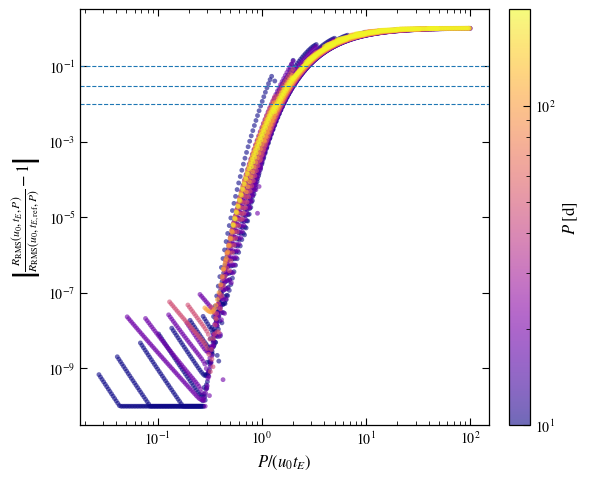

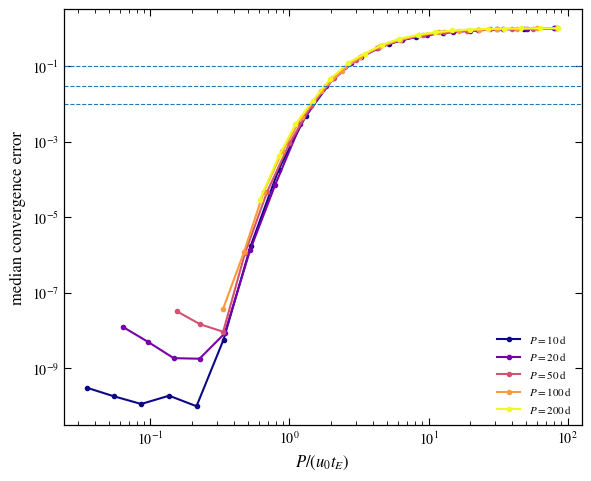

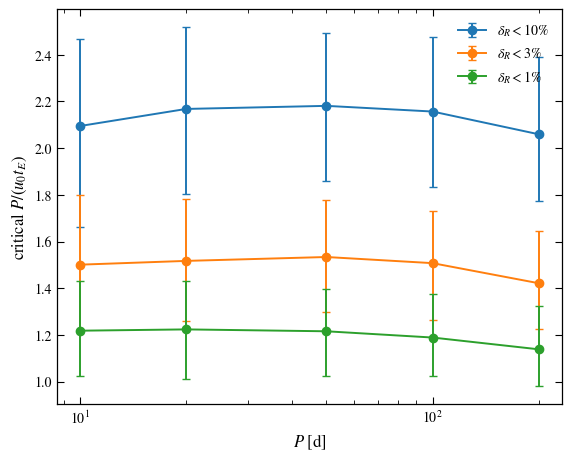

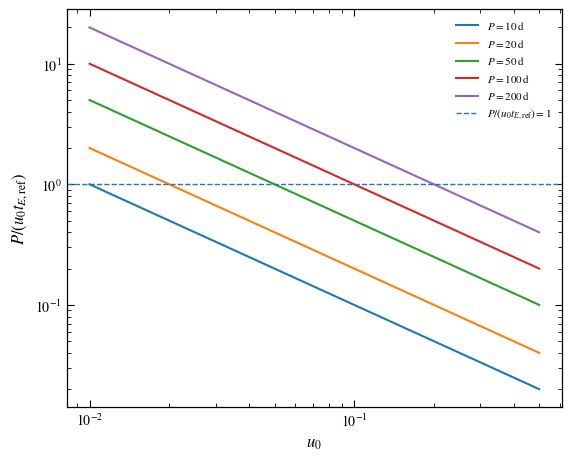

In [11]:
# ============================================================
# MULTI-P TEST OF THE LOCAL FAST-ORBIT TIMESCALE
#
# Goal:
#
# Test whether the convergence toward the long-tE limit for
# several FIXED orbital periods is better organized by
#
#       P / (u0 tE)
#
# than by
#
#       P / tE.
#
#
# Periods tested:
#
#       P = 10, 20, 50, 100, 200 days
#
#
# For every P and u0:
#
#       delta_R =
#       | RMS(u0,tE,P) / RMS(u0,tE_ref,P) - 1 |
#
#
# IMPORTANT:
#
# tE_ref = 1000 d is only a finite reference, not necessarily
# the true asymptotic limit.
#
# Therefore we also calculate:
#
#       x_ref = P / (u0 tE_ref)
#
# and can restrict the analysis to regions where the reference
# itself satisfies:
#
#       x_ref <= X_REF_MAX
#
# ============================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from scipy.stats import spearmanr


# ============================================================
# CONFIGURATION
# ============================================================

P_TARGETS = np.array(
    [
        10.0,
        20.0,
        50.0,
        100.0,
        200.0,
    ]
)


# ------------------------------------------------------------
# Longest-tE reference
# ------------------------------------------------------------

tE_REFERENCE = 1000.0


# ------------------------------------------------------------
# tE values to compare
# ------------------------------------------------------------

tE_COMPARE = np.array(
    [
        10,
        20,
        30,
        50,
        75,
        100,
        150,
        200,
        300,
        500,
        750,
        1000,
    ],
    dtype=float,
)


# ------------------------------------------------------------
# u0 region
# ------------------------------------------------------------

U0_MIN = 1e-2
U0_MAX = 5e-1


# ------------------------------------------------------------
# Require the reference itself to be at least in the
# approximate fast-orbit regime:
#
#       P/(u0 tE_ref) <= X_REF_MAX
#
# X_REF_MAX = 1 is deliberately permissive.
#
# Set REQUIRE_FAST_REFERENCE = False if you want to inspect
# all points regardless of this condition.
# ------------------------------------------------------------

REQUIRE_FAST_REFERENCE = True

X_REF_MAX = 1.0


# ------------------------------------------------------------
# Numerical floor for log plots
# ------------------------------------------------------------

DELTA_FLOOR = 1e-10


# ------------------------------------------------------------
# Convergence levels
# ------------------------------------------------------------

CONVERGENCE_LEVELS = [
    0.10,
    0.03,
    0.01,
]


# ------------------------------------------------------------
# Number of logarithmic bins
# ------------------------------------------------------------

N_BINS = 18


# ============================================================
# PAPER STYLE
# ============================================================

plt.rcParams.update({

    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",

    "font.size": 10,

    "axes.labelsize": 12,

    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    "axes.linewidth": 0.9,

    "xtick.direction": "in",
    "ytick.direction": "in",

    "xtick.top": True,
    "ytick.right": True,

    "xtick.major.size": 5,
    "ytick.major.size": 5,

    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
})


# ============================================================
# HELPERS
# ============================================================

def get_result_for_tE(
    results,
    tE,
):

    for result in results:

        if np.isclose(
            result["tE_true"],
            tE,
        ):

            return result


    raise ValueError(
        f"No result found for tE={tE:g} d."
    )


# ============================================================
# EXTRACT RMS(u0) AT FIXED P
# ============================================================

def get_RMS_slice_at_P(
    result,
    P_target,
):

    u0 = np.asarray(
        result["u0_grid"],
        dtype=float,
    )


    P_grid = np.asarray(
        result["P_grid"],
        dtype=float,
    )


    RMS_map = np.asarray(
        result["metric_map"],
        dtype=float,
    )


    # --------------------------------------------------------
    # Closest simulated period
    # --------------------------------------------------------

    jP = np.argmin(
        np.abs(
            np.log10(P_grid)
            -
            np.log10(P_target)
        )
    )


    P_actual = P_grid[
        jP
    ]


    RMS_slice = RMS_map[
        :,
        jP
    ].copy()


    return (
        u0,
        RMS_slice,
        P_actual,
    )


# ============================================================
# INTERPOLATE RMS TO COMMON u0 GRID
# ============================================================

def interpolate_RMS(
    u0,
    RMS,
    u0_reference,
):

    valid = (
        np.isfinite(u0)
        &
        np.isfinite(RMS)
        &
        (u0 > 0)
        &
        (RMS > 0)
    )


    if np.count_nonzero(
        valid
    ) < 2:

        return np.full_like(
            u0_reference,
            np.nan,
            dtype=float,
        )


    logu = np.log10(
        u0[
            valid
        ]
    )


    logR = np.log10(
        RMS[
            valid
        ]
    )


    order = np.argsort(
        logu
    )


    logu = logu[
        order
    ]


    logR = logR[
        order
    ]


    output = np.full_like(
        u0_reference,
        np.nan,
        dtype=float,
    )


    inside = (
        (u0_reference >= 10**logu.min())
        &
        (u0_reference <= 10**logu.max())
    )


    output[
        inside
    ] = 10**np.interp(

        np.log10(
            u0_reference[
                inside
            ]
        ),

        logu,

        logR,
    )


    return output


# ============================================================
# BUILD COMPLETE MULTI-P DATASET
# ============================================================

rows = []


result_reference = get_result_for_tE(
    results,
    tE_REFERENCE,
)


for P_target in P_TARGETS:


    # ========================================================
    # REFERENCE CURVE FOR THIS P
    # ========================================================

    (
        u0_reference,
        RMS_reference_raw,
        P_reference_actual,
    ) = get_RMS_slice_at_P(

        result_reference,

        P_target,
    )


    RMS_reference = interpolate_RMS(

        u0_reference,

        RMS_reference_raw,

        u0_reference,
    )


    print()

    print("=" * 90)

    print(
        f"P target = {P_target:g} d"
    )

    print(
        f"P actual = {P_reference_actual:.8g} d"
    )

    print("=" * 90)


    # ========================================================
    # LOOP OVER tE
    # ========================================================

    for tE in tE_COMPARE:


        if np.isclose(
            tE,
            tE_REFERENCE,
        ):

            continue


        try:

            result = get_result_for_tE(
                results,
                tE,
            )

        except ValueError:

            continue


        (
            u0_current,
            RMS_current_raw,
            P_actual,
        ) = get_RMS_slice_at_P(

            result,

            P_target,
        )


        RMS_current = interpolate_RMS(

            u0_current,

            RMS_current_raw,

            u0_reference,
        )


        # ----------------------------------------------------
        # Common valid points
        # ----------------------------------------------------

        valid = (
            np.isfinite(
                RMS_current
            )
            &
            np.isfinite(
                RMS_reference
            )
            &
            (RMS_current > 0)
            &
            (RMS_reference > 0)
            &
            (u0_reference >= U0_MIN)
            &
            (u0_reference <= U0_MAX)
        )


        for (
            u0,
            rms,
            rms_ref
        ) in zip(

            u0_reference[
                valid
            ],

            RMS_current[
                valid
            ],

            RMS_reference[
                valid
            ],
        ):


            x_global = (
                P_actual
                /
                tE
            )


            x_local = (
                P_actual
                /
                (
                    u0
                    *
                    tE
                )
            )


            x_reference = (
                P_reference_actual
                /
                (
                    u0
                    *
                    tE_REFERENCE
                )
            )


            delta_R = np.abs(
                rms
                /
                rms_ref
                -
                1.0
            )


            rows.append(
                {

                    "P_target":
                        float(
                            P_target
                        ),

                    "P":
                        float(
                            P_actual
                        ),

                    "tE":
                        float(
                            tE
                        ),

                    "u0":
                        float(
                            u0
                        ),

                    "P_over_tE":
                        float(
                            x_global
                        ),

                    "P_over_u0tE":
                        float(
                            x_local
                        ),

                    "x_reference":
                        float(
                            x_reference
                        ),

                    "RMS":
                        float(
                            rms
                        ),

                    "RMS_ref":
                        float(
                            rms_ref
                        ),

                    "delta_R":
                        float(
                            delta_R
                        ),
                }
            )


df_all = pd.DataFrame(
    rows
)


if len(
    df_all
) == 0:

    raise RuntimeError(
        "No valid points found."
    )


# ============================================================
# FLOOR ONLY FOR LOG PLOTS
# ============================================================

df_all[
    "delta_plot"
] = np.maximum(

    df_all[
        "delta_R"
    ],

    DELTA_FLOOR,
)


# ============================================================
# REFERENCE VALIDITY FLAG
# ============================================================

df_all[
    "reference_fast"
] = (
    df_all[
        "x_reference"
    ]
    <=
    X_REF_MAX
)


print()

print("=" * 90)

print("REFERENCE VALIDITY")

print("=" * 90)


for P_target in P_TARGETS:


    sub = df_all[

        np.isclose(
            df_all[
                "P_target"
            ],
            P_target,
        )

    ]


    fraction = np.mean(
        sub[
            "reference_fast"
        ]
    )


    print(

        f"P={P_target:6.1f} d : "

        f"{100*fraction:6.2f}% of points have "

        f"P/(u0 tE_ref) <= {X_REF_MAX:g}"
    )


print("=" * 90)


# ============================================================
# DATAFRAME USED FOR QUANTITATIVE TEST
# ============================================================

if REQUIRE_FAST_REFERENCE:

    df = df_all[
        df_all[
            "reference_fast"
        ]
    ].copy()

else:

    df = df_all.copy()


print()

print(
    f"Total points               = {len(df_all)}"
)

print(
    f"Points used quantitatively = {len(df)}"
)


# ============================================================
# BINNED STATISTICS
# ============================================================

def binned_statistics(
    x,
    y,
    n_bins=18,
):

    x = np.asarray(
        x,
        dtype=float,
    )


    y = np.asarray(
        y,
        dtype=float,
    )


    valid = (
        np.isfinite(x)
        &
        np.isfinite(y)
        &
        (x > 0)
        &
        (y > 0)
    )


    x = x[
        valid
    ]

    y = y[
        valid
    ]


    if len(
        x
    ) < 5:

        return {

            "x":
                np.array([]),

            "median":
                np.array([]),

            "q16":
                np.array([]),

            "q84":
                np.array([]),
        }


    logx = np.log10(
        x
    )


    edges = np.linspace(

        logx.min(),

        logx.max(),

        n_bins + 1,
    )


    centers = []

    medians = []

    q16 = []

    q84 = []


    for i in range(
        n_bins
    ):


        select = (
            (logx >= edges[i])
            &
            (logx < edges[i + 1])
        )


        if i == n_bins - 1:

            select = (
                (logx >= edges[i])
                &
                (logx <= edges[i + 1])
            )


        if np.count_nonzero(
            select
        ) < 3:

            continue


        xb = x[
            select
        ]

        yb = y[
            select
        ]


        centers.append(

            10**
            np.mean(
                np.log10(
                    xb
                )
            )
        )


        medians.append(
            np.median(
                yb
            )
        )


        q16.append(
            np.percentile(
                yb,
                16,
            )
        )


        q84.append(
            np.percentile(
                yb,
                84,
            )
        )


    return {

        "x":
            np.asarray(
                centers
            ),

        "median":
            np.asarray(
                medians
            ),

        "q16":
            np.asarray(
                q16
            ),

        "q84":
            np.asarray(
                q84
            ),
    }


# ============================================================
# TYPICAL BINNED SCATTER
# ============================================================

def typical_scatter(
    stats,
):

    valid = (
        np.isfinite(
            stats["q16"]
        )
        &
        np.isfinite(
            stats["q84"]
        )
        &
        (stats["q16"] > 0)
        &
        (stats["q84"] > 0)
    )


    if not np.any(
        valid
    ):

        return np.nan


    widths = (

        np.log10(
            stats[
                "q84"
            ][
                valid
            ]
        )

        -

        np.log10(
            stats[
                "q16"
            ][
                valid
            ]
        )
    )


    return np.median(
        widths
    )


# ============================================================
# RESULTS PER PERIOD
# ============================================================

summary_rows = []


for P_target in P_TARGETS:


    sub = df[

        np.isclose(
            df[
                "P_target"
            ],
            P_target,
        )

    ].copy()


    if len(
        sub
    ) < 5:

        print(
            f"P={P_target:g}: insufficient valid points."
        )

        continue


    log_delta = np.log10(
        sub[
            "delta_plot"
        ]
    )


    log_global = np.log10(
        sub[
            "P_over_tE"
        ]
    )


    log_local = np.log10(
        sub[
            "P_over_u0tE"
        ]
    )


    rho_global, _ = spearmanr(
        log_global,
        log_delta,
    )


    rho_local, _ = spearmanr(
        log_local,
        log_delta,
    )


    stats_global = binned_statistics(

        sub[
            "P_over_tE"
        ],

        sub[
            "delta_plot"
        ],

        N_BINS,
    )


    stats_local = binned_statistics(

        sub[
            "P_over_u0tE"
        ],

        sub[
            "delta_plot"
        ],

        N_BINS,
    )


    scatter_global = typical_scatter(
        stats_global
    )


    scatter_local = typical_scatter(
        stats_local
    )


    summary_rows.append(
        {

            "P":
                P_target,

            "N":
                len(
                    sub
                ),

            "rho_P_tE":
                rho_global,

            "rho_P_u0tE":
                rho_local,

            "scatter_P_tE_dex":
                scatter_global,

            "scatter_P_u0tE_dex":
                scatter_local,
        }
    )


summary = pd.DataFrame(
    summary_rows
)


print()

print("=" * 100)

print("COLLAPSE QUALITY FOR EACH PERIOD")

print("=" * 100)

display(
    summary
)


# ============================================================
# COMBINED CORRELATIONS
# ============================================================

rho_global_all, p_global_all = spearmanr(

    np.log10(
        df[
            "P_over_tE"
        ]
    ),

    np.log10(
        df[
            "delta_plot"
        ]
    ),
)


rho_local_all, p_local_all = spearmanr(

    np.log10(
        df[
            "P_over_u0tE"
        ]
    ),

    np.log10(
        df[
            "delta_plot"
        ]
    ),
)


print()

print("=" * 90)

print("ALL PERIODS COMBINED")

print("=" * 90)

print(
    f"P/tE:"
)

print(
    f"    Spearman rho = {rho_global_all:.6f}"
)

print(
    f"    p-value      = {p_global_all:.3e}"
)

print()

print(
    f"P/(u0 tE):"
)

print(
    f"    Spearman rho = {rho_local_all:.6f}"
)

print(
    f"    p-value      = {p_local_all:.3e}"
)

print("=" * 90)


# ============================================================
# FIGURE 1
#
# ALL PERIODS:
# delta_R vs P/(u0 tE)
#
# Color = P
# ============================================================

fig1, ax1 = plt.subplots(

    figsize=(
        5.8,
        4.7,
    ),

    constrained_layout=True,
)


norm_P = mcolors.LogNorm(

    vmin=np.min(
        P_TARGETS
    ),

    vmax=np.max(
        P_TARGETS
    ),
)


sc = ax1.scatter(

    df[
        "P_over_u0tE"
    ],

    df[
        "delta_plot"
    ],

    c=df[
        "P"
    ],

    cmap="plasma",

    norm=norm_P,

    s=12,

    alpha=0.60,

    edgecolors="none",

    rasterized=True,
)


for level in CONVERGENCE_LEVELS:

    ax1.axhline(

        level,

        ls="--",

        lw=0.8,
    )


ax1.set_xscale(
    "log"
)


ax1.set_yscale(
    "log"
)


ax1.set_xlabel(
    r"$P/(u_0t_E)$"
)


ax1.set_ylabel(

    r"$\left|"
    r"\frac{R_{\rm RMS}(u_0,t_E,P)}"
    r"{R_{\rm RMS}(u_0,t_{E,\rm ref},P)}"
    r"-1"
    r"\right|$"
)


cbar = fig1.colorbar(
    sc,
    ax=ax1,
)


cbar.set_label(
    r"$P\;[\mathrm{d}]$"
)


ax1.grid(
    False
)


# ============================================================
# FIGURE 2
#
# MEDIAN COLLAPSE FOR EACH P
#
# If P/(u0 tE) is approximately universal, all of these
# curves should lie close to one another.
# ============================================================

fig2, ax2 = plt.subplots(

    figsize=(
        5.8,
        4.7,
    ),

    constrained_layout=True,
)


cmap_P = plt.get_cmap(
    "plasma"
)


for P_target in P_TARGETS:


    sub = df[

        np.isclose(
            df[
                "P_target"
            ],
            P_target,
        )

    ]


    if len(
        sub
    ) < 5:

        continue


    stats = binned_statistics(

        sub[
            "P_over_u0tE"
        ],

        sub[
            "delta_plot"
        ],

        N_BINS,
    )


    if len(
        stats[
            "x"
        ]
    ) == 0:

        continue


    color = cmap_P(
        norm_P(
            P_target
        )
    )


    ax2.plot(

        stats[
            "x"
        ],

        stats[
            "median"
        ],

        marker="o",

        ms=3,

        lw=1.5,

        color=color,

        label=(
            rf"$P={P_target:g}\,\mathrm{{d}}$"
        ),
    )


for level in CONVERGENCE_LEVELS:

    ax2.axhline(

        level,

        ls="--",

        lw=0.8,
    )


ax2.set_xscale(
    "log"
)


ax2.set_yscale(
    "log"
)


ax2.set_xlabel(
    r"$P/(u_0t_E)$"
)


ax2.set_ylabel(
    r"median convergence error"
)


ax2.legend(

    frameon=False,

    fontsize=8,
)


ax2.grid(
    False
)


# ============================================================
# CRITICAL LOCAL RATIO FOR EACH P
#
# For each (P,u0,tolerance), find the largest
#
#       P/(u0 tE)
#
# for which delta_R satisfies the tolerance.
# ============================================================

critical_rows = []


for P_target in P_TARGETS:


    dfP = df[

        np.isclose(
            df[
                "P_target"
            ],
            P_target,
        )

    ]


    u0_values = np.sort(
        dfP[
            "u0"
        ].unique()
    )


    for u0 in u0_values:


        subset = dfP[

            np.isclose(
                dfP[
                    "u0"
                ],
                u0,
            )

        ].copy()


        for tolerance in CONVERGENCE_LEVELS:


            converged = subset[

                subset[
                    "delta_R"
                ]
                <=
                tolerance

            ]


            if len(
                converged
            ) == 0:

                continue


            idx = converged[

                "P_over_u0tE"

            ].idxmax()


            row = converged.loc[
                idx
            ]


            critical_rows.append(
                {

                    "P":
                        P_target,

                    "u0":
                        u0,

                    "tolerance":
                        tolerance,

                    "xcrit_local":
                        row[
                            "P_over_u0tE"
                        ],

                    "tE":
                        row[
                            "tE"
                        ],
                }
            )


df_critical = pd.DataFrame(
    critical_rows
)


# ============================================================
# SUMMARY OF CRITICAL RATIOS VS P
# ============================================================

critical_summary_rows = []


for P_target in P_TARGETS:


    for tolerance in CONVERGENCE_LEVELS:


        sub = df_critical[

            np.isclose(
                df_critical[
                    "P"
                ],
                P_target,
            )
            &
            np.isclose(
                df_critical[
                    "tolerance"
                ],
                tolerance,
            )

        ]


        if len(
            sub
        ) == 0:

            continue


        critical_summary_rows.append(
            {

                "P":
                    P_target,

                "tolerance":
                    tolerance,

                "N":
                    len(
                        sub
                    ),

                "median_xcrit":
                    np.median(
                        sub[
                            "xcrit_local"
                        ]
                    ),

                "q16":
                    np.percentile(
                        sub[
                            "xcrit_local"
                        ],
                        16,
                    ),

                "q84":
                    np.percentile(
                        sub[
                            "xcrit_local"
                        ],
                        84,
                    ),
            }
        )


critical_summary = pd.DataFrame(
    critical_summary_rows
)


print()

print("=" * 100)

print("CRITICAL P/(u0 tE) FOR EACH PERIOD")

print("=" * 100)

display(
    critical_summary
)


# ============================================================
# FIGURE 3
#
# CRITICAL P/(u0 tE) VS ORBITAL PERIOD
#
# THIS IS THE MOST DIRECT UNIVERSALITY TEST.
#
# If the local scaling works, these curves should be roughly
# horizontal with P.
# ============================================================

fig3, ax3 = plt.subplots(

    figsize=(
        5.6,
        4.5,
    ),

    constrained_layout=True,
)


for tolerance in CONVERGENCE_LEVELS:


    sub = critical_summary[

        np.isclose(
            critical_summary[
                "tolerance"
            ],
            tolerance,
        )

    ].sort_values(
        "P"
    )


    if len(
        sub
    ) == 0:

        continue


    y = sub[
        "median_xcrit"
    ].to_numpy()


    yerr_lower = (
        y
        -
        sub[
            "q16"
        ].to_numpy()
    )


    yerr_upper = (
        sub[
            "q84"
        ].to_numpy()
        -
        y
    )


    ax3.errorbar(

        sub[
            "P"
        ],

        y,

        yerr=np.vstack(
            (
                yerr_lower,
                yerr_upper,
            )
        ),

        marker="o",

        capsize=3,

        lw=1.4,

        label=(
            rf"$\delta_R<{100*tolerance:.0f}\%$"
        ),
    )


ax3.set_xscale(
    "log"
)


ax3.set_xlabel(
    r"$P\;[\mathrm{d}]$"
)


ax3.set_ylabel(
    r"critical $P/(u_0t_E)$"
)


ax3.legend(
    frameon=False
)


ax3.grid(
    False
)


# ============================================================
# FIGURE 4
#
# SHOW WHERE THE tE=1000 d REFERENCE IS ACTUALLY FAST.
#
# Useful to identify which parts of the experiment are not
# yet asymptotic.
# ============================================================

fig4, ax4 = plt.subplots(

    figsize=(
        5.6,
        4.5,
    ),

    constrained_layout=True,
)


for P_target in P_TARGETS:


    u_values = np.logspace(

        np.log10(
            U0_MIN
        ),

        np.log10(
            U0_MAX
        ),

        300,
    )


    xref = (

        P_target
        /
        (
            u_values
            *
            tE_REFERENCE
        )
    )


    ax4.plot(

        u_values,

        xref,

        lw=1.5,

        label=(
            rf"$P={P_target:g}\,\mathrm{{d}}$"
        ),
    )


ax4.axhline(

    X_REF_MAX,

    ls="--",

    lw=1.0,

    label=(
        rf"$P/(u_0t_{{E,\rm ref}})={X_REF_MAX:g}$"
    ),
)


ax4.set_xscale(
    "log"
)


ax4.set_yscale(
    "log"
)


ax4.set_xlabel(
    r"$u_0$"
)


ax4.set_ylabel(
    r"$P/(u_0t_{E,\rm ref})$"
)


ax4.legend(

    frameon=False,

    fontsize=8,
)


ax4.grid(
    False
)


# ============================================================
# SHOW TABLES
# ============================================================

print()

print(
    "First rows of complete dataset:"
)

display(
    df_all.head(
        20
    )
)


plt.show()


COMMON-u0 SANITY CHECK
Common u0 interval: 0.200 <= u0 <= 0.500
Number of points: 1430

REFERENCE VALIDITY IN COMMON u0 RANGE
P =   10.0 d   P/(u0 tE_ref) = 0.0205 -- 0.0488
P =   20.0 d   P/(u0 tE_ref) = 0.0383 -- 0.0911
P =   50.0 d   P/(u0 tE_ref) = 0.0976 -- 0.2325
P =  100.0 d   P/(u0 tE_ref) = 0.2131 -- 0.5074
P =  200.0 d   P/(u0 tE_ref) = 0.3978 -- 0.9475

CORRELATIONS IN COMMON u0 RANGE


,P,N,rho_P_tE,rho_P_u0tE,p_P_tE,p_P_u0tE
0,10.0,286,0.956357,0.922768,8.851592e-154,1.241900e-119
1,20.0,286,0.938144,0.930839,7.722931e-133,3.481006e-126
2,50.0,286,0.976982,0.990419,1.352843e-192,3.071512e-246
3,100.0,286,0.983651,0.999363,1.724125e-213,0.000000e+00
4,200.0,286,0.985982,0.999018,6.676127e-223,0.000000e+00



CRITICAL P/(u0 tE) -- COMMON u0 RANGE


,P,tolerance,N,median_xcrit,q16,q84,mean_xcrit,std_xcrit
0,10.0,0.10,26,2.015210,1.500918,2.354286,1.942118,0.367852
1,10.0,0.03,26,1.457790,1.177143,1.724481,1.462866,0.258236
2,10.0,0.01,26,1.268801,1.098193,1.465868,1.277225,0.169788
3,20.0,0.10,26,2.172276,1.868324,2.525325,2.188248,0.292573
4,20.0,0.03,26,1.524566,1.320378,1.760286,1.538120,0.204701
5,20.0,0.01,26,1.259679,1.082750,1.465293,1.261173,0.178982
6,50.0,0.10,26,2.216944,1.974091,2.489325,2.224019,0.238019
7,50.0,0.03,26,1.568478,1.396661,1.823395,1.601937,0.185127
8,50.0,0.01,26,1.340836,1.174124,1.480568,1.327576,0.136037
9,100.0,0.10,26,2.257132,2.009877,2.475265,2.240523,0.235902



INDEPENDENCE OF CRITICAL RATIO FROM P


,tolerance,median_xcrit_all_P,fractional_range,fractional_std,Spearman_rho,Spearman_p,powerlaw_slope
0,0.10,2.172276,0.111368,0.042096,0.4,0.504632,0.013008
1,0.03,1.524566,0.097545,0.039157,0.0,1.000000,0.000189
2,0.01,1.259679,0.165694,0.053749,-0.7,0.188120,-0.028910



SUMMARY

delta_R < 10%
    characteristic P/(u0 tE) = 2.172
    fractional std across P  = 4.21%
    max-min / median          = 11.14%
    power-law slope vs P      = 0.0130

delta_R < 3%
    characteristic P/(u0 tE) = 1.525
    fractional std across P  = 3.92%
    max-min / median          = 9.75%
    power-law slope vs P      = 0.0002

delta_R < 1%
    characteristic P/(u0 tE) = 1.260
    fractional std across P  = 5.37%
    max-min / median          = 16.57%
    power-law slope vs P      = -0.0289


Critical points:


,P,u0,tolerance,xcrit,P_over_tE,tE,delta_R
0,10.0,0.204907,0.10,2.440126,0.500000,20.0,0.065486
1,10.0,0.204907,0.03,1.626751,0.333333,30.0,0.010029
2,10.0,0.204907,0.01,0.976050,0.200000,50.0,0.000203
3,10.0,0.212145,0.10,2.356877,0.500000,20.0,0.058064
4,10.0,0.212145,0.03,1.571251,0.333333,30.0,0.008198
...,...,...,...,...,...,...,...
385,200.0,0.471375,0.03,1.372927,0.647164,300.0,0.007552
386,200.0,0.471375,0.01,1.372927,0.647164,300.0,0.007552
387,200.0,0.488025,0.10,1.989131,0.970746,200.0,0.046214
388,200.0,0.488025,0.03,1.326087,0.647164,300.0,0.006188


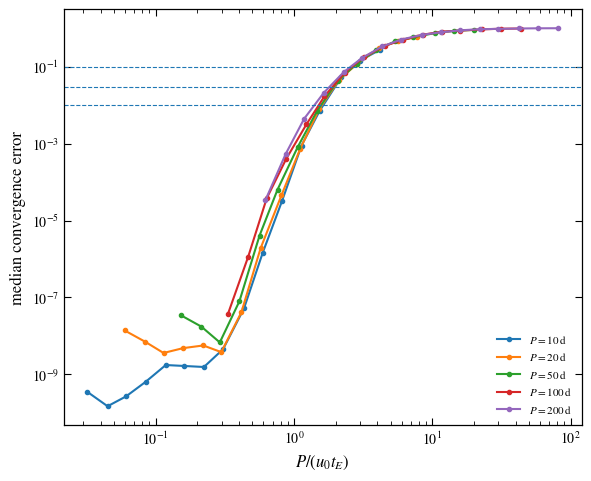

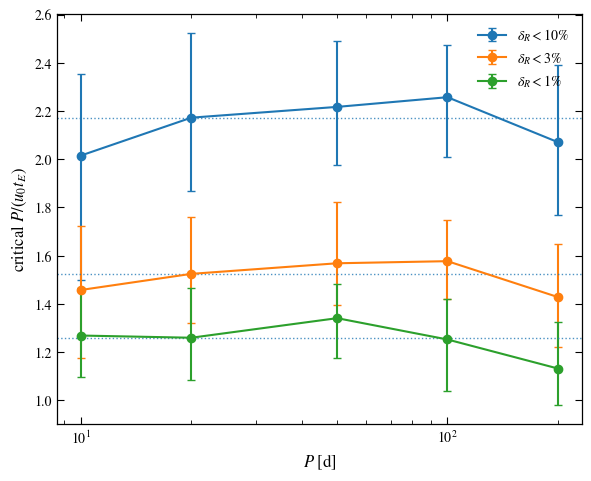

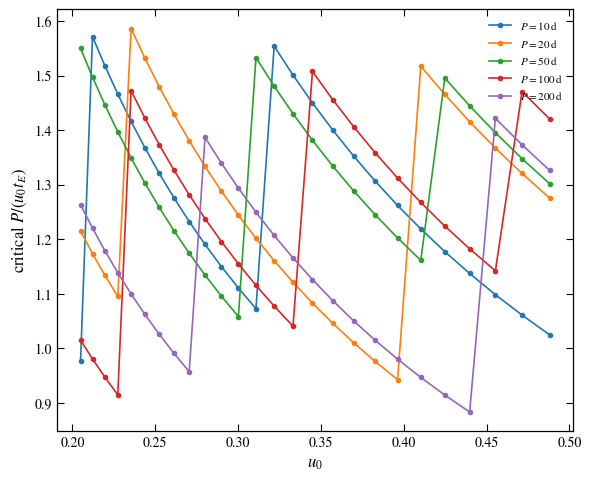

In [12]:
# ============================================================
# SANITY CHECK:
# COMMON u0 RANGE FOR ALL ORBITAL PERIODS
#
# Goal:
#
# Repeat the multi-P fast-orbit analysis using EXACTLY the
# same u0 interval for every orbital period:
#
#       0.2 <= u0 <= 0.5
#
# This avoids comparing different u0 populations for
# different P because of the finite tE_ref = 1000 d.
#
#
# We test whether the critical value
#
#       P / (u0 tE)
#
# remains approximately independent of P.
#
#
# REQUIRED:
#
# Run the previous multi-P experiment first so that
#
#       df_all
#
# already exists.
#
# ============================================================


import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy.stats import spearmanr


# ============================================================
# CONFIGURATION
# ============================================================

COMMON_U0_MIN = 0.20
COMMON_U0_MAX = 0.50


TOLERANCES = [
    0.10,
    0.03,
    0.01,
]


# ============================================================
# CHECK INPUT
# ============================================================

if "df_all" not in globals():

    raise RuntimeError(
        "df_all is not defined.\n"
        "Run the previous multi-P experiment first."
    )


# ============================================================
# COMMON SAMPLE
# ============================================================

df_common = df_all[
    (df_all["u0"] >= COMMON_U0_MIN)
    &
    (df_all["u0"] <= COMMON_U0_MAX)
].copy()


# ------------------------------------------------------------
# We additionally keep only points for which the reference
# model itself satisfies
#
#       P/(u0 tE_ref) <= 1.
#
# For the chosen common u0 interval this should retain nearly
# all points, including P ~ 200 d.
# ------------------------------------------------------------

df_common = df_common[
    df_common["x_reference"] <= 1.0
].copy()


df_common.reset_index(
    drop=True,
    inplace=True,
)


if len(df_common) == 0:

    raise RuntimeError(
        "No points remain after the common-u0 selection."
    )


# ============================================================
# BASIC INFORMATION
# ============================================================

print()

print("=" * 100)

print("COMMON-u0 SANITY CHECK")

print("=" * 100)

print(
    f"Common u0 interval:"
    f" {COMMON_U0_MIN:.3f} <= u0 <= {COMMON_U0_MAX:.3f}"
)

print(
    f"Number of points: {len(df_common)}"
)

print("=" * 100)


# ============================================================
# CHECK ACTUAL REFERENCE RANGE FOR EVERY P
# ============================================================

print()

print("=" * 100)

print("REFERENCE VALIDITY IN COMMON u0 RANGE")

print("=" * 100)


for P in sorted(
    df_common["P_target"].unique()
):

    sub = df_common[
        np.isclose(
            df_common["P_target"],
            P,
        )
    ]


    xmin = sub[
        "x_reference"
    ].min()


    xmax = sub[
        "x_reference"
    ].max()


    print(

        f"P = {P:6.1f} d   "
        f"P/(u0 tE_ref) = "
        f"{xmin:.4f} -- {xmax:.4f}"
    )


print("=" * 100)


# ============================================================
# CORRELATION TEST FOR EACH P
# ============================================================

correlation_rows = []


for P in sorted(
    df_common["P_target"].unique()
):


    sub = df_common[
        np.isclose(
            df_common["P_target"],
            P,
        )
    ].copy()


    valid = (
        np.isfinite(sub["delta_R"])
        &
        np.isfinite(sub["P_over_tE"])
        &
        np.isfinite(sub["P_over_u0tE"])
        &
        (sub["delta_R"] > 0)
    )


    sub = sub[
        valid
    ]


    if len(sub) < 5:

        continue


    log_delta = np.log10(
        sub["delta_R"]
    )


    rho_global, p_global = spearmanr(

        np.log10(
            sub["P_over_tE"]
        ),

        log_delta,
    )


    rho_local, p_local = spearmanr(

        np.log10(
            sub["P_over_u0tE"]
        ),

        log_delta,
    )


    correlation_rows.append(
        {

            "P":
                P,

            "N":
                len(sub),

            "rho_P_tE":
                rho_global,

            "rho_P_u0tE":
                rho_local,

            "p_P_tE":
                p_global,

            "p_P_u0tE":
                p_local,
        }
    )


correlation_table = pd.DataFrame(
    correlation_rows
)


print()

print("=" * 100)

print("CORRELATIONS IN COMMON u0 RANGE")

print("=" * 100)

display(
    correlation_table
)


# ============================================================
# FIND CRITICAL P/(u0 tE)
#
# For each:
#
#       P
#       u0
#       tolerance
#
# find the LARGEST P/(u0 tE) for which
#
#       delta_R <= tolerance.
#
# ============================================================

critical_rows = []


for P in sorted(
    df_common["P_target"].unique()
):


    df_P = df_common[
        np.isclose(
            df_common["P_target"],
            P,
        )
    ].copy()


    u0_values = np.sort(
        df_P["u0"].unique()
    )


    for u0 in u0_values:


        subset = df_P[
            np.isclose(
                df_P["u0"],
                u0,
            )
        ].copy()


        if len(subset) == 0:

            continue


        for tolerance in TOLERANCES:


            converged = subset[
                subset["delta_R"]
                <=
                tolerance
            ]


            if len(converged) == 0:

                continue


            # ------------------------------------------------
            # Largest dimensionless local ratio that already
            # satisfies the required convergence.
            # ------------------------------------------------

            idx = converged[
                "P_over_u0tE"
            ].idxmax()


            row = converged.loc[
                idx
            ]


            critical_rows.append(
                {

                    "P":
                        P,

                    "u0":
                        u0,

                    "tolerance":
                        tolerance,

                    "xcrit":
                        row[
                            "P_over_u0tE"
                        ],

                    "P_over_tE":
                        row[
                            "P_over_tE"
                        ],

                    "tE":
                        row[
                            "tE"
                        ],

                    "delta_R":
                        row[
                            "delta_R"
                        ],
                }
            )


df_critical_common = pd.DataFrame(
    critical_rows
)


# ============================================================
# SUMMARY FOR EACH P
# ============================================================

summary_rows = []


for P in sorted(
    df_critical_common["P"].unique()
):


    for tolerance in TOLERANCES:


        sub = df_critical_common[

            np.isclose(
                df_critical_common["P"],
                P,
            )

            &

            np.isclose(
                df_critical_common["tolerance"],
                tolerance,
            )
        ]


        if len(sub) == 0:

            continue


        xcrit = sub[
            "xcrit"
        ].to_numpy()


        summary_rows.append(
            {

                "P":
                    P,

                "tolerance":
                    tolerance,

                "N":
                    len(xcrit),

                "median_xcrit":
                    np.median(
                        xcrit
                    ),

                "q16":
                    np.percentile(
                        xcrit,
                        16,
                    ),

                "q84":
                    np.percentile(
                        xcrit,
                        84,
                    ),

                "mean_xcrit":
                    np.mean(
                        xcrit
                    ),

                "std_xcrit":
                    np.std(
                        xcrit
                    ),
            }
        )


critical_summary_common = pd.DataFrame(
    summary_rows
)


print()

print("=" * 100)

print(
    "CRITICAL P/(u0 tE) -- COMMON u0 RANGE"
)

print("=" * 100)

display(
    critical_summary_common
)


# ============================================================
# TEST INDEPENDENCE FROM P
#
# For every tolerance:
#
# 1) calculate median xcrit over P
# 2) fractional spread
# 3) Spearman correlation with P
# 4) fit:
#
#       log10(xcrit) = a + b log10(P)
#
# If xcrit is independent of P:
#
#       b ~ 0.
#
# ============================================================

universality_rows = []


for tolerance in TOLERANCES:


    sub = critical_summary_common[

        np.isclose(
            critical_summary_common["tolerance"],
            tolerance,
        )

    ].sort_values(
        "P"
    )


    if len(sub) < 3:

        continue


    P = sub[
        "P"
    ].to_numpy()


    xcrit = sub[
        "median_xcrit"
    ].to_numpy()


    # --------------------------------------------------------
    # Global characteristic value
    # --------------------------------------------------------

    xcrit_global = np.median(
        xcrit
    )


    # --------------------------------------------------------
    # Fractional variation across periods
    # --------------------------------------------------------

    fractional_range = (

        np.max(
            xcrit
        )

        -

        np.min(
            xcrit
        )

    ) / xcrit_global


    fractional_std = (

        np.std(
            xcrit
        )

        /

        np.mean(
            xcrit
        )
    )


    # --------------------------------------------------------
    # Spearman P vs xcrit
    # --------------------------------------------------------

    rho, pvalue = spearmanr(

        np.log10(
            P
        ),

        xcrit,
    )


    # --------------------------------------------------------
    # Power-law test:
    #
    # xcrit ~ P^slope
    # --------------------------------------------------------

    slope, intercept = np.polyfit(

        np.log10(
            P
        ),

        np.log10(
            xcrit
        ),

        1,
    )


    universality_rows.append(
        {

            "tolerance":
                tolerance,

            "median_xcrit_all_P":
                xcrit_global,

            "fractional_range":
                fractional_range,

            "fractional_std":
                fractional_std,

            "Spearman_rho":
                rho,

            "Spearman_p":
                pvalue,

            "powerlaw_slope":
                slope,
        }
    )


universality_table = pd.DataFrame(
    universality_rows
)


print()

print("=" * 100)

print("INDEPENDENCE OF CRITICAL RATIO FROM P")

print("=" * 100)

display(
    universality_table
)


# ============================================================
# PRINT PHYSICALLY USEFUL SUMMARY
# ============================================================

print()

print("=" * 100)

print("SUMMARY")

print("=" * 100)


for _, row in universality_table.iterrows():


    tolerance = row[
        "tolerance"
    ]


    print()

    print(
        f"delta_R < {100*tolerance:.0f}%"
    )


    print(

        f"    characteristic P/(u0 tE) = "
        f"{row['median_xcrit_all_P']:.3f}"
    )


    print(

        f"    fractional std across P  = "
        f"{100*row['fractional_std']:.2f}%"
    )


    print(

        f"    max-min / median          = "
        f"{100*row['fractional_range']:.2f}%"
    )


    print(

        f"    power-law slope vs P      = "
        f"{row['powerlaw_slope']:.4f}"
    )


print()

print("=" * 100)


# ============================================================
# ============================================================
#
# FIGURE 1
#
# MEDIAN CONVERGENCE CURVES
#
# Same common u0 interval for every P.
#
# ============================================================
# ============================================================

def binned_median(
    x,
    y,
    n_bins=16,
):


    x = np.asarray(
        x,
        dtype=float,
    )


    y = np.asarray(
        y,
        dtype=float,
    )


    valid = (
        np.isfinite(x)
        &
        np.isfinite(y)
        &
        (x > 0)
        &
        (y > 0)
    )


    x = x[
        valid
    ]

    y = y[
        valid
    ]


    if len(x) < 5:

        return (
            np.array([]),
            np.array([]),
        )


    logx = np.log10(
        x
    )


    edges = np.linspace(

        logx.min(),

        logx.max(),

        n_bins + 1,
    )


    x_out = []

    y_out = []


    for i in range(
        n_bins
    ):


        select = (

            (logx >= edges[i])

            &

            (logx < edges[i + 1])
        )


        if i == n_bins - 1:

            select = (

                (logx >= edges[i])

                &

                (logx <= edges[i + 1])
            )


        if np.count_nonzero(
            select
        ) < 3:

            continue


        x_out.append(

            10**
            np.mean(
                np.log10(
                    x[
                        select
                    ]
                )
            )
        )


        y_out.append(

            np.median(
                y[
                    select
                ]
            )
        )


    return (

        np.asarray(
            x_out
        ),

        np.asarray(
            y_out
        ),
    )


fig1, ax1 = plt.subplots(

    figsize=(
        5.8,
        4.7,
    ),

    constrained_layout=True,
)


for P in sorted(
    df_common["P_target"].unique()
):


    sub = df_common[

        np.isclose(
            df_common["P_target"],
            P,
        )

    ].copy()


    x, y = binned_median(

        sub[
            "P_over_u0tE"
        ],

        np.maximum(
            sub[
                "delta_R"
            ],
            1e-10,
        ),

        n_bins=16,
    )


    ax1.plot(

        x,

        y,

        marker="o",

        markersize=3,

        lw=1.5,

        label=(
            rf"$P={P:g}\,\mathrm{{d}}$"
        ),
    )


# ============================================================
# CONVERGENCE LEVELS
# ============================================================

for tolerance in TOLERANCES:


    ax1.axhline(

        tolerance,

        ls="--",

        lw=0.8,
    )


ax1.set_xscale(
    "log"
)


ax1.set_yscale(
    "log"
)


ax1.set_xlabel(
    r"$P/(u_0t_E)$"
)


ax1.set_ylabel(
    r"median convergence error"
)


ax1.legend(

    frameon=False,

    fontsize=8,
)


ax1.grid(
    False
)


# ============================================================
# ============================================================
#
# FIGURE 2
#
# MAIN SANITY CHECK
#
# CRITICAL P/(u0 tE) VS P
#
# Same u0 interval for every period.
#
# ============================================================
# ============================================================

fig2, ax2 = plt.subplots(

    figsize=(
        5.8,
        4.7,
    ),

    constrained_layout=True,
)


for tolerance in TOLERANCES:


    sub = critical_summary_common[

        np.isclose(
            critical_summary_common[
                "tolerance"
            ],
            tolerance,
        )

    ].sort_values(
        "P"
    )


    if len(sub) == 0:

        continue


    P = sub[
        "P"
    ].to_numpy()


    median = sub[
        "median_xcrit"
    ].to_numpy()


    q16 = sub[
        "q16"
    ].to_numpy()


    q84 = sub[
        "q84"
    ].to_numpy()


    lower = (
        median
        -
        q16
    )


    upper = (
        q84
        -
        median
    )


    ax2.errorbar(

        P,

        median,

        yerr=np.vstack(
            (
                lower,
                upper,
            )
        ),

        marker="o",

        capsize=3,

        lw=1.5,

        label=(
            rf"$\delta_R<{100*tolerance:.0f}\%$"
        ),
    )


    # --------------------------------------------------------
    # Overall median across P
    # --------------------------------------------------------

    global_median = np.median(
        median
    )


    ax2.axhline(

        global_median,

        ls=":",

        lw=1.0,

        alpha=0.8,
    )


ax2.set_xscale(
    "log"
)


ax2.set_xlabel(
    r"$P\;[\mathrm{d}]$"
)


ax2.set_ylabel(
    r"critical $P/(u_0t_E)$"
)


ax2.legend(
    frameon=False
)


ax2.grid(
    False
)


# ============================================================
# ============================================================
#
# FIGURE 3
#
# CRITICAL LOCAL RATIO AS FUNCTION OF u0
#
# Separate curves for each P at 1% tolerance.
#
# This checks whether residual dependence on u0 remains
# after the common-range restriction.
#
# ============================================================
# ============================================================

fig3, ax3 = plt.subplots(

    figsize=(
        5.8,
        4.7,
    ),

    constrained_layout=True,
)


TOLERANCE_TO_SHOW = 0.01


for P in sorted(
    df_critical_common["P"].unique()
):


    sub = df_critical_common[

        np.isclose(
            df_critical_common["P"],
            P,
        )

        &

        np.isclose(
            df_critical_common["tolerance"],
            TOLERANCE_TO_SHOW,
        )

    ].sort_values(
        "u0"
    )


    if len(sub) == 0:

        continue


    ax3.plot(

        sub[
            "u0"
        ],

        sub[
            "xcrit"
        ],

        marker="o",

        markersize=3,

        lw=1.2,

        label=(
            rf"$P={P:g}\,\mathrm{{d}}$"
        ),
    )


ax3.set_xlabel(
    r"$u_0$"
)


ax3.set_ylabel(
    r"critical $P/(u_0t_E)$"
)


ax3.legend(

    frameon=False,

    fontsize=8,
)


ax3.grid(
    False
)


# ============================================================
# FINAL TABLES
# ============================================================

print()

print(
    "Critical points:"
)

display(
    df_critical_common
)


plt.show()


Loading D map for tE = 150 d
Directory: /home/anibal-pc/binary_source/results/scan_u0_tE150
Files found: 100

u0 range: 1.000e-02 -- 1.000e+01
P/tE range: 6.667e-02 -- 6.667e+02
D range: 1.567e-05 -- 2.507e-01
Successful fits: 100.00%

Saved:
/home/anibal-pc/binary_source/results/scan_u0_tE150/paper_D_heatmap_tE150.png
/home/anibal-pc/binary_source/results/scan_u0_tE150/paper_D_heatmap_tE150.pdf


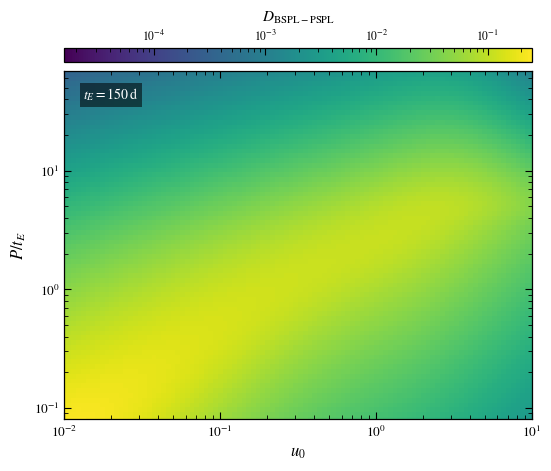

In [33]:
# ============================================================
# PAPER FIGURE
#
# D metric heatmap for a single tE
#
#       D = ||A_BSPL - A_PSPL,best||_2
#           -------------------------
#                ||A_BSPL - 1||_2
#
# x-axis : u0
# y-axis : P/tE
# color  : D
#
# No interpolation across failed fits.
# No contour levels.
# ============================================================

import glob
import os
import re

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


# ============================================================
# PAPER STYLE
# ============================================================

plt.rcParams.update({

    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",

    "font.size": 10,

    "axes.labelsize": 12,

    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,

    "axes.linewidth": 0.9,

    "xtick.direction": "in",
    "ytick.direction": "in",

    "xtick.top": True,
    "ytick.right": True,

    "xtick.major.size": 5,
    "ytick.major.size": 5,

    "xtick.minor.size": 3,
    "ytick.minor.size": 3,

    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,

    "savefig.dpi": 300,
})


# ============================================================
# CONFIGURATION
# ============================================================

home_path = os.path.expanduser("~")


base_directory = os.path.join(
    home_path,
    "binary_source",
    "results",
)


# ============================================================
# FIXED EINSTEIN TIMESCALE
# ============================================================

tE_true = 150.0


# ============================================================
# METRIC
# ============================================================

metric_key = "D"


# ============================================================
# AXIS RANGE
# ============================================================

XMIN = 1e-2
XMAX = 1e1

YMIN = 8e-2
YMAX = 7e1


# ============================================================
# FIGURE SIZE
# ============================================================

FIGSIZE = (5.4, 4.6)


# ============================================================
# OPTIONAL FIXED COLOR SCALE
#
# If None, the limits are obtained automatically from the data.
#
# For comparisons between several figures it is better to set
# fixed values here.
# ============================================================

D_VMIN = None
D_VMAX = None

# Example:
#
# D_VMIN = 1e-4
# D_VMAX = 1.0


# ============================================================
# AUXILIARY FUNCTIONS
# ============================================================

def format_tE_label(tE):
    """
    Examples:

        150.0 -> 150
        37.5  -> 37p5
    """

    label = f"{float(tE):g}"

    return label.replace(
        ".",
        "p",
    )


def extract_u0_index(filename):
    """
    Extract index from:

        scan_kepler_u0_003.npz
    """

    base = os.path.basename(
        filename
    )

    match = re.fullmatch(
        r"scan_kepler_u0_(\d+)\.npz",
        base,
    )

    if match is None:

        raise ValueError(
            f"No pude extraer el índice desde {base}"
        )

    return int(
        match.group(1)
    )


def log_bin_edges(x):
    """
    Construct bin edges for a logarithmically sampled grid.
    """

    x = np.asarray(
        x,
        dtype=float,
    )

    if len(x) < 2:

        raise ValueError(
            "Se necesitan al menos dos puntos."
        )

    if np.any(
        x <= 0
    ):

        raise ValueError(
            "Todos los valores deben ser positivos."
        )

    logx = np.log10(
        x
    )

    edges = np.empty(
        len(x) + 1,
        dtype=float,
    )

    edges[1:-1] = (
        0.5
        * (
            logx[:-1]
            + logx[1:]
        )
    )

    edges[0] = (
        logx[0]
        - 0.5
        * (
            logx[1]
            - logx[0]
        )
    )

    edges[-1] = (
        logx[-1]
        + 0.5
        * (
            logx[-1]
            - logx[-2]
        )
    )

    return 10**edges


# ============================================================
# DIRECTORY FOR THIS tE
# ============================================================

tE_label = format_tE_label(
    tE_true
)


directory = os.path.join(
    base_directory,
    f"scan_u0_tE{tE_label}",
)


pattern = os.path.join(
    directory,
    "scan_kepler_u0_*.npz",
)


files = sorted(
    glob.glob(pattern)
)


print()

print("=" * 80)

print(
    f"Loading D map for tE = {tE_true:g} d"
)

print(
    f"Directory: {directory}"
)

print(
    f"Files found: {len(files)}"
)

print("=" * 80)


if len(files) == 0:

    raise FileNotFoundError(
        f"No files found:\n{pattern}"
    )


# ============================================================
# FIRST PASS:
#
# obtain u0 values and common P grid
# ============================================================

records = []

P_grid_reference = None

total_bins = 0
successful_bins = 0


for filename in files:


    with np.load(
        filename,
        allow_pickle=False,
    ) as d:


        # ----------------------------------------------------
        # Check that D exists
        # ----------------------------------------------------

        if metric_key not in d.files:

            raise KeyError(
                f"\nThe file\n"
                f"{filename}\n"
                f"does not contain the metric '{metric_key}'.\n"
                f"Available keys:\n"
                f"{d.files}"
            )


        truth = d[
            "truth"
        ].astype(float)


        u0_true = float(
            truth[1]
        )


        P_grid = d[
            "P_grid"
        ].astype(float)


        SUCCESS = d[
            "SUCCESS"
        ].astype(bool)


    # --------------------------------------------------------
    # Common P grid
    # --------------------------------------------------------

    if P_grid_reference is None:

        P_grid_reference = (
            P_grid.copy()
        )

    else:

        if (
            len(P_grid)
            != len(P_grid_reference)
            or not np.allclose(
                P_grid,
                P_grid_reference,
            )
        ):

            raise ValueError(
                f"P_grid inconsistent in:\n"
                f"{filename}"
            )


    total_bins += len(
        SUCCESS
    )


    successful_bins += np.count_nonzero(
        SUCCESS
    )


    records.append(
        {
            "filename":
                filename,

            "index":
                extract_u0_index(
                    filename
                ),

            "u0":
                u0_true,
        }
    )


# ============================================================
# SORT BY PHYSICAL u0
# ============================================================

records = sorted(
    records,
    key=lambda x:
        x["u0"],
)


u0_grid = np.array(
    [
        rec["u0"]
        for rec in records
    ],
    dtype=float,
)


Nu0 = len(
    u0_grid
)


NP = len(
    P_grid_reference
)


# ============================================================
# LOAD D MAP
#
# Shape:
#
#       (Nu0, NP)
# ============================================================

D_map = np.full(
    (Nu0, NP),
    np.nan,
    dtype=float,
)


for i, rec in enumerate(
    records
):


    with np.load(
        rec["filename"],
        allow_pickle=False,
    ) as d:


        D = d[
            "D"
        ].astype(float)


        SUCCESS = d[
            "SUCCESS"
        ].astype(bool)


    valid = (
        SUCCESS
        & np.isfinite(
            D
        )
        & (
            D > 0
        )
    )


    D_map[
        i,
        valid,
    ] = D[
        valid
    ]


# ============================================================
# P / tE
# ============================================================

P_over_tE = (
    P_grid_reference
    / float(tE_true)
)


# ============================================================
# INFORMATION
# ============================================================

valid_D = (
    np.isfinite(
        D_map
    )
    & (
        D_map > 0
    )
)


if not np.any(
    valid_D
):

    raise RuntimeError(
        "No valid D values were found."
    )


print()

print(
    f"u0 range: "
    f"{u0_grid.min():.3e} -- "
    f"{u0_grid.max():.3e}"
)


print(
    f"P/tE range: "
    f"{P_over_tE.min():.3e} -- "
    f"{P_over_tE.max():.3e}"
)


print(
    f"D range: "
    f"{np.nanmin(D_map):.3e} -- "
    f"{np.nanmax(D_map):.3e}"
)


print(
    f"Successful fits: "
    f"{100*successful_bins/total_bins:.2f}%"
)


# ============================================================
# LOGARITHMIC BIN EDGES
# ============================================================

u0_edges = log_bin_edges(
    u0_grid
)


P_edges = log_bin_edges(
    P_over_tE
)


# ============================================================
# COLOR NORMALIZATION
# ============================================================

if D_VMIN is None:

    vmin = np.nanmin(
        D_map[
            valid_D
        ]
    )

else:

    vmin = float(
        D_VMIN
    )


if D_VMAX is None:

    vmax = np.nanmax(
        D_map[
            valid_D
        ]
    )

else:

    vmax = float(
        D_VMAX
    )


if (
    vmin <= 0
    or vmax <= vmin
):

    raise ValueError(
        f"Invalid color limits: "
        f"vmin={vmin}, vmax={vmax}"
    )


norm_D = mcolors.LogNorm(
    vmin=vmin,
    vmax=vmax,
)


# ============================================================
# CREATE FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=FIGSIZE,
    constrained_layout=True,
)


# ============================================================
# D HEATMAP
# ============================================================

pcm = ax.pcolormesh(

    u0_edges,

    P_edges,

    np.ma.masked_invalid(
        D_map
    ).T,

    cmap="viridis",

    norm=norm_D,

    shading="auto",

    edgecolors="none",

    linewidth=0,

    rasterized=True,
)


# ============================================================
# AXES
# ============================================================

ax.set_xscale(
    "log"
)


ax.set_yscale(
    "log"
)


ax.set_xlim(
    XMIN,
    XMAX,
)


ax.set_ylim(
    YMIN,
    YMAX,
)


ax.set_xlabel(
    r"$u_0$"
)


ax.set_ylabel(
    r"$P/t_E$"
)


ax.tick_params(

    axis="both",

    which="both",

    direction="in",

    top=True,

    right=True,
)


ax.grid(
    False
)


# ============================================================
# tE ANNOTATION
# ============================================================

ax.text(

    0.04,
    0.955,

    rf"$t_E={tE_true:.0f}\,\mathrm{{d}}$",

    transform=ax.transAxes,

    ha="left",

    va="top",

    fontsize=10,

    color="white",

    bbox=dict(

        facecolor="black",

        edgecolor="none",

        alpha=0.55,

        pad=2.5,
    ),
)


# ============================================================
# TOP COLORBAR
# ============================================================

cbar = fig.colorbar(

    pcm,

    ax=ax,

    orientation="horizontal",

    location="top",

    pad=0.025,

    fraction=0.055,

    aspect=35,
)


cbar.set_label(

    r"$D_{\rm BSPL-PSPL}$",

    fontsize=11,

    labelpad=5,
)


cbar.ax.tick_params(

    axis="x",

    which="both",

    direction="in",

    labelsize=8.5,
)


cbar.ax.xaxis.set_ticks_position(
    "top"
)


cbar.ax.xaxis.set_label_position(
    "top"
)


# ============================================================
# OUTPUT
# ============================================================

output_png = os.path.join(
    directory,
    f"paper_D_heatmap_tE{int(tE_true)}.png",
)


output_pdf = os.path.join(
    directory,
    f"paper_D_heatmap_tE{int(tE_true)}.pdf",
)


fig.savefig(

    output_png,

    dpi=300,

    bbox_inches="tight",
)


fig.savefig(

    output_pdf,

    bbox_inches="tight",
)


print()

print("=" * 80)

print("Saved:")

print(
    output_png
)

print(
    output_pdf
)

print("=" * 80)


plt.show()


Loading D map for tE = 150 d
Directory: /home/anibal-pc/binary_source/results/scan_u0_tE150
Files found: 100

u0 range       : 1.0000e-02 -- 1.0000e+01
P/tE range     : 6.6667e-02 -- 6.6667e+02
xi_rel range   : 2.6203e-02 -- 1.2162e+01
D range        : 1.5665e-05 -- 2.5066e-01
Successful fits: 100.00%

MAXIMUM-D LOCUS
N fit points = 72

(P/tE)_D,max = C u0^alpha
C     = 2.6131
alpha = 0.7879 +/- 0.0105
R^2   = 0.98783

Prediction for constant xi_rel/u0:
alpha_theory = 1.5

alpha - 1.5 = -0.7121

xi_rel/u0 evaluated at maximum D:
median = 0.66216
16--84 percentile = 0.25862 -- 1.2706

Saved:
/home/anibal-pc/binary_source/results/scan_u0_tE150/paper_D_heatmap_xirel_u0_tE150.png
/home/anibal-pc/binary_source/results/scan_u0_tE150/paper_D_heatmap_xirel_u0_tE150.pdf

/home/anibal-pc/binary_source/results/scan_u0_tE150/paper_D_peak_vs_u0_tE150.png
/home/anibal-pc/binary_source/results/scan_u0_tE150/paper_D_peak_vs_u0_tE150.pdf

/home/anibal-pc/binary_source/results/scan_u0_tE150/D_peak_locu

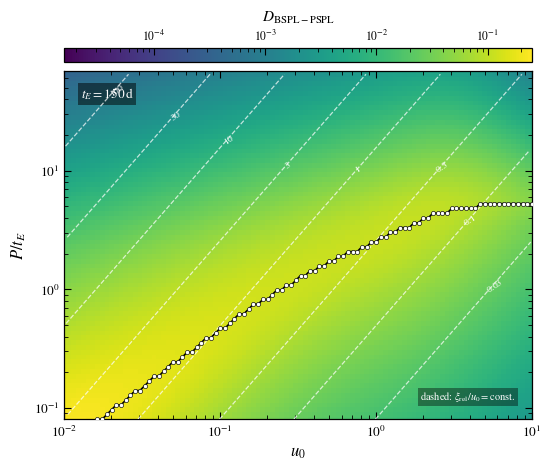

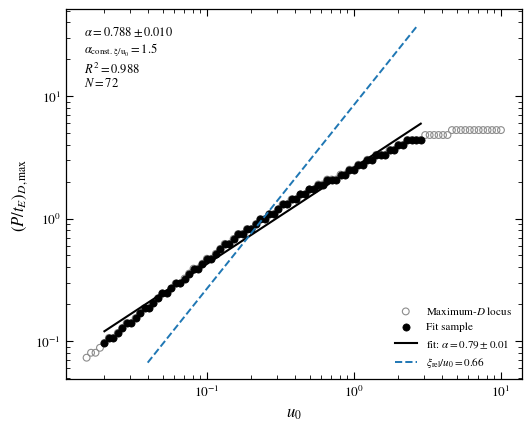

In [34]:
# ============================================================
# D METRIC ANALYSIS FOR ONE tE
#
# FIGURE 1
# --------
# Heatmap:
#
#       D = ||A_BSPL - A_PSPL,best||_2
#           -------------------------
#                ||A_BSPL - 1||_2
#
# in the (u0, P/tE) plane.
#
# Overlaid:
#   - curves of constant xi_rel/u0
#   - locus of maximum D for each u0
#
#
# FIGURE 2
# --------
#
#       (P/tE)_{D,max} vs u0
#
# with a power-law fit:
#
#       (P/tE)_{D,max} = C u0^alpha
#
# and comparison with the prediction
#
#       alpha = 3/2
#
# expected if the maximum approximately follows
#
#       xi_rel/u0 = constant
#
#
# IMPORTANT
# ---------
# The legacy NPZ key
#
#       xiE_of_P
#
# is interpreted here as
#
#       xi_rel = a_rel / rEhat
#
# ============================================================

import glob
import os
import re

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


# ============================================================
# PAPER STYLE
# ============================================================

plt.rcParams.update({

    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",

    "font.size": 10,

    "axes.labelsize": 12,
    "axes.titlesize": 10,

    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,

    "axes.linewidth": 0.9,

    "xtick.direction": "in",
    "ytick.direction": "in",

    "xtick.top": True,
    "ytick.right": True,

    "xtick.major.size": 5,
    "ytick.major.size": 5,

    "xtick.minor.size": 3,
    "ytick.minor.size": 3,

    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,

    "savefig.dpi": 300,
})


# ============================================================
# CONFIGURATION
# ============================================================

home_path = os.path.expanduser("~")

base_directory = os.path.join(
    home_path,
    "binary_source",
    "results",
)


# ============================================================
# FIXED tE
# ============================================================

tE_true = 150.0


# ============================================================
# AXIS LIMITS
# ============================================================

XMIN = 1e-2
XMAX = 1e1

YMIN = 8e-2
YMAX = 7e1


# ============================================================
# FIGURE SIZE
# ============================================================

FIGSIZE = (5.4, 4.6)


# ============================================================
# D COLOR RANGE
#
# None -> automatic from data.
# ============================================================

D_VMIN = None
D_VMAX = None


# ============================================================
# CONSTANT xi_rel/u0 CURVES TO SHOW
#
# Adjust these after seeing the result if desired.
# ============================================================

XI_OVER_U0_LEVELS = np.array([
    0.03,
    0.1,
    0.3,
    1.0,
    3.0,
    10.0,
    30.0,
    100.0,
])


# ============================================================
# MAXIMUM-D LOCUS
# ============================================================

SHOW_MAX_D_LOCUS = True


# ============================================================
# POWER-LAW FIT RANGE
#
# Boundary maxima are automatically excluded.
#
# These limits can also be used to avoid regions where the
# maximum is poorly constrained by the finite grid.
# ============================================================

FIT_U0_MIN = 2e-2
FIT_U0_MAX = 3.0


# ============================================================
# AUXILIARY FUNCTIONS
# ============================================================

def format_tE_label(tE):

    label = f"{float(tE):g}"

    return label.replace(
        ".",
        "p",
    )


def extract_u0_index(filename):

    base = os.path.basename(
        filename
    )

    match = re.fullmatch(
        r"scan_kepler_u0_(\d+)\.npz",
        base,
    )

    if match is None:

        raise ValueError(
            f"No pude extraer el índice desde {base}"
        )

    return int(
        match.group(1)
    )


def log_bin_edges(x):

    x = np.asarray(
        x,
        dtype=float,
    )

    if len(x) < 2:

        raise ValueError(
            "Se necesitan al menos dos puntos."
        )

    if np.any(
        x <= 0
    ):

        raise ValueError(
            "Todos los valores deben ser positivos."
        )

    logx = np.log10(
        x
    )

    edges = np.empty(
        len(x) + 1,
        dtype=float,
    )

    edges[1:-1] = (
        0.5
        * (
            logx[:-1]
            + logx[1:]
        )
    )

    edges[0] = (
        logx[0]
        - 0.5
        * (
            logx[1]
            - logx[0]
        )
    )

    edges[-1] = (
        logx[-1]
        + 0.5
        * (
            logx[-1]
            - logx[-2]
        )
    )

    return 10**edges


# ============================================================
# DIRECTORY
# ============================================================

tE_label = format_tE_label(
    tE_true
)

directory = os.path.join(
    base_directory,
    f"scan_u0_tE{tE_label}",
)

pattern = os.path.join(
    directory,
    "scan_kepler_u0_*.npz",
)

files = sorted(
    glob.glob(pattern)
)


print()
print("=" * 80)
print(
    f"Loading D map for tE = {tE_true:g} d"
)
print(
    f"Directory: {directory}"
)
print(
    f"Files found: {len(files)}"
)
print("=" * 80)


if len(files) == 0:

    raise FileNotFoundError(
        pattern
    )


# ============================================================
# FIRST PASS
#
# Obtain:
#
#   u0
#   P_grid
#   xi_rel(P)
# ============================================================

records = []

P_grid_reference = None
xi_rel_reference = None

total_bins = 0
successful_bins = 0


for filename in files:


    with np.load(
        filename,
        allow_pickle=False,
    ) as d:


        if "D" not in d.files:

            raise KeyError(
                f"\n{filename}\n"
                f"does not contain D."
            )


        if "xiE_of_P" not in d.files:

            raise KeyError(
                f"\n{filename}\n"
                f"does not contain xiE_of_P."
            )


        truth = d[
            "truth"
        ].astype(float)


        u0_true = float(
            truth[1]
        )


        P_grid = d[
            "P_grid"
        ].astype(float)


        # ----------------------------------------------------
        # Legacy name:
        #
        # xiE_of_P -> xi_rel(P)
        # ----------------------------------------------------

        xi_rel = d[
            "xiE_of_P"
        ].astype(float)


        SUCCESS = d[
            "SUCCESS"
        ].astype(bool)


    # ========================================================
    # COMMON P GRID
    # ========================================================

    if P_grid_reference is None:

        P_grid_reference = (
            P_grid.copy()
        )

    else:

        if not np.allclose(
            P_grid,
            P_grid_reference,
        ):

            raise ValueError(
                f"P_grid inconsistent in\n{filename}"
            )


    # ========================================================
    # COMMON xi_rel GRID
    # ========================================================

    if xi_rel_reference is None:

        xi_rel_reference = (
            xi_rel.copy()
        )

    else:

        if not np.allclose(
            xi_rel,
            xi_rel_reference,
        ):

            raise ValueError(
                f"xi_rel grid inconsistent in\n{filename}"
            )


    total_bins += len(
        SUCCESS
    )

    successful_bins += np.count_nonzero(
        SUCCESS
    )


    records.append(
        {
            "filename":
                filename,

            "index":
                extract_u0_index(
                    filename
                ),

            "u0":
                u0_true,
        }
    )


# ============================================================
# SORT BY PHYSICAL u0
# ============================================================

records = sorted(
    records,
    key=lambda x:
        x["u0"],
)


u0_grid = np.array(
    [
        rec["u0"]
        for rec in records
    ],
    dtype=float,
)


Nu0 = len(
    u0_grid
)

NP = len(
    P_grid_reference
)


# ============================================================
# LOAD D MAP
# ============================================================

D_map = np.full(
    (Nu0, NP),
    np.nan,
    dtype=float,
)


for i, rec in enumerate(
    records
):


    with np.load(
        rec["filename"],
        allow_pickle=False,
    ) as d:


        D = d[
            "D"
        ].astype(float)


        SUCCESS = d[
            "SUCCESS"
        ].astype(bool)


    valid = (
        SUCCESS
        & np.isfinite(D)
        & (D > 0)
    )


    D_map[
        i,
        valid,
    ] = D[
        valid
    ]


# ============================================================
# P/tE
# ============================================================

P_over_tE = (
    P_grid_reference
    / float(tE_true)
)


# ============================================================
# BASIC INFORMATION
# ============================================================

valid_D = (
    np.isfinite(
        D_map
    )
    & (
        D_map > 0
    )
)


if not np.any(
    valid_D
):

    raise RuntimeError(
        "No valid D values."
    )


print()

print(
    f"u0 range       : "
    f"{u0_grid.min():.4e} -- "
    f"{u0_grid.max():.4e}"
)

print(
    f"P/tE range     : "
    f"{P_over_tE.min():.4e} -- "
    f"{P_over_tE.max():.4e}"
)

print(
    f"xi_rel range   : "
    f"{xi_rel_reference.min():.4e} -- "
    f"{xi_rel_reference.max():.4e}"
)

print(
    f"D range        : "
    f"{np.nanmin(D_map):.4e} -- "
    f"{np.nanmax(D_map):.4e}"
)

print(
    f"Successful fits: "
    f"{100*successful_bins/total_bins:.2f}%"
)


# ============================================================
# FIND MAXIMUM D FOR EACH u0
#
# Store:
#
#   P/tE_peak
#   D_peak
#   xi_rel_peak
#   xi_rel_peak/u0
#
# ============================================================

PoverTE_peak = np.full(
    Nu0,
    np.nan,
)

D_peak = np.full(
    Nu0,
    np.nan,
)

xi_rel_peak = np.full(
    Nu0,
    np.nan,
)

xi_over_u0_peak = np.full(
    Nu0,
    np.nan,
)

peak_index = np.full(
    Nu0,
    -1,
    dtype=int,
)

peak_on_boundary = np.zeros(
    Nu0,
    dtype=bool,
)


for i in range(
    Nu0
):


    row = D_map[
        i,
        :
    ]


    valid = (
        np.isfinite(row)
        & (row > 0)
    )


    if not np.any(
        valid
    ):

        continue


    valid_indices = np.where(
        valid
    )[0]


    j_local = np.argmax(
        row[
            valid
        ]
    )


    j = int(
        valid_indices[
            j_local
        ]
    )


    peak_index[i] = j


    PoverTE_peak[i] = (
        P_over_tE[j]
    )


    D_peak[i] = (
        row[j]
    )


    xi_rel_peak[i] = (
        xi_rel_reference[j]
    )


    xi_over_u0_peak[i] = (
        xi_rel_reference[j]
        / u0_grid[i]
    )


    # --------------------------------------------------------
    # Exclude peaks touching the first/last period bin
    # because their true maximum may lie outside the scan.
    # --------------------------------------------------------

    if (
        j == 0
        or j == NP - 1
    ):

        peak_on_boundary[i] = True


# ============================================================
# FIT MASK
# ============================================================

fit_mask = (
    np.isfinite(
        PoverTE_peak
    )
    & np.isfinite(
        u0_grid
    )
    & (u0_grid > 0)
    & (PoverTE_peak > 0)
    & (~peak_on_boundary)
    & (u0_grid >= FIT_U0_MIN)
    & (u0_grid <= FIT_U0_MAX)
)


if np.count_nonzero(
    fit_mask
) < 3:

    raise RuntimeError(
        "Not enough valid peak points for power-law fit."
    )


# ============================================================
# POWER-LAW FIT
#
# log10(P/tE)_peak =
#
#       log10(C) + alpha log10(u0)
# ============================================================

xfit = np.log10(
    u0_grid[
        fit_mask
    ]
)

yfit = np.log10(
    PoverTE_peak[
        fit_mask
    ]
)


coeff, covariance = np.polyfit(
    xfit,
    yfit,
    deg=1,
    cov=True,
)


alpha = coeff[0]
logC = coeff[1]

alpha_err = np.sqrt(
    covariance[0, 0]
)

logC_err = np.sqrt(
    covariance[1, 1]
)


C = 10**logC


# ============================================================
# R^2
# ============================================================

y_model = (
    alpha * xfit
    + logC
)


SS_res = np.sum(
    (
        yfit
        - y_model
    )**2
)


SS_tot = np.sum(
    (
        yfit
        - np.mean(yfit)
    )**2
)


R2 = (
    1.0
    - SS_res / SS_tot
)


# ============================================================
# xi_rel/u0 AT THE D MAXIMUM
# ============================================================

ratio_peak_fit = xi_over_u0_peak[
    fit_mask
]


median_ratio = np.nanmedian(
    ratio_peak_fit
)


q16_ratio = np.nanpercentile(
    ratio_peak_fit,
    16,
)


q84_ratio = np.nanpercentile(
    ratio_peak_fit,
    84,
)


print()

print("=" * 80)
print("MAXIMUM-D LOCUS")
print("=" * 80)

print(
    f"N fit points = "
    f"{np.count_nonzero(fit_mask)}"
)

print()

print(
    "(P/tE)_D,max = C u0^alpha"
)

print(
    f"C     = {C:.5g}"
)

print(
    f"alpha = "
    f"{alpha:.4f} +/- {alpha_err:.4f}"
)

print(
    f"R^2   = {R2:.5f}"
)

print()

print(
    "Prediction for constant xi_rel/u0:"
)

print(
    "alpha_theory = 1.5"
)

print()

print(
    f"alpha - 1.5 = "
    f"{alpha - 1.5:+.4f}"
)

print()

print(
    "xi_rel/u0 evaluated at maximum D:"
)

print(
    f"median = {median_ratio:.5g}"
)

print(
    f"16--84 percentile = "
    f"{q16_ratio:.5g} -- {q84_ratio:.5g}"
)

print("=" * 80)


# ============================================================
#
# FIGURE 1
#
# D HEATMAP + CONSTANT xi_rel/u0 CURVES
# + MAXIMUM-D LOCUS
#
# ============================================================

u0_edges = log_bin_edges(
    u0_grid
)

P_edges = log_bin_edges(
    P_over_tE
)


# ============================================================
# COLOR NORMALIZATION
# ============================================================

if D_VMIN is None:

    vmin = np.nanmin(
        D_map[
            valid_D
        ]
    )

else:

    vmin = float(
        D_VMIN
    )


if D_VMAX is None:

    vmax = np.nanmax(
        D_map[
            valid_D
        ]
    )

else:

    vmax = float(
        D_VMAX
    )


norm_D = mcolors.LogNorm(
    vmin=vmin,
    vmax=vmax,
)


# ============================================================
# CREATE FIGURE
# ============================================================

fig1, ax1 = plt.subplots(

    figsize=FIGSIZE,

    constrained_layout=True,
)


# ============================================================
# HEATMAP
# ============================================================

pcm = ax1.pcolormesh(

    u0_edges,

    P_edges,

    np.ma.masked_invalid(
        D_map
    ).T,

    cmap="viridis",

    norm=norm_D,

    shading="auto",

    edgecolors="none",

    linewidth=0,

    rasterized=True,
)


# ============================================================
# CONSTANT xi_rel/u0 CURVES
#
# xi_rel/u0 = K
#
# therefore
#
#       u0 = xi_rel(P) / K
#
# Since xi_rel(P) is taken directly from the simulated
# Keplerian family, no additional approximation is required.
# ============================================================

for K in XI_OVER_U0_LEVELS:


    u0_curve = (
        xi_rel_reference
        / K
    )


    visible = (
        np.isfinite(
            u0_curve
        )
        & (u0_curve > 0)
        & (u0_curve >= XMIN)
        & (u0_curve <= XMAX)
        & (P_over_tE >= YMIN)
        & (P_over_tE <= YMAX)
    )


    if np.count_nonzero(
        visible
    ) < 2:

        continue


    ax1.plot(

        u0_curve[
            visible
        ],

        P_over_tE[
            visible
        ],

        color="white",

        linewidth=0.9,

        linestyle="--",

        alpha=0.72,

        zorder=4,
    )


    # --------------------------------------------------------
    # Put label close to the highest visible point
    # --------------------------------------------------------

    idx_visible = np.where(
        visible
    )[0]


    # Use a point around 75% of each visible curve
    ilabel = idx_visible[
        int(
            0.72
            * (
                len(idx_visible)
                - 1
            )
        )
    ]


    ax1.text(

        u0_curve[
            ilabel
        ],

        P_over_tE[
            ilabel
        ],

        rf"${K:g}$",

        color="white",

        fontsize=6.8,

        ha="left",

        va="bottom",

        rotation=34,

        zorder=6,
    )


# ============================================================
# MAXIMUM-D LOCUS
# ============================================================

if SHOW_MAX_D_LOCUS:


    visible_peak = (
        np.isfinite(
            PoverTE_peak
        )
        & (PoverTE_peak >= YMIN)
        & (PoverTE_peak <= YMAX)
        & (u0_grid >= XMIN)
        & (u0_grid <= XMAX)
        & (~peak_on_boundary)
    )


    ax1.plot(

        u0_grid[
            visible_peak
        ],

        PoverTE_peak[
            visible_peak
        ],

        color="black",

        linewidth=1.2,

        linestyle="-",

        zorder=7,
    )


    ax1.scatter(

        u0_grid[
            visible_peak
        ],

        PoverTE_peak[
            visible_peak
        ],

        s=9,

        facecolor="white",

        edgecolor="black",

        linewidth=0.45,

        zorder=8,
    )


# ============================================================
# AXES
# ============================================================

ax1.set_xscale(
    "log"
)

ax1.set_yscale(
    "log"
)


ax1.set_xlim(
    XMIN,
    XMAX,
)

ax1.set_ylim(
    YMIN,
    YMAX,
)


ax1.set_xlabel(
    r"$u_0$"
)

ax1.set_ylabel(
    r"$P/t_E$"
)


ax1.tick_params(

    axis="both",

    which="both",

    direction="in",

    top=True,

    right=True,
)


ax1.grid(
    False
)


# ============================================================
# ANNOTATIONS
# ============================================================

ax1.text(

    0.035,
    0.955,

    rf"$t_E={tE_true:.0f}\,\mathrm{{d}}$",

    transform=ax1.transAxes,

    ha="left",

    va="top",

    fontsize=9.5,

    color="white",

    bbox=dict(
        facecolor="black",
        edgecolor="none",
        alpha=0.50,
        pad=2,
    ),
)


ax1.text(

    0.965,
    0.045,

    r"dashed: $\xi_{\rm rel}/u_0=\mathrm{const.}$",

    transform=ax1.transAxes,

    ha="right",

    va="bottom",

    fontsize=7.5,

    color="white",

    bbox=dict(
        facecolor="black",
        edgecolor="none",
        alpha=0.40,
        pad=1.5,
    ),
)


# ============================================================
# COLORBAR
# ============================================================

cbar1 = fig1.colorbar(

    pcm,

    ax=ax1,

    orientation="horizontal",

    location="top",

    pad=0.025,

    fraction=0.055,

    aspect=35,
)


cbar1.set_label(

    r"$D_{\rm BSPL-PSPL}$",

    fontsize=11,

    labelpad=5,
)


cbar1.ax.tick_params(

    axis="x",

    which="both",

    direction="in",

    labelsize=8.5,
)


cbar1.ax.xaxis.set_ticks_position(
    "top"
)

cbar1.ax.xaxis.set_label_position(
    "top"
)


# ============================================================
# SAVE FIGURE 1
# ============================================================

output_heatmap_png = os.path.join(
    directory,
    f"paper_D_heatmap_xirel_u0_tE{int(tE_true)}.png",
)

output_heatmap_pdf = os.path.join(
    directory,
    f"paper_D_heatmap_xirel_u0_tE{int(tE_true)}.pdf",
)


fig1.savefig(

    output_heatmap_png,

    dpi=300,

    bbox_inches="tight",
)


fig1.savefig(

    output_heatmap_pdf,

    bbox_inches="tight",
)


# ============================================================
#
# FIGURE 2
#
# MAXIMUM-D LOCUS
#
# ============================================================

fig2, ax2 = plt.subplots(

    figsize=(5.2, 4.2),

    constrained_layout=True,
)


# ============================================================
# ALL VALID PEAKS
# ============================================================

valid_peak = (
    np.isfinite(
        PoverTE_peak
    )
    & (PoverTE_peak > 0)
    & (~peak_on_boundary)
)


ax2.scatter(

    u0_grid[
        valid_peak
    ],

    PoverTE_peak[
        valid_peak
    ],

    s=24,

    facecolor="none",

    edgecolor="0.55",

    linewidth=0.8,

    label="Maximum-$D$ locus",
)


# ============================================================
# FIT SAMPLE
# ============================================================

ax2.scatter(

    u0_grid[
        fit_mask
    ],

    PoverTE_peak[
        fit_mask
    ],

    s=27,

    facecolor="black",

    edgecolor="black",

    linewidth=0.5,

    label="Fit sample",
)


# ============================================================
# FITTED POWER LAW
# ============================================================

u0_fit_line = np.logspace(

    np.log10(
        np.min(
            u0_grid[
                fit_mask
            ]
        )
    ),

    np.log10(
        np.max(
            u0_grid[
                fit_mask
            ]
        )
    ),

    300,
)


PoverTE_fit_line = (
    C
    * u0_fit_line**alpha
)


ax2.plot(

    u0_fit_line,

    PoverTE_fit_line,

    color="black",

    linewidth=1.5,

    linestyle="-",

    label=(
        rf"fit: $\alpha="
        rf"{alpha:.2f}\pm{alpha_err:.2f}$"
    ),
)


# ============================================================
# THEORY:
#
# Constant xi_rel/u0 corresponding to the median ratio
# measured at the maximum-D locus.
#
# We use the ACTUAL stored xi_rel(P), not an approximate
# P^(2/3) relation.
# ============================================================

u0_theory = (
    xi_rel_reference
    / median_ratio
)


theory_visible = (
    np.isfinite(
        u0_theory
    )
    & (u0_theory > 0)
    & (
        u0_theory
        >= np.min(
            u0_grid[
                fit_mask
            ]
        )
    )
    & (
        u0_theory
        <= np.max(
            u0_grid[
                fit_mask
            ]
        )
    )
)


ax2.plot(

    u0_theory[
        theory_visible
    ],

    P_over_tE[
        theory_visible
    ],

    linewidth=1.4,

    linestyle="--",

    label=(
        r"$\xi_{\rm rel}/u_0="
        + f"{median_ratio:.2g}"
        + r"$"
    ),
)


# ============================================================
# AXES
# ============================================================

ax2.set_xscale(
    "log"
)

ax2.set_yscale(
    "log"
)


ax2.set_xlabel(
    r"$u_0$"
)

ax2.set_ylabel(
    r"$(P/t_E)_{D,\max}$"
)


ax2.tick_params(

    axis="both",

    which="both",

    direction="in",

    top=True,

    right=True,
)


ax2.grid(
    False
)


# ============================================================
# METRIC BOX
# ============================================================

text_metrics = (
    rf"$\alpha={alpha:.3f}\pm{alpha_err:.3f}$"
    "\n"
    rf"$\alpha_{{\rm const.\,\xi/u_0}}=1.5$"
    "\n"
    rf"$R^2={R2:.3f}$"
    "\n"
    rf"$N={np.count_nonzero(fit_mask)}$"
)


ax2.text(

    0.04,
    0.96,

    text_metrics,

    transform=ax2.transAxes,

    ha="left",

    va="top",

    fontsize=9,
)


# ============================================================
# LEGEND
# ============================================================

ax2.legend(

    loc="lower right",

    fontsize=8,

    frameon=False,
)


# ============================================================
# SAVE FIGURE 2
# ============================================================

output_peak_png = os.path.join(
    directory,
    f"paper_D_peak_vs_u0_tE{int(tE_true)}.png",
)

output_peak_pdf = os.path.join(
    directory,
    f"paper_D_peak_vs_u0_tE{int(tE_true)}.pdf",
)


fig2.savefig(

    output_peak_png,

    dpi=300,

    bbox_inches="tight",
)


fig2.savefig(

    output_peak_pdf,

    bbox_inches="tight",
)


# ============================================================
# OPTIONAL:
# SAVE THE MAXIMUM-D LOCUS AS NPZ
# ============================================================

output_peak_npz = os.path.join(
    directory,
    f"D_peak_locus_tE{int(tE_true)}.npz",
)


np.savez_compressed(

    output_peak_npz,

    u0=u0_grid,

    PoverTE_peak=PoverTE_peak,

    D_peak=D_peak,

    xi_rel_peak=xi_rel_peak,

    xi_rel_over_u0_peak=xi_over_u0_peak,

    peak_index=peak_index,

    peak_on_boundary=peak_on_boundary,

    fit_mask=fit_mask,

    fit_C=C,

    fit_alpha=alpha,

    fit_alpha_err=alpha_err,

    fit_logC=logC,

    fit_logC_err=logC_err,

    fit_R2=R2,

    median_xi_rel_over_u0_peak=median_ratio,

    percentile16_xi_rel_over_u0_peak=q16_ratio,

    percentile84_xi_rel_over_u0_peak=q84_ratio,
)


# ============================================================
# FINAL OUTPUT
# ============================================================

print()

print("=" * 80)

print("Saved:")

print(
    output_heatmap_png
)

print(
    output_heatmap_pdf
)

print()

print(
    output_peak_png
)

print(
    output_peak_pdf
)

print()

print(
    output_peak_npz
)

print("=" * 80)


plt.show()


Loading D maps
tE=   10.0 d   success=100.00%   D=[6.98e-08, 2.02e-02]
tE=   20.0 d   success=100.00%   D=[2.79e-07, 3.68e-02]
tE=   30.0 d   success=100.00%   D=[6.28e-07, 5.32e-02]
tE=   50.0 d   success=100.00%   D=[1.75e-06, 8.57e-02]
tE=   75.0 d   success=100.00%   D=[3.93e-06, 1.27e-01]
tE=  100.0 d   success=100.00%   D=[6.98e-06, 1.68e-01]
tE=  150.0 d   success=100.00%   D=[1.57e-05, 2.51e-01]
tE=  200.0 d   success=100.00%   D=[2.78e-05, 3.21e-01]
tE=  300.0 d   success=100.00%   D=[6.22e-05, 4.41e-01]
tE=  500.0 d   success=100.00%   D=[1.70e-04, 6.70e-01]
tE=  750.0 d   success=100.00%   D=[3.69e-04, 9.59e-01]
tE= 1000.0 d   success=100.00%   D=[6.26e-04, 9.95e-01]

Representative tE=150 d:
D range = 1.567e-05 -- 2.507e-01
Contours drawn = [np.float64(0.001), np.float64(0.01), np.float64(0.1)]

D level = 1.0e-03
Contours plotted = 12
/home/anibal-pc/binary_source/results/scan_many_tE_200x200/paper_D_contour_1em03_many_tE.png
/home/anibal-pc/binary_source/results/scan_many

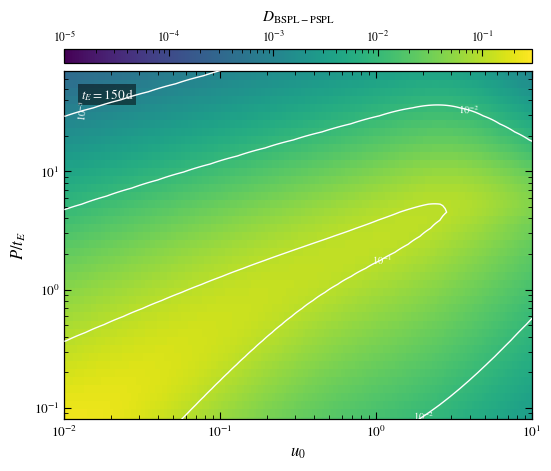

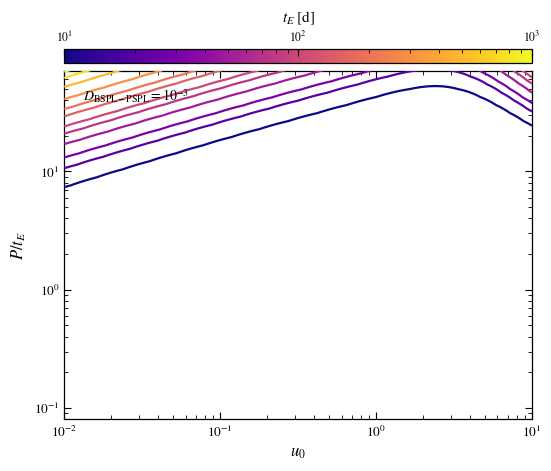

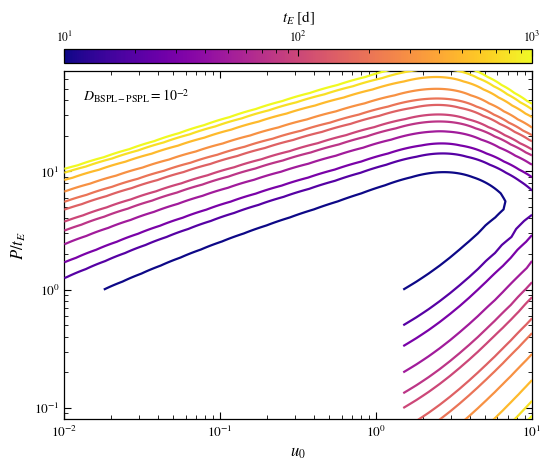

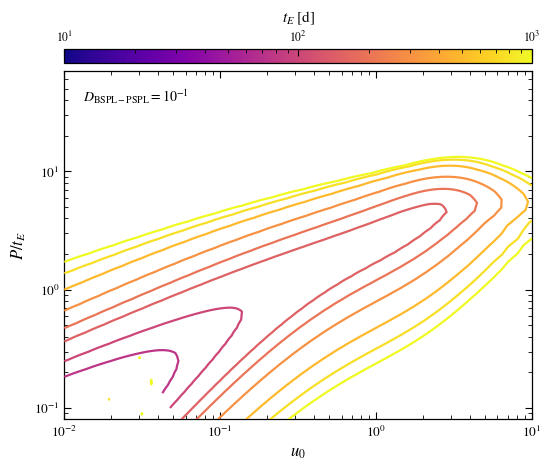

In [35]:
# ============================================================
# D METRIC -- MANY tE
#
# Generates:
#
# 1) One D heatmap for representative tE
#    with several constant-D contours.
#
# 2) One figure PER D LEVEL showing how that contour
#    changes with tE.
#
# Metric:
#
#       D = ||A_BSPL - A_PSPL,best||_2
#           -------------------------
#                ||A_BSPL - 1||_2
#
# No interpolation across failed fits.
# ============================================================

import glob
import os
import re

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from matplotlib.cm import ScalarMappable


# ============================================================
# PAPER STYLE
# ============================================================

plt.rcParams.update({

    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",

    "font.size": 10,

    "axes.labelsize": 12,
    "axes.titlesize": 10,

    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,

    "axes.linewidth": 0.9,

    "xtick.direction": "in",
    "ytick.direction": "in",

    "xtick.top": True,
    "ytick.right": True,

    "xtick.major.size": 5,
    "ytick.major.size": 5,

    "xtick.minor.size": 3,
    "ytick.minor.size": 3,

    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,

    "savefig.dpi": 300,
})


# ============================================================
# CONFIGURATION
# ============================================================

home_path = os.path.expanduser("~")

base_directory = os.path.join(
    home_path,
    "binary_source",
    "results",
    "scan_many_tE_200x200",
)


# ============================================================
# tE VALUES
#
# Change if your actual scan used another list.
# ============================================================

tE_list = np.array(
    [
        10,
        20,
        30,
        50,
        75,
        100,
        150,
        200,
        300,
        500,
        750,
        1000,
    ],
    dtype=float,
)


# ============================================================
# REPRESENTATIVE tE FOR HEATMAP
# ============================================================

tE_heatmap = 150.0


# ============================================================
# CONSTANT-D LEVELS
#
# These are NOT detection thresholds.
# They are simply reference levels of normalized mismatch.
# ============================================================

D_LEVELS = np.array(
    [
        1e-3,
        1e-2,
        1e-1,
    ],
    dtype=float,
)


# ============================================================
# AXIS LIMITS
# ============================================================

XMIN = 1e-2
XMAX = 1e1

YMIN = 8e-2
YMAX = 7e1


# ============================================================
# FIGURE SIZE
# ============================================================

FIGSIZE = (5.4, 4.6)


# ============================================================
# D COLOR SCALE
#
# Fixed scale is useful if you later compare heatmaps.
# ============================================================

D_VMIN = 1e-5
D_VMAX = 3e-1


# ============================================================
# AUXILIARY FUNCTIONS
# ============================================================

def format_tE_label(tE):

    label = f"{float(tE):g}"

    return label.replace(
        ".",
        "p",
    )


def extract_u0_index(filename):

    base = os.path.basename(
        filename
    )

    match = re.fullmatch(
        r"scan_kepler_u0_(\d+)\.npz",
        base,
    )

    if match is None:

        raise ValueError(
            f"No pude extraer el índice desde {base}"
        )

    return int(
        match.group(1)
    )


def log_bin_edges(x):

    x = np.asarray(
        x,
        dtype=float,
    )

    if len(x) < 2:

        raise ValueError(
            "Se necesitan al menos dos puntos."
        )

    if np.any(
        x <= 0
    ):

        raise ValueError(
            "Todos los valores deben ser positivos."
        )

    lx = np.log10(
        x
    )

    edges = np.empty(
        len(x) + 1,
        dtype=float,
    )

    edges[1:-1] = (
        0.5
        * (
            lx[:-1]
            + lx[1:]
        )
    )

    edges[0] = (
        lx[0]
        - 0.5
        * (
            lx[1]
            - lx[0]
        )
    )

    edges[-1] = (
        lx[-1]
        + 0.5
        * (
            lx[-1]
            - lx[-2]
        )
    )

    return 10**edges


# ============================================================
# LOAD ONE tE MAP
# ============================================================

def load_D_map(
    tE_true,
    base_directory,
):

    label = format_tE_label(
        tE_true
    )

    directory = os.path.join(
        base_directory,
        f"scan_u0_tE{label}",
    )

    pattern = os.path.join(
        directory,
        "scan_kepler_u0_*.npz",
    )

    files = sorted(
        glob.glob(pattern)
    )

    if len(files) == 0:

        raise FileNotFoundError(
            pattern
        )

    records = []

    P_grid_reference = None
    xi_rel_reference = None

    total_bins = 0
    successful_bins = 0


    # ========================================================
    # FIRST PASS
    # ========================================================

    for filename in files:


        with np.load(
            filename,
            allow_pickle=False,
        ) as d:


            if "D" not in d.files:

                raise KeyError(
                    f"\n{filename}\n"
                    f"does not contain D."
                )


            truth = d[
                "truth"
            ].astype(float)


            u0_true = float(
                truth[1]
            )


            P_grid = d[
                "P_grid"
            ].astype(float)


            SUCCESS = d[
                "SUCCESS"
            ].astype(bool)


            # ------------------------------------------------
            # Legacy key storing xi_rel in these simulations
            # ------------------------------------------------

            if "xiE_of_P" in d.files:

                xi_rel = d[
                    "xiE_of_P"
                ].astype(float)

            else:

                xi_rel = None


        # ====================================================
        # COMMON P GRID
        # ====================================================

        if P_grid_reference is None:

            P_grid_reference = (
                P_grid.copy()
            )

        else:

            if (
                len(P_grid)
                != len(P_grid_reference)
                or
                not np.allclose(
                    P_grid,
                    P_grid_reference,
                )
            ):

                raise ValueError(
                    f"P_grid inconsistent in:\n"
                    f"{filename}"
                )


        # ====================================================
        # COMMON xi_rel
        # ====================================================

        if xi_rel is not None:

            if xi_rel_reference is None:

                xi_rel_reference = (
                    xi_rel.copy()
                )

            else:

                if not np.allclose(
                    xi_rel,
                    xi_rel_reference,
                ):

                    raise ValueError(
                        f"xiE_of_P inconsistent in:\n"
                        f"{filename}"
                    )


        total_bins += len(
            SUCCESS
        )

        successful_bins += np.count_nonzero(
            SUCCESS
        )


        records.append(
            {
                "filename":
                    filename,

                "index":
                    extract_u0_index(
                        filename
                    ),

                "u0":
                    u0_true,
            }
        )


    # ========================================================
    # SORT BY u0
    # ========================================================

    records = sorted(
        records,
        key=lambda r:
            r["u0"],
    )


    u0_grid = np.array(
        [
            r["u0"]
            for r in records
        ],
        dtype=float,
    )


    Nu0 = len(
        u0_grid
    )

    NP = len(
        P_grid_reference
    )


    # ========================================================
    # D MAP
    # ========================================================

    D_map = np.full(
        (Nu0, NP),
        np.nan,
        dtype=float,
    )


    for i, record in enumerate(
        records
    ):


        with np.load(
            record["filename"],
            allow_pickle=False,
        ) as d:


            D = d[
                "D"
            ].astype(float)


            SUCCESS = d[
                "SUCCESS"
            ].astype(bool)


        valid = (
            SUCCESS
            & np.isfinite(
                D
            )
            & (
                D > 0
            )
        )


        D_map[
            i,
            valid,
        ] = D[
            valid
        ]


    P_over_tE = (
        P_grid_reference
        / float(tE_true)
    )


    return dict(

        tE=float(
            tE_true
        ),

        directory=directory,

        u0=u0_grid,

        P=P_grid_reference,

        P_over_tE=P_over_tE,

        xi_rel=xi_rel_reference,

        D=D_map,

        success_fraction=(
            successful_bins
            / total_bins
        ),
    )


# ============================================================
# LOAD ALL tE
# ============================================================

results = []


print()

print("=" * 80)

print(
    "Loading D maps"
)

print("=" * 80)


for tE_true in tE_list:


    try:

        result = load_D_map(

            tE_true=tE_true,

            base_directory=base_directory,
        )

    except FileNotFoundError:

        print(
            f"tE={tE_true:g} d missing -> skipped"
        )

        continue


    results.append(
        result
    )


    valid = np.isfinite(
        result["D"]
    )


    if np.any(valid):

        dmin = np.nanmin(
            result["D"]
        )

        dmax = np.nanmax(
            result["D"]
        )

    else:

        dmin = np.nan
        dmax = np.nan


    print(

        f"tE={tE_true:7.1f} d   "

        f"success="
        f"{100*result['success_fraction']:6.2f}%   "

        f"D=[{dmin:.2e}, {dmax:.2e}]"
    )


if len(results) == 0:

    raise RuntimeError(
        "No D maps loaded."
    )


# ============================================================
# FIND REPRESENTATIVE tE
# ============================================================

heatmap_result = None


for result in results:

    if np.isclose(
        result["tE"],
        tE_heatmap,
    ):

        heatmap_result = result

        break


if heatmap_result is None:

    raise RuntimeError(
        f"No result for tE={tE_heatmap:g} d."
    )


# ============================================================
#
# FIGURE 1
#
# D HEATMAP + CONSTANT-D CONTOURS
#
# ============================================================

u0 = heatmap_result[
    "u0"
]

P_over_tE = heatmap_result[
    "P_over_tE"
]

D_map = heatmap_result[
    "D"
]


u0_edges = log_bin_edges(
    u0
)

P_edges = log_bin_edges(
    P_over_tE
)


# ============================================================
# COLOR NORMALIZATION
# ============================================================

norm_D = mcolors.LogNorm(

    vmin=D_VMIN,

    vmax=D_VMAX,
)


fig, ax = plt.subplots(

    figsize=FIGSIZE,

    constrained_layout=True,
)


# ============================================================
# HEATMAP
# ============================================================

pcm = ax.pcolormesh(

    u0_edges,

    P_edges,

    np.ma.masked_invalid(
        D_map
    ).T,

    cmap="viridis",

    norm=norm_D,

    shading="auto",

    rasterized=True,

    edgecolors="none",

    linewidth=0,
)


# ============================================================
# CONSTANT-D CONTOURS
# ============================================================

U2D, Y2D = np.meshgrid(

    u0,

    P_over_tE,

    indexing="xy",
)


# ------------------------------------------------------------
# Only draw levels actually contained in the data.
# ------------------------------------------------------------

valid_D = (
    np.isfinite(
        D_map
    )
    & (
        D_map > 0
    )
)


D_min = np.nanmin(
    D_map[
        valid_D
    ]
)

D_max = np.nanmax(
    D_map[
        valid_D
    ]
)


levels_available = [

    level

    for level in D_LEVELS

    if (
        D_min
        <= level
        <= D_max
    )
]


print()

print(
    f"Representative tE={tE_heatmap:g} d:"
)

print(
    f"D range = {D_min:.3e} -- {D_max:.3e}"
)

print(
    f"Contours drawn = {levels_available}"
)


if len(
    levels_available
) > 0:


    cs = ax.contour(

        U2D,

        Y2D,

        np.ma.masked_invalid(
            D_map.T
        ),

        levels=levels_available,

        colors="white",

        linewidths=1.0,

        linestyles="-",

        zorder=5,
    )


    # ========================================================
    # Labels without inline=True
    #
    # inline=False avoids cutting the contour underneath.
    # ========================================================

    ax.clabel(

        cs,

        fmt=lambda value:
            rf"$10^{{{int(np.round(np.log10(value)))}}}$",

        fontsize=7.5,

        colors="white",

        inline=False,
    )


# ============================================================
# AXES
# ============================================================

ax.set_xscale(
    "log"
)

ax.set_yscale(
    "log"
)


ax.set_xlim(
    XMIN,
    XMAX,
)

ax.set_ylim(
    YMIN,
    YMAX,
)


ax.set_xlabel(
    r"$u_0$"
)

ax.set_ylabel(
    r"$P/t_E$"
)


ax.tick_params(

    axis="both",

    which="both",

    direction="in",

    top=True,

    right=True,
)


ax.grid(
    False
)


# ============================================================
# tE LABEL
# ============================================================

ax.text(

    0.035,
    0.955,

    rf"$t_E={tE_heatmap:.0f}\,\mathrm{{d}}$",

    transform=ax.transAxes,

    ha="left",

    va="top",

    fontsize=9.5,

    color="white",

    bbox=dict(

        facecolor="black",

        edgecolor="none",

        alpha=0.50,

        pad=2.0,
    ),
)


# ============================================================
# COLORBAR
# ============================================================

cbar = fig.colorbar(

    pcm,

    ax=ax,

    orientation="horizontal",

    location="top",

    pad=0.025,

    fraction=0.055,

    aspect=35,
)


cbar.set_label(

    r"$D_{\rm BSPL-PSPL}$",

    fontsize=11,

    labelpad=5,
)


cbar.ax.tick_params(

    axis="x",

    which="both",

    direction="in",

    labelsize=8.5,
)


cbar.ax.xaxis.set_ticks_position(
    "top"
)

cbar.ax.xaxis.set_label_position(
    "top"
)


# ============================================================
# SAVE HEATMAP
# ============================================================

output_heatmap_png = os.path.join(
    base_directory,
    f"paper_D_heatmap_contours_tE{int(tE_heatmap)}.png",
)

output_heatmap_pdf = os.path.join(
    base_directory,
    f"paper_D_heatmap_contours_tE{int(tE_heatmap)}.pdf",
)


fig.savefig(

    output_heatmap_png,

    dpi=300,

    bbox_inches="tight",
)


fig.savefig(

    output_heatmap_pdf,

    bbox_inches="tight",
)


# ============================================================
#
# FIGURES 2...
#
# ONE MULTI-tE FIGURE PER D LEVEL
#
# ============================================================

tE_loaded = np.array(
    [
        result["tE"]
        for result in results
    ],
    dtype=float,
)


norm_tE = mcolors.LogNorm(

    vmin=np.min(
        tE_loaded
    ),

    vmax=np.max(
        tE_loaded
    ),
)


cmap_tE = plt.get_cmap(
    "plasma"
)


# ============================================================
# LOOP OVER D LEVELS
# ============================================================

for D_level in D_LEVELS:


    fig_level, ax_level = plt.subplots(

        figsize=FIGSIZE,

        constrained_layout=True,
    )


    n_contours = 0


    for result in results:


        tE = result[
            "tE"
        ]


        u0 = result[
            "u0"
        ]


        y = result[
            "P_over_tE"
        ]


        D_map = result[
            "D"
        ]


        valid = (
            np.isfinite(
                D_map
            )
            & (
                D_map > 0
            )
        )


        if not np.any(
            valid
        ):

            continue


        D_min = np.nanmin(
            D_map[
                valid
            ]
        )


        D_max = np.nanmax(
            D_map[
                valid
            ]
        )


        # ----------------------------------------------------
        # This tE does not cross this level
        # ----------------------------------------------------

        if not (
            D_min
            <= D_level
            <= D_max
        ):

            print(

                f"D={D_level:.0e}: "
                f"tE={tE:g} d does not cross level "
                f"[range {D_min:.2e}, {D_max:.2e}]"
            )

            continue


        U2D, Y2D = np.meshgrid(

            u0,

            y,

            indexing="xy",
        )


        color = cmap_tE(
            norm_tE(
                tE
            )
        )


        cs = ax_level.contour(

            U2D,

            Y2D,

            np.ma.masked_invalid(
                D_map.T
            ),

            levels=[
                D_level
            ],

            colors=[
                color
            ],

            linewidths=1.6,

            linestyles="-",

            zorder=3,
        )


        # ----------------------------------------------------
        # Check that an actual contour segment exists
        # ----------------------------------------------------

        if (
            len(cs.allsegs) > 0
            and
            len(cs.allsegs[0]) > 0
        ):

            n_contours += 1


    # ========================================================
    # AXES
    # ========================================================

    ax_level.set_xscale(
        "log"
    )

    ax_level.set_yscale(
        "log"
    )


    ax_level.set_xlim(
        XMIN,
        XMAX,
    )

    ax_level.set_ylim(
        YMIN,
        YMAX,
    )


    ax_level.set_xlabel(
        r"$u_0$"
    )

    ax_level.set_ylabel(
        r"$P/t_E$"
    )


    ax_level.tick_params(

        axis="both",

        which="both",

        direction="in",

        top=True,

        right=True,
    )


    ax_level.grid(
        False
    )


    # ========================================================
    # D LEVEL LABEL
    # ========================================================

    exponent = int(
        np.round(
            np.log10(
                D_level
            )
        )
    )


    ax_level.text(

        0.04,
        0.955,

        rf"$D_{{\rm BSPL-PSPL}}=10^{{{exponent}}}$",

        transform=ax_level.transAxes,

        ha="left",

        va="top",

        fontsize=10,
    )


    # ========================================================
    # tE COLORBAR
    # ========================================================

    sm = ScalarMappable(

        norm=norm_tE,

        cmap=cmap_tE,
    )


    sm.set_array([])


    cbar_level = fig_level.colorbar(

        sm,

        ax=ax_level,

        orientation="horizontal",

        location="top",

        pad=0.025,

        fraction=0.055,

        aspect=35,
    )


    cbar_level.set_label(

        r"$t_E\;[\mathrm{d}]$",

        fontsize=11,

        labelpad=5,
    )


    cbar_level.ax.tick_params(

        axis="x",

        which="both",

        direction="in",

        labelsize=8.5,
    )


    cbar_level.ax.xaxis.set_ticks_position(
        "top"
    )

    cbar_level.ax.xaxis.set_label_position(
        "top"
    )


    # ========================================================
    # SAVE
    # ========================================================

    level_string = (
        f"{D_level:.0e}"
        .replace(
            "-",
            "m",
        )
        .replace(
            "+",
            "p",
        )
    )


    output_png = os.path.join(

        base_directory,

        f"paper_D_contour_{level_string}_many_tE.png",
    )


    output_pdf = os.path.join(

        base_directory,

        f"paper_D_contour_{level_string}_many_tE.pdf",
    )


    fig_level.savefig(

        output_png,

        dpi=300,

        bbox_inches="tight",
    )


    fig_level.savefig(

        output_pdf,

        bbox_inches="tight",
    )


    print()

    print(
        f"D level = {D_level:.1e}"
    )

    print(
        f"Contours plotted = {n_contours}"
    )

    print(
        output_png
    )

    print(
        output_pdf
    )


# ============================================================
# FINAL OUTPUT
# ============================================================

print()

print("=" * 80)

print("Representative heatmap:")

print(
    output_heatmap_png
)

print(
    output_heatmap_pdf
)

print("=" * 80)


plt.show()


Loading D and Q_Roman maps
tE=   10.0 d   Nfiles=200   success=100.00%   D=[6.98e-08,2.02e-02]   Q=[6.09e-10,6.21e-01]
tE=   20.0 d   Nfiles=200   success=100.00%   D=[2.79e-07,3.68e-02]   Q=[2.44e-09,1.42e+00]
tE=   30.0 d   Nfiles=200   success=100.00%   D=[6.28e-07,5.32e-02]   Q=[5.50e-09,2.22e+00]
tE=   50.0 d   Nfiles=200   success=100.00%   D=[1.75e-06,8.57e-02]   Q=[1.54e-08,3.72e+00]
tE=   75.0 d   Nfiles=200   success=100.00%   D=[3.93e-06,1.27e-01]   Q=[3.47e-08,5.34e+00]
tE=  100.0 d   Nfiles=200   success=100.00%   D=[6.98e-06,1.68e-01]   Q=[6.21e-08,6.67e+00]
tE=  150.0 d   Nfiles=200   success=100.00%   D=[1.57e-05,2.51e-01]   Q=[1.41e-07,8.76e+00]
tE=  200.0 d   Nfiles=200   success=100.00%   D=[2.78e-05,3.21e-01]   Q=[2.53e-07,1.06e+01]
tE=  300.0 d   Nfiles=200   success=100.00%   D=[6.22e-05,4.41e-01]   Q=[5.82e-07,1.40e+01]
tE=  500.0 d   Nfiles=200   success=100.00%   D=[1.70e-04,6.70e-01]   Q=[1.68e-06,2.19e+01]
tE=  750.0 d   Nfiles=200   success=100.00%   D=[3.6

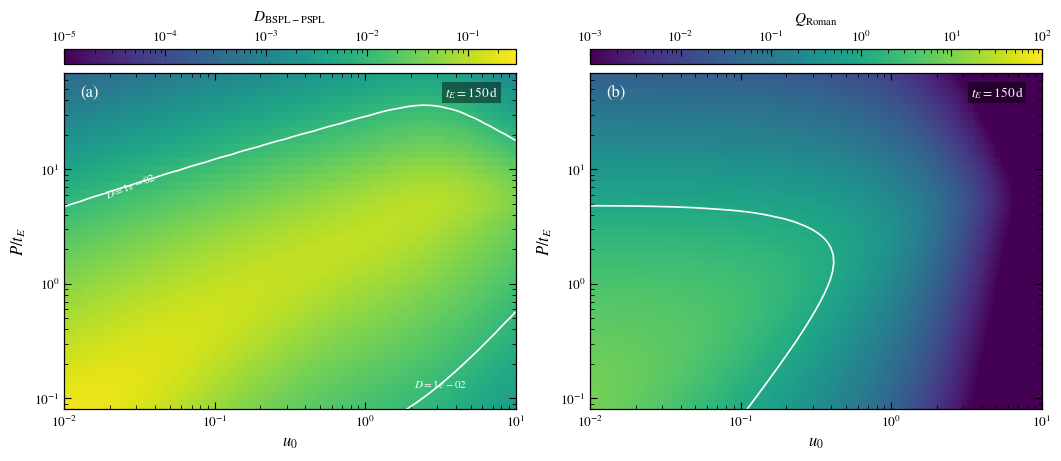

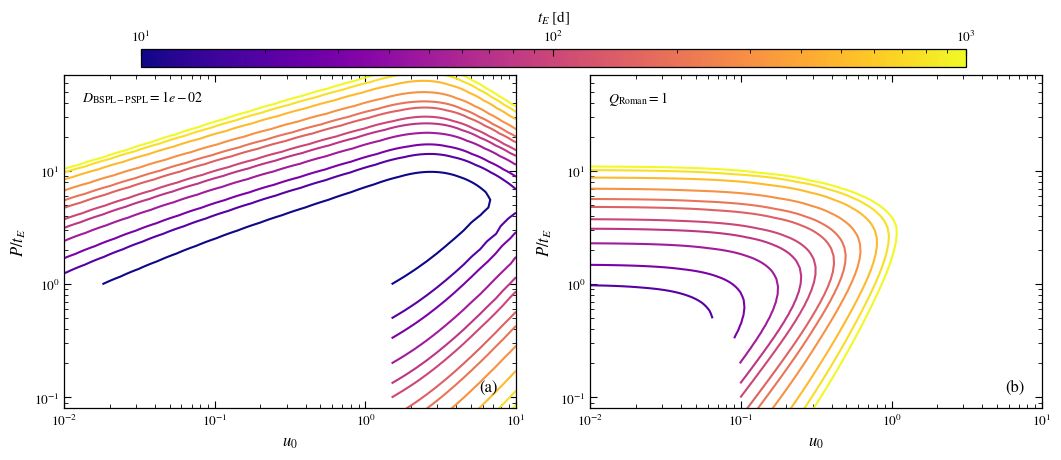

In [36]:
# ============================================================
# COMPARISON:
#
#   D_BSPL-PSPL  vs  Q_Roman
#
# where
#
#         ||A_true - A_fit||
#   D =  --------------------
#           ||A_true - 1||
#
# and the saved Q_A is
#
#                        1     (F_true - F_fit)^2
#   Q_Roman = sqrt(     --- sum ------------------- )
#                        N          sigma_F^2
#
#
# FIGURE 1:
#   D and Q_Roman heatmaps for one representative tE.
#
# FIGURE 2:
#   Many-tE contours:
#       D = constant
#       Q_Roman = constant
#
# IMPORTANT:
# Q_Roman is NOT a Roman detection significance because
# the real Roman cadence is not included.
# It measures the typical model separation per sampled point
# in units of the adopted Roman-like photometric uncertainty.
# ============================================================


import os
import glob
import re

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from matplotlib.cm import ScalarMappable


# ============================================================
# PAPER STYLE
# ============================================================

plt.rcParams.update({

    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",

    "font.size": 10,

    "axes.labelsize": 12,
    "axes.titlesize": 11,

    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,

    "axes.linewidth": 0.9,

    "xtick.direction": "in",
    "ytick.direction": "in",

    "xtick.top": True,
    "ytick.right": True,

    "xtick.major.size": 5,
    "ytick.major.size": 5,

    "xtick.minor.size": 3,
    "ytick.minor.size": 3,

    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,

    "savefig.dpi": 300,
})


# ============================================================
# PATHS
# ============================================================

home_path = os.path.expanduser("~")

base_directory = os.path.join(
    home_path,
    "binary_source",
    "results",
    "scan_many_tE_200x200",
)


# ============================================================
# tE VALUES
# ============================================================

tE_list = np.array(
    [
        10,
        20,
        30,
        50,
        75,
        100,
        150,
        200,
        300,
        500,
        750,
        1000,
    ],
    dtype=float,
)


# ============================================================
# REPRESENTATIVE tE
# ============================================================

tE_plot = 150.0


# ============================================================
# REFERENCE CONTOURS
#
# These are NOT detection thresholds.
#
# D_LEVEL:
#     intrinsic normalized mismatch
#
# Q_LEVEL:
#     mean residual separation in units of sigma_Roman
# ============================================================

D_LEVEL = 1e-2

Q_LEVEL = 1.0


# ============================================================
# AXIS LIMITS
# ============================================================

XMIN = 1e-2
XMAX = 1e1

YMIN = 8e-2
YMAX = 7e1


# ============================================================
# COLORMAP LIMITS
#
# Set manually if you want identical scales between different
# versions of the figures.
# ============================================================

D_VMIN = 1e-5
D_VMAX = 3e-1

Q_VMIN = 1e-3
Q_VMAX = 1e2


# ============================================================
# FIGURE SIZES
# ============================================================

FIGSIZE_SINGLE = (10.5, 4.5)

FIGSIZE_CONTOURS = (10.5, 4.5)


# ============================================================
# HELPERS
# ============================================================

def format_tE_label(tE):

    label = f"{float(tE):g}"

    return label.replace(
        ".",
        "p",
    )


def extract_u0_index(filename):

    base = os.path.basename(
        filename
    )

    match = re.fullmatch(
        r"scan_kepler_u0_(\d+)\.npz",
        base,
    )

    if match is None:

        raise ValueError(
            f"No pude extraer el índice desde {base}"
        )

    return int(
        match.group(1)
    )


def log_bin_edges(x):

    x = np.asarray(
        x,
        dtype=float,
    )

    if len(x) < 2:

        raise ValueError(
            "Se necesitan al menos dos puntos."
        )

    if np.any(
        x <= 0
    ):

        raise ValueError(
            "Todos los valores deben ser positivos."
        )

    lx = np.log10(
        x
    )

    edges = np.empty(
        len(x) + 1,
        dtype=float,
    )

    edges[1:-1] = (
        0.5
        * (
            lx[:-1]
            + lx[1:]
        )
    )

    edges[0] = (
        lx[0]
        - 0.5
        * (
            lx[1]
            - lx[0]
        )
    )

    edges[-1] = (
        lx[-1]
        + 0.5
        * (
            lx[-1]
            - lx[-2]
        )
    )

    return 10**edges


# ============================================================
# LOAD ONE tE
# ============================================================

def load_maps_for_tE(
    tE_true,
    base_directory,
):

    label = format_tE_label(
        tE_true
    )

    directory = os.path.join(
        base_directory,
        f"scan_u0_tE{label}",
    )

    pattern = os.path.join(
        directory,
        "scan_kepler_u0_*.npz",
    )

    files = sorted(
        glob.glob(
            pattern
        )
    )

    if len(files) == 0:

        raise FileNotFoundError(
            pattern
        )

    records = []

    P_grid_reference = None
    xi_rel_reference = None

    total_bins = 0
    successful_bins = 0


    # ========================================================
    # FIRST PASS
    # ========================================================

    for filename in files:

        with np.load(
            filename,
            allow_pickle=False,
        ) as d:

            # ------------------------------------------------
            # Check keys
            # ------------------------------------------------

            if "D" not in d.files:

                raise KeyError(
                    f"\n{filename}\n"
                    "does not contain D."
                )

            if "Q_A" not in d.files:

                raise KeyError(
                    f"\n{filename}\n"
                    "does not contain Q_A."
                )


            truth = d[
                "truth"
            ].astype(float)

            u0_true = float(
                truth[1]
            )

            P_grid = d[
                "P_grid"
            ].astype(float)

            SUCCESS = d[
                "SUCCESS"
            ].astype(bool)


            if "xiE_of_P" in d.files:

                xi_rel = d[
                    "xiE_of_P"
                ].astype(float)

            else:

                xi_rel = None


        # ====================================================
        # SAME P GRID
        # ====================================================

        if P_grid_reference is None:

            P_grid_reference = (
                P_grid.copy()
            )

        else:

            if (
                len(P_grid)
                != len(P_grid_reference)
                or
                not np.allclose(
                    P_grid,
                    P_grid_reference,
                )
            ):

                raise ValueError(
                    f"P_grid inconsistent in:\n"
                    f"{filename}"
                )


        # ====================================================
        # SAME xi_rel GRID
        # ====================================================

        if xi_rel is not None:

            if xi_rel_reference is None:

                xi_rel_reference = (
                    xi_rel.copy()
                )

            else:

                if not np.allclose(
                    xi_rel,
                    xi_rel_reference,
                ):

                    raise ValueError(
                        f"xiE_of_P inconsistent in:\n"
                        f"{filename}"
                    )


        total_bins += len(
            SUCCESS
        )

        successful_bins += np.count_nonzero(
            SUCCESS
        )


        records.append(
            {
                "filename":
                    filename,

                "index":
                    extract_u0_index(
                        filename
                    ),

                "u0":
                    u0_true,
            }
        )


    # ========================================================
    # SORT BY u0
    # ========================================================

    records = sorted(
        records,
        key=lambda rec:
            rec["u0"],
    )


    u0_grid = np.array(
        [
            rec["u0"]
            for rec in records
        ],
        dtype=float,
    )


    Nu0 = len(
        u0_grid
    )

    NP = len(
        P_grid_reference
    )


    # ========================================================
    # MAPS
    # ========================================================

    D_map = np.full(
        (Nu0, NP),
        np.nan,
        dtype=float,
    )

    Q_map = np.full(
        (Nu0, NP),
        np.nan,
        dtype=float,
    )


    # Optional RMS map, useful for later comparison

    RMS_map = np.full(
        (Nu0, NP),
        np.nan,
        dtype=float,
    )


    # ========================================================
    # SECOND PASS
    # ========================================================

    for i, rec in enumerate(
        records
    ):

        with np.load(
            rec["filename"],
            allow_pickle=False,
        ) as d:

            D = d[
                "D"
            ].astype(float)

            Q = d[
                "Q_A"
            ].astype(float)

            SUCCESS = d[
                "SUCCESS"
            ].astype(bool)

            if "RMS" in d.files:

                RMS = d[
                    "RMS"
                ].astype(float)

            else:

                RMS = np.full_like(
                    D,
                    np.nan,
                )


        # ----------------------------------------------------
        # D
        # ----------------------------------------------------

        valid_D = (
            SUCCESS
            & np.isfinite(
                D
            )
            & (
                D > 0
            )
        )

        D_map[
            i,
            valid_D,
        ] = D[
            valid_D
        ]


        # ----------------------------------------------------
        # Q
        # ----------------------------------------------------

        valid_Q = (
            SUCCESS
            & np.isfinite(
                Q
            )
            & (
                Q > 0
            )
        )

        Q_map[
            i,
            valid_Q,
        ] = Q[
            valid_Q
        ]


        # ----------------------------------------------------
        # RMS
        # ----------------------------------------------------

        valid_RMS = (
            SUCCESS
            & np.isfinite(
                RMS
            )
            & (
                RMS > 0
            )
        )

        RMS_map[
            i,
            valid_RMS,
        ] = RMS[
            valid_RMS
        ]


    # ========================================================
    # P / tE
    # ========================================================

    P_over_tE = (
        P_grid_reference
        / float(
            tE_true
        )
    )


    return dict(

        tE=float(
            tE_true
        ),

        directory=directory,

        u0=u0_grid,

        P=P_grid_reference,

        P_over_tE=P_over_tE,

        xi_rel=xi_rel_reference,

        D=D_map,

        Q=Q_map,

        RMS=RMS_map,

        success_fraction=(
            successful_bins
            /
            total_bins
        ),

        n_files=len(
            files
        ),
    )


# ============================================================
# LOAD ALL tE
# ============================================================

results = []


print()

print("=" * 80)

print(
    "Loading D and Q_Roman maps"
)

print("=" * 80)


for tE_true in tE_list:

    try:

        result = load_maps_for_tE(

            tE_true=tE_true,

            base_directory=base_directory,
        )

    except FileNotFoundError:

        print(
            f"tE={tE_true:g} d missing -> skipped"
        )

        continue


    results.append(
        result
    )


    D_valid = (
        np.isfinite(
            result["D"]
        )
        &
        (
            result["D"] > 0
        )
    )

    Q_valid = (
        np.isfinite(
            result["Q"]
        )
        &
        (
            result["Q"] > 0
        )
    )


    if np.any(
        D_valid
    ):

        Dmin = np.nanmin(
            result["D"][
                D_valid
            ]
        )

        Dmax = np.nanmax(
            result["D"][
                D_valid
            ]
        )

    else:

        Dmin = np.nan
        Dmax = np.nan


    if np.any(
        Q_valid
    ):

        Qmin = np.nanmin(
            result["Q"][
                Q_valid
            ]
        )

        Qmax = np.nanmax(
            result["Q"][
                Q_valid
            ]
        )

    else:

        Qmin = np.nan
        Qmax = np.nan


    print(

        f"tE={tE_true:7.1f} d   "

        f"Nfiles={result['n_files']:3d}   "

        f"success={100*result['success_fraction']:6.2f}%   "

        f"D=[{Dmin:.2e},{Dmax:.2e}]   "

        f"Q=[{Qmin:.2e},{Qmax:.2e}]"
    )


if len(
    results
) == 0:

    raise RuntimeError(
        "No maps could be loaded."
    )


# ============================================================
# FIND REPRESENTATIVE tE
# ============================================================

result_plot = None


for result in results:

    if np.isclose(
        result["tE"],
        tE_plot,
    ):

        result_plot = (
            result
        )

        break


if result_plot is None:

    raise RuntimeError(
        f"No data found for tE={tE_plot:g} d."
    )


# ============================================================
#
# FIGURE 1
#
# D vs Q_Roman
#
# SAME tE
#
# ============================================================

u0 = result_plot[
    "u0"
]

P_over_tE = result_plot[
    "P_over_tE"
]

D_map = result_plot[
    "D"
]

Q_map = result_plot[
    "Q"
]


# ============================================================
# BIN EDGES
# ============================================================

u0_edges = log_bin_edges(
    u0
)

P_edges = log_bin_edges(
    P_over_tE
)


# ============================================================
# NORMALIZATIONS
# ============================================================

norm_D = mcolors.LogNorm(

    vmin=D_VMIN,

    vmax=D_VMAX,
)


norm_Q = mcolors.LogNorm(

    vmin=Q_VMIN,

    vmax=Q_VMAX,
)


# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(

    1,
    2,

    figsize=FIGSIZE_SINGLE,

    constrained_layout=True,
)


axD = axes[
    0
]

axQ = axes[
    1
]


# ============================================================
# D HEATMAP
# ============================================================

pcm_D = axD.pcolormesh(

    u0_edges,

    P_edges,

    np.ma.masked_invalid(
        D_map
    ).T,

    cmap="viridis",

    norm=norm_D,

    shading="auto",

    rasterized=True,
)


# ============================================================
# D REFERENCE CONTOUR
# ============================================================

D_valid = (
    np.isfinite(
        D_map
    )
    &
    (
        D_map > 0
    )
)


if np.any(
    D_valid
):

    Dmin = np.nanmin(
        D_map[
            D_valid
        ]
    )

    Dmax = np.nanmax(
        D_map[
            D_valid
        ]
    )


    if (
        Dmin
        <= D_LEVEL
        <= Dmax
    ):

        csD = axD.contour(

            u0,

            P_over_tE,

            np.ma.masked_invalid(
                D_map.T
            ),

            levels=[
                D_LEVEL
            ],

            colors="white",

            linewidths=1.2,
        )


        axD.clabel(

            csD,

            fmt={
                D_LEVEL:
                    rf"$D={D_LEVEL:.0e}$"
            },

            fontsize=8,

            colors="white",

            inline=False,
        )


# ============================================================
# Q HEATMAP
# ============================================================

pcm_Q = axQ.pcolormesh(

    u0_edges,

    P_edges,

    np.ma.masked_invalid(
        Q_map
    ).T,

    cmap="viridis",

    norm=norm_Q,

    shading="auto",

    rasterized=True,
)


# ============================================================
# Q = 1 CONTOUR
# ============================================================

Q_valid = (
    np.isfinite(
        Q_map
    )
    &
    (
        Q_map > 0
    )
)


if np.any(
    Q_valid
):

    Qmin = np.nanmin(
        Q_map[
            Q_valid
        ]
    )

    Qmax = np.nanmax(
        Q_map[
            Q_valid
        ]
    )


    if (
        Qmin
        <= Q_LEVEL
        <= Qmax
    ):

        csQ = axQ.contour(

            u0,

            P_over_tE,

            np.ma.masked_invalid(
                Q_map.T
            ),

            levels=[
                Q_LEVEL
            ],

            colors="white",

            linewidths=1.2,
        )


        axQ.clabel(

            csQ,

            fmt={
                Q_LEVEL:
                    rf"$Q_{{\rm Roman}}={Q_LEVEL:g}$"
            },

            fontsize=8,

            colors="white",

            inline=False,
        )


# ============================================================
# AXIS FORMAT
# ============================================================

for ax in axes:

    ax.set_xscale(
        "log"
    )

    ax.set_yscale(
        "log"
    )

    ax.set_xlim(
        XMIN,
        XMAX,
    )

    ax.set_ylim(
        YMIN,
        YMAX,
    )

    ax.set_xlabel(
        r"$u_0$"
    )

    ax.tick_params(

        axis="both",

        which="both",

        direction="in",

        top=True,

        right=True,
    )

    ax.grid(
        False
    )


axD.set_ylabel(
    r"$P/t_E$"
)

axQ.set_ylabel(
    r"$P/t_E$"
)


# ============================================================
# PANEL LABELS
# ============================================================

axD.text(

    0.035,
    0.965,

    r"(a)",

    transform=axD.transAxes,

    ha="left",

    va="top",

    fontsize=12,

    color="white",
)


axQ.text(

    0.035,
    0.965,

    r"(b)",

    transform=axQ.transAxes,

    ha="left",

    va="top",

    fontsize=12,

    color="white",
)


# ============================================================
# tE LABEL
# ============================================================

for ax in axes:

    ax.text(

        0.96,
        0.965,

        rf"$t_E={tE_plot:.0f}\,\mathrm{{d}}$",

        transform=ax.transAxes,

        ha="right",

        va="top",

        fontsize=9.5,

        color="white",

        bbox=dict(

            facecolor="black",

            edgecolor="none",

            alpha=0.45,

            pad=2.0,
        ),
    )


# ============================================================
# COLORBARS
# ============================================================

cbar_D = fig.colorbar(

    pcm_D,

    ax=axD,

    orientation="horizontal",

    location="top",

    pad=0.025,

    fraction=0.055,

    aspect=30,
)


cbar_D.set_label(

    r"$D_{\rm BSPL-PSPL}$",

    fontsize=11,

    labelpad=5,
)


cbar_D.ax.xaxis.set_ticks_position(
    "top"
)

cbar_D.ax.xaxis.set_label_position(
    "top"
)


cbar_Q = fig.colorbar(

    pcm_Q,

    ax=axQ,

    orientation="horizontal",

    location="top",

    pad=0.025,

    fraction=0.055,

    aspect=30,
)


cbar_Q.set_label(

    r"$Q_{\rm Roman}$",

    fontsize=11,

    labelpad=5,
)


cbar_Q.ax.xaxis.set_ticks_position(
    "top"
)

cbar_Q.ax.xaxis.set_label_position(
    "top"
)


# ============================================================
# SAVE FIGURE 1
# ============================================================

output1_png = os.path.join(

    base_directory,

    f"D_vs_QRoman_tE{int(tE_plot)}.png",
)


output1_pdf = os.path.join(

    base_directory,

    f"D_vs_QRoman_tE{int(tE_plot)}.pdf",
)


fig.savefig(

    output1_png,

    dpi=300,

    bbox_inches="tight",
)


fig.savefig(

    output1_pdf,

    bbox_inches="tight",
)


print()

print(
    "Saved:"
)

print(
    output1_png
)

print(
    output1_pdf
)


# ============================================================
#
# FIGURE 2
#
# MANY tE
#
# LEFT:
#       D = D_LEVEL
#
# RIGHT:
#       Q_Roman = Q_LEVEL
#
# ============================================================

tE_loaded = np.array(
    [
        result["tE"]
        for result in results
    ],
    dtype=float,
)


norm_tE = mcolors.LogNorm(

    vmin=np.min(
        tE_loaded
    ),

    vmax=np.max(
        tE_loaded
    ),
)


cmap_tE = plt.get_cmap(
    "plasma"
)


fig2, axes2 = plt.subplots(

    1,
    2,

    figsize=FIGSIZE_CONTOURS,

    constrained_layout=True,
)


axD2 = axes2[
    0
]

axQ2 = axes2[
    1
]


# ============================================================
# LOOP OVER tE
# ============================================================

nD = 0
nQ = 0


for result in results:

    tE = result[
        "tE"
    ]

    u0 = result[
        "u0"
    ]

    y = result[
        "P_over_tE"
    ]

    D_map = result[
        "D"
    ]

    Q_map = result[
        "Q"
    ]

    color = cmap_tE(
        norm_tE(
            tE
        )
    )


    # ========================================================
    # D CONTOUR
    # ========================================================

    valid_D = (
        np.isfinite(
            D_map
        )
        &
        (
            D_map > 0
        )
    )


    if np.any(
        valid_D
    ):

        Dmin = np.nanmin(
            D_map[
                valid_D
            ]
        )

        Dmax = np.nanmax(
            D_map[
                valid_D
            ]
        )


        if (
            Dmin
            <= D_LEVEL
            <= Dmax
        ):

            cs = axD2.contour(

                u0,

                y,

                np.ma.masked_invalid(
                    D_map.T
                ),

                levels=[
                    D_LEVEL
                ],

                colors=[
                    color
                ],

                linewidths=1.5,
            )


            if (
                len(
                    cs.allsegs
                ) > 0
                and
                len(
                    cs.allsegs[
                        0
                    ]
                ) > 0
            ):

                nD += 1


    # ========================================================
    # Q CONTOUR
    # ========================================================

    valid_Q = (
        np.isfinite(
            Q_map
        )
        &
        (
            Q_map > 0
        )
    )


    if np.any(
        valid_Q
    ):

        Qmin = np.nanmin(
            Q_map[
                valid_Q
            ]
        )

        Qmax = np.nanmax(
            Q_map[
                valid_Q
            ]
        )


        if (
            Qmin
            <= Q_LEVEL
            <= Qmax
        ):

            cs = axQ2.contour(

                u0,

                y,

                np.ma.masked_invalid(
                    Q_map.T
                ),

                levels=[
                    Q_LEVEL
                ],

                colors=[
                    color
                ],

                linewidths=1.5,
            )


            if (
                len(
                    cs.allsegs
                ) > 0
                and
                len(
                    cs.allsegs[
                        0
                    ]
                ) > 0
            ):

                nQ += 1


# ============================================================
# FORMAT BOTH PANELS
# ============================================================

for ax in axes2:

    ax.set_xscale(
        "log"
    )

    ax.set_yscale(
        "log"
    )

    ax.set_xlim(
        XMIN,
        XMAX,
    )

    ax.set_ylim(
        YMIN,
        YMAX,
    )

    ax.set_xlabel(
        r"$u_0$"
    )

    ax.set_ylabel(
        r"$P/t_E$"
    )

    ax.tick_params(

        axis="both",

        which="both",

        direction="in",

        top=True,

        right=True,
    )

    ax.grid(
        False
    )


# ============================================================
# LABELS
# ============================================================

axD2.text(

    0.04,
    0.96,

    rf"$D_{{\rm BSPL-PSPL}}={D_LEVEL:.0e}$",

    transform=axD2.transAxes,

    ha="left",

    va="top",

    fontsize=10,
)


axQ2.text(

    0.04,
    0.96,

    rf"$Q_{{\rm Roman}}={Q_LEVEL:g}$",

    transform=axQ2.transAxes,

    ha="left",

    va="top",

    fontsize=10,
)


axD2.text(

    0.96,
    0.04,

    r"(a)",

    transform=axD2.transAxes,

    ha="right",

    va="bottom",

    fontsize=12,
)


axQ2.text(

    0.96,
    0.04,

    r"(b)",

    transform=axQ2.transAxes,

    ha="right",

    va="bottom",

    fontsize=12,
)


# ============================================================
# COMMON tE COLORBAR
# ============================================================

sm = ScalarMappable(

    norm=norm_tE,

    cmap=cmap_tE,
)


sm.set_array([])


cbar = fig2.colorbar(

    sm,

    ax=axes2,

    orientation="horizontal",

    location="top",

    pad=0.025,

    fraction=0.055,

    aspect=45,
)


cbar.set_label(

    r"$t_E\;[\mathrm{d}]$",

    fontsize=11,

    labelpad=5,
)


cbar.ax.xaxis.set_ticks_position(
    "top"
)

cbar.ax.xaxis.set_label_position(
    "top"
)


# ============================================================
# SAVE FIGURE 2
# ============================================================

output2_png = os.path.join(

    base_directory,

    "D_vs_QRoman_many_tE_contours.png",
)


output2_pdf = os.path.join(

    base_directory,

    "D_vs_QRoman_many_tE_contours.pdf",
)


fig2.savefig(

    output2_png,

    dpi=300,

    bbox_inches="tight",
)


fig2.savefig(

    output2_pdf,

    bbox_inches="tight",
)


print()

print("=" * 80)

print(
    f"D contours plotted: {nD}"
)

print(
    f"Q contours plotted: {nQ}"
)

print()

print(
    output2_png
)

print(
    output2_pdf
)

print("=" * 80)


plt.show()


Loading intrinsic BSPL--PSPL metrics

tE=10 d
success = 100.00%
RMS           : [3.286e-11, 4.935e-02]
RMAX          : [8.265e-11, 1.642e-01]
TDEV_over_tE  : [9.629e-03, 2.396e+00]
D             : [6.983e-08, 2.019e-02]

tE=20 d
success = 100.00%
RMS           : [1.317e-10, 1.357e-01]
RMAX          : [3.315e-10, 6.335e-01]
TDEV_over_tE  : [1.114e-02, 2.409e+00]
D             : [2.793e-07, 3.678e-02]

tE=30 d
success = 100.00%
RMS           : [2.970e-10, 2.389e-01]
RMAX          : [7.479e-10, 1.379e+00]
TDEV_over_tE  : [1.161e-02, 2.413e+00]
D             : [6.285e-07, 5.315e-02]

tE=50 d
success = 100.00%
RMS           : [8.285e-10, 4.703e-01]
RMAX          : [2.089e-09, 3.607e+00]
TDEV_over_tE  : [1.041e-02, 2.425e+00]
D             : [1.745e-06, 8.573e-02]

tE=75 d
success = 100.00%
RMS           : [1.874e-09, 7.768e-01]
RMAX          : [4.733e-09, 7.610e+00]
TDEV_over_tE  : [8.982e-03, 2.439e+00]
D             : [3.926e-06, 1.265e-01]

tE=100 d
success = 100.00%
RMS           : [3.

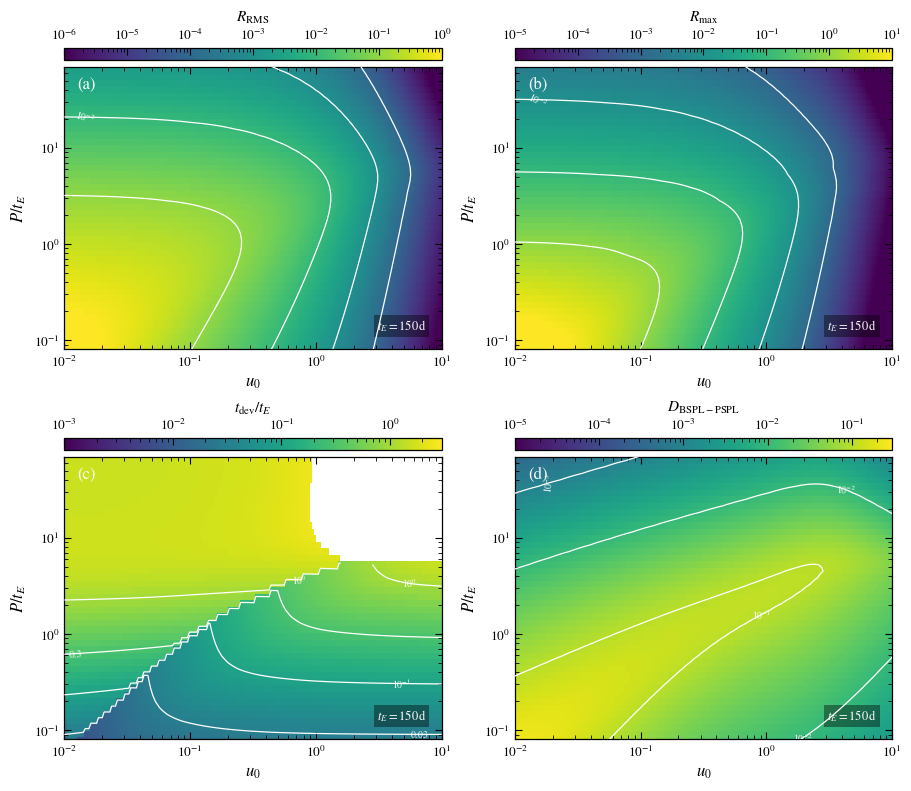

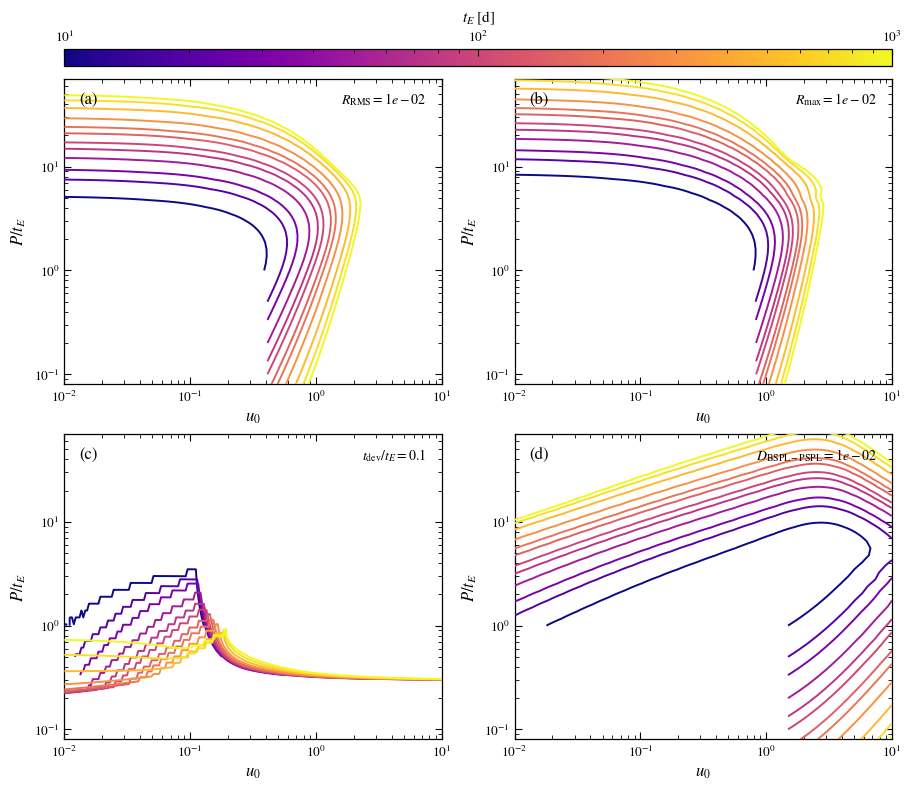

In [38]:
# ============================================================
# COMPARISON OF INTRINSIC BSPL--PSPL METRICS
#
# Metrics:
#
#   1) RMS
#   2) R_max = MAXABS
#   3) t_dev / t_E
#   4) D_BSPL-PSPL
#
# Q_Roman is deliberately NOT included here.
#
#
# FIGURE 1:
#   2x2 heatmaps for one representative tE.
#
# FIGURE 2:
#   2x2 comparison of constant-metric contours
#   for many tE values.
#
#
# Expected NPZ keys:
#
#   P_grid
#   truth
#   SUCCESS
#   RMS
#   MAXABS
#   TDEV       or TFWHM
#   TDEV_CENSORED   (optional)
#   D
#
# ============================================================


import os
import glob
import re

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from matplotlib.cm import ScalarMappable


# ============================================================
# PAPER STYLE
# ============================================================

plt.rcParams.update({

    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",

    "font.size": 10,

    "axes.labelsize": 12,
    "axes.titlesize": 11,

    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,

    "axes.linewidth": 0.9,

    "xtick.direction": "in",
    "ytick.direction": "in",

    "xtick.top": True,
    "ytick.right": True,

    "xtick.major.size": 5,
    "ytick.major.size": 5,

    "xtick.minor.size": 3,
    "ytick.minor.size": 3,

    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,

    "savefig.dpi": 300,
})


# ============================================================
# PATHS
# ============================================================

home_path = os.path.expanduser("~")

base_directory = os.path.join(
    home_path,
    "binary_source",
    "results",
    "scan_many_tE_200x200",
)

output_directory = os.path.join(
    base_directory,
    "paper_metric_comparison",
)

os.makedirs(
    output_directory,
    exist_ok=True,
)


# ============================================================
# tE VALUES
# ============================================================

tE_list = np.array(
    [
        10,
        20,
        30,
        50,
        75,
        100,
        150,
        200,
        300,
        500,
        750,
        1000,
    ],
    dtype=float,
)


# ============================================================
# REPRESENTATIVE tE
# ============================================================

tE_plot = 150.0


# ============================================================
# MASK CENSORED t_dev?
# ============================================================

MASK_TDEV_CENSORED = True


# ============================================================
# AXIS LIMITS
# ============================================================

XMIN = 1e-2
XMAX = 1e1

YMIN = 8e-2
YMAX = 7e1


# ============================================================
# HEATMAP COLOR LIMITS
#
# These can be adjusted after looking at the actual ranges.
# ============================================================

RMS_VMIN = 1e-6
RMS_VMAX = 1e0

RMAX_VMIN = 1e-5
RMAX_VMAX = 1e1

TDEV_VMIN = 1e-3
TDEV_VMAX = 3e0

D_VMIN = 1e-5
D_VMAX = 3e-1


# ============================================================
# HEATMAP CONTOURS
#
# These are reference levels, NOT detection thresholds.
# ============================================================

RMS_CONTOURS = [
    1e-4,
    1e-3,
    1e-2,
    1e-1,
]

RMAX_CONTOURS = [
    1e-3,
    1e-2,
    1e-1,
    1e0,
]

TDEV_CONTOURS = [
    0.03,
    0.1,
    0.3,
    1.0,
]

D_CONTOURS = [
    1e-3,
    1e-2,
    1e-1,
]


# ============================================================
# ONE REFERENCE LEVEL FOR THE MANY-tE FIGURE
#
# Again: reference levels, not detection thresholds.
# ============================================================

RMS_LEVEL = 1e-2

RMAX_LEVEL = 1e-2

TDEV_LEVEL = 0.1

D_LEVEL = 1e-2


# ============================================================
# FIGURE SIZES
# ============================================================

FIGSIZE_HEATMAPS = (
    9.0,
    7.8,
)

FIGSIZE_CONTOURS = (
    9.0,
    7.8,
)


# ============================================================
# HELPERS
# ============================================================

def format_tE_label(
    tE,
):

    label = f"{float(tE):g}"

    return label.replace(
        ".",
        "p",
    )


def extract_u0_index(
    filename,
):

    base = os.path.basename(
        filename
    )

    match = re.fullmatch(
        r"scan_kepler_u0_(\d+)\.npz",
        base,
    )

    if match is None:

        raise ValueError(
            f"No pude extraer el índice desde {base}"
        )

    return int(
        match.group(1)
    )


def log_bin_edges(
    x,
):

    x = np.asarray(
        x,
        dtype=float,
    )

    if len(x) < 2:

        raise ValueError(
            "Se necesitan al menos dos puntos."
        )

    if np.any(
        x <= 0
    ):

        raise ValueError(
            "Todos los valores deben ser positivos."
        )

    lx = np.log10(
        x
    )

    edges = np.empty(
        len(x) + 1,
        dtype=float,
    )

    edges[1:-1] = (
        0.5
        *
        (
            lx[:-1]
            +
            lx[1:]
        )
    )

    edges[0] = (
        lx[0]
        -
        0.5
        *
        (
            lx[1]
            -
            lx[0]
        )
    )

    edges[-1] = (
        lx[-1]
        +
        0.5
        *
        (
            lx[-1]
            -
            lx[-2]
        )
    )

    return 10**edges


def available_levels(
    data,
    levels,
):

    valid = (
        np.isfinite(
            data
        )
        &
        (
            data > 0
        )
    )

    if not np.any(
        valid
    ):

        return []

    vmin = np.nanmin(
        data[
            valid
        ]
    )

    vmax = np.nanmax(
        data[
            valid
        ]
    )

    return [
        level
        for level in levels
        if (
            vmin
            <= level
            <= vmax
        )
    ]


def contour_label(
    value,
):

    value = float(
        value
    )

    if value <= 0:

        return ""

    exponent = np.log10(
        value
    )

    # --------------------------------------------------------
    # Exact-ish powers of ten
    # --------------------------------------------------------

    if np.isclose(
        exponent,
        np.round(
            exponent
        ),
        atol=1e-6,
    ):

        exponent = int(
            np.round(
                exponent
            )
        )

        return rf"$10^{{{exponent}}}$"

    # --------------------------------------------------------
    # Ordinary decimal values
    # --------------------------------------------------------

    if value < 1:

        return rf"${value:g}$"

    return rf"${value:.1f}$"


# ============================================================
# LOAD ONE tE
# ============================================================

def load_maps_for_tE(
    tE_true,
    base_directory,
    mask_tdev_censored=True,
):

    label = format_tE_label(
        tE_true
    )

    directory = os.path.join(
        base_directory,
        f"scan_u0_tE{label}",
    )

    pattern = os.path.join(
        directory,
        "scan_kepler_u0_*.npz",
    )

    files = sorted(
        glob.glob(
            pattern
        )
    )

    if len(files) == 0:

        raise FileNotFoundError(
            pattern
        )

    records = []

    P_grid_reference = None

    total_bins = 0
    successful_bins = 0


    # ========================================================
    # FIRST PASS
    # ========================================================

    for filename in files:

        with np.load(
            filename,
            allow_pickle=False,
        ) as d:

            required = [
                "truth",
                "P_grid",
                "SUCCESS",
                "RMS",
                "MAXABS",
                "D",
            ]

            for key in required:

                if key not in d.files:

                    raise KeyError(
                        f"\n{filename}\n"
                        f"does not contain '{key}'."
                    )


            truth = d[
                "truth"
            ].astype(float)

            u0_true = float(
                truth[1]
            )

            P_grid = d[
                "P_grid"
            ].astype(float)

            SUCCESS = d[
                "SUCCESS"
            ].astype(bool)


        # ====================================================
        # CHECK COMMON P GRID
        # ====================================================

        if P_grid_reference is None:

            P_grid_reference = (
                P_grid.copy()
            )

        else:

            if (
                len(P_grid)
                !=
                len(P_grid_reference)
                or
                not np.allclose(
                    P_grid,
                    P_grid_reference,
                )
            ):

                raise ValueError(
                    f"P_grid inconsistent in:\n"
                    f"{filename}"
                )


        total_bins += len(
            SUCCESS
        )

        successful_bins += np.count_nonzero(
            SUCCESS
        )


        records.append(
            {
                "filename":
                    filename,

                "index":
                    extract_u0_index(
                        filename
                    ),

                "u0":
                    u0_true,
            }
        )


    # ========================================================
    # SORT BY u0
    # ========================================================

    records = sorted(
        records,
        key=lambda rec:
            rec["u0"],
    )


    u0_grid = np.array(
        [
            rec["u0"]
            for rec in records
        ],
        dtype=float,
    )


    Nu0 = len(
        u0_grid
    )

    NP = len(
        P_grid_reference
    )


    # ========================================================
    # MAPS
    # ========================================================

    RMS_map = np.full(
        (
            Nu0,
            NP,
        ),
        np.nan,
        dtype=float,
    )

    RMAX_map = np.full(
        (
            Nu0,
            NP,
        ),
        np.nan,
        dtype=float,
    )

    TDEV_map = np.full(
        (
            Nu0,
            NP,
        ),
        np.nan,
        dtype=float,
    )

    D_map = np.full(
        (
            Nu0,
            NP,
        ),
        np.nan,
        dtype=float,
    )


    # ========================================================
    # SECOND PASS
    # ========================================================

    for i, rec in enumerate(
        records
    ):

        with np.load(
            rec["filename"],
            allow_pickle=False,
        ) as d:

            SUCCESS = d[
                "SUCCESS"
            ].astype(bool)

            RMS = d[
                "RMS"
            ].astype(float)

            RMAX = d[
                "MAXABS"
            ].astype(float)

            D = d[
                "D"
            ].astype(float)


            # =================================================
            # TDEV / TFWHM
            # =================================================

            if "TDEV" in d.files:

                TDEV = d[
                    "TDEV"
                ].astype(float)

            elif "TFWHM" in d.files:

                TDEV = d[
                    "TFWHM"
                ].astype(float)

            else:

                raise KeyError(
                    f"\n{rec['filename']}\n"
                    "does not contain TDEV or TFWHM."
                )


            # =================================================
            # CENSORED FLAG
            # =================================================

            if "TDEV_CENSORED" in d.files:

                TDEV_CENSORED = d[
                    "TDEV_CENSORED"
                ].astype(bool)

            else:

                TDEV_CENSORED = (
                    np.zeros_like(
                        TDEV,
                        dtype=bool,
                    )
                )


        # ====================================================
        # RMS
        # ====================================================

        valid = (
            SUCCESS
            &
            np.isfinite(
                RMS
            )
            &
            (
                RMS > 0
            )
        )

        RMS_map[
            i,
            valid,
        ] = RMS[
            valid
        ]


        # ====================================================
        # RMAX
        # ====================================================

        valid = (
            SUCCESS
            &
            np.isfinite(
                RMAX
            )
            &
            (
                RMAX > 0
            )
        )

        RMAX_map[
            i,
            valid,
        ] = RMAX[
            valid
        ]


        # ====================================================
        # TDEV
        # ====================================================

        valid = (
            SUCCESS
            &
            np.isfinite(
                TDEV
            )
            &
            (
                TDEV > 0
            )
        )

        if mask_tdev_censored:

            valid = (
                valid
                &
                (
                    ~TDEV_CENSORED
                )
            )


        TDEV_map[
            i,
            valid,
        ] = TDEV[
            valid
        ]


        # ====================================================
        # D
        # ====================================================

        valid = (
            SUCCESS
            &
            np.isfinite(
                D
            )
            &
            (
                D > 0
            )
        )

        D_map[
            i,
            valid,
        ] = D[
            valid
        ]


    # ========================================================
    # DIMENSIONLESS AXES / METRICS
    # ========================================================

    P_over_tE = (
        P_grid_reference
        /
        float(
            tE_true
        )
    )

    TDEV_over_tE = (
        TDEV_map
        /
        float(
            tE_true
        )
    )


    return dict(

        tE=float(
            tE_true
        ),

        directory=directory,

        u0=u0_grid,

        P=P_grid_reference,

        P_over_tE=P_over_tE,

        RMS=RMS_map,

        RMAX=RMAX_map,

        TDEV=TDEV_map,

        TDEV_over_tE=TDEV_over_tE,

        D=D_map,

        success_fraction=(
            successful_bins
            /
            total_bins
        ),

        n_files=len(
            files
        ),
    )


# ============================================================
# LOAD ALL tE
# ============================================================

results = []


print()

print("=" * 90)

print(
    "Loading intrinsic BSPL--PSPL metrics"
)

print("=" * 90)


for tE_true in tE_list:

    try:

        result = load_maps_for_tE(

            tE_true=tE_true,

            base_directory=base_directory,

            mask_tdev_censored=(
                MASK_TDEV_CENSORED
            ),
        )

    except FileNotFoundError:

        print(
            f"tE={tE_true:g} d missing -> skipped"
        )

        continue


    results.append(
        result
    )


    print(
        f"\ntE={tE_true:g} d"
    )

    print(
        f"success = "
        f"{100*result['success_fraction']:.2f}%"
    )


    for key in [
        "RMS",
        "RMAX",
        "TDEV_over_tE",
        "D",
    ]:

        data = result[
            key
        ]

        valid = (
            np.isfinite(
                data
            )
            &
            (
                data > 0
            )
        )

        if np.any(
            valid
        ):

            print(
                f"{key:14s}: "
                f"[{np.nanmin(data[valid]):.3e}, "
                f"{np.nanmax(data[valid]):.3e}]"
            )


if len(
    results
) == 0:

    raise RuntimeError(
        "No maps could be loaded."
    )


# ============================================================
# FIND REPRESENTATIVE tE
# ============================================================

result_plot = None


for result in results:

    if np.isclose(
        result["tE"],
        tE_plot,
    ):

        result_plot = result

        break


if result_plot is None:

    raise RuntimeError(
        f"No data found for tE={tE_plot:g} d."
    )


# ============================================================
#
# FIGURE 1
#
# FOUR METRIC HEATMAPS FOR ONE tE
#
# ============================================================

u0 = result_plot[
    "u0"
]

P_over_tE = result_plot[
    "P_over_tE"
]


u0_edges = log_bin_edges(
    u0
)

P_edges = log_bin_edges(
    P_over_tE
)


# ============================================================
# METRIC CONFIGURATION
# ============================================================

metric_specs = [

    {
        "key":
            "RMS",

        "label":
            r"$R_{\rm RMS}$",

        "norm":
            mcolors.LogNorm(
                vmin=RMS_VMIN,
                vmax=RMS_VMAX,
            ),

        "levels":
            RMS_CONTOURS,

        "panel":
            "(a)",
    },

    {
        "key":
            "RMAX",

        "label":
            r"$R_{\rm max}$",

        "norm":
            mcolors.LogNorm(
                vmin=RMAX_VMIN,
                vmax=RMAX_VMAX,
            ),

        "levels":
            RMAX_CONTOURS,

        "panel":
            "(b)",
    },

    {
        "key":
            "TDEV_over_tE",

        "label":
            r"$t_{\rm dev}/t_E$",

        "norm":
            mcolors.LogNorm(
                vmin=TDEV_VMIN,
                vmax=TDEV_VMAX,
            ),

        "levels":
            TDEV_CONTOURS,

        "panel":
            "(c)",
    },

    {
        "key":
            "D",

        "label":
            r"$D_{\rm BSPL-PSPL}$",

        "norm":
            mcolors.LogNorm(
                vmin=D_VMIN,
                vmax=D_VMAX,
            ),

        "levels":
            D_CONTOURS,

        "panel":
            "(d)",
    },
]


# ============================================================
# CREATE FIGURE
# ============================================================

fig1, axes1 = plt.subplots(

    2,
    2,

    figsize=FIGSIZE_HEATMAPS,

    constrained_layout=True,
)


axes1 = axes1.ravel()


# ============================================================
# LOOP OVER METRICS
# ============================================================

for ax, spec in zip(
    axes1,
    metric_specs,
):

    data = result_plot[
        spec["key"]
    ]


    # ========================================================
    # HEATMAP
    # ========================================================

    pcm = ax.pcolormesh(

        u0_edges,

        P_edges,

        np.ma.masked_invalid(
            data
        ).T,

        cmap="viridis",

        norm=spec[
            "norm"
        ],

        shading="auto",

        rasterized=True,

        edgecolors="none",

        linewidth=0,
    )


    # ========================================================
    # CONTOURS
    # ========================================================

    levels = available_levels(

        data,

        spec[
            "levels"
        ],
    )


    if len(
        levels
    ) > 0:

        cs = ax.contour(

            u0,

            P_over_tE,

            np.ma.masked_invalid(
                data.T
            ),

            levels=levels,

            colors="white",

            linewidths=0.9,

            zorder=5,
        )


        ax.clabel(

            cs,

            fmt=lambda value:
                contour_label(
                    value
                ),

            fontsize=7.0,

            colors="white",

            inline=False,
        )


    # ========================================================
    # AXES
    # ========================================================

    ax.set_xscale(
        "log"
    )

    ax.set_yscale(
        "log"
    )

    ax.set_xlim(
        XMIN,
        XMAX,
    )

    ax.set_ylim(
        YMIN,
        YMAX,
    )

    ax.set_xlabel(
        r"$u_0$"
    )

    ax.set_ylabel(
        r"$P/t_E$"
    )

    ax.grid(
        False
    )


    # ========================================================
    # PANEL LABEL
    # ========================================================

    ax.text(

        0.035,
        0.965,

        spec[
            "panel"
        ],

        transform=ax.transAxes,

        ha="left",

        va="top",

        fontsize=12,

        color="white",
    )


    # ========================================================
    # tE LABEL
    # ========================================================

    ax.text(

        0.96,
        0.055,

        rf"$t_E={tE_plot:.0f}\,\mathrm{{d}}$",

        transform=ax.transAxes,

        ha="right",

        va="bottom",

        fontsize=9,

        color="white",

        bbox=dict(

            facecolor="black",

            edgecolor="none",

            alpha=0.40,

            pad=2.0,
        ),
    )


    # ========================================================
    # COLORBAR
    # ========================================================

    cbar = fig1.colorbar(

        pcm,

        ax=ax,

        orientation="horizontal",

        location="top",

        pad=0.025,

        fraction=0.055,

        aspect=32,
    )


    cbar.set_label(

        spec[
            "label"
        ],

        fontsize=11,

        labelpad=4,
    )


    cbar.ax.xaxis.set_ticks_position(
        "top"
    )

    cbar.ax.xaxis.set_label_position(
        "top"
    )


# ============================================================
# SAVE FIGURE 1
# ============================================================

output1_png = os.path.join(

    output_directory,

    f"intrinsic_metrics_heatmaps_tE{int(tE_plot)}.png",
)


output1_pdf = os.path.join(

    output_directory,

    f"intrinsic_metrics_heatmaps_tE{int(tE_plot)}.pdf",
)


fig1.savefig(

    output1_png,

    dpi=300,

    bbox_inches="tight",
)


fig1.savefig(

    output1_pdf,

    bbox_inches="tight",
)


print()

print(
    "Figure 1 saved:"
)

print(
    output1_png
)

print(
    output1_pdf
)


# ============================================================
#
# FIGURE 2
#
# MANY-tE CONSTANT-METRIC CONTOURS
#
# ============================================================

tE_loaded = np.array(
    [
        result[
            "tE"
        ]
        for result in results
    ],
    dtype=float,
)


norm_tE = mcolors.LogNorm(

    vmin=np.min(
        tE_loaded
    ),

    vmax=np.max(
        tE_loaded
    ),
)


cmap_tE = plt.get_cmap(
    "plasma"
)


# ============================================================
# REFERENCE CONTOUR CONFIG
# ============================================================

contour_specs = [

    {
        "key":
            "RMS",

        "level":
            RMS_LEVEL,

        "label":
            rf"$R_{{\rm RMS}}={RMS_LEVEL:.0e}$",

        "panel":
            "(a)",
    },

    {
        "key":
            "RMAX",

        "level":
            RMAX_LEVEL,

        "label":
            rf"$R_{{\rm max}}={RMAX_LEVEL:.0e}$",

        "panel":
            "(b)",
    },

    {
        "key":
            "TDEV_over_tE",

        "level":
            TDEV_LEVEL,

        "label":
            rf"$t_{{\rm dev}}/t_E={TDEV_LEVEL:g}$",

        "panel":
            "(c)",
    },

    {
        "key":
            "D",

        "level":
            D_LEVEL,

        "label":
            rf"$D_{{\rm BSPL-PSPL}}={D_LEVEL:.0e}$",

        "panel":
            "(d)",
    },
]


fig2, axes2 = plt.subplots(

    2,
    2,

    figsize=FIGSIZE_CONTOURS,

    constrained_layout=True,
)


axes2 = axes2.ravel()


# ============================================================
# NUMBER OF CONTOURS DRAWN
# ============================================================

n_contours = {

    spec[
        "key"
    ]: 0

    for spec in contour_specs
}


# ============================================================
# LOOP OVER tE
# ============================================================

for result in results:

    tE = result[
        "tE"
    ]

    u0 = result[
        "u0"
    ]

    y = result[
        "P_over_tE"
    ]


    color = cmap_tE(
        norm_tE(
            tE
        )
    )


    for ax, spec in zip(
        axes2,
        contour_specs,
    ):

        data = result[
            spec[
                "key"
            ]
        ]

        level = spec[
            "level"
        ]


        valid = (
            np.isfinite(
                data
            )
            &
            (
                data > 0
            )
        )


        if not np.any(
            valid
        ):

            continue


        dmin = np.nanmin(
            data[
                valid
            ]
        )

        dmax = np.nanmax(
            data[
                valid
            ]
        )


        if not (
            dmin
            <= level
            <= dmax
        ):

            continue


        cs = ax.contour(

            u0,

            y,

            np.ma.masked_invalid(
                data.T
            ),

            levels=[
                level
            ],

            colors=[
                color
            ],

            linewidths=1.4,

            zorder=3,
        )


        if (
            len(
                cs.allsegs
            ) > 0
            and
            len(
                cs.allsegs[
                    0
                ]
            ) > 0
        ):

            n_contours[
                spec[
                    "key"
                ]
            ] += 1


# ============================================================
# FORMAT PANELS
# ============================================================

for ax, spec in zip(
    axes2,
    contour_specs,
):

    ax.set_xscale(
        "log"
    )

    ax.set_yscale(
        "log"
    )

    ax.set_xlim(
        XMIN,
        XMAX,
    )

    ax.set_ylim(
        YMIN,
        YMAX,
    )

    ax.set_xlabel(
        r"$u_0$"
    )

    ax.set_ylabel(
        r"$P/t_E$"
    )

    ax.grid(
        False
    )


    # ========================================================
    # PANEL
    # ========================================================

    ax.text(

        0.04,
        0.96,

        spec[
            "panel"
        ],

        transform=ax.transAxes,

        ha="left",

        va="top",

        fontsize=12,
    )


    # ========================================================
    # METRIC LEVEL
    # ========================================================

    ax.text(

        0.96,
        0.96,

        spec[
            "label"
        ],

        transform=ax.transAxes,

        ha="right",

        va="top",

        fontsize=10,
    )


# ============================================================
# COMMON tE COLORBAR
# ============================================================

sm = ScalarMappable(

    norm=norm_tE,

    cmap=cmap_tE,
)

sm.set_array([])


cbar2 = fig2.colorbar(

    sm,

    ax=axes2,

    orientation="horizontal",

    location="top",

    pad=0.02,

    fraction=0.04,

    aspect=50,
)


cbar2.set_label(

    r"$t_E\;[\mathrm{d}]$",

    fontsize=11,

    labelpad=5,
)


cbar2.ax.xaxis.set_ticks_position(
    "top"
)

cbar2.ax.xaxis.set_label_position(
    "top"
)


# ============================================================
# SAVE FIGURE 2
# ============================================================

output2_png = os.path.join(

    output_directory,

    "intrinsic_metrics_many_tE_contours.png",
)


output2_pdf = os.path.join(

    output_directory,

    "intrinsic_metrics_many_tE_contours.pdf",
)


fig2.savefig(

    output2_png,

    dpi=300,

    bbox_inches="tight",
)


fig2.savefig(

    output2_pdf,

    bbox_inches="tight",
)


print()

print(
    "Figure 2 saved:"
)

print(
    output2_png
)

print(
    output2_pdf
)


print()

print("=" * 80)

print(
    "Contours plotted:"
)

for key, number in n_contours.items():

    print(
        f"{key:16s}: {number}"
    )

print("=" * 80)


plt.show()


Found 100 mass-ratio files
/home/anibal-pc/binary_source/results/scan_q_Mtotfixed_tE150

tE   = 150 d
u0   = 0.1
Mtot = 3 Msun
q range = [1.000e-04, 1.000e+00]
P/tE range = [6.667e-02, 6.667e+02]

D loaded directly from NPZ : 100 files
D reconstructed from curves: 0 files
RMS       : [2.572e-08, 3.643e-01]
RMAX      : [4.243e-08, 2.587e+00]
TDEV/tE   : [1.802e-02, 1.821e+00]
D         : [1.511e-08, 2.098e-01]

Figure saved:
/home/anibal-pc/binary_source/results/scan_q_Mtotfixed_tE150/figures/mass_ratio_metrics_tE150.png
/home/anibal-pc/binary_source/results/scan_q_Mtotfixed_tE150/figures/mass_ratio_metrics_tE150.pdf


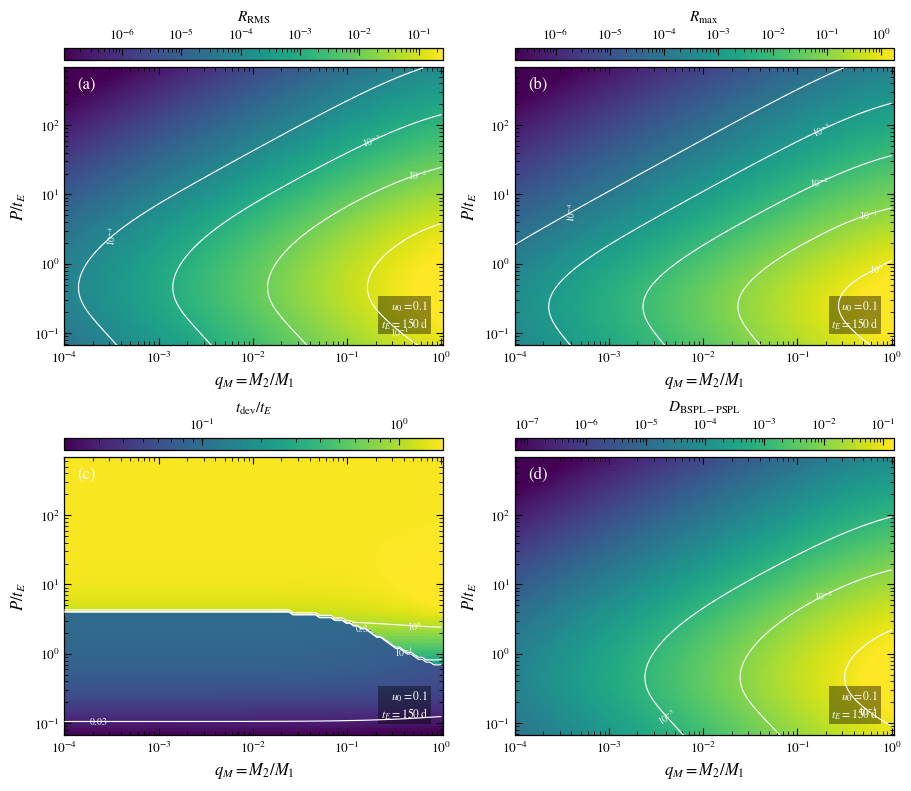

In [40]:
# ============================================================
# MASS-RATIO SCAN: PAPER FIGURE
#
# x-axis:
#       q_M = M2 / M1
#
# y-axis:
#       P / t_E
#
# Panels:
#       (a) R_RMS
#       (b) R_max
#       (c) t_dev / t_E
#       (d) D_BSPL-PSPL
#
# Physical setup:
#       M1 + M2 = constant
#       q_flux = 0
#       u0 fixed
#       tE fixed
#
# The script reads:
#
#   ~/binary_source/results/
#       scan_q_Mtotfixed_tE150/
#           scan_kepler_q_000.npz
#           scan_kepler_q_001.npz
#           ...
#
# ============================================================


import os
import glob
import re

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


# ============================================================
# PAPER STYLE
# ============================================================

plt.rcParams.update({

    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",

    "font.size": 10,

    "axes.labelsize": 12,
    "axes.titlesize": 11,

    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,

    "axes.linewidth": 0.9,

    "xtick.direction": "in",
    "ytick.direction": "in",

    "xtick.top": True,
    "ytick.right": True,

    "xtick.major.size": 5,
    "ytick.major.size": 5,

    "xtick.minor.size": 3,
    "ytick.minor.size": 3,

    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,

    "savefig.dpi": 300,
})


# ============================================================
# USER PARAMETERS
# ============================================================

tE_plot = 150.0


# ============================================================
# AUTOMATIC HOME
# ============================================================

home_path = os.path.expanduser("~")


# ============================================================
# INPUT DIRECTORY
# ============================================================

directory = os.path.join(
    home_path,
    "binary_source",
    "results",
    f"scan_q_Mtotfixed_tE{int(tE_plot)}",
)


# ============================================================
# OUTPUT DIRECTORY
# ============================================================

output_directory = os.path.join(
    directory,
    "figures",
)

os.makedirs(
    output_directory,
    exist_ok=True,
)


# ============================================================
# MASK CENSORED t_dev?
# ============================================================

MASK_TDEV_CENSORED = True


# ============================================================
# AXIS LIMITS
#
# Set to None to use the complete calculated range.
# ============================================================

QMIN = None
QMAX = None

YMIN = None
YMAX = None


# ============================================================
# OPTIONAL FIXED COLOR LIMITS
#
# None -> calculate automatically from the data.
# ============================================================

RMS_VMIN = None
RMS_VMAX = None

RMAX_VMIN = None
RMAX_VMAX = None

TDEV_VMIN = None
TDEV_VMAX = None

D_VMIN = None
D_VMAX = None


# ============================================================
# REFERENCE CONTOURS
#
# These are NOT detection thresholds.
# ============================================================

RMS_CONTOURS = [
    1e-4,
    1e-3,
    1e-2,
    1e-1,
]

RMAX_CONTOURS = [
    1e-4,
    1e-3,
    1e-2,
    1e-1,
    1e0,
]

TDEV_CONTOURS = [
    0.01,
    0.03,
    0.1,
    0.3,
    1.0,
]

D_CONTOURS = [
    1e-3,
    1e-2,
    1e-1,
]


# ============================================================
# FIGURE SIZE
# ============================================================

FIGSIZE = (
    9.0,
    7.8,
)


# ============================================================
# HELPERS
# ============================================================

def extract_q_index(filename):

    base = os.path.basename(
        filename
    )

    match = re.fullmatch(
        r"scan_kepler_q_(\d+)\.npz",
        base,
    )

    if match is None:

        raise ValueError(
            f"No pude extraer el índice de:\n{base}"
        )

    return int(
        match.group(1)
    )


def log_bin_edges(x):

    x = np.asarray(
        x,
        dtype=float,
    )

    if len(x) < 2:

        raise ValueError(
            "Se necesitan al menos dos puntos."
        )

    if np.any(
        x <= 0
    ):

        raise ValueError(
            "Todos los valores deben ser positivos."
        )

    logx = np.log10(
        x
    )

    edges = np.empty(
        len(x) + 1,
        dtype=float,
    )

    edges[1:-1] = (
        0.5
        *
        (
            logx[:-1]
            +
            logx[1:]
        )
    )

    edges[0] = (
        logx[0]
        -
        0.5
        *
        (
            logx[1]
            -
            logx[0]
        )
    )

    edges[-1] = (
        logx[-1]
        +
        0.5
        *
        (
            logx[-1]
            -
            logx[-2]
        )
    )

    return 10**edges


# ============================================================
# D METRIC
#
# Used only if D is not already stored in the NPZ.
# ============================================================

def compute_D_from_curves(
    t,
    A_truth,
    A_fit,
):

    t = np.asarray(
        t,
        dtype=float,
    )

    A_truth = np.asarray(
        A_truth,
        dtype=float,
    )

    A_fit = np.asarray(
        A_fit,
        dtype=float,
    )


    valid = (
        np.isfinite(t)
        &
        np.isfinite(A_truth)
        &
        np.isfinite(A_fit)
    )


    if np.count_nonzero(
        valid
    ) < 2:

        return np.nan


    tv = t[
        valid
    ]

    At = A_truth[
        valid
    ]

    Af = A_fit[
        valid
    ]


    idx = np.argsort(
        tv
    )

    tv = tv[
        idx
    ]

    At = At[
        idx
    ]

    Af = Af[
        idx
    ]


    residual = (
        At
        -
        Af
    )

    signal = (
        At
        -
        1.0
    )


    # --------------------------------------------------------
    # np.trapezoid for recent NumPy,
    # np.trapz fallback for older versions
    # --------------------------------------------------------

    if hasattr(
        np,
        "trapezoid",
    ):

        numerator = np.trapezoid(
            residual**2,
            x=tv,
        )

        denominator = np.trapezoid(
            signal**2,
            x=tv,
        )

    else:

        numerator = np.trapz(
            residual**2,
            x=tv,
        )

        denominator = np.trapz(
            signal**2,
            x=tv,
        )


    if (
        not np.isfinite(
            numerator
        )
        or
        not np.isfinite(
            denominator
        )
        or
        denominator <= 0
    ):

        return np.nan


    return float(
        np.sqrt(
            numerator
            /
            denominator
        )
    )


# ============================================================
# AUTOMATIC LOG COLOR LIMITS
# ============================================================

def automatic_lognorm(
    data,
    vmin=None,
    vmax=None,
):

    data = np.asarray(
        data,
        dtype=float,
    )

    valid = (
        np.isfinite(
            data
        )
        &
        (
            data > 0
        )
    )


    if not np.any(
        valid
    ):

        raise ValueError(
            "No hay valores positivos para construir LogNorm."
        )


    values = data[
        valid
    ]


    # --------------------------------------------------------
    # Avoid one isolated extreme value setting the scale.
    # --------------------------------------------------------

    if vmin is None:

        vmin = np.nanpercentile(
            values,
            1.0,
        )


    if vmax is None:

        vmax = np.nanpercentile(
            values,
            99.0,
        )


    # --------------------------------------------------------
    # Safety
    # --------------------------------------------------------

    if (
        not np.isfinite(vmin)
        or
        vmin <= 0
    ):

        vmin = np.nanmin(
            values
        )


    if (
        not np.isfinite(vmax)
        or
        vmax <= vmin
    ):

        vmax = np.nanmax(
            values
        )


    return mcolors.LogNorm(
        vmin=vmin,
        vmax=vmax,
    )


# ============================================================
# AVAILABLE CONTOUR LEVELS
# ============================================================

def available_levels(
    data,
    requested_levels,
):

    valid = (
        np.isfinite(
            data
        )
        &
        (
            data > 0
        )
    )


    if not np.any(
        valid
    ):

        return []


    dmin = np.nanmin(
        data[
            valid
        ]
    )

    dmax = np.nanmax(
        data[
            valid
        ]
    )


    return [
        level
        for level in requested_levels
        if (
            dmin
            <= level
            <= dmax
        )
    ]


# ============================================================
# CONTOUR LABEL FORMAT
# ============================================================

def contour_label(
    value,
):

    value = float(
        value
    )


    if value <= 0:

        return ""


    exponent = np.log10(
        value
    )


    if np.isclose(
        exponent,
        np.round(
            exponent
        ),
        atol=1e-8,
    ):

        exponent = int(
            np.round(
                exponent
            )
        )

        return rf"$10^{{{exponent}}}$"


    return rf"${value:g}$"


# ============================================================
# FIND FILES
# ============================================================

pattern = os.path.join(
    directory,
    "scan_kepler_q_*.npz",
)

files = sorted(
    glob.glob(
        pattern
    )
)


if len(files) == 0:

    raise FileNotFoundError(
        f"No encontré archivos con patrón:\n{pattern}"
    )


print()

print("=" * 80)

print(
    f"Found {len(files)} mass-ratio files"
)

print(
    directory
)

print("=" * 80)


# ============================================================
# FIRST PASS
#
# Recover q from M2/M1 and check common P grid.
# ============================================================

records = []

P_grid_reference = None

tE_reference = None
u0_reference = None
Mtot_reference = None


for filename in files:

    with np.load(
        filename,
        allow_pickle=False,
    ) as d:

        truth = d[
            "truth"
        ].astype(float)

        P_grid = d[
            "P_grid"
        ].astype(float)


    # --------------------------------------------------------
    # truth structure:
    #
    # [0] t0
    # [1] u0
    # [2] tE
    # [3] phi
    # [4] i
    # [5] M1
    # [6] M2
    # [7] rEhat
    # ...
    # --------------------------------------------------------

    u0_true = float(
        truth[1]
    )

    tE_true = float(
        truth[2]
    )

    M1_true = float(
        truth[5]
    )

    M2_true = float(
        truth[6]
    )

    q_true = float(
        M2_true
        /
        M1_true
    )

    Mtot_true = float(
        M1_true
        +
        M2_true
    )


    # --------------------------------------------------------
    # Check common period grid
    # --------------------------------------------------------

    if P_grid_reference is None:

        P_grid_reference = (
            P_grid.copy()
        )

    else:

        if (
            len(P_grid)
            !=
            len(P_grid_reference)
            or
            not np.allclose(
                P_grid,
                P_grid_reference,
            )
        ):

            raise ValueError(
                f"P_grid no coincide en:\n{filename}"
            )


    # --------------------------------------------------------
    # Reference physical quantities
    # --------------------------------------------------------

    if tE_reference is None:

        tE_reference = (
            tE_true
        )

        u0_reference = (
            u0_true
        )

        Mtot_reference = (
            Mtot_true
        )


    # --------------------------------------------------------
    # Save metadata
    # --------------------------------------------------------

    records.append(
        {
            "filename":
                filename,

            "index":
                extract_q_index(
                    filename
                ),

            "q":
                q_true,

            "M1":
                M1_true,

            "M2":
                M2_true,

            "Mtot":
                Mtot_true,

            "tE":
                tE_true,

            "u0":
                u0_true,
        }
    )


# ============================================================
# SORT BY PHYSICAL q
# ============================================================

records = sorted(
    records,
    key=lambda x:
        x["q"],
)


q_grid = np.array(
    [
        rec[
            "q"
        ]
        for rec in records
    ],
    dtype=float,
)


P_grid = np.asarray(
    P_grid_reference,
    dtype=float,
)


P_over_tE = (
    P_grid
    /
    tE_reference
)


Nq = len(
    q_grid
)

NP = len(
    P_grid
)


# ============================================================
# INITIALIZE MAPS
# ============================================================

RMS_map = np.full(
    (
        Nq,
        NP,
    ),
    np.nan,
    dtype=float,
)

RMAX_map = np.full(
    (
        Nq,
        NP,
    ),
    np.nan,
    dtype=float,
)

TDEV_map = np.full(
    (
        Nq,
        NP,
    ),
    np.nan,
    dtype=float,
)

D_map = np.full(
    (
        Nq,
        NP,
    ),
    np.nan,
    dtype=float,
)


# ============================================================
# SECOND PASS
#
# Fill maps.
# ============================================================

D_loaded = 0
D_reconstructed = 0


for iq, rec in enumerate(
    records
):

    filename = rec[
        "filename"
    ]


    with np.load(
        filename,
        allow_pickle=False,
    ) as d:

        SUCCESS = d[
            "SUCCESS"
        ].astype(bool)


        # ====================================================
        # RMS
        # ====================================================

        if "RMS" not in d.files:

            raise KeyError(
                f"{filename} does not contain RMS"
            )


        RMS = d[
            "RMS"
        ].astype(float)


        # ====================================================
        # RMAX
        # ====================================================

        if "MAXABS" not in d.files:

            raise KeyError(
                f"{filename} does not contain MAXABS"
            )


        RMAX = d[
            "MAXABS"
        ].astype(float)


        # ====================================================
        # TDEV
        # ====================================================

        if "TDEV" in d.files:

            TDEV = d[
                "TDEV"
            ].astype(float)

        elif "TFWHM" in d.files:

            TDEV = d[
                "TFWHM"
            ].astype(float)

        else:

            TDEV = np.full(
                NP,
                np.nan,
                dtype=float,
            )


        # ====================================================
        # CENSORED FLAG
        # ====================================================

        if "TDEV_CENSORED" in d.files:

            TDEV_CENSORED = d[
                "TDEV_CENSORED"
            ].astype(bool)

        else:

            TDEV_CENSORED = np.zeros(
                NP,
                dtype=bool,
            )


        # ====================================================
        # D
        # ====================================================

        if "D" in d.files:

            D = d[
                "D"
            ].astype(float)

            D_loaded += 1


        # ----------------------------------------------------
        # Reconstruct D from complete curves if needed
        # ----------------------------------------------------

        elif (
            "A_truth_grid" in d.files
            and
            "A_fit_grid" in d.files
            and
            "t" in d.files
        ):

            time = d[
                "t"
            ].astype(float)

            A_truth_grid = d[
                "A_truth_grid"
            ].astype(float)

            A_fit_grid = d[
                "A_fit_grid"
            ].astype(float)


            D = np.full(
                NP,
                np.nan,
                dtype=float,
            )


            for j in range(
                NP
            ):

                if not SUCCESS[
                    j
                ]:

                    continue


                D[j] = compute_D_from_curves(

                    time,

                    A_truth_grid[
                        j
                    ],

                    A_fit_grid[
                        j
                    ],
                )


            D_reconstructed += 1


        else:

            D = np.full(
                NP,
                np.nan,
                dtype=float,
            )


    # ========================================================
    # VALID RMS
    # ========================================================

    valid = (
        SUCCESS
        &
        np.isfinite(
            RMS
        )
        &
        (
            RMS > 0
        )
    )


    RMS_map[
        iq,
        valid,
    ] = RMS[
        valid
    ]


    # ========================================================
    # VALID RMAX
    # ========================================================

    valid = (
        SUCCESS
        &
        np.isfinite(
            RMAX
        )
        &
        (
            RMAX > 0
        )
    )


    RMAX_map[
        iq,
        valid,
    ] = RMAX[
        valid
    ]


    # ========================================================
    # VALID TDEV
    # ========================================================

    valid = (
        SUCCESS
        &
        np.isfinite(
            TDEV
        )
        &
        (
            TDEV > 0
        )
    )


    if MASK_TDEV_CENSORED:

        valid &= (
            ~TDEV_CENSORED
        )


    TDEV_map[
        iq,
        valid,
    ] = TDEV[
        valid
    ]


    # ========================================================
    # VALID D
    # ========================================================

    valid = (
        SUCCESS
        &
        np.isfinite(
            D
        )
        &
        (
            D > 0
        )
    )


    D_map[
        iq,
        valid,
    ] = D[
        valid
    ]


# ============================================================
# NORMALIZE TDEV
# ============================================================

TDEV_over_tE = (
    TDEV_map
    /
    tE_reference
)


# ============================================================
# BASIC INFORMATION
# ============================================================

print()

print(
    f"tE   = {tE_reference:g} d"
)

print(
    f"u0   = {u0_reference:g}"
)

print(
    f"Mtot = {Mtot_reference:g} Msun"
)

print(
    f"q range = "
    f"[{q_grid.min():.3e}, "
    f"{q_grid.max():.3e}]"
)

print(
    f"P/tE range = "
    f"[{P_over_tE.min():.3e}, "
    f"{P_over_tE.max():.3e}]"
)

print()

print(
    f"D loaded directly from NPZ : "
    f"{D_loaded} files"
)

print(
    f"D reconstructed from curves: "
    f"{D_reconstructed} files"
)


# ============================================================
# PRINT METRIC RANGES
# ============================================================

for name, data in [

    (
        "RMS",
        RMS_map,
    ),

    (
        "RMAX",
        RMAX_map,
    ),

    (
        "TDEV/tE",
        TDEV_over_tE,
    ),

    (
        "D",
        D_map,
    ),

]:

    valid = (
        np.isfinite(
            data
        )
        &
        (
            data > 0
        )
    )


    if np.any(
        valid
    ):

        print(

            f"{name:10s}: "
            f"["
            f"{np.nanmin(data[valid]):.3e}, "
            f"{np.nanmax(data[valid]):.3e}"
            f"]"
        )


# ============================================================
# BIN EDGES
# ============================================================

q_edges = log_bin_edges(
    q_grid
)

P_edges = log_bin_edges(
    P_over_tE
)


# ============================================================
# NORMALIZATIONS
# ============================================================

norm_RMS = automatic_lognorm(
    RMS_map,
    vmin=RMS_VMIN,
    vmax=RMS_VMAX,
)

norm_RMAX = automatic_lognorm(
    RMAX_map,
    vmin=RMAX_VMIN,
    vmax=RMAX_VMAX,
)

norm_TDEV = automatic_lognorm(
    TDEV_over_tE,
    vmin=TDEV_VMIN,
    vmax=TDEV_VMAX,
)

norm_D = automatic_lognorm(
    D_map,
    vmin=D_VMIN,
    vmax=D_VMAX,
)


# ============================================================
# PANEL CONFIGURATION
# ============================================================

metric_specs = [

    {
        "data":
            RMS_map,

        "label":
            r"$R_{\rm RMS}$",

        "norm":
            norm_RMS,

        "contours":
            RMS_CONTOURS,

        "panel":
            "(a)",
    },

    {
        "data":
            RMAX_map,

        "label":
            r"$R_{\rm max}$",

        "norm":
            norm_RMAX,

        "contours":
            RMAX_CONTOURS,

        "panel":
            "(b)",
    },

    {
        "data":
            TDEV_over_tE,

        "label":
            r"$t_{\rm dev}/t_E$",

        "norm":
            norm_TDEV,

        "contours":
            TDEV_CONTOURS,

        "panel":
            "(c)",
    },

    {
        "data":
            D_map,

        "label":
            r"$D_{\rm BSPL-PSPL}$",

        "norm":
            norm_D,

        "contours":
            D_CONTOURS,

        "panel":
            "(d)",
    },
]


# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(

    2,
    2,

    figsize=FIGSIZE,

    constrained_layout=True,
)


axes = axes.ravel()


# ============================================================
# LOOP OVER PANELS
# ============================================================

for ax, spec in zip(
    axes,
    metric_specs,
):

    data = spec[
        "data"
    ]


    # ========================================================
    # HEATMAP
    # ========================================================

    pcm = ax.pcolormesh(

        q_edges,

        P_edges,

        np.ma.masked_invalid(
            data
        ).T,

        cmap="viridis",

        norm=spec[
            "norm"
        ],

        shading="auto",

        rasterized=True,

        edgecolors="none",

        linewidth=0,
    )


    # ========================================================
    # REFERENCE CONTOURS
    # ========================================================

    levels = available_levels(

        data,

        spec[
            "contours"
        ],
    )


    if len(
        levels
    ) > 0:

        cs = ax.contour(

            q_grid,

            P_over_tE,

            np.ma.masked_invalid(
                data.T
            ),

            levels=levels,

            colors="white",

            linewidths=0.85,

            zorder=5,
        )


        ax.clabel(

            cs,

            fmt=lambda value:
                contour_label(
                    value
                ),

            fontsize=7,

            colors="white",

            inline=False,
        )


    # ========================================================
    # AXES
    # ========================================================

    ax.set_xscale(
        "log"
    )

    ax.set_yscale(
        "log"
    )


    if QMIN is not None:

        ax.set_xlim(
            left=QMIN
        )


    if QMAX is not None:

        ax.set_xlim(
            right=QMAX
        )


    if YMIN is not None:

        ax.set_ylim(
            bottom=YMIN
        )


    if YMAX is not None:

        ax.set_ylim(
            top=YMAX
        )


    ax.set_xlabel(
        r"$q_M=M_2/M_1$"
    )

    ax.set_ylabel(
        r"$P/t_E$"
    )


    ax.grid(
        False
    )


    # ========================================================
    # PANEL LABEL
    # ========================================================

    ax.text(

        0.035,
        0.965,

        spec[
            "panel"
        ],

        transform=ax.transAxes,

        ha="left",

        va="top",

        fontsize=12,

        color="white",
    )


    # ========================================================
    # FIXED-PARAMETER LABEL
    # ========================================================

    ax.text(

        0.96,
        0.05,

        (
            rf"$u_0={u0_reference:g}$"
            "\n"
            rf"$t_E={tE_reference:g}\,\mathrm{{d}}$"
        ),

        transform=ax.transAxes,

        ha="right",

        va="bottom",

        fontsize=8.5,

        color="white",

        bbox=dict(

            facecolor="black",

            edgecolor="none",

            alpha=0.40,

            pad=2.0,
        ),
    )


    # ========================================================
    # COLORBAR
    # ========================================================

    cbar = fig.colorbar(

        pcm,

        ax=ax,

        orientation="horizontal",

        location="top",

        pad=0.025,

        fraction=0.055,

        aspect=32,
    )


    cbar.set_label(

        spec[
            "label"
        ],

        fontsize=11,

        labelpad=4,
    )


    cbar.ax.xaxis.set_ticks_position(
        "top"
    )

    cbar.ax.xaxis.set_label_position(
        "top"
    )


# ============================================================
# SAVE
# ============================================================

output_png = os.path.join(
    output_directory,
    f"mass_ratio_metrics_tE{int(tE_reference)}.png",
)

output_pdf = os.path.join(
    output_directory,
    f"mass_ratio_metrics_tE{int(tE_reference)}.pdf",
)


fig.savefig(

    output_png,

    dpi=300,

    bbox_inches="tight",
)


fig.savefig(

    output_pdf,

    bbox_inches="tight",
)


print()

print("=" * 80)

print(
    "Figure saved:"
)

print(
    output_png
)

print(
    output_pdf
)

print("=" * 80)


plt.show()


Found 100 files
/home/anibal-pc/binary_source/results/scan_q_Mtotfixed_tE150

tE = 150 d
u0 = 0.1
q range = [1.000e-04, 1.000e+00]
RMS   : [2.572e-08, 3.643e-01]
RMAX  : [4.243e-08, 2.587e+00]
D     : [1.511e-08, 2.098e-01]

Saved:
/home/anibal-pc/binary_source/results/scan_q_Mtotfixed_tE150/figures/q_scan_D_RMS_Rmax_maps.pdf

GLOBAL LOG-SPACE CORRELATIONS
D vs RMS : Spearman rho = 1.00000, p = 0.000e+00
D vs Rmax: Spearman rho = 0.98837, p = 0.000e+00

Saved:
/home/anibal-pc/binary_source/results/scan_q_Mtotfixed_tE150/figures/q_scan_D_vs_RMS_Rmax_scatter.pdf

Saved:
/home/anibal-pc/binary_source/results/scan_q_Mtotfixed_tE150/figures/q_scan_D_normalization.pdf


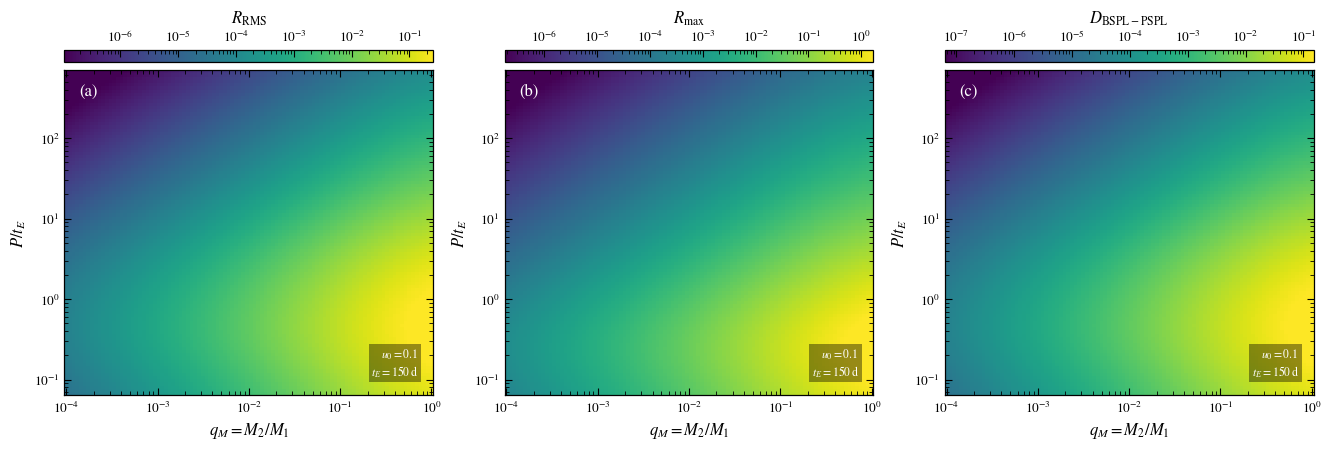

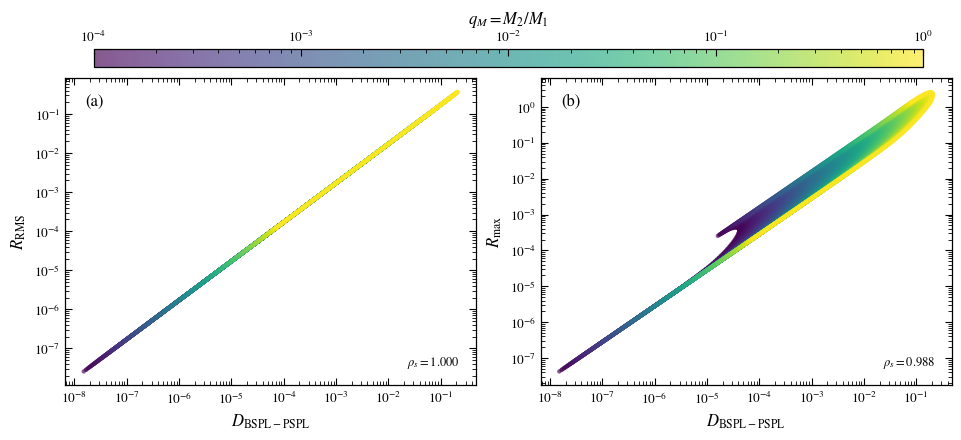

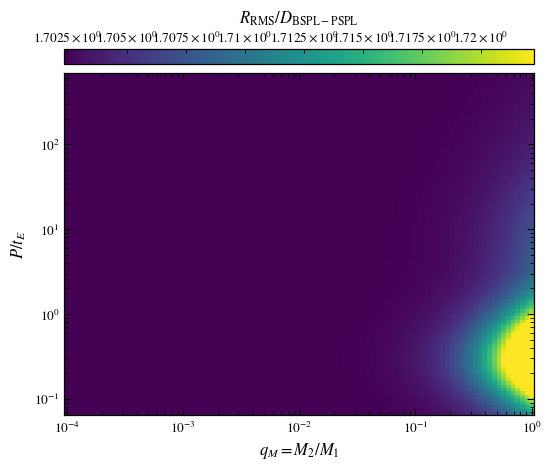

In [41]:
# ============================================================
# COMPARISON:
#
#       D_BSPL-PSPL
#       R_RMS
#       R_max
#
# for the fixed-total-mass mass-ratio scan.
#
#
# FIGURE 1:
#
#   Three heatmaps in:
#
#           (q_M, P/t_E)
#
#       (a) R_RMS
#       (b) R_max
#       (c) D
#
#
# FIGURE 2:
#
#   Direct metric comparison:
#
#       (a) D vs R_RMS
#       (b) D vs R_max
#
#   Points are colored by q_M.
#
#
# FIGURE 3:
#
#   Effective normalization:
#
#           S_eff = R_RMS / D
#
#   For uniform sampling this is approximately:
#
#           S_eff ~ RMS(A_BSPL - 1)
#
#   so it shows WHY D can differ from the absolute RMS.
#
# ============================================================


import os
import glob

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from scipy.stats import spearmanr


# ============================================================
# PAPER STYLE
# ============================================================

plt.rcParams.update({

    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",

    "font.size": 10,

    "axes.labelsize": 12,
    "axes.titlesize": 11,

    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,

    "axes.linewidth": 0.9,

    "xtick.direction": "in",
    "ytick.direction": "in",

    "xtick.top": True,
    "ytick.right": True,

    "xtick.major.size": 5,
    "ytick.major.size": 5,

    "xtick.minor.size": 3,
    "ytick.minor.size": 3,

    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,

    "savefig.dpi": 300,
})


# ============================================================
# USER CONFIGURATION
# ============================================================

tE_plot = 150.0


# ============================================================
# AUTOMATIC HOME
# ============================================================

home_path = os.path.expanduser("~")


# ============================================================
# INPUT DIRECTORY
# ============================================================

directory = os.path.join(

    home_path,

    "binary_source",

    "results",

    f"scan_q_Mtotfixed_tE{int(tE_plot)}",
)


# ============================================================
# OUTPUT DIRECTORY
# ============================================================

output_directory = os.path.join(
    directory,
    "figures",
)

os.makedirs(
    output_directory,
    exist_ok=True,
)


# ============================================================
# FIND FILES
# ============================================================

pattern = os.path.join(
    directory,
    "scan_kepler_q_*.npz",
)

files = sorted(
    glob.glob(
        pattern
    )
)


if len(files) == 0:

    raise FileNotFoundError(

        "No encontré archivos para el barrido en q.\n\n"
        f"Busqué:\n{pattern}"
    )


print()

print("=" * 80)

print(
    f"Found {len(files)} files"
)

print(
    directory
)

print("=" * 80)


# ============================================================
# HELPERS
# ============================================================

def log_bin_edges(x):

    x = np.asarray(
        x,
        dtype=float,
    )

    lx = np.log10(
        x
    )

    edges = np.empty(
        len(x) + 1
    )

    edges[1:-1] = (
        0.5
        *
        (
            lx[:-1]
            +
            lx[1:]
        )
    )

    edges[0] = (
        lx[0]
        -
        0.5
        *
        (
            lx[1]
            -
            lx[0]
        )
    )

    edges[-1] = (
        lx[-1]
        +
        0.5
        *
        (
            lx[-1]
            -
            lx[-2]
        )
    )

    return 10**edges


def automatic_lognorm(
    data,
    pmin=1,
    pmax=99,
):

    valid = (
        np.isfinite(
            data
        )
        &
        (
            data > 0
        )
    )

    values = data[
        valid
    ]


    if len(values) == 0:

        raise ValueError(
            "No positive finite data."
        )


    vmin = np.nanpercentile(
        values,
        pmin,
    )

    vmax = np.nanpercentile(
        values,
        pmax,
    )


    if vmin <= 0:

        vmin = np.nanmin(
            values
        )


    if vmax <= vmin:

        vmax = np.nanmax(
            values
        )


    return mcolors.LogNorm(
        vmin=vmin,
        vmax=vmax,
    )


# ============================================================
# FIRST PASS
#
# Extract q and common P grid
# ============================================================

records = []

P_reference = None


for filename in files:

    with np.load(
        filename,
        allow_pickle=False,
    ) as d:

        truth = d[
            "truth"
        ].astype(float)

        P_grid = d[
            "P_grid"
        ].astype(float)


    # --------------------------------------------------------
    # truth:
    #
    # [1] u0
    # [2] tE
    # [5] M1
    # [6] M2
    # --------------------------------------------------------

    u0_true = float(
        truth[1]
    )

    tE_true = float(
        truth[2]
    )

    M1 = float(
        truth[5]
    )

    M2 = float(
        truth[6]
    )


    q_true = (
        M2
        /
        M1
    )


    if P_reference is None:

        P_reference = (
            P_grid.copy()
        )

    else:

        if not np.allclose(
            P_grid,
            P_reference,
        ):

            raise ValueError(
                f"Inconsistent P_grid:\n{filename}"
            )


    records.append(
        {
            "file":
                filename,

            "q":
                q_true,

            "M1":
                M1,

            "M2":
                M2,

            "u0":
                u0_true,

            "tE":
                tE_true,
        }
    )


# ============================================================
# SORT BY q
# ============================================================

records = sorted(
    records,
    key=lambda r:
        r["q"],
)


q_grid = np.array(
    [
        r["q"]
        for r in records
    ],
    dtype=float,
)


P_grid = np.asarray(
    P_reference,
    dtype=float,
)


tE_reference = records[
    0
][
    "tE"
]

u0_reference = records[
    0
][
    "u0"
]


P_over_tE = (
    P_grid
    /
    tE_reference
)


Nq = len(
    q_grid
)

NP = len(
    P_grid
)


# ============================================================
# INITIALIZE MAPS
# ============================================================

RMS_map = np.full(
    (
        Nq,
        NP,
    ),
    np.nan,
)

RMAX_map = np.full(
    (
        Nq,
        NP,
    ),
    np.nan,
)

D_map = np.full(
    (
        Nq,
        NP,
    ),
    np.nan,
)


# ============================================================
# LOAD METRICS
# ============================================================

for iq, rec in enumerate(
    records
):

    filename = rec[
        "file"
    ]


    with np.load(
        filename,
        allow_pickle=False,
    ) as d:


        SUCCESS = d[
            "SUCCESS"
        ].astype(bool)


        if "RMS" not in d.files:

            raise KeyError(
                f"RMS missing in:\n{filename}"
            )


        if "MAXABS" not in d.files:

            raise KeyError(
                f"MAXABS missing in:\n{filename}"
            )


        if "D" not in d.files:

            raise KeyError(

                f"D missing in:\n{filename}\n\n"
                "Run the version of degeneracy_fit that stores D."
            )


        RMS = d[
            "RMS"
        ].astype(float)


        RMAX = d[
            "MAXABS"
        ].astype(float)


        D = d[
            "D"
        ].astype(float)


    # ========================================================
    # VALID VALUES
    # ========================================================

    valid_RMS = (
        SUCCESS
        &
        np.isfinite(
            RMS
        )
        &
        (
            RMS > 0
        )
    )


    valid_RMAX = (
        SUCCESS
        &
        np.isfinite(
            RMAX
        )
        &
        (
            RMAX > 0
        )
    )


    valid_D = (
        SUCCESS
        &
        np.isfinite(
            D
        )
        &
        (
            D > 0
        )
    )


    RMS_map[
        iq,
        valid_RMS,
    ] = RMS[
        valid_RMS
    ]


    RMAX_map[
        iq,
        valid_RMAX,
    ] = RMAX[
        valid_RMAX
    ]


    D_map[
        iq,
        valid_D,
    ] = D[
        valid_D
    ]


# ============================================================
# PRINT RANGES
# ============================================================

print()

print(
    f"tE = {tE_reference:g} d"
)

print(
    f"u0 = {u0_reference:g}"
)

print(
    f"q range = "
    f"[{q_grid.min():.3e}, "
    f"{q_grid.max():.3e}]"
)


for name, data in [

    (
        "RMS",
        RMS_map,
    ),

    (
        "RMAX",
        RMAX_map,
    ),

    (
        "D",
        D_map,
    ),

]:

    valid = (
        np.isfinite(
            data
        )
        &
        (
            data > 0
        )
    )


    print(

        f"{name:6s}: "
        f"["
        f"{np.nanmin(data[valid]):.3e}, "
        f"{np.nanmax(data[valid]):.3e}"
        f"]"
    )


# ============================================================
# GRID EDGES
# ============================================================

q_edges = log_bin_edges(
    q_grid
)

P_edges = log_bin_edges(
    P_over_tE
)


# ============================================================
# COLOR NORMALIZATIONS
# ============================================================

norm_RMS = automatic_lognorm(
    RMS_map
)

norm_RMAX = automatic_lognorm(
    RMAX_map
)

norm_D = automatic_lognorm(
    D_map
)


# ============================================================
#
# FIGURE 1
#
# THREE MAPS
#
# ============================================================

fig1, axes = plt.subplots(

    1,
    3,

    figsize=(
        13.2,
        4.4,
    ),

    constrained_layout=True,
)


specs = [

    (
        RMS_map,
        norm_RMS,
        r"$R_{\rm RMS}$",
        "(a)",
    ),

    (
        RMAX_map,
        norm_RMAX,
        r"$R_{\rm max}$",
        "(b)",
    ),

    (
        D_map,
        norm_D,
        r"$D_{\rm BSPL-PSPL}$",
        "(c)",
    ),
]


for ax, (
    data,
    norm,
    label,
    panel,
) in zip(
    axes,
    specs,
):


    pcm = ax.pcolormesh(

        q_edges,

        P_edges,

        np.ma.masked_invalid(
            data
        ).T,

        cmap="viridis",

        norm=norm,

        shading="auto",

        rasterized=True,
    )


    ax.set_xscale(
        "log"
    )

    ax.set_yscale(
        "log"
    )


    ax.set_xlabel(
        r"$q_M=M_2/M_1$"
    )


    ax.set_ylabel(
        r"$P/t_E$"
    )


    ax.text(

        0.04,
        0.96,

        panel,

        transform=ax.transAxes,

        ha="left",

        va="top",

        fontsize=12,

        color="white",
    )


    ax.text(

        0.96,
        0.05,

        (
            rf"$u_0={u0_reference:g}$"
            "\n"
            rf"$t_E={tE_reference:g}\,\mathrm{{d}}$"
        ),

        transform=ax.transAxes,

        ha="right",

        va="bottom",

        fontsize=8.5,

        color="white",

        bbox=dict(
            facecolor="black",
            edgecolor="none",
            alpha=0.4,
            pad=2,
        ),
    )


    cbar = fig1.colorbar(

        pcm,

        ax=ax,

        orientation="horizontal",

        location="top",

        pad=0.025,

        fraction=0.055,

        aspect=30,
    )


    cbar.set_label(
        label
    )


    cbar.ax.xaxis.set_ticks_position(
        "top"
    )

    cbar.ax.xaxis.set_label_position(
        "top"
    )


output = os.path.join(
    output_directory,
    "q_scan_D_RMS_Rmax_maps.pdf",
)

fig1.savefig(
    output,
    bbox_inches="tight",
)

print(
    f"\nSaved:\n{output}"
)


# ============================================================
#
# PREPARE FLATTENED DATA
#
# ============================================================

Q2D, P2D = np.meshgrid(
    q_grid,
    P_over_tE,
    indexing="ij",
)


valid_all = (

    np.isfinite(
        RMS_map
    )

    &

    np.isfinite(
        RMAX_map
    )

    &

    np.isfinite(
        D_map
    )

    &

    (
        RMS_map > 0
    )

    &

    (
        RMAX_map > 0
    )

    &

    (
        D_map > 0
    )
)


RMS_flat = RMS_map[
    valid_all
]

RMAX_flat = RMAX_map[
    valid_all
]

D_flat = D_map[
    valid_all
]

q_flat = Q2D[
    valid_all
]

p_flat = P2D[
    valid_all
]


# ============================================================
# SPEARMAN CORRELATIONS
# ============================================================

rho_RMS, pval_RMS = spearmanr(

    np.log10(
        D_flat
    ),

    np.log10(
        RMS_flat
    ),
)


rho_RMAX, pval_RMAX = spearmanr(

    np.log10(
        D_flat
    ),

    np.log10(
        RMAX_flat
    ),
)


print()

print("=" * 80)

print(
    "GLOBAL LOG-SPACE CORRELATIONS"
)

print("=" * 80)

print(

    f"D vs RMS : "
    f"Spearman rho = {rho_RMS:.5f}, "
    f"p = {pval_RMS:.3e}"
)

print(

    f"D vs Rmax: "
    f"Spearman rho = {rho_RMAX:.5f}, "
    f"p = {pval_RMAX:.3e}"
)

print("=" * 80)


# ============================================================
#
# FIGURE 2
#
# D vs RMS
# D vs RMAX
#
# Color = q_M
#
# ============================================================

fig2, axes2 = plt.subplots(

    1,
    2,

    figsize=(
        9.5,
        4.3,
    ),

    constrained_layout=True,
)


norm_q = mcolors.LogNorm(

    vmin=np.nanmin(
        q_flat
    ),

    vmax=np.nanmax(
        q_flat
    ),
)


# ============================================================
# D vs RMS
# ============================================================

sc1 = axes2[
    0
].scatter(

    D_flat,

    RMS_flat,

    c=q_flat,

    cmap="viridis",

    norm=norm_q,

    s=10,

    alpha=0.65,

    edgecolors="none",
)


axes2[
    0
].set_xscale(
    "log"
)

axes2[
    0
].set_yscale(
    "log"
)


axes2[
    0
].set_xlabel(
    r"$D_{\rm BSPL-PSPL}$"
)

axes2[
    0
].set_ylabel(
    r"$R_{\rm RMS}$"
)


axes2[
    0
].text(

    0.05,
    0.95,

    "(a)",

    transform=axes2[0].transAxes,

    ha="left",

    va="top",

    fontsize=12,
)


axes2[
    0
].text(

    0.96,
    0.05,

    rf"$\rho_s={rho_RMS:.3f}$",

    transform=axes2[0].transAxes,

    ha="right",

    va="bottom",

    fontsize=9,
)


# ============================================================
# D vs RMAX
# ============================================================

sc2 = axes2[
    1
].scatter(

    D_flat,

    RMAX_flat,

    c=q_flat,

    cmap="viridis",

    norm=norm_q,

    s=10,

    alpha=0.65,

    edgecolors="none",
)


axes2[
    1
].set_xscale(
    "log"
)

axes2[
    1
].set_yscale(
    "log"
)


axes2[
    1
].set_xlabel(
    r"$D_{\rm BSPL-PSPL}$"
)

axes2[
    1
].set_ylabel(
    r"$R_{\rm max}$"
)


axes2[
    1
].text(

    0.05,
    0.95,

    "(b)",

    transform=axes2[1].transAxes,

    ha="left",

    va="top",

    fontsize=12,
)


axes2[
    1
].text(

    0.96,
    0.05,

    rf"$\rho_s={rho_RMAX:.3f}$",

    transform=axes2[1].transAxes,

    ha="right",

    va="bottom",

    fontsize=9,
)


# ============================================================
# COMMON COLORBAR
# ============================================================

cbar = fig2.colorbar(

    sc2,

    ax=axes2,

    orientation="horizontal",

    location="top",

    pad=0.035,

    fraction=0.06,

    aspect=45,
)


cbar.set_label(
    r"$q_M=M_2/M_1$"
)


cbar.ax.xaxis.set_ticks_position(
    "top"
)

cbar.ax.xaxis.set_label_position(
    "top"
)


output = os.path.join(
    output_directory,
    "q_scan_D_vs_RMS_Rmax_scatter.pdf",
)

fig2.savefig(
    output,
    bbox_inches="tight",
)

print(
    f"\nSaved:\n{output}"
)


# ============================================================
#
# FIGURE 3
#
# EFFECTIVE SIGNAL NORMALIZATION
#
#     S_eff = RMS / D
#
# If the sampling is uniform:
#
#     D ~ RMS(residual) / RMS(signal)
#
# therefore:
#
#     RMS / D ~ RMS(A_BSPL - 1)
#
# ============================================================

S_eff = np.full_like(
    D_map,
    np.nan,
)


valid_eff = (

    np.isfinite(
        RMS_map
    )

    &

    np.isfinite(
        D_map
    )

    &

    (
        RMS_map > 0
    )

    &

    (
        D_map > 0
    )
)


S_eff[
    valid_eff
] = (

    RMS_map[
        valid_eff
    ]

    /

    D_map[
        valid_eff
    ]
)


norm_eff = automatic_lognorm(
    S_eff
)


fig3, ax3 = plt.subplots(

    figsize=(
        5.4,
        4.6,
    ),

    constrained_layout=True,
)


pcm = ax3.pcolormesh(

    q_edges,

    P_edges,

    np.ma.masked_invalid(
        S_eff
    ).T,

    cmap="viridis",

    norm=norm_eff,

    shading="auto",

    rasterized=True,
)


ax3.set_xscale(
    "log"
)

ax3.set_yscale(
    "log"
)


ax3.set_xlabel(
    r"$q_M=M_2/M_1$"
)

ax3.set_ylabel(
    r"$P/t_E$"
)


cbar = fig3.colorbar(

    pcm,

    ax=ax3,

    orientation="horizontal",

    location="top",

    pad=0.025,

    fraction=0.055,

    aspect=30,
)


cbar.set_label(

    r"$R_{\rm RMS}/D_{\rm BSPL-PSPL}$"
)


cbar.ax.xaxis.set_ticks_position(
    "top"
)

cbar.ax.xaxis.set_label_position(
    "top"
)


output = os.path.join(
    output_directory,
    "q_scan_D_normalization.pdf",
)

fig3.savefig(
    output,
    bbox_inches="tight",
)

print(
    f"\nSaved:\n{output}"
)


plt.show()


DIRECTORIES
Mass-ratio scan:
/home/anibal-pc/binary_source/results/scan_q_Mtotfixed_tE150

u0 scan:
/home/anibal-pc/binary_source/results/scan_u0_tE150

LOADED DATA
q scan : 10000 valid grid points from 100 files
u0 scan: 10000 valid grid points from 100 files

SPEARMAN CORRELATIONS

Mass-ratio scan:
    D vs RMS  : rho = 1.00000
    D vs Rmax : rho = 0.98837

u0 scan:
    D vs RMS  : rho = 0.70600
    D vs Rmax : rho = 0.72273


FIGURE SAVED
/home/anibal-pc/binary_source/results/metric_comparison_q_vs_u0/D_RMS_Rmax_q_vs_u0_tE150.png
/home/anibal-pc/binary_source/results/metric_comparison_q_vs_u0/D_RMS_Rmax_q_vs_u0_tE150.pdf


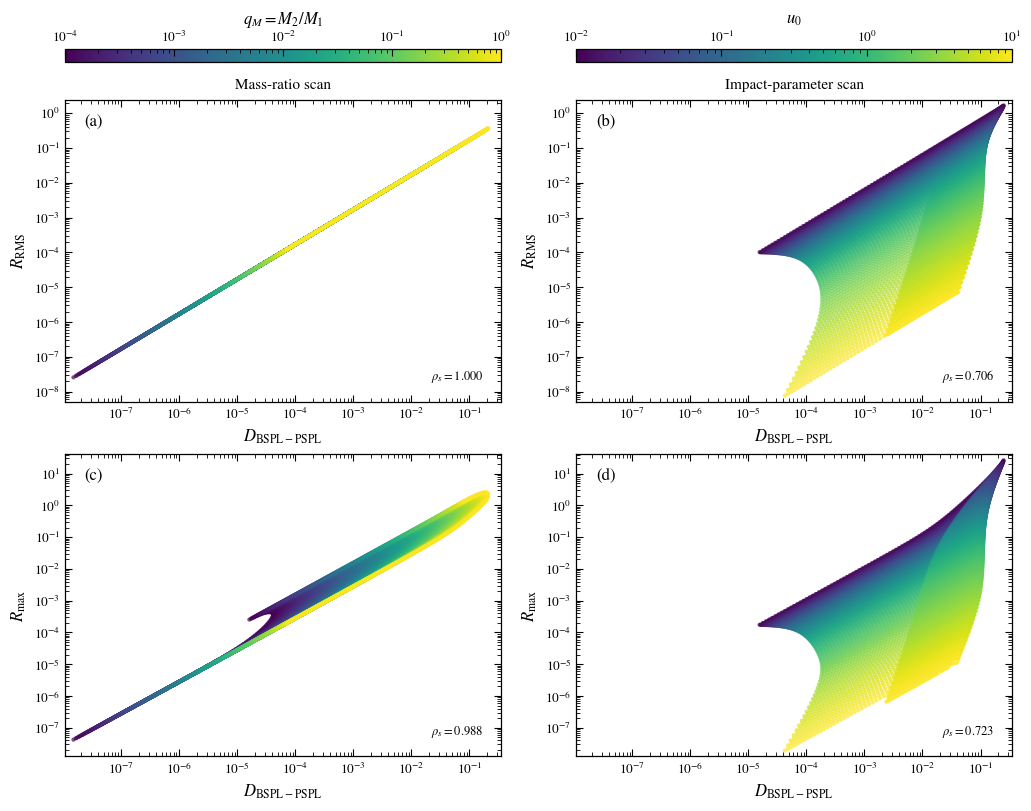

In [42]:
# ============================================================
# COMPARISON OF D WITH RMS AND RMAX
#
# MASS-RATIO SCAN vs u0 SCAN
#
#
# Layout:
#
#   (a) q_M scan : D vs RMS
#   (b) u0  scan : D vs RMS
#
#   (c) q_M scan : D vs Rmax
#   (d) u0  scan : D vs Rmax
#
#
# Color:
#
#   left column  -> q_M = M2/M1
#   right column -> u0
#
#
# All panels corresponding to the same metric use the SAME
# x- and y-limits, allowing direct visual comparison.
#
# ============================================================


import os
import glob

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from scipy.stats import spearmanr
from matplotlib.cm import ScalarMappable


# ============================================================
# PAPER STYLE
# ============================================================

plt.rcParams.update({

    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",

    "font.size": 10,

    "axes.labelsize": 12,
    "axes.titlesize": 11,

    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,

    "axes.linewidth": 0.9,

    "xtick.direction": "in",
    "ytick.direction": "in",

    "xtick.top": True,
    "ytick.right": True,

    "xtick.major.size": 5,
    "ytick.major.size": 5,

    "xtick.minor.size": 3,
    "ytick.minor.size": 3,

    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,

    "savefig.dpi": 300,
})


# ============================================================
# USER CONFIGURATION
# ============================================================

tE_plot = 150.0


# ============================================================
# AUTOMATIC HOME
# ============================================================

home_path = os.path.expanduser("~")

results_root = os.path.join(
    home_path,
    "binary_source",
    "results",
)


# ============================================================
# FIND MASS-RATIO DIRECTORY
# ============================================================

q_candidates = [

    os.path.join(
        results_root,
        f"scan_q_Mtotfixed_tE{int(tE_plot)}",
    ),

]


q_directory = None


for candidate in q_candidates:

    files_test = glob.glob(
        os.path.join(
            candidate,
            "scan_kepler_q_*.npz",
        )
    )

    if len(files_test) > 0:

        q_directory = candidate
        break


if q_directory is None:

    raise FileNotFoundError(

        "No encontré el barrido en mass ratio.\n\n"
        "Esperaba algo como:\n"
        f"{results_root}/scan_q_Mtotfixed_tE{int(tE_plot)}"
    )


# ============================================================
# FIND u0 DIRECTORY
#
# Try both directory structures that we have used.
# ============================================================

u0_candidates = [

    os.path.join(
        results_root,
        f"scan_u0_tE{int(tE_plot)}",
    ),

    os.path.join(
        results_root,
        "scan_many_tE_200x200",
        f"scan_u0_tE{int(tE_plot)}",
    ),

]


u0_directory = None


for candidate in u0_candidates:

    files_test = glob.glob(
        os.path.join(
            candidate,
            "scan_kepler_u0_*.npz",
        )
    )

    if len(files_test) > 0:

        u0_directory = candidate
        break


if u0_directory is None:

    raise FileNotFoundError(

        "No encontré el barrido en u0.\n\n"
        "Busqué en:\n"
        +
        "\n".join(
            u0_candidates
        )
    )


# ============================================================
# OUTPUT DIRECTORY
# ============================================================

output_directory = os.path.join(
    results_root,
    "metric_comparison_q_vs_u0",
)

os.makedirs(
    output_directory,
    exist_ok=True,
)


# ============================================================
# PRINT PATHS
# ============================================================

print()

print("=" * 90)

print(
    "DIRECTORIES"
)

print("=" * 90)

print(
    "Mass-ratio scan:"
)

print(
    q_directory
)

print()

print(
    "u0 scan:"
)

print(
    u0_directory
)

print("=" * 90)


# ============================================================
# LOAD MASS-RATIO SCAN
# ============================================================

def load_q_scan(
    directory,
):

    pattern = os.path.join(
        directory,
        "scan_kepler_q_*.npz",
    )

    files = sorted(
        glob.glob(
            pattern
        )
    )


    if len(files) == 0:

        raise FileNotFoundError(
            pattern
        )


    D_all = []
    RMS_all = []
    RMAX_all = []

    q_all = []
    P_all = []


    tE_reference = None
    u0_reference = None


    for filename in files:

        with np.load(
            filename,
            allow_pickle=False,
        ) as d:


            # =================================================
            # REQUIRED KEYS
            # =================================================

            for key in [

                "truth",
                "P_grid",
                "SUCCESS",
                "RMS",
                "MAXABS",
                "D",

            ]:

                if key not in d.files:

                    raise KeyError(

                        f"\n{filename}\n"
                        f"does not contain '{key}'"
                    )


            truth = d[
                "truth"
            ].astype(float)


            P_grid = d[
                "P_grid"
            ].astype(float)


            SUCCESS = d[
                "SUCCESS"
            ].astype(bool)


            RMS = d[
                "RMS"
            ].astype(float)


            RMAX = d[
                "MAXABS"
            ].astype(float)


            D = d[
                "D"
            ].astype(float)


        # ====================================================
        # PARAMETERS
        # ====================================================

        u0_true = float(
            truth[1]
        )

        tE_true = float(
            truth[2]
        )

        M1 = float(
            truth[5]
        )

        M2 = float(
            truth[6]
        )


        q_true = (
            M2
            /
            M1
        )


        if tE_reference is None:

            tE_reference = (
                tE_true
            )

            u0_reference = (
                u0_true
            )


        # ====================================================
        # VALID POINTS
        # ====================================================

        valid = (

            SUCCESS

            &

            np.isfinite(
                D
            )

            &

            np.isfinite(
                RMS
            )

            &

            np.isfinite(
                RMAX
            )

            &

            (
                D > 0
            )

            &

            (
                RMS > 0
            )

            &

            (
                RMAX > 0
            )
        )


        if not np.any(
            valid
        ):

            continue


        n = np.count_nonzero(
            valid
        )


        D_all.append(
            D[
                valid
            ]
        )

        RMS_all.append(
            RMS[
                valid
            ]
        )

        RMAX_all.append(
            RMAX[
                valid
            ]
        )


        q_all.append(

            np.full(
                n,
                q_true,
            )
        )


        P_all.append(

            P_grid[
                valid
            ]
            /
            tE_true
        )


    return {

        "D":
            np.concatenate(
                D_all
            ),

        "RMS":
            np.concatenate(
                RMS_all
            ),

        "RMAX":
            np.concatenate(
                RMAX_all
            ),

        "color":
            np.concatenate(
                q_all
            ),

        "P_over_tE":
            np.concatenate(
                P_all
            ),

        "tE":
            tE_reference,

        "fixed":
            u0_reference,

        "n_files":
            len(files),
    }


# ============================================================
# LOAD u0 SCAN
# ============================================================

def load_u0_scan(
    directory,
):

    pattern = os.path.join(
        directory,
        "scan_kepler_u0_*.npz",
    )

    files = sorted(
        glob.glob(
            pattern
        )
    )


    if len(files) == 0:

        raise FileNotFoundError(
            pattern
        )


    D_all = []
    RMS_all = []
    RMAX_all = []

    u0_all = []
    P_all = []


    tE_reference = None


    for filename in files:

        with np.load(
            filename,
            allow_pickle=False,
        ) as d:


            # =================================================
            # REQUIRED KEYS
            # =================================================

            for key in [

                "truth",
                "P_grid",
                "SUCCESS",
                "RMS",
                "MAXABS",
                "D",

            ]:

                if key not in d.files:

                    raise KeyError(

                        f"\n{filename}\n"
                        f"does not contain '{key}'"
                    )


            truth = d[
                "truth"
            ].astype(float)


            P_grid = d[
                "P_grid"
            ].astype(float)


            SUCCESS = d[
                "SUCCESS"
            ].astype(bool)


            RMS = d[
                "RMS"
            ].astype(float)


            RMAX = d[
                "MAXABS"
            ].astype(float)


            D = d[
                "D"
            ].astype(float)


        # ====================================================
        # PARAMETERS
        # ====================================================

        u0_true = float(
            truth[1]
        )

        tE_true = float(
            truth[2]
        )


        if tE_reference is None:

            tE_reference = (
                tE_true
            )


        # ====================================================
        # VALID
        # ====================================================

        valid = (

            SUCCESS

            &

            np.isfinite(
                D
            )

            &

            np.isfinite(
                RMS
            )

            &

            np.isfinite(
                RMAX
            )

            &

            (
                D > 0
            )

            &

            (
                RMS > 0
            )

            &

            (
                RMAX > 0
            )
        )


        if not np.any(
            valid
        ):

            continue


        n = np.count_nonzero(
            valid
        )


        D_all.append(
            D[
                valid
            ]
        )


        RMS_all.append(
            RMS[
                valid
            ]
        )


        RMAX_all.append(
            RMAX[
                valid
            ]
        )


        u0_all.append(

            np.full(
                n,
                u0_true,
            )
        )


        P_all.append(

            P_grid[
                valid
            ]
            /
            tE_true
        )


    return {

        "D":
            np.concatenate(
                D_all
            ),

        "RMS":
            np.concatenate(
                RMS_all
            ),

        "RMAX":
            np.concatenate(
                RMAX_all
            ),

        "color":
            np.concatenate(
                u0_all
            ),

        "P_over_tE":
            np.concatenate(
                P_all
            ),

        "tE":
            tE_reference,

        "n_files":
            len(files),
    }


# ============================================================
# LOAD BOTH
# ============================================================

qdata = load_q_scan(
    q_directory
)


u0data = load_u0_scan(
    u0_directory
)


# ============================================================
# PRINT NUMBER OF POINTS
# ============================================================

print()

print("=" * 90)

print(
    "LOADED DATA"
)

print("=" * 90)

print(

    f"q scan : "
    f"{len(qdata['D'])} valid grid points "
    f"from {qdata['n_files']} files"
)

print(

    f"u0 scan: "
    f"{len(u0data['D'])} valid grid points "
    f"from {u0data['n_files']} files"
)

print("=" * 90)


# ============================================================
# SPEARMAN CORRELATIONS
#
# Since log is monotonic, Spearman would be identical without
# log, but using log makes the comparison conceptually
# consistent with the plotted dynamic range.
# ============================================================

def get_correlations(
    data,
):

    rho_rms, p_rms = spearmanr(

        np.log10(
            data[
                "D"
            ]
        ),

        np.log10(
            data[
                "RMS"
            ]
        ),
    )


    rho_rmax, p_rmax = spearmanr(

        np.log10(
            data[
                "D"
            ]
        ),

        np.log10(
            data[
                "RMAX"
            ]
        ),
    )


    return {

        "rho_RMS":
            rho_rms,

        "p_RMS":
            p_rms,

        "rho_RMAX":
            rho_rmax,

        "p_RMAX":
            p_rmax,
    }


corr_q = get_correlations(
    qdata
)


corr_u0 = get_correlations(
    u0data
)


# ============================================================
# PRINT CORRELATIONS
# ============================================================

print()

print("=" * 90)

print(
    "SPEARMAN CORRELATIONS"
)

print("=" * 90)


print()

print(
    "Mass-ratio scan:"
)

print(

    f"    D vs RMS  : "
    f"rho = {corr_q['rho_RMS']:.5f}"
)

print(

    f"    D vs Rmax : "
    f"rho = {corr_q['rho_RMAX']:.5f}"
)


print()

print(
    "u0 scan:"
)

print(

    f"    D vs RMS  : "
    f"rho = {corr_u0['rho_RMS']:.5f}"
)

print(

    f"    D vs Rmax : "
    f"rho = {corr_u0['rho_RMAX']:.5f}"
)

print()

print("=" * 90)


# ============================================================
# COMMON AXIS LIMITS
#
# D axis common to ALL panels.
#
# RMS axis common to upper row.
#
# RMAX axis common to lower row.
# ============================================================

D_combined = np.concatenate(

    [
        qdata[
            "D"
        ],

        u0data[
            "D"
        ],
    ]
)


RMS_combined = np.concatenate(

    [
        qdata[
            "RMS"
        ],

        u0data[
            "RMS"
        ],
    ]
)


RMAX_combined = np.concatenate(

    [
        qdata[
            "RMAX"
        ],

        u0data[
            "RMAX"
        ],
    ]
)


# ============================================================
# LOG-SCALE LIMIT HELPER
# ============================================================

def padded_log_limits(
    data,
    padding_decades=0.08,
):

    data = np.asarray(
        data
    )


    valid = (

        np.isfinite(
            data
        )

        &

        (
            data > 0
        )
    )


    values = data[
        valid
    ]


    log_min = np.log10(
        np.min(
            values
        )
    )

    log_max = np.log10(
        np.max(
            values
        )
    )


    width = (
        log_max
        -
        log_min
    )


    padding = max(

        padding_decades,

        0.02
        *
        width,
    )


    return (

        10**(
            log_min
            -
            padding
        ),

        10**(
            log_max
            +
            padding
        ),
    )


D_LIM = padded_log_limits(
    D_combined
)


RMS_LIM = padded_log_limits(
    RMS_combined
)


RMAX_LIM = padded_log_limits(
    RMAX_combined
)


# ============================================================
# COLOR NORMALIZATIONS
# ============================================================

norm_q = mcolors.LogNorm(

    vmin=np.min(
        qdata[
            "color"
        ]
    ),

    vmax=np.max(
        qdata[
            "color"
        ]
    ),
)


norm_u0 = mcolors.LogNorm(

    vmin=np.min(
        u0data[
            "color"
        ]
    ),

    vmax=np.max(
        u0data[
            "color"
        ]
    ),
)


cmap = plt.get_cmap(
    "viridis"
)


# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(

    2,
    2,

    figsize=(
        10.2,
        8.0,
    ),

    constrained_layout=True,
)


ax_q_rms = axes[
    0,
    0
]

ax_u0_rms = axes[
    0,
    1
]

ax_q_rmax = axes[
    1,
    0
]

ax_u0_rmax = axes[
    1,
    1
]


# ============================================================
# q SCAN — D vs RMS
# ============================================================

ax_q_rms.scatter(

    qdata[
        "D"
    ],

    qdata[
        "RMS"
    ],

    c=qdata[
        "color"
    ],

    cmap=cmap,

    norm=norm_q,

    s=9,

    alpha=0.7,

    edgecolors="none",

    rasterized=True,
)


# ============================================================
# u0 SCAN — D vs RMS
# ============================================================

ax_u0_rms.scatter(

    u0data[
        "D"
    ],

    u0data[
        "RMS"
    ],

    c=u0data[
        "color"
    ],

    cmap=cmap,

    norm=norm_u0,

    s=9,

    alpha=0.7,

    edgecolors="none",

    rasterized=True,
)


# ============================================================
# q SCAN — D vs RMAX
# ============================================================

ax_q_rmax.scatter(

    qdata[
        "D"
    ],

    qdata[
        "RMAX"
    ],

    c=qdata[
        "color"
    ],

    cmap=cmap,

    norm=norm_q,

    s=9,

    alpha=0.7,

    edgecolors="none",

    rasterized=True,
)


# ============================================================
# u0 SCAN — D vs RMAX
# ============================================================

ax_u0_rmax.scatter(

    u0data[
        "D"
    ],

    u0data[
        "RMAX"
    ],

    c=u0data[
        "color"
    ],

    cmap=cmap,

    norm=norm_u0,

    s=9,

    alpha=0.7,

    edgecolors="none",

    rasterized=True,
)


# ============================================================
# COMMON FORMAT
# ============================================================

for ax in axes.ravel():

    ax.set_xscale(
        "log"
    )

    ax.set_yscale(
        "log"
    )


    ax.set_xlim(
        D_LIM
    )


    ax.set_xlabel(
        r"$D_{\rm BSPL-PSPL}$"
    )


    ax.tick_params(

        axis="both",

        which="both",

        direction="in",

        top=True,

        right=True,
    )


    ax.grid(
        False
    )


# ============================================================
# RMS ROW
# ============================================================

ax_q_rms.set_ylim(
    RMS_LIM
)

ax_u0_rms.set_ylim(
    RMS_LIM
)


ax_q_rms.set_ylabel(
    r"$R_{\rm RMS}$"
)

ax_u0_rms.set_ylabel(
    r"$R_{\rm RMS}$"
)


# ============================================================
# RMAX ROW
# ============================================================

ax_q_rmax.set_ylim(
    RMAX_LIM
)

ax_u0_rmax.set_ylim(
    RMAX_LIM
)


ax_q_rmax.set_ylabel(
    r"$R_{\rm max}$"
)

ax_u0_rmax.set_ylabel(
    r"$R_{\rm max}$"
)


# ============================================================
# PANEL LABELS
# ============================================================

panels = [

    (
        ax_q_rms,
        "(a)",
    ),

    (
        ax_u0_rms,
        "(b)",
    ),

    (
        ax_q_rmax,
        "(c)",
    ),

    (
        ax_u0_rmax,
        "(d)",
    ),
]


for ax, label in panels:

    ax.text(

        0.045,
        0.955,

        label,

        transform=ax.transAxes,

        ha="left",

        va="top",

        fontsize=12,
    )


# ============================================================
# COLUMN TITLES
# ============================================================

ax_q_rms.set_title(

    r"Mass-ratio scan",
    pad=8,
)


ax_u0_rms.set_title(

    r"Impact-parameter scan",
    pad=8,
)


# ============================================================
# CORRELATION LABELS
# ============================================================

ax_q_rms.text(

    0.96,
    0.055,

    rf"$\rho_s={corr_q['rho_RMS']:.3f}$",

    transform=ax_q_rms.transAxes,

    ha="right",

    va="bottom",

    fontsize=9,
)


ax_u0_rms.text(

    0.96,
    0.055,

    rf"$\rho_s={corr_u0['rho_RMS']:.3f}$",

    transform=ax_u0_rms.transAxes,

    ha="right",

    va="bottom",

    fontsize=9,
)


ax_q_rmax.text(

    0.96,
    0.055,

    rf"$\rho_s={corr_q['rho_RMAX']:.3f}$",

    transform=ax_q_rmax.transAxes,

    ha="right",

    va="bottom",

    fontsize=9,
)


ax_u0_rmax.text(

    0.96,
    0.055,

    rf"$\rho_s={corr_u0['rho_RMAX']:.3f}$",

    transform=ax_u0_rmax.transAxes,

    ha="right",

    va="bottom",

    fontsize=9,
)


# ============================================================
# COLORBAR — MASS RATIO COLUMN
# ============================================================

sm_q = ScalarMappable(

    norm=norm_q,

    cmap=cmap,
)

sm_q.set_array(
    []
)


cbar_q = fig.colorbar(

    sm_q,

    ax=[
        ax_q_rms,
        ax_q_rmax,
    ],

    orientation="horizontal",

    location="top",

    fraction=0.04,

    pad=0.025,

    aspect=35,
)


cbar_q.set_label(

    r"$q_M=M_2/M_1$"
)


cbar_q.ax.xaxis.set_ticks_position(
    "top"
)

cbar_q.ax.xaxis.set_label_position(
    "top"
)


# ============================================================
# COLORBAR — u0 COLUMN
# ============================================================

sm_u0 = ScalarMappable(

    norm=norm_u0,

    cmap=cmap,
)

sm_u0.set_array(
    []
)


cbar_u0 = fig.colorbar(

    sm_u0,

    ax=[
        ax_u0_rms,
        ax_u0_rmax,
    ],

    orientation="horizontal",

    location="top",

    fraction=0.04,

    pad=0.025,

    aspect=35,
)


cbar_u0.set_label(
    r"$u_0$"
)


cbar_u0.ax.xaxis.set_ticks_position(
    "top"
)

cbar_u0.ax.xaxis.set_label_position(
    "top"
)


# ============================================================
# SAVE
# ============================================================

output_png = os.path.join(

    output_directory,

    f"D_RMS_Rmax_q_vs_u0_tE{int(tE_plot)}.png",
)


output_pdf = os.path.join(

    output_directory,

    f"D_RMS_Rmax_q_vs_u0_tE{int(tE_plot)}.pdf",
)


fig.savefig(

    output_png,

    dpi=300,

    bbox_inches="tight",
)


fig.savefig(

    output_pdf,

    bbox_inches="tight",
)


print()

print("=" * 90)

print(
    "FIGURE SAVED"
)

print("=" * 90)

print(
    output_png
)

print(
    output_pdf
)

print("=" * 90)


plt.show()

u0 scan:
/home/anibal-pc/binary_source/results/scan_u0_tE150

mass-ratio scan:
/home/anibal-pc/binary_source/results/scan_q_Mtotfixed_tE150

Bias color limits:
$\Delta t_0/t_E$              : +/- 0.517872
$\Delta u_0/u_{0,\rm true}$   : +/- 0.0531387
$\Delta t_E/t_E$              : +/- 0.0685577

D ranges:
u0 scan: 1.5665484863784458e-05 0.25065989491542146
q scan : 1.5110757243909477e-08 0.2097814128457426

Saved:
/home/anibal-pc/binary_source/results/bias_comparison/PSPL_biases_with_D_contours_tE150_normalized.png
/home/anibal-pc/binary_source/results/bias_comparison/PSPL_biases_with_D_contours_tE150_normalized.pdf


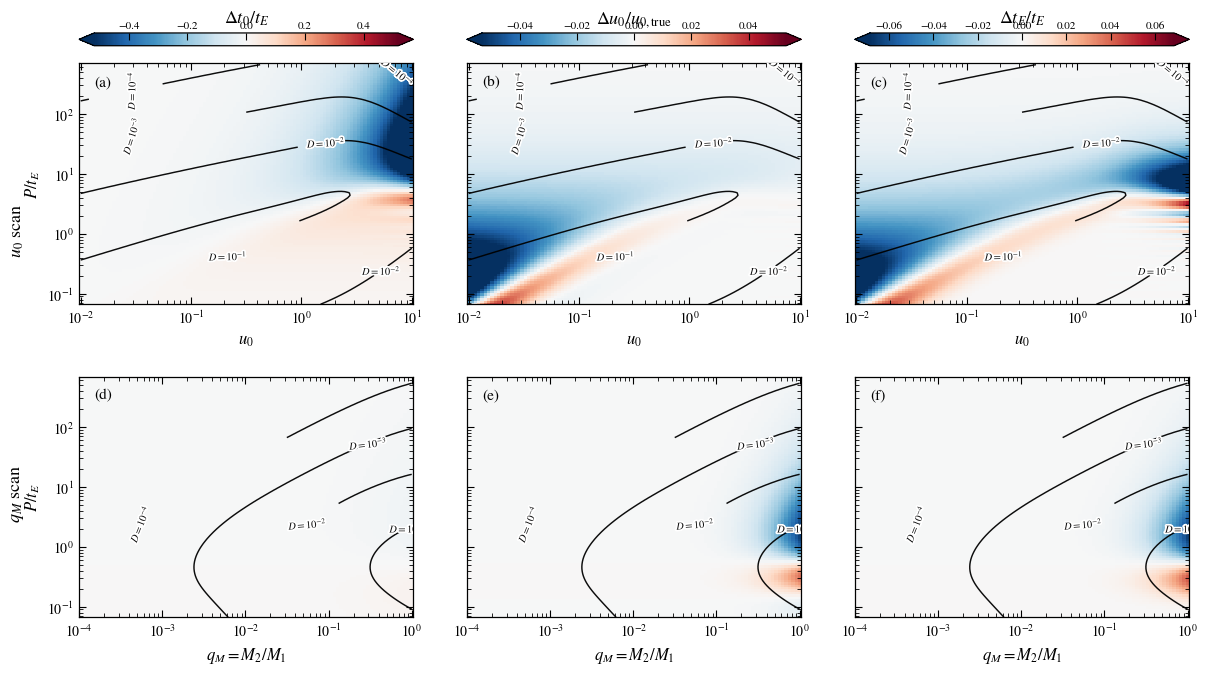

In [45]:
# ============================================================
# PSPL PARAMETER BIASES + D CONTOURS
#
# Comparison between:
#
#   1) u0 scan
#   2) mass-ratio scan
#
# Rows:
#
#   top    -> u0 scan
#   bottom -> q_M scan
#
# Columns:
#
#   Delta t0 / tE
#   Delta u0 / u0,true
#   Delta tE / tE
#
# Overlaid contours:
#
#   D_BSPL-PSPL = constant
#
# The same bias color normalization is used in each COLUMN
# for the two scans.
#
# ============================================================


import os
import re
import glob

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe

from matplotlib.ticker import LogLocator


# ============================================================
# PAPER STYLE
# ============================================================

plt.rcParams.update({

    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",

    "font.size": 10,

    "axes.labelsize": 12,
    "axes.titlesize": 12,

    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    "axes.linewidth": 0.9,

    "xtick.direction": "in",
    "ytick.direction": "in",

    "xtick.top": True,
    "ytick.right": True,

    "xtick.major.size": 5,
    "ytick.major.size": 5,

    "xtick.minor.size": 3,
    "ytick.minor.size": 3,

    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,

    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})


# ============================================================
# CONFIGURATION
# ============================================================

tE_plot = 150.0


# ------------------------------------------------------------
# Input grids used in the simulations
# ------------------------------------------------------------

u0_grid_input = np.logspace(
    -2,
    1,
    100,
)

q_grid_input = np.logspace(
    -4,
    0,
    100,
)


# ------------------------------------------------------------
# Bias normalization
# ------------------------------------------------------------

NORMALIZE_BIASES = True


# ------------------------------------------------------------
# Robust bias color limits
#
# Set to 100 for full min/max range.
# ------------------------------------------------------------

ROBUST_PERCENTILE = 99.0


# ============================================================
# D CONTOURS
#
# Change these freely.
# ============================================================

D_LEVELS = np.array([

    1e-4,
    1e-3,
    1e-2,
    1e-1,

])


# ------------------------------------------------------------
# Label contours?
# ------------------------------------------------------------

LABEL_D_CONTOURS = True


# ------------------------------------------------------------
# D contour line properties
# ------------------------------------------------------------

D_LINEWIDTH = 1.05

D_LINESTYLE = "-"

D_ALPHA = 0.95


# ------------------------------------------------------------
# Show consistency slices
#
# Top row:
#     u0 = 0.1
#
# Bottom row:
#     q_M = 0.5
#
# Set False if not wanted in paper figure.
# ------------------------------------------------------------

SHOW_COMMON_SLICE = False


# ============================================================
# PATHS
# ============================================================

home = os.path.expanduser("~")

results_root = os.path.join(
    home,
    "binary_source",
    "results",
)


# ============================================================
# FIND u0 DIRECTORY
# ============================================================

u0_candidates = [

    os.path.join(
        results_root,
        f"scan_u0_tE{int(tE_plot)}",
    ),

    os.path.join(
        results_root,
        "scan_many_tE_200x200",
        f"scan_u0_tE{int(tE_plot)}",
    ),
]


u0_directory = None


for directory in u0_candidates:

    files_test = glob.glob(

        os.path.join(
            directory,
            "scan_kepler_u0_*.npz",
        )
    )

    if len(files_test) > 0:

        u0_directory = directory
        break


if u0_directory is None:

    raise FileNotFoundError(
        "Could not find the u0 scan."
    )


# ============================================================
# FIND MASS-RATIO DIRECTORY
# ============================================================

q_directory = os.path.join(

    results_root,

    f"scan_q_Mtotfixed_tE{int(tE_plot)}",
)


q_files_test = glob.glob(

    os.path.join(
        q_directory,
        "scan_kepler_q_*.npz",
    )
)


if len(q_files_test) == 0:

    raise FileNotFoundError(
        f"Could not find mass-ratio scan:\n{q_directory}"
    )


# ============================================================
# OUTPUT
# ============================================================

output_directory = os.path.join(

    results_root,

    "bias_comparison",
)


os.makedirs(
    output_directory,
    exist_ok=True,
)


print("=" * 80)

print("u0 scan:")
print(u0_directory)

print()

print("mass-ratio scan:")
print(q_directory)

print("=" * 80)


# ============================================================
# FILE INDEX
# ============================================================

def get_file_index(
    filename,
    parameter,
):

    pattern = (
        rf"scan_kepler_{parameter}_(\d+)\.npz$"
    )

    match = re.search(

        pattern,

        os.path.basename(
            filename
        ),
    )


    if match is None:

        raise ValueError(
            f"Could not extract index from:\n{filename}"
        )


    return int(
        match.group(1)
    )


# ============================================================
# LOAD SCAN
# ============================================================

def load_bias_scan(

    directory,
    file_parameter,
    parameter_grid,
    tE_true,
):

    pattern = os.path.join(

        directory,

        f"scan_kepler_{file_parameter}_*.npz",
    )


    files = sorted(
        glob.glob(
            pattern
        )
    )


    if len(files) == 0:

        raise FileNotFoundError(
            pattern
        )


    # ========================================================
    # PERIOD GRID
    # ========================================================

    with np.load(
        files[0],
        allow_pickle=False,
    ) as d:

        P_grid = d[
            "P_grid"
        ].astype(float)


    N_parameter = len(
        parameter_grid
    )

    N_P = len(
        P_grid
    )


    # ========================================================
    # EMPTY MAPS
    # ========================================================

    shape = (
        N_parameter,
        N_P,
    )


    DT0_map = np.full(
        shape,
        np.nan,
    )

    DU0_map = np.full(
        shape,
        np.nan,
    )

    DTE_map = np.full(
        shape,
        np.nan,
    )

    D_map = np.full(
        shape,
        np.nan,
    )

    SUCCESS_map = np.zeros(
        shape,
        dtype=bool,
    )


    # ========================================================
    # LOAD EACH FILE
    # ========================================================

    for filename in files:


        k = get_file_index(

            filename,

            file_parameter,
        )


        if (
            k < 0
            or
            k >= N_parameter
        ):

            print(
                f"Skipping out-of-range file:\n{filename}"
            )

            continue


        with np.load(
            filename,
            allow_pickle=False,
        ) as d:


            required = [

                "P_grid",

                "DT0",
                "DU0",
                "DTE",

                "SUCCESS",

                "D",
            ]


            for key in required:

                if key not in d.files:

                    raise KeyError(

                        f"\n{filename}\n"
                        f"does not contain '{key}'.\n\n"
                        f"Available keys:\n{d.files}"
                    )


            P_this = d[
                "P_grid"
            ].astype(float)


            if not np.allclose(
                P_this,
                P_grid,
            ):

                raise ValueError(

                    "P_grid differs between files:\n"
                    f"{filename}"
                )


            DT0 = d[
                "DT0"
            ].astype(float)


            DU0 = d[
                "DU0"
            ].astype(float)


            DTE = d[
                "DTE"
            ].astype(float)


            D_values = d[
                "D"
            ].astype(float)


            SUCCESS = d[
                "SUCCESS"
            ].astype(bool)


        # ====================================================
        # VALID BIAS VALUES
        # ====================================================

        valid_bias = (

            SUCCESS

            &

            np.isfinite(
                DT0
            )

            &

            np.isfinite(
                DU0
            )

            &

            np.isfinite(
                DTE
            )
        )


        # ====================================================
        # VALID D
        # ====================================================

        valid_D = (

            SUCCESS

            &

            np.isfinite(
                D_values
            )

            &

            (
                D_values > 0
            )
        )


        DT0_map[
            k,
            valid_bias
        ] = DT0[
            valid_bias
        ]


        DU0_map[
            k,
            valid_bias
        ] = DU0[
            valid_bias
        ]


        DTE_map[
            k,
            valid_bias
        ] = DTE[
            valid_bias
        ]


        D_map[
            k,
            valid_D
        ] = D_values[
            valid_D
        ]


        SUCCESS_map[
            k,
            valid_bias
        ] = True


    return {

        "parameter":
            np.asarray(
                parameter_grid,
                dtype=float,
            ),

        "P_grid":
            P_grid,

        "P_over_tE":
            P_grid
            /
            tE_true,

        "DT0":
            DT0_map,

        "DU0":
            DU0_map,

        "DTE":
            DTE_map,

        "D":
            D_map,

        "SUCCESS":
            SUCCESS_map,
    }


# ============================================================
# LOAD BOTH SCANS
# ============================================================

u0_data = load_bias_scan(

    directory=u0_directory,

    file_parameter="u0",

    parameter_grid=u0_grid_input,

    tE_true=tE_plot,
)


q_data = load_bias_scan(

    directory=q_directory,

    file_parameter="q",

    parameter_grid=q_grid_input,

    tE_true=tE_plot,
)


# ============================================================
# PREPARE BIASES
# ============================================================

def prepare_biases(
    data,
    scan_type,
):

    DT0 = data[
        "DT0"
    ].copy()


    DU0 = data[
        "DU0"
    ].copy()


    DTE = data[
        "DTE"
    ].copy()


    if NORMALIZE_BIASES:


        # ----------------------------------------------------
        # Delta t0 / tE
        # ----------------------------------------------------

        B_t0 = (

            DT0
            /
            tE_plot
        )


        # ----------------------------------------------------
        # Delta u0 / u0,true
        # ----------------------------------------------------

        if scan_type == "u0":

            u0_true_map = (

                data[
                    "parameter"
                ][
                    :,
                    None
                ]
            )


        elif scan_type == "q":

            # Fixed in the mass-ratio scan
            u0_true_map = 0.1


        else:

            raise ValueError(
                scan_type
            )


        B_u0 = (

            DU0
            /
            u0_true_map
        )


        # ----------------------------------------------------
        # Delta tE / tE
        # ----------------------------------------------------

        B_tE = (

            DTE
            /
            tE_plot
        )


    else:

        B_t0 = DT0

        B_u0 = DU0

        B_tE = DTE


    return [

        B_t0,

        B_u0,

        B_tE,
    ]


u0_biases = prepare_biases(

    u0_data,

    scan_type="u0",
)


q_biases = prepare_biases(

    q_data,

    scan_type="q",
)


# ============================================================
# LABELS
# ============================================================

if NORMALIZE_BIASES:

    bias_labels = [

        r"$\Delta t_0/t_E$",

        r"$\Delta u_0/u_{0,\rm true}$",

        r"$\Delta t_E/t_E$",
    ]


else:

    bias_labels = [

        r"$\Delta t_0\ [{\rm d}]$",

        r"$\Delta u_0$",

        r"$\Delta t_E\ [{\rm d}]$",
    ]


# ============================================================
# SHARED SYMMETRIC LIMIT FOR EACH COLUMN
# ============================================================

def shared_symmetric_limit(
    A,
    B,
    percentile=99.0,
):

    values = np.concatenate([

        np.abs(
            A[
                np.isfinite(
                    A
                )
            ]
        ),

        np.abs(
            B[
                np.isfinite(
                    B
                )
            ]
        ),
    ])


    if len(values) == 0:

        return 1.0


    vmax = np.nanpercentile(

        values,

        percentile,
    )


    if (
        not np.isfinite(
            vmax
        )
        or
        vmax <= 0
    ):

        vmax = np.nanmax(
            values
        )


    return float(
        vmax
    )


vmax_columns = [

    shared_symmetric_limit(

        u0_biases[
            j
        ],

        q_biases[
            j
        ],

        percentile=ROBUST_PERCENTILE,
    )

    for j in range(
        3
    )
]


# ============================================================
# PRINT RANGES
# ============================================================

print()

print("=" * 80)

print("Bias color limits:")

for label, vmax in zip(

    bias_labels,

    vmax_columns,
):

    print(
        f"{label:30s}: +/- {vmax:.6g}"
    )


print()

print("D ranges:")

print(

    "u0 scan:",

    np.nanmin(
        u0_data[
            "D"
        ]
    ),

    np.nanmax(
        u0_data[
            "D"
        ]
    ),
)


print(

    "q scan :",

    np.nanmin(
        q_data[
            "D"
        ]
    ),

    np.nanmax(
        q_data[
            "D"
        ]
    ),
)

print("=" * 80)


# ============================================================
# LOGARITHMIC BIN EDGES
# ============================================================

def log_edges(
    x,
):

    x = np.asarray(
        x,
        dtype=float,
    )


    lx = np.log10(
        x
    )


    edges_log = np.empty(
        len(x) + 1
    )


    edges_log[
        1:-1
    ] = (

        lx[:-1]
        +
        lx[1:]

    ) / 2.0


    edges_log[
        0
    ] = (

        lx[0]

        -

        0.5
        *
        (
            lx[1]
            -
            lx[0]
        )
    )


    edges_log[
        -1
    ] = (

        lx[-1]

        +

        0.5
        *
        (
            lx[-1]
            -
            lx[-2]
        )
    )


    return (
        10**
        edges_log
    )


# ============================================================
# EDGES FOR PCOLORMESH
# ============================================================

u0_edges = log_edges(

    u0_data[
        "parameter"
    ]
)


q_edges = log_edges(

    q_data[
        "parameter"
    ]
)


P_u0_edges = log_edges(

    u0_data[
        "P_over_tE"
    ]
)


P_q_edges = log_edges(

    q_data[
        "P_over_tE"
    ]
)


# ============================================================
# D CONTOUR HELPER
# ============================================================

def add_D_contours(
    ax,
    x,
    y,
    D_map,
    levels,
    label=True,
):

    """
    Overlay constant-D contours.

    Black lines with a thin white halo are used so that
    contours remain visible over both blue and red regions.
    """


    X, Y = np.meshgrid(

        x,

        y,

        indexing="ij",
    )


    Z = np.ma.masked_invalid(
        D_map
    )


    # ========================================================
    # ONLY USE LEVELS INSIDE ACTUAL DATA RANGE
    # ========================================================

    valid_values = D_map[
        np.isfinite(
            D_map
        )
        &
        (
            D_map > 0
        )
    ]


    if len(valid_values) == 0:

        return None


    Dmin = np.nanmin(
        valid_values
    )

    Dmax = np.nanmax(
        valid_values
    )


    levels_here = [

        level

        for level in levels

        if (
            level > Dmin
            and
            level < Dmax
        )
    ]


    if len(
        levels_here
    ) == 0:

        return None


    # ========================================================
    # CONTOURS
    # ========================================================

    cs = ax.contour(

        X,

        Y,

        Z,

        levels=levels_here,

        colors="k",

        linewidths=D_LINEWIDTH,

        linestyles=D_LINESTYLE,

        alpha=D_ALPHA,

        zorder=10,
    )


    # ========================================================
    # WHITE HALO AROUND CONTOURS
    # ========================================================

    for collection in cs.allsegs:

        pass


    # Recent matplotlib versions do not expose
    # cs.collections consistently, so apply effects through
    # the contour paths when available.
    try:

        for collection in cs.collections:

            collection.set_path_effects([

                pe.Stroke(
                    linewidth=D_LINEWIDTH + 1.1,
                    foreground="white",
                ),

                pe.Normal(),
            ])

    except AttributeError:

        pass


    # ========================================================
    # LABELS
    # ========================================================

    if label:

        fmt = {

            level:
                rf"$D=10^{{{int(np.log10(level))}}}$"

            for level in levels_here
        }


        labels = ax.clabel(

            cs,

            levels=levels_here,

            fmt=fmt,

            fontsize=7.5,

            inline=True,

            inline_spacing=5,

            colors="k",
        )


        for text in labels:

            text.set_path_effects([

                pe.Stroke(
                    linewidth=2.5,
                    foreground="white",
                ),

                pe.Normal(),
            ])


    return cs


# ============================================================
# COLORMAP FOR BIASES
# ============================================================

cmap = plt.get_cmap(
    "RdBu_r"
)


# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(

    2,
    3,

    figsize=(
        12.2,
        7.1,
    ),

    sharey="row",
)


fig.subplots_adjust(

    left=0.075,

    right=0.985,

    bottom=0.10,

    top=0.88,

    wspace=0.16,

    hspace=0.30,
)


# ============================================================
# PANEL LABELS
# ============================================================

panel_labels = [

    "(a)",
    "(b)",
    "(c)",

    "(d)",
    "(e)",
    "(f)",
]


# ============================================================
# DRAW MAPS
# ============================================================

for column in range(
    3
):


    # ========================================================
    # ONE SHARED NORMALIZATION PER COLUMN
    # ========================================================

    vmax = vmax_columns[
        column
    ]


    norm = mcolors.TwoSlopeNorm(

        vmin=-vmax,

        vcenter=0.0,

        vmax=vmax,
    )


    # ========================================================
    # TOP ROW — u0 SCAN
    # ========================================================

    ax = axes[
        0,
        column
    ]


    Z = np.ma.masked_invalid(

        u0_biases[
            column
        ]
    )


    ax.pcolormesh(

        u0_edges,

        P_u0_edges,

        Z.T,

        cmap=cmap,

        norm=norm,

        shading="auto",

        rasterized=True,

        zorder=1,
    )


    # --------------------------------------------------------
    # D contours
    # --------------------------------------------------------

    add_D_contours(

        ax=ax,

        x=u0_data[
            "parameter"
        ],

        y=u0_data[
            "P_over_tE"
        ],

        D_map=u0_data[
            "D"
        ],

        levels=D_LEVELS,

        label=LABEL_D_CONTOURS,
    )


    # --------------------------------------------------------
    # Optional common-system slice
    # --------------------------------------------------------

    if SHOW_COMMON_SLICE:

        ax.axvline(

            0.1,

            color="0.15",

            linestyle=":",

            linewidth=1.0,

            zorder=20,
        )


    # ========================================================
    # BOTTOM ROW — q_M SCAN
    # ========================================================

    ax = axes[
        1,
        column
    ]


    Z = np.ma.masked_invalid(

        q_biases[
            column
        ]
    )


    ax.pcolormesh(

        q_edges,

        P_q_edges,

        Z.T,

        cmap=cmap,

        norm=norm,

        shading="auto",

        rasterized=True,

        zorder=1,
    )


    # --------------------------------------------------------
    # D contours
    # --------------------------------------------------------

    add_D_contours(

        ax=ax,

        x=q_data[
            "parameter"
        ],

        y=q_data[
            "P_over_tE"
        ],

        D_map=q_data[
            "D"
        ],

        levels=D_LEVELS,

        label=LABEL_D_CONTOURS,
    )


    # --------------------------------------------------------
    # Optional common-system slice
    # --------------------------------------------------------

    if SHOW_COMMON_SLICE:

        ax.axvline(

            0.5,

            color="0.15",

            linestyle=":",

            linewidth=1.0,

            zorder=20,
        )


# ============================================================
# AXIS FORMAT
# ============================================================

for row in range(
    2
):

    for column in range(
        3
    ):

        ax = axes[
            row,
            column
        ]


        ax.set_xscale(
            "log"
        )


        ax.set_yscale(
            "log"
        )


        ax.tick_params(

            axis="both",

            which="both",

            direction="in",

            top=True,

            right=True,
        )


        ax.xaxis.set_major_locator(

            LogLocator(
                base=10.0
            )
        )


        ax.yaxis.set_major_locator(

            LogLocator(
                base=10.0
            )
        )


        ax.grid(
            False
        )


# ============================================================
# X LABELS
# ============================================================

for ax in axes[
    0,
    :
]:

    ax.set_xlabel(
        r"$u_0$"
    )


for ax in axes[
    1,
    :
]:

    ax.set_xlabel(
        r"$q_M=M_2/M_1$"
    )


# ============================================================
# Y LABELS
# ============================================================

axes[
    0,
    0
].set_ylabel(
    r"$P/t_E$"
)


axes[
    1,
    0
].set_ylabel(
    r"$P/t_E$"
)


# ============================================================
# COLUMN TITLES
# ============================================================

for column, title in enumerate(
    bias_labels
):

    axes[
        0,
        column
    ].set_title(

        title,

        pad=29,

        fontsize=13,
    )


# ============================================================
# PANEL LABELS
# ============================================================

kk = 0


for row in range(
    2
):

    for column in range(
        3
    ):

        axes[
            row,
            column
        ].text(

            0.045,

            0.95,

            panel_labels[
                kk
            ],

            transform=axes[
                row,
                column
            ].transAxes,

            ha="left",

            va="top",

            fontsize=11,

            color="k",

            zorder=30,
        )


        kk += 1


# ============================================================
# ROW LABELS
# ============================================================

fig.text(

    0.025,

    0.645,

    r"$u_0$ scan",

    rotation=90,

    ha="center",

    va="center",

    fontsize=13,
)


fig.text(

    0.025,

    0.275,

    r"$q_M$ scan",

    rotation=90,

    ha="center",

    va="center",

    fontsize=13,
)


# ============================================================
# COLORBARS
#
# One per column.
# Same scale for top and bottom panels.
# ============================================================

for column in range(
    3
):


    pos = axes[
        0,
        column
    ].get_position()


    cax = fig.add_axes([

        pos.x0,

        pos.y1
        + 0.025,

        pos.width,

        0.018,
    ])


    vmax = vmax_columns[
        column
    ]


    norm = mcolors.TwoSlopeNorm(

        vmin=-vmax,

        vcenter=0.0,

        vmax=vmax,
    )


    sm = plt.cm.ScalarMappable(

        norm=norm,

        cmap=cmap,
    )


    cbar = fig.colorbar(

        sm,

        cax=cax,

        orientation="horizontal",

        extend=(
            "both"
            if ROBUST_PERCENTILE < 100
            else "neither"
        ),
    )


    cbar.ax.xaxis.set_ticks_position(
        "top"
    )


    cbar.ax.tick_params(

        direction="in",

        labelsize=8,

        pad=2,
    )


# ============================================================
# SAVE
# ============================================================

suffix = (

    "normalized"

    if NORMALIZE_BIASES

    else "absolute"
)


png_path = os.path.join(

    output_directory,

    f"PSPL_biases_with_D_contours_tE{int(tE_plot)}_{suffix}.png",
)


pdf_path = os.path.join(

    output_directory,

    f"PSPL_biases_with_D_contours_tE{int(tE_plot)}_{suffix}.pdf",
)


fig.savefig(

    png_path,

    dpi=300,

    bbox_inches="tight",
)


fig.savefig(

    pdf_path,

    bbox_inches="tight",
)


print()

print("=" * 80)

print("Saved:")

print(png_path)

print(pdf_path)

print("=" * 80)


plt.show()

u0 scan:
/home/anibal-pc/binary_source/results/scan_u0_tE150

mass-ratio scan:
/home/anibal-pc/binary_source/results/scan_q_Mtotfixed_tE150

D range:
u0: 1.5665484863784458e-05 0.25065989491542146
q : 1.5110757243909477e-08 0.2097814128457426

RMS range:
u0: 7.637569293848002e-09 1.6685061053271406
q : 2.5724210121876484e-08 0.3643235689018968

Saved:
/home/anibal-pc/binary_source/results/bias_comparison/PSPL_biases_D_RMS_contours_tE150_normalized.png
/home/anibal-pc/binary_source/results/bias_comparison/PSPL_biases_D_RMS_contours_tE150_normalized.pdf


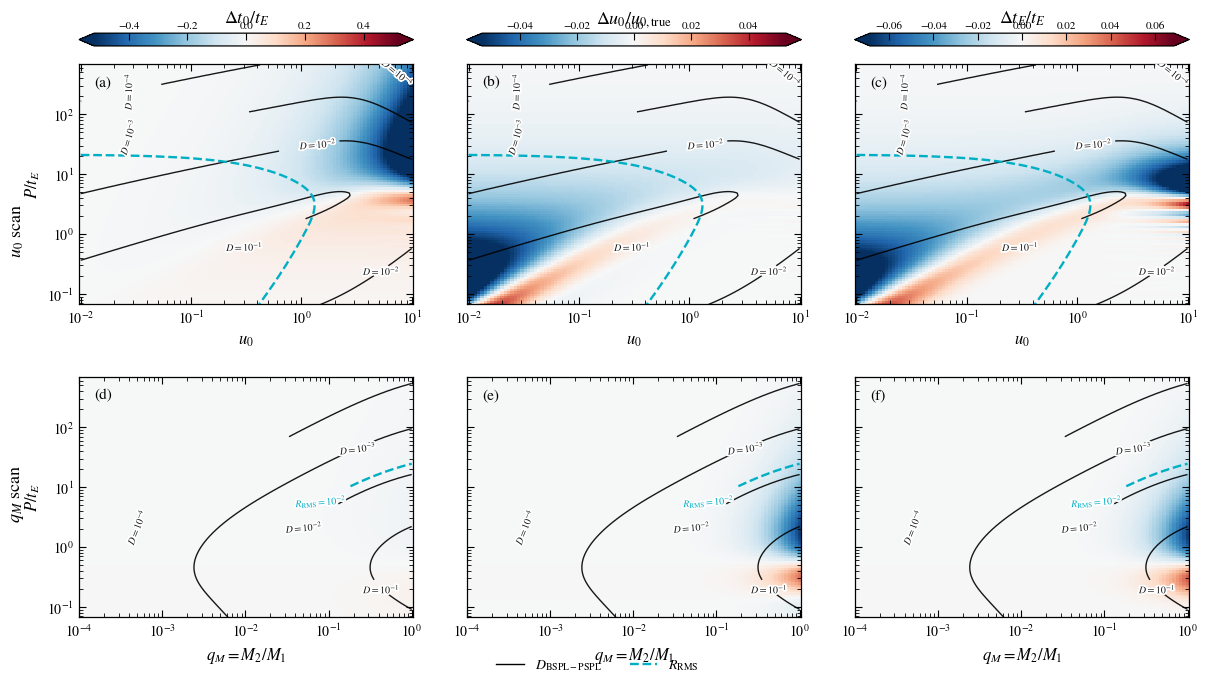

In [46]:
# ============================================================
# PSPL PARAMETER BIASES
# + D CONTOURS
# + RMS CONTOUR
#
# Rows:
#
#   top    -> u0 scan
#   bottom -> q_M scan
#
# Columns:
#
#   Delta t0 / tE
#   Delta u0 / u0,true
#   Delta tE / tE
#
# Overlaid contours:
#
#   black solid  -> D_BSPL-PSPL
#   cyan dashed  -> R_RMS
#
# ============================================================


import os
import re
import glob

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe

from matplotlib.ticker import LogLocator


# ============================================================
# PAPER STYLE
# ============================================================

plt.rcParams.update({

    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",

    "font.size": 10,

    "axes.labelsize": 12,
    "axes.titlesize": 12,

    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    "axes.linewidth": 0.9,

    "xtick.direction": "in",
    "ytick.direction": "in",

    "xtick.top": True,
    "ytick.right": True,

    "xtick.major.size": 5,
    "ytick.major.size": 5,

    "xtick.minor.size": 3,
    "ytick.minor.size": 3,

    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,

    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})


# ============================================================
# CONFIGURATION
# ============================================================

tE_plot = 150.0


# ------------------------------------------------------------
# Grids used in simulations
# ------------------------------------------------------------

u0_grid_input = np.logspace(
    -2,
    1,
    100,
)

q_grid_input = np.logspace(
    -4,
    0,
    100,
)


# ============================================================
# BIAS CONFIGURATION
# ============================================================

NORMALIZE_BIASES = True

ROBUST_PERCENTILE = 99.0


# ============================================================
# D CONTOURS
# ============================================================

D_LEVELS = np.array([

    1e-4,
    1e-3,
    1e-2,
    1e-1,

])


LABEL_D_CONTOURS = True

D_LINEWIDTH = 1.00

D_ALPHA = 0.90


# ============================================================
# RMS CONTOURS
#
# For the comparison I would initially use only RMS = 1e-2,
# because this is the reference level used elsewhere in the
# paper.
#
# You can instead use, for example:
#
# RMS_LEVELS = [1e-4, 1e-3, 1e-2]
#
# ============================================================

RMS_LEVELS = np.array([

    1e-2,

])


LABEL_RMS_CONTOURS = True

RMS_LINEWIDTH = 1.7

RMS_ALPHA = 1.0

RMS_COLOR = "#00AFC4"


# ============================================================
# OPTIONAL COMMON SYSTEM SLICE
#
# u0 scan: u0 = 0.1
# q scan : qM = 0.5
# ============================================================

SHOW_COMMON_SLICE = False


# ============================================================
# PATHS
# ============================================================

home = os.path.expanduser("~")

results_root = os.path.join(
    home,
    "binary_source",
    "results",
)


# ============================================================
# FIND u0 DIRECTORY
# ============================================================

u0_candidates = [

    os.path.join(
        results_root,
        f"scan_u0_tE{int(tE_plot)}",
    ),

    os.path.join(
        results_root,
        "scan_many_tE_200x200",
        f"scan_u0_tE{int(tE_plot)}",
    ),
]


u0_directory = None


for directory in u0_candidates:

    files_test = glob.glob(

        os.path.join(
            directory,
            "scan_kepler_u0_*.npz",
        )
    )

    if len(files_test) > 0:

        u0_directory = directory

        break


if u0_directory is None:

    raise FileNotFoundError(
        "Could not find the u0 scan."
    )


# ============================================================
# MASS-RATIO DIRECTORY
# ============================================================

q_directory = os.path.join(

    results_root,

    f"scan_q_Mtotfixed_tE{int(tE_plot)}",
)


q_files_test = glob.glob(

    os.path.join(
        q_directory,
        "scan_kepler_q_*.npz",
    )
)


if len(q_files_test) == 0:

    raise FileNotFoundError(

        f"Could not find mass-ratio scan:\n"
        f"{q_directory}"
    )


# ============================================================
# OUTPUT
# ============================================================

output_directory = os.path.join(

    results_root,

    "bias_comparison",
)


os.makedirs(

    output_directory,

    exist_ok=True,
)


print("=" * 80)

print("u0 scan:")
print(u0_directory)

print()

print("mass-ratio scan:")
print(q_directory)

print("=" * 80)


# ============================================================
# EXTRACT FILE INDEX
# ============================================================

def get_file_index(
    filename,
    parameter,
):

    pattern = (

        rf"scan_kepler_{parameter}_(\d+)\.npz$"
    )


    match = re.search(

        pattern,

        os.path.basename(
            filename
        ),
    )


    if match is None:

        raise ValueError(

            f"Could not extract index from:\n"
            f"{filename}"
        )


    return int(
        match.group(1)
    )


# ============================================================
# LOAD SCAN
# ============================================================

def load_bias_scan(

    directory,
    file_parameter,
    parameter_grid,
    tE_true,
):


    pattern = os.path.join(

        directory,

        f"scan_kepler_{file_parameter}_*.npz",
    )


    files = sorted(

        glob.glob(
            pattern
        )
    )


    if len(files) == 0:

        raise FileNotFoundError(
            pattern
        )


    # ========================================================
    # PERIOD GRID
    # ========================================================

    with np.load(
        files[0],
        allow_pickle=False,
    ) as d:

        P_grid = d[
            "P_grid"
        ].astype(float)


    N_parameter = len(
        parameter_grid
    )

    N_P = len(
        P_grid
    )


    shape = (

        N_parameter,
        N_P,

    )


    # ========================================================
    # EMPTY MAPS
    # ========================================================

    DT0_map = np.full(
        shape,
        np.nan,
    )


    DU0_map = np.full(
        shape,
        np.nan,
    )


    DTE_map = np.full(
        shape,
        np.nan,
    )


    D_map = np.full(
        shape,
        np.nan,
    )


    RMS_map = np.full(
        shape,
        np.nan,
    )


    SUCCESS_map = np.zeros(

        shape,

        dtype=bool,
    )


    # ========================================================
    # LOAD FILES
    # ========================================================

    for filename in files:


        k = get_file_index(

            filename,

            file_parameter,
        )


        if (
            k < 0
            or
            k >= N_parameter
        ):

            print(

                "Skipping out-of-range file:\n"
                f"{filename}"
            )

            continue


        with np.load(

            filename,

            allow_pickle=False,

        ) as d:


            required = [

                "P_grid",

                "DT0",
                "DU0",
                "DTE",

                "SUCCESS",

                "D",

                "RMS",
            ]


            for key in required:

                if key not in d.files:

                    raise KeyError(

                        f"\n{filename}\n"
                        f"does not contain '{key}'.\n\n"
                        f"Available keys:\n"
                        f"{d.files}"
                    )


            # =================================================
            # LOAD ARRAYS
            # =================================================

            P_this = d[
                "P_grid"
            ].astype(float)


            if not np.allclose(

                P_this,

                P_grid,

            ):

                raise ValueError(

                    "P_grid differs between files:\n"
                    f"{filename}"
                )


            DT0 = d[
                "DT0"
            ].astype(float)


            DU0 = d[
                "DU0"
            ].astype(float)


            DTE = d[
                "DTE"
            ].astype(float)


            D_values = d[
                "D"
            ].astype(float)


            RMS_values = d[
                "RMS"
            ].astype(float)


            SUCCESS = d[
                "SUCCESS"
            ].astype(bool)


        # ====================================================
        # VALID BIAS
        # ====================================================

        valid_bias = (

            SUCCESS

            &

            np.isfinite(
                DT0
            )

            &

            np.isfinite(
                DU0
            )

            &

            np.isfinite(
                DTE
            )
        )


        # ====================================================
        # VALID D
        # ====================================================

        valid_D = (

            SUCCESS

            &

            np.isfinite(
                D_values
            )

            &

            (
                D_values > 0
            )
        )


        # ====================================================
        # VALID RMS
        # ====================================================

        valid_RMS = (

            SUCCESS

            &

            np.isfinite(
                RMS_values
            )

            &

            (
                RMS_values > 0
            )
        )


        # ====================================================
        # STORE
        # ====================================================

        DT0_map[
            k,
            valid_bias
        ] = DT0[
            valid_bias
        ]


        DU0_map[
            k,
            valid_bias
        ] = DU0[
            valid_bias
        ]


        DTE_map[
            k,
            valid_bias
        ] = DTE[
            valid_bias
        ]


        D_map[
            k,
            valid_D
        ] = D_values[
            valid_D
        ]


        RMS_map[
            k,
            valid_RMS
        ] = RMS_values[
            valid_RMS
        ]


        SUCCESS_map[
            k,
            valid_bias
        ] = True


    return {

        "parameter":
            np.asarray(
                parameter_grid,
                dtype=float,
            ),

        "P_grid":
            P_grid,

        "P_over_tE":
            P_grid
            /
            tE_true,

        "DT0":
            DT0_map,

        "DU0":
            DU0_map,

        "DTE":
            DTE_map,

        "D":
            D_map,

        "RMS":
            RMS_map,

        "SUCCESS":
            SUCCESS_map,
    }


# ============================================================
# LOAD BOTH SCANS
# ============================================================

u0_data = load_bias_scan(

    directory=u0_directory,

    file_parameter="u0",

    parameter_grid=u0_grid_input,

    tE_true=tE_plot,
)


q_data = load_bias_scan(

    directory=q_directory,

    file_parameter="q",

    parameter_grid=q_grid_input,

    tE_true=tE_plot,
)


# ============================================================
# PREPARE BIAS MAPS
# ============================================================

def prepare_biases(
    data,
    scan_type,
):


    DT0 = data[
        "DT0"
    ].copy()


    DU0 = data[
        "DU0"
    ].copy()


    DTE = data[
        "DTE"
    ].copy()


    if NORMALIZE_BIASES:


        # ====================================================
        # Delta t0 / tE
        # ====================================================

        B_t0 = (

            DT0
            /
            tE_plot
        )


        # ====================================================
        # Delta u0 / u0,true
        # ====================================================

        if scan_type == "u0":

            u0_true_map = (

                data[
                    "parameter"
                ][
                    :,
                    None
                ]
            )


        elif scan_type == "q":

            # Fixed in mass-ratio simulation
            u0_true_map = 0.1


        else:

            raise ValueError(
                scan_type
            )


        B_u0 = (

            DU0
            /
            u0_true_map
        )


        # ====================================================
        # Delta tE / tE
        # ====================================================

        B_tE = (

            DTE
            /
            tE_plot
        )


    else:

        B_t0 = DT0

        B_u0 = DU0

        B_tE = DTE


    return [

        B_t0,
        B_u0,
        B_tE,

    ]


u0_biases = prepare_biases(

    u0_data,

    scan_type="u0",
)


q_biases = prepare_biases(

    q_data,

    scan_type="q",
)


# ============================================================
# LABELS
# ============================================================

if NORMALIZE_BIASES:

    bias_labels = [

        r"$\Delta t_0/t_E$",

        r"$\Delta u_0/u_{0,\rm true}$",

        r"$\Delta t_E/t_E$",

    ]


else:

    bias_labels = [

        r"$\Delta t_0\ [{\rm d}]$",

        r"$\Delta u_0$",

        r"$\Delta t_E\ [{\rm d}]$",

    ]


# ============================================================
# SHARED SYMMETRIC COLOR LIMIT
# ============================================================

def shared_symmetric_limit(

    A,
    B,

    percentile=99.0,

):


    values = np.concatenate([


        np.abs(

            A[
                np.isfinite(
                    A
                )
            ]

        ),


        np.abs(

            B[
                np.isfinite(
                    B
                )
            ]

        ),

    ])


    if len(values) == 0:

        return 1.0


    vmax = np.nanpercentile(

        values,

        percentile,

    )


    if (

        not np.isfinite(
            vmax
        )

        or

        vmax <= 0

    ):

        vmax = np.nanmax(
            values
        )


    return float(
        vmax
    )


vmax_columns = [

    shared_symmetric_limit(

        u0_biases[
            j
        ],

        q_biases[
            j
        ],

        percentile=ROBUST_PERCENTILE,

    )

    for j in range(
        3
    )
]


# ============================================================
# PRINT RANGES
# ============================================================

print()

print("=" * 80)

print("D range:")

print(

    "u0:",

    np.nanmin(
        u0_data[
            "D"
        ]
    ),

    np.nanmax(
        u0_data[
            "D"
        ]
    ),
)


print(

    "q :", 

    np.nanmin(
        q_data[
            "D"
        ]
    ),

    np.nanmax(
        q_data[
            "D"
        ]
    ),
)


print()

print("RMS range:")


print(

    "u0:",

    np.nanmin(
        u0_data[
            "RMS"
        ]
    ),

    np.nanmax(
        u0_data[
            "RMS"
        ]
    ),
)


print(

    "q :", 

    np.nanmin(
        q_data[
            "RMS"
        ]
    ),

    np.nanmax(
        q_data[
            "RMS"
        ]
    ),
)

print("=" * 80)


# ============================================================
# LOG EDGES
# ============================================================

def log_edges(
    x,
):


    x = np.asarray(

        x,

        dtype=float,

    )


    lx = np.log10(
        x
    )


    edges_log = np.empty(
        len(x) + 1
    )


    edges_log[
        1:-1
    ] = (

        lx[:-1]
        +
        lx[1:]

    ) / 2.0


    edges_log[
        0
    ] = (

        lx[0]

        -

        0.5
        *
        (
            lx[1]
            -
            lx[0]
        )
    )


    edges_log[
        -1
    ] = (

        lx[-1]

        +

        0.5
        *
        (
            lx[-1]
            -
            lx[-2]
        )
    )


    return (
        10**
        edges_log
    )


# ============================================================
# EDGES
# ============================================================

u0_edges = log_edges(

    u0_data[
        "parameter"
    ]
)


q_edges = log_edges(

    q_data[
        "parameter"
    ]
)


P_u0_edges = log_edges(

    u0_data[
        "P_over_tE"
    ]
)


P_q_edges = log_edges(

    q_data[
        "P_over_tE"
    ]
)


# ============================================================
# GENERIC CONTOUR FUNCTION
# ============================================================

def add_metric_contours(

    ax,

    x,
    y,

    metric_map,

    levels,

    metric_name,

    color,

    linestyle,

    linewidth,

    alpha=1.0,

    labels=True,

):


    X, Y = np.meshgrid(

        x,
        y,

        indexing="ij",
    )


    Z = np.ma.masked_invalid(
        metric_map
    )


    # ========================================================
    # DATA RANGE
    # ========================================================

    valid = metric_map[

        np.isfinite(
            metric_map
        )

        &

        (
            metric_map > 0
        )

    ]


    if len(valid) == 0:

        return None


    vmin = np.min(
        valid
    )

    vmax = np.max(
        valid
    )


    # ========================================================
    # KEEP ONLY CONTOURS WITHIN DATA RANGE
    # ========================================================

    levels_here = [

        level

        for level in levels

        if (
            level > vmin

            and

            level < vmax
        )
    ]


    if len(levels_here) == 0:

        return None


    # ========================================================
    # CONTOURS
    # ========================================================

    cs = ax.contour(

        X,

        Y,

        Z,

        levels=levels_here,

        colors=color,

        linewidths=linewidth,

        linestyles=linestyle,

        alpha=alpha,

        zorder=10,
    )


    # ========================================================
    # WHITE HALO
    # ========================================================

    try:

        for collection in cs.collections:

            collection.set_path_effects([

                pe.Stroke(

                    linewidth=linewidth + 1.4,

                    foreground="white",

                ),

                pe.Normal(),

            ])

    except AttributeError:

        pass


    # ========================================================
    # LABELS
    # ========================================================

    if labels:


        fmt = {

            level:

                (
                    rf"$D=10^{{{int(np.log10(level))}}}$"

                    if metric_name == "D"

                    else

                    rf"$R_{{\rm RMS}}=10^{{{int(np.log10(level))}}}$"
                )

            for level in levels_here

        }


        texts = ax.clabel(

            cs,

            levels=levels_here,

            fmt=fmt,

            inline=True,

            inline_spacing=7,

            fontsize=7.2,

            colors=color,

        )


        # ====================================================
        # WHITE HALO ON LABELS
        # ====================================================

        for text in texts:

            text.set_path_effects([

                pe.Stroke(

                    linewidth=2.5,

                    foreground="white",

                ),

                pe.Normal(),

            ])


    return cs


# ============================================================
# BIAS COLORMAP
# ============================================================

cmap = plt.get_cmap(
    "RdBu_r"
)


# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(

    2,
    3,

    figsize=(
        12.2,
        7.1,
    ),

    sharey="row",

)


fig.subplots_adjust(

    left=0.075,

    right=0.985,

    bottom=0.10,

    top=0.88,

    wspace=0.16,

    hspace=0.30,

)


# ============================================================
# PANEL LABELS
# ============================================================

panel_labels = [

    "(a)",
    "(b)",
    "(c)",

    "(d)",
    "(e)",
    "(f)",

]


# ============================================================
# DRAW MAPS
# ============================================================

for column in range(
    3
):


    # ========================================================
    # BIAS COLOR NORMALIZATION
    # ========================================================

    vmax = vmax_columns[
        column
    ]


    norm = mcolors.TwoSlopeNorm(

        vmin=-vmax,

        vcenter=0.0,

        vmax=vmax,

    )


    # ========================================================
    # TOP ROW — u0 SCAN
    # ========================================================

    ax = axes[
        0,
        column
    ]


    Z = np.ma.masked_invalid(

        u0_biases[
            column
        ]

    )


    ax.pcolormesh(

        u0_edges,

        P_u0_edges,

        Z.T,

        cmap=cmap,

        norm=norm,

        shading="auto",

        rasterized=True,

        zorder=1,

    )


    # ========================================================
    # D CONTOURS
    # ========================================================

    add_metric_contours(

        ax=ax,

        x=u0_data[
            "parameter"
        ],

        y=u0_data[
            "P_over_tE"
        ],

        metric_map=u0_data[
            "D"
        ],

        levels=D_LEVELS,

        metric_name="D",

        color="black",

        linestyle="-",

        linewidth=D_LINEWIDTH,

        alpha=D_ALPHA,

        labels=LABEL_D_CONTOURS,

    )


    # ========================================================
    # RMS CONTOUR
    # ========================================================

    add_metric_contours(

        ax=ax,

        x=u0_data[
            "parameter"
        ],

        y=u0_data[
            "P_over_tE"
        ],

        metric_map=u0_data[
            "RMS"
        ],

        levels=RMS_LEVELS,

        metric_name="RMS",

        color=RMS_COLOR,

        linestyle="--",

        linewidth=RMS_LINEWIDTH,

        alpha=RMS_ALPHA,

        labels=LABEL_RMS_CONTOURS,

    )


    # ========================================================
    # OPTIONAL COMMON-SYSTEM SLICE
    # ========================================================

    if SHOW_COMMON_SLICE:

        ax.axvline(

            0.1,

            color="0.25",

            linestyle=":",

            linewidth=1,

            zorder=20,

        )


    # ========================================================
    # BOTTOM ROW — q_M SCAN
    # ========================================================

    ax = axes[
        1,
        column
    ]


    Z = np.ma.masked_invalid(

        q_biases[
            column
        ]

    )


    ax.pcolormesh(

        q_edges,

        P_q_edges,

        Z.T,

        cmap=cmap,

        norm=norm,

        shading="auto",

        rasterized=True,

        zorder=1,

    )


    # ========================================================
    # D CONTOURS
    # ========================================================

    add_metric_contours(

        ax=ax,

        x=q_data[
            "parameter"
        ],

        y=q_data[
            "P_over_tE"
        ],

        metric_map=q_data[
            "D"
        ],

        levels=D_LEVELS,

        metric_name="D",

        color="black",

        linestyle="-",

        linewidth=D_LINEWIDTH,

        alpha=D_ALPHA,

        labels=LABEL_D_CONTOURS,

    )


    # ========================================================
    # RMS CONTOUR
    # ========================================================

    add_metric_contours(

        ax=ax,

        x=q_data[
            "parameter"
        ],

        y=q_data[
            "P_over_tE"
        ],

        metric_map=q_data[
            "RMS"
        ],

        levels=RMS_LEVELS,

        metric_name="RMS",

        color=RMS_COLOR,

        linestyle="--",

        linewidth=RMS_LINEWIDTH,

        alpha=RMS_ALPHA,

        labels=LABEL_RMS_CONTOURS,

    )


    # ========================================================
    # OPTIONAL COMMON-SYSTEM SLICE
    # ========================================================

    if SHOW_COMMON_SLICE:

        ax.axvline(

            0.5,

            color="0.25",

            linestyle=":",

            linewidth=1,

            zorder=20,

        )


# ============================================================
# AXES
# ============================================================

for row in range(
    2
):

    for column in range(
        3
    ):


        ax = axes[
            row,
            column
        ]


        ax.set_xscale(
            "log"
        )


        ax.set_yscale(
            "log"
        )


        ax.tick_params(

            axis="both",

            which="both",

            direction="in",

            top=True,

            right=True,

        )


        ax.xaxis.set_major_locator(

            LogLocator(
                base=10
            )

        )


        ax.yaxis.set_major_locator(

            LogLocator(
                base=10
            )

        )


        ax.grid(
            False
        )


# ============================================================
# X LABELS
# ============================================================

for ax in axes[
    0,
    :
]:

    ax.set_xlabel(
        r"$u_0$"
    )


for ax in axes[
    1,
    :
]:

    ax.set_xlabel(
        r"$q_M=M_2/M_1$"
    )


# ============================================================
# Y LABELS
# ============================================================

axes[
    0,
    0
].set_ylabel(
    r"$P/t_E$"
)


axes[
    1,
    0
].set_ylabel(
    r"$P/t_E$"
)


# ============================================================
# TITLES
# ============================================================

for column, title in enumerate(
    bias_labels
):


    axes[
        0,
        column
    ].set_title(

        title,

        pad=29,

        fontsize=13,

    )


# ============================================================
# PANEL LABELS
# ============================================================

kk = 0


for row in range(
    2
):

    for column in range(
        3
    ):


        axes[
            row,
            column
        ].text(

            0.045,

            0.95,

            panel_labels[
                kk
            ],

            transform=axes[
                row,
                column
            ].transAxes,

            ha="left",

            va="top",

            fontsize=11,

            color="k",

            zorder=30,

        )


        kk += 1


# ============================================================
# ROW LABELS
# ============================================================

fig.text(

    0.025,

    0.645,

    r"$u_0$ scan",

    rotation=90,

    ha="center",

    va="center",

    fontsize=13,

)


fig.text(

    0.025,

    0.275,

    r"$q_M$ scan",

    rotation=90,

    ha="center",

    va="center",

    fontsize=13,

)


# ============================================================
# COLORBARS
# ============================================================

for column in range(
    3
):


    pos = axes[
        0,
        column
    ].get_position()


    cax = fig.add_axes([

        pos.x0,

        pos.y1
        + 0.025,

        pos.width,

        0.018,

    ])


    vmax = vmax_columns[
        column
    ]


    norm = mcolors.TwoSlopeNorm(

        vmin=-vmax,

        vcenter=0,

        vmax=vmax,

    )


    sm = plt.cm.ScalarMappable(

        norm=norm,

        cmap=cmap,

    )


    cbar = fig.colorbar(

        sm,

        cax=cax,

        orientation="horizontal",

        extend=(

            "both"

            if ROBUST_PERCENTILE < 100

            else "neither"

        ),

    )


    cbar.ax.xaxis.set_ticks_position(
        "top"
    )


    cbar.ax.tick_params(

        direction="in",

        labelsize=8,

        pad=2,

    )


# ============================================================
# LEGEND FOR CONTOUR TYPES
#
# Added only once, above the figure.
# ============================================================

from matplotlib.lines import Line2D


legend_elements = [

    Line2D(

        [0],
        [0],

        color="black",

        lw=D_LINEWIDTH,

        linestyle="-",

        label=r"$D_{\rm BSPL-PSPL}$",

    ),

    Line2D(

        [0],
        [0],

        color=RMS_COLOR,

        lw=RMS_LINEWIDTH,

        linestyle="--",

        label=r"$R_{\rm RMS}$",

    ),

]


fig.legend(

    handles=legend_elements,

    loc="lower center",

    bbox_to_anchor=(
        0.5,
        0.005,
    ),

    ncol=2,

    frameon=False,

    fontsize=10,

)


# ============================================================
# SAVE
# ============================================================

suffix = (

    "normalized"

    if NORMALIZE_BIASES

    else "absolute"

)


png_path = os.path.join(

    output_directory,

    f"PSPL_biases_D_RMS_contours_tE{int(tE_plot)}_{suffix}.png",

)


pdf_path = os.path.join(

    output_directory,

    f"PSPL_biases_D_RMS_contours_tE{int(tE_plot)}_{suffix}.pdf",

)


fig.savefig(

    png_path,

    dpi=300,

    bbox_inches="tight",

)


fig.savefig(

    pdf_path,

    bbox_inches="tight",

)


print()

print("=" * 80)

print("Saved:")

print(png_path)

print(pdf_path)

print("=" * 80)


plt.show()

u0 scan:
/home/anibal-pc/binary_source/results/scan_u0_tE150

q_M scan:
/home/anibal-pc/binary_source/results/scan_q_Mtotfixed_tE150

Output:
/home/anibal-pc/binary_source/results/bias_paper_figures

FIGURE 1 SAVED
/home/anibal-pc/binary_source/results/bias_paper_figures/paper_tE_bias_D_contours_tE150.png
/home/anibal-pc/binary_source/results/bias_paper_figures/paper_tE_bias_D_contours_tE150.pdf


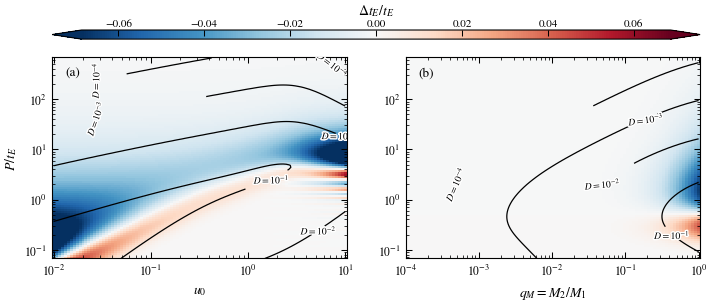


FIGURE 2
u0 used                 = 0.10000000
q_M closest to 0.5      = 0.52140083
Spearman rho            = 0.97441
Spearman p-value        = 2.42825e-65

FIGURE 2 SAVED
/home/anibal-pc/binary_source/results/bias_paper_figures/paper_u0_tE_correlated_bias_tE150.png
/home/anibal-pc/binary_source/results/bias_paper_figures/paper_u0_tE_correlated_bias_tE150.pdf


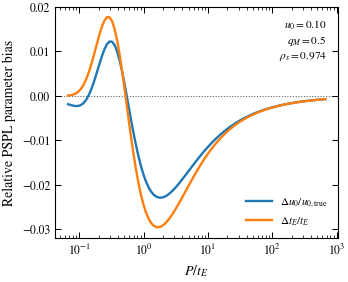

In [49]:
# ============================================================
# PAPER-QUALITY FIGURES
#
# FIGURE 1
# --------
# Relative Einstein-timescale bias:
#
#   (a) u0 scan
#   (b) q_M scan
#
# Color:
#       Delta tE / tE
#
# Black contours:
#       D_BSPL-PSPL
#
#
# FIGURE 2
# --------
# Correlated PSPL parameter shifts:
#
#       Delta u0 / u0,true
#       Delta tE / tE
#
# versus P/tE at:
#
#       u0 = 0.1
#       q_M = 0.5
#
#
# OUTPUT:
#   - PDF vector/raster hybrid
#   - PNG at 600 dpi
#
# ============================================================


import os
import re
import glob

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe

from matplotlib.ticker import LogLocator
from scipy.stats import spearmanr


# ============================================================
# GLOBAL PAPER STYLE
# ============================================================

PAPER_DPI = 600

plt.rcParams.update({

    # --------------------------------------------------------
    # Fonts
    # --------------------------------------------------------
    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",

    "font.size": 9,

    "axes.labelsize": 10,
    "axes.titlesize": 10,

    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,

    "legend.fontsize": 8,

    # --------------------------------------------------------
    # Axes
    # --------------------------------------------------------
    "axes.linewidth": 0.8,

    "xtick.direction": "in",
    "ytick.direction": "in",

    "xtick.top": True,
    "ytick.right": True,

    "xtick.major.size": 4.0,
    "ytick.major.size": 4.0,

    "xtick.minor.size": 2.3,
    "ytick.minor.size": 2.3,

    "xtick.major.width": 0.75,
    "ytick.major.width": 0.75,

    "xtick.minor.width": 0.55,
    "ytick.minor.width": 0.55,

    # --------------------------------------------------------
    # Lines
    # --------------------------------------------------------
    "lines.linewidth": 1.4,

    # --------------------------------------------------------
    # Saving
    # --------------------------------------------------------
    "savefig.dpi": PAPER_DPI,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.03,

    # --------------------------------------------------------
    # PDF
    # --------------------------------------------------------
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# ============================================================
# CONFIGURATION
# ============================================================

tE_plot = 150.0

N_u0 = 100
N_q = 100

u0_grid_input = np.logspace(
    -2,
    1,
    N_u0,
)

q_grid_input = np.logspace(
    -4,
    0,
    N_q,
)


# Fixed u0 in q_M scan
u0_q_scan = 0.1


# ============================================================
# D CONTOURS
# ============================================================

D_LEVELS = np.array([
    1e-4,
    1e-3,
    1e-2,
    1e-1,
])

LABEL_D_CONTOURS = True


# ============================================================
# COLOR SCALE
# ============================================================

# Use 99 percentile to avoid a tiny number of pathological
# fits defining the entire color scale.
#
# Set 100.0 for absolute extrema.

ROBUST_PERCENTILE = 99.0


# ============================================================
# FIGURE 2 CONFIGURATION
# ============================================================

u0_slice_target = 0.1
q_slice_target = 0.5

# Usually False for the paper figure.
# True can be useful as a consistency check.
SHOW_Q_CONSISTENCY = False


# ============================================================
# PATHS
# ============================================================

home = os.path.expanduser("~")

results_root = os.path.join(
    home,
    "binary_source",
    "results",
)


# ============================================================
# FIND u0 SCAN
# ============================================================

u0_candidates = [

    os.path.join(
        results_root,
        f"scan_u0_tE{int(tE_plot)}",
    ),

    os.path.join(
        results_root,
        "scan_many_tE_200x200",
        f"scan_u0_tE{int(tE_plot)}",
    ),

]


u0_directory = None


for candidate in u0_candidates:

    files_test = glob.glob(
        os.path.join(
            candidate,
            "scan_kepler_u0_*.npz",
        )
    )

    if len(files_test) > 0:

        u0_directory = candidate
        break


if u0_directory is None:

    raise FileNotFoundError(
        "Could not find the u0 scan.\n\n"
        "Searched:\n"
        + "\n".join(u0_candidates)
    )


# ============================================================
# MASS-RATIO SCAN
# ============================================================

q_directory = os.path.join(
    results_root,
    f"scan_q_Mtotfixed_tE{int(tE_plot)}",
)


q_files_test = glob.glob(
    os.path.join(
        q_directory,
        "scan_kepler_q_*.npz",
    )
)


if len(q_files_test) == 0:

    raise FileNotFoundError(
        f"Could not find mass-ratio scan:\n"
        f"{q_directory}"
    )


# ============================================================
# OUTPUT DIRECTORY
# ============================================================

output_directory = os.path.join(
    results_root,
    "bias_paper_figures",
)

os.makedirs(
    output_directory,
    exist_ok=True,
)


print("=" * 80)
print("u0 scan:")
print(u0_directory)
print()
print("q_M scan:")
print(q_directory)
print()
print("Output:")
print(output_directory)
print("=" * 80)


# ============================================================
# FILE INDEX
# ============================================================

def get_file_index(filename, parameter):

    pattern = (
        rf"scan_kepler_{parameter}_(\d+)\.npz$"
    )

    match = re.search(
        pattern,
        os.path.basename(filename),
    )

    if match is None:

        raise ValueError(
            f"Could not extract index from:\n{filename}"
        )

    return int(match.group(1))


# ============================================================
# LOAD SCAN
# ============================================================

def load_scan(
    directory,
    file_parameter,
    parameter_grid,
    tE_true,
):

    pattern = os.path.join(
        directory,
        f"scan_kepler_{file_parameter}_*.npz",
    )

    files = sorted(
        glob.glob(pattern)
    )

    if len(files) == 0:
        raise FileNotFoundError(pattern)


    # --------------------------------------------------------
    # Period grid
    # --------------------------------------------------------

    with np.load(
        files[0],
        allow_pickle=False,
    ) as d:

        P_grid = d["P_grid"].astype(float)


    shape = (
        len(parameter_grid),
        len(P_grid),
    )


    DT0 = np.full(shape, np.nan)
    DU0 = np.full(shape, np.nan)
    DTE = np.full(shape, np.nan)

    D = np.full(shape, np.nan)
    RMS = np.full(shape, np.nan)

    SUCCESS = np.zeros(
        shape,
        dtype=bool,
    )


    # --------------------------------------------------------
    # Load all files
    # --------------------------------------------------------

    for filename in files:

        k = get_file_index(
            filename,
            file_parameter,
        )

        if not (
            0 <= k < len(parameter_grid)
        ):
            continue


        with np.load(
            filename,
            allow_pickle=False,
        ) as d:


            required = [
                "P_grid",
                "DT0",
                "DU0",
                "DTE",
                "D",
                "RMS",
                "SUCCESS",
            ]


            for key in required:

                if key not in d.files:

                    raise KeyError(
                        f"\nMissing key '{key}' in\n"
                        f"{filename}\n\n"
                        f"Available keys:\n{d.files}"
                    )


            P_this = d[
                "P_grid"
            ].astype(float)


            if not np.allclose(
                P_this,
                P_grid,
            ):

                raise ValueError(
                    f"P_grid differs in:\n{filename}"
                )


            dt0 = d[
                "DT0"
            ].astype(float)

            du0 = d[
                "DU0"
            ].astype(float)

            dte = d[
                "DTE"
            ].astype(float)

            dmetric = d[
                "D"
            ].astype(float)

            rms = d[
                "RMS"
            ].astype(float)

            success = d[
                "SUCCESS"
            ].astype(bool)


        # ----------------------------------------------------
        # Masks
        # ----------------------------------------------------

        valid_bias = (
            success
            & np.isfinite(dt0)
            & np.isfinite(du0)
            & np.isfinite(dte)
        )

        valid_D = (
            success
            & np.isfinite(dmetric)
            & (dmetric > 0)
        )

        valid_RMS = (
            success
            & np.isfinite(rms)
            & (rms > 0)
        )


        # ----------------------------------------------------
        # Store
        # ----------------------------------------------------

        DT0[k, valid_bias] = dt0[valid_bias]
        DU0[k, valid_bias] = du0[valid_bias]
        DTE[k, valid_bias] = dte[valid_bias]

        D[k, valid_D] = dmetric[valid_D]

        RMS[k, valid_RMS] = rms[valid_RMS]

        SUCCESS[k, :] = success


    return {

        "parameter":
            np.asarray(
                parameter_grid,
                dtype=float,
            ),

        "P_grid":
            P_grid,

        "P_over_tE":
            P_grid / tE_true,

        "DT0":
            DT0,

        "DU0":
            DU0,

        "DTE":
            DTE,

        "D":
            D,

        "RMS":
            RMS,

        "SUCCESS":
            SUCCESS,

    }


# ============================================================
# LOAD BOTH SCANS
# ============================================================

u0_data = load_scan(
    directory=u0_directory,
    file_parameter="u0",
    parameter_grid=u0_grid_input,
    tE_true=tE_plot,
)


q_data = load_scan(
    directory=q_directory,
    file_parameter="q",
    parameter_grid=q_grid_input,
    tE_true=tE_plot,
)


# ============================================================
# NORMALIZED BIASES
# ============================================================

# u0 scan

u0_DT0_norm = (
    u0_data["DT0"]
    /
    tE_plot
)


u0_DU0_norm = (
    u0_data["DU0"]
    /
    u0_data["parameter"][:, None]
)


u0_DTE_norm = (
    u0_data["DTE"]
    /
    tE_plot
)


# q_M scan

q_DT0_norm = (
    q_data["DT0"]
    /
    tE_plot
)


q_DU0_norm = (
    q_data["DU0"]
    /
    u0_q_scan
)


q_DTE_norm = (
    q_data["DTE"]
    /
    tE_plot
)


# ============================================================
# LOGARITHMIC BIN EDGES
# ============================================================

def log_edges(x):

    x = np.asarray(
        x,
        dtype=float,
    )

    lx = np.log10(x)

    ledges = np.empty(
        len(x) + 1
    )

    ledges[1:-1] = (
        lx[:-1]
        +
        lx[1:]
    ) / 2.0


    ledges[0] = (
        lx[0]
        -
        0.5
        *
        (
            lx[1]
            -
            lx[0]
        )
    )


    ledges[-1] = (
        lx[-1]
        +
        0.5
        *
        (
            lx[-1]
            -
            lx[-2]
        )
    )


    return 10**ledges


# ============================================================
# D CONTOURS
# ============================================================

def add_D_contours(
    ax,
    x,
    y,
    D_map,
    levels=D_LEVELS,
):

    X, Y = np.meshgrid(
        x,
        y,
        indexing="ij",
    )


    valid_values = D_map[
        np.isfinite(D_map)
        &
        (D_map > 0)
    ]


    if len(valid_values) == 0:
        return None


    dmin = np.nanmin(
        valid_values
    )

    dmax = np.nanmax(
        valid_values
    )


    levels_here = [
        level
        for level in levels
        if dmin < level < dmax
    ]


    if len(levels_here) == 0:
        return None


    cs = ax.contour(

        X,
        Y,

        np.ma.masked_invalid(
            D_map
        ),

        levels=levels_here,

        colors="black",

        linewidths=0.90,

        linestyles="-",

        zorder=10,
    )


    # --------------------------------------------------------
    # White halo
    # --------------------------------------------------------

    try:

        for collection in cs.collections:

            collection.set_path_effects([

                pe.Stroke(
                    linewidth=1.8,
                    foreground="white",
                ),

                pe.Normal(),

            ])

    except AttributeError:

        pass


    # --------------------------------------------------------
    # Labels
    # --------------------------------------------------------

    if LABEL_D_CONTOURS:

        fmt = {
            level:
            rf"$D=10^{{{int(np.log10(level))}}}$"
            for level in levels_here
        }


        labels = ax.clabel(

            cs,

            fmt=fmt,

            fontsize=7.0,

            inline=True,

            inline_spacing=5,

        )


        for text in labels:

            text.set_path_effects([

                pe.Stroke(
                    linewidth=2.0,
                    foreground="white",
                ),

                pe.Normal(),

            ])


    return cs


# ============================================================
# COMMON AXIS STYLE
# ============================================================

def format_log_panel(ax):

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.tick_params(
        axis="both",
        which="both",
        direction="in",
        top=True,
        right=True,
    )

    ax.xaxis.set_major_locator(
        LogLocator(
            base=10.0
        )
    )

    ax.yaxis.set_major_locator(
        LogLocator(
            base=10.0
        )
    )

    ax.grid(False)


# ============================================================
# ============================================================
#
# FIGURE 1
#
# tE BIAS MAPS + D CONTOURS
#
# ============================================================
# ============================================================


# ============================================================
# SHARED COLOR RANGE
# ============================================================

all_DTE_bias = np.concatenate([

    np.abs(
        u0_DTE_norm[
            np.isfinite(
                u0_DTE_norm
            )
        ]
    ),

    np.abs(
        q_DTE_norm[
            np.isfinite(
                q_DTE_norm
            )
        ]
    ),

])


vmax_DTE = np.nanpercentile(
    all_DTE_bias,
    ROBUST_PERCENTILE,
)


norm_DTE = mcolors.TwoSlopeNorm(
    vmin=-vmax_DTE,
    vcenter=0.0,
    vmax=vmax_DTE,
)


# ============================================================
# GRID EDGES
# ============================================================

u0_edges = log_edges(
    u0_data["parameter"]
)

q_edges = log_edges(
    q_data["parameter"]
)

P_u0_edges = log_edges(
    u0_data["P_over_tE"]
)

P_q_edges = log_edges(
    q_data["P_over_tE"]
)


# ============================================================
# FIGURE 1
#
# ~7.2 inch wide:
# appropriate for a two-column paper figure.
# ============================================================

fig1, axes = plt.subplots(

    1,
    2,

    figsize=(
        7.2,
        3.25,
    ),

)


fig1.subplots_adjust(

    left=0.085,

    right=0.985,

    bottom=0.16,

    top=0.78,

    wspace=0.20,

)


cmap = plt.get_cmap(
    "RdBu_r"
)


# ============================================================
# PANEL (a) — u0 SCAN
# ============================================================

ax = axes[0]


pcm = ax.pcolormesh(

    u0_edges,
    P_u0_edges,

    np.ma.masked_invalid(
        u0_DTE_norm
    ).T,

    cmap=cmap,

    norm=norm_DTE,

    shading="auto",

    # Important:
    # rasterize only the dense heatmap
    rasterized=True,

    zorder=1,

)


add_D_contours(

    ax=ax,

    x=u0_data["parameter"],

    y=u0_data["P_over_tE"],

    D_map=u0_data["D"],

)


format_log_panel(ax)


ax.set_xlabel(
    r"$u_0$"
)

ax.set_ylabel(
    r"$P/t_E$"
)


ax.text(

    0.045,
    0.95,

    "(a)",

    transform=ax.transAxes,

    ha="left",
    va="top",

    fontsize=9.5,

    zorder=20,

)


# ============================================================
# PANEL (b) — q_M SCAN
# ============================================================

ax = axes[1]


ax.pcolormesh(

    q_edges,
    P_q_edges,

    np.ma.masked_invalid(
        q_DTE_norm
    ).T,

    cmap=cmap,

    norm=norm_DTE,

    shading="auto",

    rasterized=True,

    zorder=1,

)


add_D_contours(

    ax=ax,

    x=q_data["parameter"],

    y=q_data["P_over_tE"],

    D_map=q_data["D"],

)


format_log_panel(ax)


ax.set_xlabel(
    r"$q_M=M_2/M_1$"
)


ax.text(

    0.045,
    0.95,

    "(b)",

    transform=ax.transAxes,

    ha="left",
    va="top",

    fontsize=9.5,

    zorder=20,

)


# ============================================================
# COMMON TOP COLORBAR
# ============================================================

pos_left = axes[0].get_position()
pos_right = axes[1].get_position()


cax = fig1.add_axes([

    pos_left.x0,

    0.835,

    pos_right.x1
    -
    pos_left.x0,

    0.028,

])


cbar = fig1.colorbar(

    pcm,

    cax=cax,

    orientation="horizontal",

    extend="both",

)


cbar.ax.xaxis.set_ticks_position(
    "top"
)

cbar.ax.xaxis.set_label_position(
    "top"
)


cbar.ax.tick_params(
    direction="in",
    labelsize=8,
    pad=1.5,
)


cbar.set_label(

    r"$\Delta t_E/t_E$",

    fontsize=10,

    labelpad=3,

)


# ============================================================
# SAVE FIGURE 1
# ============================================================

figure1_png = os.path.join(
    output_directory,
    f"paper_tE_bias_D_contours_tE{int(tE_plot)}.png",
)

figure1_pdf = os.path.join(
    output_directory,
    f"paper_tE_bias_D_contours_tE{int(tE_plot)}.pdf",
)


fig1.savefig(

    figure1_png,

    dpi=PAPER_DPI,

    bbox_inches="tight",

    facecolor="white",

)


fig1.savefig(

    figure1_pdf,

    bbox_inches="tight",

    facecolor="white",

)


print()
print("=" * 80)
print("FIGURE 1 SAVED")
print(figure1_png)
print(figure1_pdf)
print("=" * 80)


plt.show()


# ============================================================
# ============================================================
#
# FIGURE 2
#
# CORRELATED u0 -- tE PARAMETER SHIFTS
#
# ============================================================
# ============================================================


# ============================================================
# FIND COMMON u0 = 0.1 SLICE
# ============================================================

iu = np.argmin(

    np.abs(

        np.log10(
            u0_data["parameter"]
        )

        -

        np.log10(
            u0_slice_target
        )

    )

)


u0_used = (
    u0_data[
        "parameter"
    ][iu]
)


# ============================================================
# FIND q_M ~ 0.5 SLICE
# ============================================================

iq = np.argmin(

    np.abs(

        np.log10(
            q_data["parameter"]
        )

        -

        np.log10(
            q_slice_target
        )

    )

)


q_used = (
    q_data[
        "parameter"
    ][iq]
)


# ============================================================
# EXTRACT u0-SCAN SLICE
# ============================================================

x_u0 = (
    u0_data[
        "P_over_tE"
    ]
)


du0_u0 = (
    u0_DU0_norm[
        iu,
        :
    ]
)


dtE_u0 = (
    u0_DTE_norm[
        iu,
        :
    ]
)


# ============================================================
# q_M-SCAN CONSISTENCY SLICE
# ============================================================

x_q = (
    q_data[
        "P_over_tE"
    ]
)


du0_q = (
    q_DU0_norm[
        iq,
        :
    ]
)


dtE_q = (
    q_DTE_norm[
        iq,
        :
    ]
)


# ============================================================
# SPEARMAN CORRELATION
# ============================================================

valid_slice = (

    np.isfinite(
        du0_u0
    )

    &

    np.isfinite(
        dtE_u0
    )

)


rho_slice, p_slice = spearmanr(

    du0_u0[
        valid_slice
    ],

    dtE_u0[
        valid_slice
    ],

)


print()
print("=" * 80)
print("FIGURE 2")
print(f"u0 used                 = {u0_used:.8f}")
print(f"q_M closest to 0.5      = {q_used:.8f}")
print(f"Spearman rho            = {rho_slice:.5f}")
print(f"Spearman p-value        = {p_slice:.5e}")
print("=" * 80)


# ============================================================
# FIGURE 2
#
# ~3.5 inch:
# suitable for single-column placement.
# ============================================================

fig2, ax = plt.subplots(

    figsize=(
        3.65,
        3.0,
    ),

)


# ============================================================
# MAIN CURVES
# ============================================================

ax.plot(

    x_u0,
    du0_u0,

    lw=1.7,

    label=
    r"$\Delta u_0/u_{0,\rm true}$",

)


ax.plot(

    x_u0,
    dtE_u0,

    lw=1.7,

    label=
    r"$\Delta t_E/t_E$",

)


# ============================================================
# OPTIONAL CONSISTENCY OVERLAY
# ============================================================

if SHOW_Q_CONSISTENCY:


    ax.plot(

        x_q,
        du0_q,

        "--",

        lw=1.0,

        alpha=0.7,

        label=(
            rf"$\Delta u_0/u_0$, "
            rf"$q_M={q_used:.3f}$ scan"
        ),

    )


    ax.plot(

        x_q,
        dtE_q,

        "--",

        lw=1.0,

        alpha=0.7,

        label=(
            rf"$\Delta t_E/t_E$, "
            rf"$q_M={q_used:.3f}$ scan"
        ),

    )


# ============================================================
# ZERO LINE
# ============================================================

ax.axhline(

    0.0,

    lw=0.75,

    linestyle=":",

    color="0.35",

    zorder=0,

)


# ============================================================
# FORMAT
# ============================================================

ax.set_xscale(
    "log"
)


ax.set_xlabel(
    r"$P/t_E$"
)


ax.set_ylabel(
    r"Relative PSPL parameter bias"
)


ax.tick_params(

    axis="both",

    which="both",

    direction="in",

    top=True,

    right=True,

)


ax.xaxis.set_major_locator(
    LogLocator(
        base=10
    )
)


ax.grid(
    False
)


# ============================================================
# ANNOTATION
# ============================================================

ax.text(

    0.96,
    0.95,

    (
        rf"$u_0={u0_used:.2f}$"
        "\n"
        rf"$q_M=0.5$"
        "\n"
        rf"$\rho_s={rho_slice:.3f}$"
    ),

    transform=ax.transAxes,

    ha="right",
    va="top",

    fontsize=8.2,

)


# ============================================================
# LEGEND
# ============================================================

ax.legend(

    frameon=False,

    loc="lower right",

    handlelength=2.3,

    borderaxespad=0.5,

)


# ============================================================
# SAVE FIGURE 2
# ============================================================

figure2_png = os.path.join(
    output_directory,
    f"paper_u0_tE_correlated_bias_tE{int(tE_plot)}.png",
)

figure2_pdf = os.path.join(
    output_directory,
    f"paper_u0_tE_correlated_bias_tE{int(tE_plot)}.pdf",
)


fig2.savefig(

    figure2_png,

    dpi=PAPER_DPI,

    bbox_inches="tight",

    facecolor="white",

)


fig2.savefig(

    figure2_pdf,

    bbox_inches="tight",

    facecolor="white",

)


print()
print("=" * 80)
print("FIGURE 2 SAVED")
print(figure2_png)
print(figure2_pdf)
print("=" * 80)


plt.show()


REFERENCE tE = 150 d
/home/anibal-pc/binary_source/results/scan_many_tE_200x200/scan_u0_tE150

D=1.00e-02:
u0 columns with crossings = 1200 / 1200
u0 columns with >=2 crossings = 331

FIGURE 1 SAVED
/home/anibal-pc/binary_source/results/paper_figures/D_heatmap_tE150_complete_contour.png
/home/anibal-pc/binary_source/results/paper_figures/D_heatmap_tE150_complete_contour.pdf


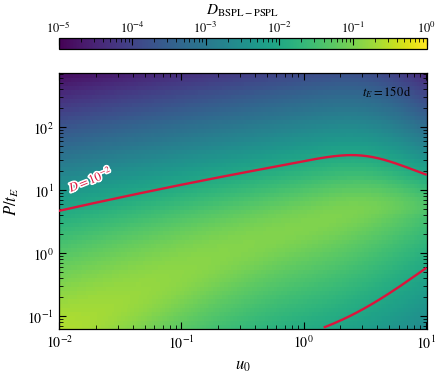

Loaded tE=10 d -> (200, 60)
Loaded tE=20 d -> (200, 60)
Loaded tE=30 d -> (200, 60)
Loaded tE=50 d -> (200, 60)
Loaded tE=75 d -> (200, 60)
Loaded tE=100 d -> (200, 60)
Loaded tE=150 d -> (200, 60)
Loaded tE=200 d -> (200, 60)
Loaded tE=300 d -> (200, 60)
Loaded tE=500 d -> (200, 60)
Loaded tE=750 d -> (200, 60)
Loaded tE=1000 d -> (200, 60)

D=1.00e-02:
u0 columns with crossings = 1029 / 1200
u0 columns with >=2 crossings = 262

D=1.00e-02:
u0 columns with crossings = 1200 / 1200
u0 columns with >=2 crossings = 331

D=1.00e-02:
u0 columns with crossings = 1200 / 1200
u0 columns with >=2 crossings = 331

D=1.00e-02:
u0 columns with crossings = 1200 / 1200
u0 columns with >=2 crossings = 331

D=1.00e-02:
u0 columns with crossings = 1200 / 1200
u0 columns with >=2 crossings = 331

D=1.00e-02:
u0 columns with crossings = 1200 / 1200
u0 columns with >=2 crossings = 331

D=1.00e-02:
u0 columns with crossings = 1200 / 1200
u0 columns with >=2 crossings = 331

D=1.00e-02:
u0 columns with cros

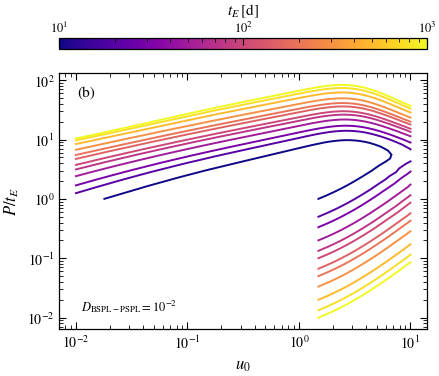

In [68]:
# ============================================================
# D_BSPL-PSPL -- PAPER FIGURES
#
# FIGURE 1
# --------
# Heatmap D(u0, P/tE) for tE = 150 d
# + ONLY the red D = 1e-2 contour.
#
# IMPORTANT:
#
# Instead of plotting the raw matplotlib contour directly,
# we reconstruct the D=1e-2 level from the simulated D field:
#
#   1. interpolate log10(D) on a fine log-log grid
#   2. for every u0, locate crossings of D = 1e-2
#   3. identify upper and lower branches
#   4. interpolate missing INTERNAL parts of each branch
#      with PCHIP in log(u0)-log(P/tE)
#
# This completes the missing red segment using neighboring
# simulated values, without plotting additional contours.
#
#
# FIGURE 2
# --------
# D = 1e-2 contour for several tE values.
#
# Both figures are saved independently:
#
#   PNG 600 dpi
#   PDF
#
# ============================================================


import os
import re
import glob

import numpy as np

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.patheffects as pe

from matplotlib.ticker import LogLocator

from scipy.interpolate import RectBivariateSpline
from scipy.interpolate import PchipInterpolator
from scipy.ndimage import distance_transform_edt


# ============================================================
# PAPER STYLE
# ============================================================

plt.rcParams.update({

    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",

    "font.size": 10,

    "axes.labelsize": 12,
    "axes.titlesize": 11,

    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    "legend.fontsize": 9,

    "axes.linewidth": 0.9,

    "xtick.direction": "in",
    "ytick.direction": "in",

    "xtick.top": True,
    "ytick.right": True,

    "xtick.major.size": 5,
    "ytick.major.size": 5,

    "xtick.minor.size": 3,
    "ytick.minor.size": 3,

    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,

    "savefig.dpi": 600,

    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# ============================================================
# CONFIGURATION
# ============================================================

tE_reference = 150.0


tE_values = [

    10,
    20,
    30,
    50,
    75,
    100,
    150,
    200,
    300,
    500,
    750,
    1000,

]


# ============================================================
# REFERENCE LEVEL
# ============================================================

D_REF = 1e-2


# ============================================================
# HEATMAP RANGE
# ============================================================

D_VMIN = 1e-5
D_VMAX = 1e0


# ============================================================
# INTERPOLATION RESOLUTION
# ============================================================

N_FINE_U0 = 1200
N_FINE_P = 1200


# ============================================================
# COMPLETE BRANCHES
# ============================================================
#
# True:
#
#   if a D=1e-2 branch disappears over an internal interval
#   in u0 but exists on both sides, reconstruct that missing
#   section using PCHIP interpolation.
#
# No extrapolation is performed outside the first and last
# actual crossings.
#
# ============================================================

COMPLETE_INTERNAL_GAPS = True


# ============================================================
# PATHS
# ============================================================

home = os.path.expanduser("~")


results_root = os.path.join(

    home,

    "binary_source",

    "results",

)


multi_tE_root = os.path.join(

    results_root,

    "scan_many_tE_200x200",

)


output_directory = os.path.join(

    results_root,

    "paper_figures",

)


os.makedirs(

    output_directory,

    exist_ok=True,

)


# ============================================================
# FIND SCAN
# ============================================================

def find_scan_directory(tE):


    label = int(tE)


    candidates = [

        os.path.join(

            multi_tE_root,

            f"scan_u0_tE{label}",

        ),

        os.path.join(

            results_root,

            f"scan_u0_tE{label}",

        ),

    ]


    for directory in candidates:


        files = glob.glob(

            os.path.join(

                directory,

                "scan_kepler_u0_*.npz",

            )

        )


        if len(files) > 0:

            return directory


    return None


# ============================================================
# LOAD ONE D SCAN
# ============================================================

def load_D_scan(tE):


    directory = find_scan_directory(tE)


    if directory is None:

        raise FileNotFoundError(

            f"No scan found for tE={tE}"

        )


    files = glob.glob(

        os.path.join(

            directory,

            "scan_kepler_u0_*.npz",

        )

    )


    # --------------------------------------------------------
    # Sort numerically
    # --------------------------------------------------------

    def get_index(filename):


        match = re.search(

            r"scan_kepler_u0_(\d+)\.npz$",

            os.path.basename(filename),

        )


        if match is None:

            return 10**9


        return int(

            match.group(1)

        )


    files = sorted(

        files,

        key=get_index,

    )


    # --------------------------------------------------------
    # Reference P grid
    # --------------------------------------------------------

    with np.load(

        files[0],

        allow_pickle=False,

    ) as d:


        P_grid = d[

            "P_grid"

        ].astype(float)


    rows = []


    # --------------------------------------------------------
    # Read u0 scans
    # --------------------------------------------------------

    for filename in files:


        with np.load(

            filename,

            allow_pickle=False,

        ) as d:


            if (
                "D" not in d.files
                or
                "truth" not in d.files
            ):

                continue


            truth = d[

                "truth"

            ].astype(float)


            u0_true = float(

                truth[1]

            )


            P_this = d[

                "P_grid"

            ].astype(float)


            if not np.allclose(

                P_this,

                P_grid,

            ):

                raise ValueError(

                    f"P_grid differs in:\n"
                    f"{filename}"

                )


            D_values = d[

                "D"

            ].astype(float)


            if "SUCCESS" in d.files:

                success = d[

                    "SUCCESS"

                ].astype(bool)

            else:

                success = np.ones_like(

                    D_values,

                    dtype=bool,

                )


            D_values = D_values.copy()


            D_values[

                ~success

            ] = np.nan


            D_values[

                ~np.isfinite(D_values)

            ] = np.nan


            D_values[

                D_values <= 0

            ] = np.nan


            rows.append(

                (
                    u0_true,
                    D_values,
                )

            )


    if len(rows) == 0:

        raise RuntimeError(

            f"No valid data in {directory}"

        )


    # --------------------------------------------------------
    # Sort by u0
    # --------------------------------------------------------

    rows.sort(

        key=lambda x:
            x[0]

    )


    u0_grid = np.array(

        [

            row[0]

            for row in rows

        ],

        dtype=float,

    )


    D_map = np.vstack(

        [

            row[1]

            for row in rows

        ]

    )


    P_over_tE = (

        P_grid

        /

        float(tE)

    )


    return {

        "directory":
            directory,

        "u0":
            u0_grid,

        "P":
            P_grid,

        "P_over_tE":
            P_over_tE,

        "D":
            D_map,

    }


# ============================================================
# LOG BIN EDGES
# ============================================================

def log_edges(x):


    x = np.asarray(

        x,

        dtype=float,

    )


    lx = np.log10(x)


    edges = np.empty(

        len(x) + 1

    )


    edges[1:-1] = (

        lx[:-1]

        +

        lx[1:]

    ) / 2.0


    edges[0] = (

        lx[0]

        -

        0.5
        *
        (
            lx[1]

            -

            lx[0]
        )

    )


    edges[-1] = (

        lx[-1]

        +

        0.5
        *
        (
            lx[-1]

            -

            lx[-2]
        )

    )


    return 10**edges


# ============================================================
# FILL NaNs ON ORIGINAL REGULAR GRID
# ============================================================
#
# Only needed for constructing the interpolation surface.
#
# The heatmap itself still uses the original D values.
#
# ============================================================

def nearest_fill_nan(array):


    arr = np.asarray(

        array,

        dtype=float,

    ).copy()


    invalid = ~np.isfinite(arr)


    if not np.any(invalid):

        return arr


    if np.all(invalid):

        raise RuntimeError(

            "All values are NaN."

        )


    # --------------------------------------------------------
    # Get indices of nearest valid cells
    # --------------------------------------------------------

    nearest_indices = distance_transform_edt(

        invalid,

        return_distances=False,

        return_indices=True,

    )


    nearest_values = arr[

        tuple(nearest_indices)

    ]


    arr[

        invalid

    ] = nearest_values[

        invalid

    ]


    return arr


# ============================================================
# BUILD FINE D SURFACE
# ============================================================
#
# Regular-grid interpolation in:
#
#   log10(u0)
#   log10(P/tE)
#   log10(D)
#
# ============================================================

def make_fine_D_surface(

    u0,

    P_over_tE,

    D_map,

):


    u0 = np.asarray(

        u0,

        dtype=float,

    )


    P_over_tE = np.asarray(

        P_over_tE,

        dtype=float,

    )


    D_map = np.asarray(

        D_map,

        dtype=float,

    )


    # ========================================================
    # log coordinates
    # ========================================================

    logu = np.log10(

        u0

    )


    logP = np.log10(

        P_over_tE

    )


    logD = np.full_like(

        D_map,

        np.nan,

        dtype=float,

    )


    valid = (

        np.isfinite(D_map)

        &

        (D_map > 0)

    )


    logD[

        valid

    ] = np.log10(

        D_map[

            valid

        ]

    )


    # ========================================================
    # Fill isolated failed fits
    # ========================================================

    logD_filled = nearest_fill_nan(

        logD

    )


    # ========================================================
    # Fine coordinates
    # ========================================================

    logu_fine = np.linspace(

        logu.min(),

        logu.max(),

        N_FINE_U0,

    )


    logP_fine = np.linspace(

        logP.min(),

        logP.max(),

        N_FINE_P,

    )


    # ========================================================
    # Bilinear interpolation
    #
    # kx=1, ky=1:
    # avoids spline overshooting and remains conservative.
    # ========================================================

    interpolator = RectBivariateSpline(

        logu,

        logP,

        logD_filled,

        kx=1,

        ky=1,

        s=0,

    )


    logD_fine = interpolator(

        logu_fine,

        logP_fine,

    )


    D_fine = (

        10**logD_fine

    )


    return (

        logu_fine,

        logP_fine,

        D_fine,

    )


# ============================================================
# FIND D=LEVEL CROSSINGS
# ============================================================
#
# For every u0:
#
#     find all P/tE where D crosses D_REF.
#
# Usually there are:
#
#     0 crossings
#     1 crossing
#     2 crossings
#
# If there is one crossing, it is assigned to the upper branch.
#
# If there are >= 2:
#
#     smallest P/tE -> lower branch
#     largest  P/tE -> upper branch
#
# ============================================================

def find_level_branches(

    logu,

    logP,

    D_fine,

    level,

):


    target = np.log10(

        level

    )


    logD = np.log10(

        D_fine

    )


    lower = np.full(

        len(logu),

        np.nan,

    )


    upper = np.full(

        len(logu),

        np.nan,

    )


    n_crossings = np.zeros(

        len(logu),

        dtype=int,

    )


    # ========================================================
    # Loop over u0
    # ========================================================

    for i in range(

        len(logu)

    ):


        z = (

            logD[i, :]

            -

            target

        )


        valid = np.isfinite(z)


        if np.sum(valid) < 2:

            continue


        crossings = []


        # ====================================================
        # Search adjacent P cells
        # ====================================================

        for j in range(

            len(logP) - 1

        ):


            if not (

                np.isfinite(z[j])

                and

                np.isfinite(z[j + 1])

            ):

                continue


            z1 = z[j]

            z2 = z[j + 1]


            # ------------------------------------------------
            # Exact crossing
            # ------------------------------------------------

            if z1 == 0:


                crossings.append(

                    logP[j]

                )


                continue


            # ------------------------------------------------
            # Sign change
            # ------------------------------------------------

            if (

                z1 * z2

                <

                0

            ):


                # Linear interpolation in logD-logP

                fraction = (

                    -z1

                    /

                    (
                        z2
                        -
                        z1
                    )

                )


                logP_cross = (

                    logP[j]

                    +

                    fraction
                    *
                    (
                        logP[j + 1]

                        -

                        logP[j]
                    )

                )


                crossings.append(

                    logP_cross

                )


        # ====================================================
        # Remove duplicates
        # ====================================================

        if len(crossings) == 0:

            continue


        crossings = np.array(

            sorted(

                crossings

            )

        )


        crossings = np.unique(

            np.round(

                crossings,

                decimals=10,

            )

        )


        n_crossings[i] = len(

            crossings

        )


        # ====================================================
        # Assign branches
        # ====================================================

        if len(crossings) == 1:


            upper[i] = (

                crossings[0]

            )


        else:


            lower[i] = (

                crossings[0]

            )


            upper[i] = (

                crossings[-1]

            )


    return (

        lower,

        upper,

        n_crossings,

    )


# ============================================================
# COMPLETE INTERNAL GAPS
# ============================================================
#
# This is the part that completes the missing red segment.
#
# We interpolate the P/tE coordinate of the contour as a
# function of log10(u0).
#
# IMPORTANT:
#
# PCHIP is only evaluated BETWEEN the first and last
# actual crossing.
#
# There is NO extrapolation beyond the simulated crossing
# range.
#
# ============================================================

def complete_branch(

    logu,

    branch,

):


    branch = np.asarray(

        branch,

        dtype=float,

    )


    valid = np.isfinite(

        branch

    )


    if np.sum(valid) < 2:

        return branch.copy()


    result = branch.copy()


    x_valid = logu[

        valid

    ]


    y_valid = branch[

        valid

    ]


    # ========================================================
    # PCHIP interpolation
    # ========================================================

    interpolator = PchipInterpolator(

        x_valid,

        y_valid,

        extrapolate=False,

    )


    # ========================================================
    # Only inside actual domain
    # ========================================================

    inside = (

        (logu >= x_valid.min())

        &

        (logu <= x_valid.max())

    )


    missing_inside = (

        inside

        &

        ~valid

    )


    result[

        missing_inside

    ] = interpolator(

        logu[

            missing_inside

        ]

    )


    return result


# ============================================================
# CONSTRUCT RED CONTOUR BRANCHES
# ============================================================

def reconstruct_D_contour(

    u0,

    P_over_tE,

    D_map,

    level=D_REF,

):


    # ========================================================
    # Fine D field
    # ========================================================

    logu_fine, logP_fine, D_fine = make_fine_D_surface(

        u0,

        P_over_tE,

        D_map,

    )


    # ========================================================
    # Raw crossings
    # ========================================================

    lower, upper, n_crossings = find_level_branches(

        logu_fine,

        logP_fine,

        D_fine,

        level,

    )


    print()

    print(

        f"D={level:.2e}:"

    )


    print(

        "u0 columns with crossings =",

        np.sum(

            n_crossings > 0

        ),

        "/",

        len(

            n_crossings

        ),

    )


    print(

        "u0 columns with >=2 crossings =",

        np.sum(

            n_crossings >= 2

        ),

    )


    # ========================================================
    # Complete internal missing regions
    # ========================================================

    if COMPLETE_INTERNAL_GAPS:


        upper_complete = complete_branch(

            logu_fine,

            upper,

        )


        lower_complete = complete_branch(

            logu_fine,

            lower,

        )


    else:


        upper_complete = upper


        lower_complete = lower


    # ========================================================
    # Convert to physical coordinates
    # ========================================================

    u_fine = (

        10**logu_fine

    )


    P_upper = np.full_like(

        upper_complete,

        np.nan,

    )


    valid_upper = np.isfinite(

        upper_complete

    )


    P_upper[

        valid_upper

    ] = (

        10**

        upper_complete[

            valid_upper

        ]

    )


    P_lower = np.full_like(

        lower_complete,

        np.nan,

    )


    valid_lower = np.isfinite(

        lower_complete

    )


    P_lower[

        valid_lower

    ] = (

        10**

        lower_complete[

            valid_lower

        ]

    )


    return {

        "u0":
            u_fine,

        "upper":
            P_upper,

        "lower":
            P_lower,

        "n_crossings":
            n_crossings,

    }


# ============================================================
# PLOT RECONSTRUCTED CONTOUR
# ============================================================

def plot_reconstructed_contour(

    ax,

    contour,

    color,

    linewidth=1.7,

    zorder=20,

):


    u = contour[

        "u0"

    ]


    upper = contour[

        "upper"

    ]


    lower = contour[

        "lower"

    ]


    # ========================================================
    # Upper branch
    # ========================================================

    valid = np.isfinite(

        upper

    )


    if np.sum(valid) > 1:


        ax.plot(

            u[valid],

            upper[valid],

            color=color,

            lw=linewidth,

            zorder=zorder,

        )


    # ========================================================
    # Lower branch
    # ========================================================

    valid = np.isfinite(

        lower

    )


    if np.sum(valid) > 1:


        ax.plot(

            u[valid],

            lower[valid],

            color=color,

            lw=linewidth,

            zorder=zorder,

        )


# ============================================================
# COMMON AXIS FORMAT
# ============================================================

def format_log_axes(ax):


    ax.set_xscale(

        "log"

    )


    ax.set_yscale(

        "log"

    )


    ax.tick_params(

        which="both",

        direction="in",

        top=True,

        right=True,

    )


    ax.xaxis.set_major_locator(

        LogLocator(

            base=10

        )

    )


    ax.yaxis.set_major_locator(

        LogLocator(

            base=10

        )

    )


    ax.grid(

        False

    )


# ============================================================
# ============================================================
#
# LOAD REFERENCE
#
# ============================================================
# ============================================================

reference = load_D_scan(

    tE_reference

)


print()

print("=" * 80)

print(

    f"REFERENCE tE = {tE_reference:g} d"

)

print(

    reference["directory"]

)

print("=" * 80)


# ============================================================
# ============================================================
#
# FIGURE 1
#
# D HEATMAP + COMPLETE RED D=1e-2 CONTOUR
#
# ============================================================
# ============================================================

u0 = reference[

    "u0"

]


P_over_tE = reference[

    "P_over_tE"

]


D_map = reference[

    "D"

]


# ============================================================
# Reconstruct contour
# ============================================================

contour_reference = reconstruct_D_contour(

    u0,

    P_over_tE,

    D_map,

    level=D_REF,

)


# ============================================================
# Heatmap edges
# ============================================================

u0_edges = log_edges(

    u0

)


P_edges = log_edges(

    P_over_tE

)


# ============================================================
# Figure
# ============================================================

fig1, ax = plt.subplots(

    figsize=(

        4.6,

        4.0,

    )

)


fig1.subplots_adjust(

    left=0.16,

    right=0.96,

    bottom=0.14,

    top=0.78,

)


# ============================================================
# Original simulated heatmap
# ============================================================

D_norm = mcolors.LogNorm(

    vmin=D_VMIN,

    vmax=D_VMAX,

)


pcm = ax.pcolormesh(

    u0_edges,

    P_edges,

    np.ma.masked_invalid(

        D_map

    ).T,

    norm=D_norm,

    cmap="viridis",

    shading="auto",

    rasterized=True,

)


# ============================================================
# ONLY RED D=1e-2 CONTOUR
# ============================================================

plot_reconstructed_contour(

    ax,

    contour_reference,

    color="crimson",

    linewidth=1.7,

)


# ============================================================
# Contour label
#
# We put text separately so clabel does not remove part
# of the red line.
# ============================================================

ax.text(

    0.018,

    15,

    r"$D=10^{-2}$",

    color="crimson",

    fontsize=9,

    rotation=22,

    ha="center",

    va="center",

    path_effects=[

        pe.Stroke(

            linewidth=2.4,

            foreground="white",

        ),

        pe.Normal(),

    ],

)


# ============================================================
# FORMAT
# ============================================================

format_log_axes(

    ax

)


ax.set_xlabel(

    r"$u_0$"

)


ax.set_ylabel(

    r"$P/t_E$"

)


# ax.text(

#     0.05,

#     0.95,

#     "(a)",

#     transform=ax.transAxes,

#     ha="left",

#     va="top",

#     fontsize=11,

# )


ax.text(

    0.96,

    0.9,

    rf"$t_E={tE_reference:g}\,\mathrm{{d}}$",

    transform=ax.transAxes,

    ha="right",

    va="bottom",

    fontsize=9,

)


# ============================================================
# TOP COLORBAR
# ============================================================

pos = ax.get_position()


cax = fig1.add_axes([

    pos.x0,

    0.84,

    pos.width,

    0.027,

])


cbar = fig1.colorbar(

    pcm,

    cax=cax,

    orientation="horizontal",

)


cbar.ax.xaxis.set_ticks_position(

    "top"

)


cbar.ax.xaxis.set_label_position(

    "top"

)


cbar.ax.tick_params(

    direction="in",

    labelsize=9,

    pad=2,

)


cbar.set_label(

    r"$D_{\rm BSPL-PSPL}$",

    fontsize=11,

    labelpad=4,

)


# ============================================================
# SAVE FIGURE 1
# ============================================================

figure1_png = os.path.join(

    output_directory,

    "D_heatmap_tE150_complete_contour.png",

)


figure1_pdf = os.path.join(

    output_directory,

    "D_heatmap_tE150_complete_contour.pdf",

)


fig1.savefig(

    figure1_png,

    dpi=600,

    bbox_inches="tight",

    facecolor="white",

)


fig1.savefig(

    figure1_pdf,

    bbox_inches="tight",

    facecolor="white",

)


print()

print("=" * 80)

print("FIGURE 1 SAVED")

print(

    figure1_png

)

print(

    figure1_pdf

)

print("=" * 80)


plt.show()


# ============================================================
# ============================================================
#
# FIGURE 2
#
# COMPLETE D=1e-2 CONTOURS FOR MANY tE
#
# ============================================================
# ============================================================


# ============================================================
# Load scans
# ============================================================

all_scans = {}


for tE in tE_values:


    try:


        scan = load_D_scan(

            tE

        )


        all_scans[

            float(tE)

        ] = scan


        print(

            f"Loaded tE={tE:g} d -> "
            f"{scan['D'].shape}"

        )


    except Exception as error:


        print(

            f"[SKIP] tE={tE:g}: "
            f"{error}"

        )


if len(all_scans) == 0:

    raise RuntimeError(

        "No scans available."

    )


# ============================================================
# Color normalization
# ============================================================

tE_loaded = np.array(

    sorted(

        all_scans.keys()

    ),

    dtype=float,

)


tE_norm = mcolors.LogNorm(

    vmin=tE_loaded.min(),

    vmax=tE_loaded.max(),

)


tE_cmap = plt.get_cmap(

    "plasma"

)


# ============================================================
# Figure 2
# ============================================================

fig2, ax = plt.subplots(

    figsize=(

        4.6,

        4.0,

    )

)


fig2.subplots_adjust(

    left=0.16,

    right=0.96,

    bottom=0.14,

    top=0.78,

)


# ============================================================
# Reconstruct each contour
# ============================================================

for tE in tE_loaded:


    scan = all_scans[

        float(tE)

    ]


    contour = reconstruct_D_contour(

        scan[

            "u0"

        ],

        scan[

            "P_over_tE"

        ],

        scan[

            "D"

        ],

        level=D_REF,

    )


    color = tE_cmap(

        tE_norm(

            tE

        )

    )


    plot_reconstructed_contour(

        ax,

        contour,

        color=color,

        linewidth=1.4,

    )


# ============================================================
# FORMAT
# ============================================================

format_log_axes(

    ax

)


ax.set_xlabel(

    r"$u_0$"

)


ax.set_ylabel(

    r"$P/t_E$"

)


ax.text(

    0.05,

    0.95,

    "(b)",

    transform=ax.transAxes,

    ha="left",

    va="top",

    fontsize=11,

)


ax.text(

    0.06,

    0.06,

    r"$D_{\rm BSPL-PSPL}=10^{-2}$",

    transform=ax.transAxes,

    ha="left",

    va="bottom",

    fontsize=9,

)


# ============================================================
# TOP tE COLORBAR
# ============================================================

pos = ax.get_position()


cax = fig2.add_axes([

    pos.x0,

    0.84,

    pos.width,

    0.027,

])


sm = cm.ScalarMappable(

    norm=tE_norm,

    cmap=tE_cmap,

)


sm.set_array([])


cbar = fig2.colorbar(

    sm,

    cax=cax,

    orientation="horizontal",

)


cbar.ax.xaxis.set_ticks_position(

    "top"

)


cbar.ax.xaxis.set_label_position(

    "top"

)


cbar.ax.tick_params(

    direction="in",

    labelsize=9,

    pad=2,

)


cbar.set_label(

    r"$t_E\,[\mathrm{d}]$",

    fontsize=11,

    labelpad=4,

)


# ============================================================
# SAVE FIGURE 2
# ============================================================

figure2_png = os.path.join(

    output_directory,

    "D_contours_many_tE_complete.png",

)


figure2_pdf = os.path.join(

    output_directory,

    "D_contours_many_tE_complete.pdf",

)


fig2.savefig(

    figure2_png,

    dpi=600,

    bbox_inches="tight",

    facecolor="white",

)


fig2.savefig(

    figure2_pdf,

    bbox_inches="tight",

    facecolor="white",

)


print()

print("=" * 80)

print("FIGURE 2 SAVED")

print(

    figure2_png

)

print(

    figure2_pdf

)

print("=" * 80)

